In [ ]:
# ============================================================
# T2.4 — CELL 1
# Derm7pt dataset inventory
# ============================================================

from pathlib import Path
import os

print("=" * 90)
print("T2.4 — DERM7PT DATASET INVENTORY")
print("=" * 90)

INPUT = Path("/kaggle/input")

print("\n[KAGGLE INPUT DIRECTORIES]")
for p in sorted(INPUT.iterdir()):
    print(" ", p)

print("\n" + "=" * 90)
print("[SEARCHING FOR DERM7PT FILES]")
print("=" * 90)

matches = []

for p in INPUT.rglob("*"):
    if p.is_file():
        name = p.name.lower()
        path_str = str(p).lower()

        if (
            "derm7" in name
            or "derm7" in path_str
            or name in {
                "meta.csv",
                "train_indexes.csv",
                "valid_indexes.csv",
                "test_indexes.csv"
            }
        ):
            matches.append(p)

print(f"\nFiles found: {len(matches)}")

for p in matches:
    try:
        size_mb = p.stat().st_size / (1024 ** 2)
    except:
        size_mb = -1

    print(f"{size_mb:10.2f} MB   {p}")

print("\n" + "=" * 90)
print("[DIRECTORY STRUCTURE — FIRST 3 LEVELS]")
print("=" * 90)

for root in sorted(INPUT.iterdir()):
    if root.is_dir():
        print(f"\n{root}")

        count = 0
        for p in sorted(root.rglob("*")):
            rel = p.relative_to(root)

            if len(rel.parts) <= 3:
                print("   ", rel)

            count += 1
            if count > 150:
                print("   ... truncated ...")
                break

print("\n" + "=" * 90)
print("DONE — NO IMAGES WERE MODIFIED OR EVALUATED")
print("=" * 90)

In [ ]:
# ============================================================
# T2.4 — CELL 2
# Inspect Derm7pt metadata
# NO MODEL EVALUATION
# NO IMAGE MODIFICATION
# ============================================================

from pathlib import Path
import pandas as pd

DERM_ROOT = Path(
    "/kaggle/input/datasets/menakamohanakumar/derm7pt/release_v0"
)

META_PATH = DERM_ROOT / "meta" / "meta.csv"

print("=" * 90)
print("T2.4 — DERM7PT METADATA INSPECTION")
print("=" * 90)

print("\nMetadata path:")
print(META_PATH)

print("\nExists:", META_PATH.exists())

meta = pd.read_csv(META_PATH)

print("\nShape:")
print(meta.shape)

print("\nColumns:")
for i, c in enumerate(meta.columns):
    print(f"{i:3d}: {c}")

print("\n" + "=" * 90)
print("FIRST 10 ROWS")
print("=" * 90)

print(meta.head(10).to_string())

print("\n" + "=" * 90)
print("DATA TYPES")
print("=" * 90)

print(meta.dtypes.to_string())

print("\n" + "=" * 90)
print("MISSING VALUES")
print("=" * 90)

missing = meta.isna().sum()
print(missing[missing > 0].sort_values(ascending=False).to_string())

print("\n" + "=" * 90)
print("UNIQUE VALUES — CATEGORICAL / LOW-CARDINALITY COLUMNS")
print("=" * 90)

for c in meta.columns:
    n_unique = meta[c].nunique(dropna=False)

    if n_unique <= 30:
        print(f"\n--- {c} | unique={n_unique} ---")
        print(meta[c].value_counts(dropna=False).to_string())

print("\n" + "=" * 90)
print("DONE")
print("=" * 90)

In [ ]:
# ============================================================
# T2.4 — CELL 3
# Pre-specified Derm7pt diagnosis → binary malignancy mapping
#
# IMPORTANT:
# This cell does NOT evaluate any model.
# It creates the diagnosis mapping artifact BEFORE Δz evaluation.
# ============================================================

from pathlib import Path
import pandas as pd
import json
import hashlib

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DERM_ROOT = Path(
    "/kaggle/input/datasets/menakamohanakumar/derm7pt/release_v0"
)

META_PATH = DERM_ROOT / "meta" / "meta.csv"

OUT_DIR = Path("/kaggle/working/T2_4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

meta = pd.read_csv(META_PATH)

diagnoses = sorted(meta["diagnosis"].dropna().unique().tolist())

# ------------------------------------------------------------
# LOCKED binary mapping
#
# Malignant:
#   - melanoma subtypes
#   - basal cell carcinoma
#   - melanoma metastasis
#
# Non-malignant:
#   - all explicitly listed benign/non-malignant diagnoses
#
# No unresolved categories are silently assigned.
# ------------------------------------------------------------

MALIGNANT = {
    "basal cell carcinoma",
    "melanoma",
    "melanoma (in situ)",
    "melanoma (less than 0.76 mm)",
    "melanoma (0.76 to 1.5 mm)",
    "melanoma (more than 1.5 mm)",
    "melanoma metastasis",
}

NON_MALIGNANT = {
    "blue nevus",
    "clark nevus",
    "combined nevus",
    "congenital nevus",
    "dermal nevus",
    "dermatofibroma",
    "lentigo",
    "melanosis",
    "miscellaneous",
    "recurrent nevus",
    "reed or spitz nevus",
    "seborrheic keratosis",
    "vascular lesion",
}

# ------------------------------------------------------------
# Validate complete coverage
# ------------------------------------------------------------

mapped = set(MALIGNANT) | set(NON_MALIGNANT)

unmapped = sorted(set(diagnoses) - mapped)
extra_mapping_values = sorted(mapped - set(diagnoses))

print("=" * 90)
print("T2.4 — DIAGNOSIS MAPPING VALIDATION")
print("=" * 90)

print("\nObserved diagnosis values:", len(diagnoses))
print("Mapped diagnosis values:", len(mapped))

print("\nUNMAPPED:")
print(unmapped if unmapped else "NONE")

print("\nMAPPING ENTRIES NOT OBSERVED:")
print(extra_mapping_values if extra_mapping_values else "NONE")

if unmapped:
    raise RuntimeError(
        "STOP: one or more observed Derm7pt diagnosis values have no mapping."
    )

# ------------------------------------------------------------
# Build mapping table
# ------------------------------------------------------------

mapping_rows = []

for diagnosis in diagnoses:
    if diagnosis in MALIGNANT:
        malignant = 1
        class_name = "malignant"
    elif diagnosis in NON_MALIGNANT:
        malignant = 0
        class_name = "non_malignant"
    else:
        raise RuntimeError(f"Unexpected diagnosis: {diagnosis}")

    n = int((meta["diagnosis"] == diagnosis).sum())

    mapping_rows.append({
        "diagnosis": diagnosis,
        "malignant": malignant,
        "class_name": class_name,
        "n_cases": n,
    })

mapping = pd.DataFrame(mapping_rows).sort_values(
    ["malignant", "diagnosis"],
    ascending=[False, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Print mapping
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("LOCKED DIAGNOSIS MAPPING")
print("=" * 90)

print(mapping.to_string(index=False))

# ------------------------------------------------------------
# Apply mapping
# ------------------------------------------------------------

diagnosis_to_binary = dict(
    zip(mapping["diagnosis"], mapping["malignant"])
)

meta_with_label = meta.copy()
meta_with_label["malignant"] = meta_with_label["diagnosis"].map(
    diagnosis_to_binary
)

assert meta_with_label["malignant"].notna().all()

print("\n" + "=" * 90)
print("CLASS COUNTS")
print("=" * 90)

print(
    meta_with_label["malignant"]
    .value_counts()
    .sort_index()
    .rename(index={0: "non_malignant", 1: "malignant"})
    .to_string()
)

print("\nTotal cases:", len(meta_with_label))
print(
    "Malignant:",
    int((meta_with_label["malignant"] == 1).sum())
)
print(
    "Non-malignant:",
    int((meta_with_label["malignant"] == 0).sum())
)

# ------------------------------------------------------------
# Save mapping artifact
# ------------------------------------------------------------

mapping_csv = OUT_DIR / "T2_4_Derm7pt_diagnosis_mapping.csv"

mapping.to_csv(mapping_csv, index=False)

# SHA256 of mapping CSV
sha256 = hashlib.sha256(
    mapping_csv.read_bytes()
).hexdigest()

lock = {
    "protocol": "T2.4",
    "dataset": "Derm7pt",
    "dataset_release": "release_v0",
    "metadata_path": str(META_PATH),
    "n_metadata_rows": int(len(meta)),
    "n_unique_diagnoses": int(len(diagnoses)),
    "malignant_definition": sorted(MALIGNANT),
    "non_malignant_definition": sorted(NON_MALIGNANT),
    "unmapped_diagnoses": unmapped,
    "mapping_csv": str(mapping_csv),
    "mapping_csv_sha256": sha256,
    "evaluation_performed": False
}

lock_path = OUT_DIR / "T2_4_Derm7pt_diagnosis_mapping_lock.json"

with open(lock_path, "w") as f:
    json.dump(lock, f, indent=2)

print("\n" + "=" * 90)
print("ARTIFACTS CREATED")
print("=" * 90)

print(mapping_csv)
print("SHA256:", sha256)

print(lock_path)

print("\nT2.4 diagnosis mapping stage complete.")
print("NO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 4
# Derm7pt dermoscopic-image population audit
#
# Purpose:
#   1. Verify every metadata case's derm image
#   2. Detect missing image files
#   3. Detect duplicate image paths
#   4. Verify image readability
#   5. Record dimensions / channels / formats
#
# NO MODEL EVALUATION
# NO SYNTHETIC HAIR
# ============================================================

from pathlib import Path
import pandas as pd
from PIL import Image
import hashlib
import json
import os

DERM_ROOT = Path(
    "/kaggle/input/datasets/menakamohanakumar/derm7pt/release_v0"
)

META_PATH = DERM_ROOT / "meta" / "meta.csv"

OUT_DIR = Path("/kaggle/working/T2_4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

meta = pd.read_csv(META_PATH)

print("=" * 90)
print("T2.4 — DERM7PT DERMOSCOPIC IMAGE AUDIT")
print("=" * 90)

print("\nMetadata cases:", len(meta))

# ------------------------------------------------------------
# Build actual image index
# ------------------------------------------------------------

image_root = DERM_ROOT / "images"

all_images = []

for p in image_root.rglob("*"):
    if p.is_file() and p.suffix.lower() in {
        ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"
    }:
        all_images.append(p)

print("Image files discovered:", len(all_images))

# Map normalized relative paths → actual path
image_lookup = {}

for p in all_images:
    rel = p.relative_to(image_root).as_posix()
    image_lookup[rel.lower()] = p

# ------------------------------------------------------------
# Match metadata 'derm' paths to actual files
# ------------------------------------------------------------

rows = []

for _, r in meta.iterrows():

    derm_rel = str(r["derm"]).strip()

    # Normalize separators
    derm_rel_norm = derm_rel.replace("\\", "/")

    actual = image_lookup.get(derm_rel_norm.lower())

    # Also try basename fallback ONLY for diagnostics.
    # We do not silently use it as the authoritative match.
    basename_matches = [
        p for p in all_images
        if p.name.lower() == Path(derm_rel_norm).name.lower()
    ]

    exact_match = actual is not None

    readable = False
    width = None
    height = None
    mode = None
    fmt = None
    error = None

    if exact_match:
        try:
            with Image.open(actual) as im:
                im.verify()

            with Image.open(actual) as im:
                width, height = im.size
                mode = im.mode
                fmt = im.format

            readable = True

        except Exception as e:
            error = repr(e)

    rows.append({
        "case_num": r["case_num"],
        "diagnosis": r["diagnosis"],
        "malignant": (
            1 if r["diagnosis"] in {
                "basal cell carcinoma",
                "melanoma",
                "melanoma (in situ)",
                "melanoma (less than 0.76 mm)",
                "melanoma (0.76 to 1.5 mm)",
                "melanoma (more than 1.5 mm)",
                "melanoma metastasis",
            } else 0
        ),
        "derm_metadata_path": derm_rel_norm,
        "exact_file_match": exact_match,
        "basename_match_count": len(basename_matches),
        "actual_path": str(actual) if actual else None,
        "readable": readable,
        "width": width,
        "height": height,
        "mode": mode,
        "format": fmt,
        "error": error,
    })

audit = pd.DataFrame(rows)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("MATCH / READABILITY SUMMARY")
print("=" * 90)

print("Metadata rows:", len(audit))
print("Exact image matches:", int(audit["exact_file_match"].sum()))
print("Missing exact image:", int((~audit["exact_file_match"]).sum()))
print("Readable images:", int(audit["readable"].sum()))
print("Unreadable matched images:", int(
    (audit["exact_file_match"] & ~audit["readable"]).sum()
))

print("\n" + "=" * 90)
print("DIMENSION SUMMARY")
print("=" * 90)

print(
    audit.loc[audit["readable"], ["width", "height"]]
    .describe()
    .to_string()
)

print("\n" + "=" * 90)
print("IMAGE FORMAT COUNTS")
print("=" * 90)

print(
    audit.loc[audit["readable"], "format"]
    .value_counts(dropna=False)
    .to_string()
)

print("\n" + "=" * 90)
print("IMAGE MODE COUNTS")
print("=" * 90)

print(
    audit.loc[audit["readable"], "mode"]
    .value_counts(dropna=False)
    .to_string()
)

# ------------------------------------------------------------
# Missing / unreadable cases
# ------------------------------------------------------------

problems = audit[
    (~audit["exact_file_match"]) |
    (audit["exact_file_match"] & ~audit["readable"])
].copy()

print("\n" + "=" * 90)
print("PROBLEM CASES")
print("=" * 90)

if len(problems):
    print(problems.to_string(index=False))
else:
    print("NONE")

# ------------------------------------------------------------
# Duplicate metadata paths
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("DUPLICATE METADATA IMAGE PATHS")
print("=" * 90)

dup_paths = (
    audit[audit["derm_metadata_path"].notna()]
    .groupby("derm_metadata_path")
    .size()
)

dup_paths = dup_paths[dup_paths > 1]

if len(dup_paths):
    print(dup_paths.to_string())
else:
    print("NONE")

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

audit_csv = OUT_DIR / "T2_4_Derm7pt_image_inventory.csv"
audit.to_csv(audit_csv, index=False)

audit_sha = hashlib.sha256(
    audit_csv.read_bytes()
).hexdigest()

lock = {
    "protocol": "T2.4",
    "stage": "Derm7pt image inventory",
    "metadata_rows": int(len(meta)),
    "discovered_image_files": int(len(all_images)),
    "exact_image_matches": int(audit["exact_file_match"].sum()),
    "missing_exact_images": int((~audit["exact_file_match"]).sum()),
    "readable_images": int(audit["readable"].sum()),
    "unreadable_matched_images": int(
        (audit["exact_file_match"] & ~audit["readable"]).sum()
    ),
    "duplicate_metadata_paths": int(len(dup_paths)),
    "inventory_csv_sha256": audit_sha,
    "model_evaluation_performed": False,
}

lock_json = OUT_DIR / "T2_4_Derm7pt_image_inventory_lock.json"

with open(lock_json, "w") as f:
    json.dump(lock, f, indent=2)

print("\n" + "=" * 90)
print("ARTIFACTS")
print("=" * 90)

print("CSV :", audit_csv)
print("SHA :", audit_sha)
print("JSON:", lock_json)

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 5
# Derm7pt within-dataset duplicate audit
#
# Method:
#   - perceptual hash (pHash)
#   - all 8 dihedral transforms
#   - pairwise candidate matching
#
# Purpose:
#   Identify exact / near-duplicate dermoscopic images
#   before establishing the final external population.
#
# NO MODEL EVALUATION
# NO HAIR GENERATION
# ============================================================

from pathlib import Path
from PIL import Image, ImageOps
import pandas as pd
import numpy as np
import hashlib
import json
import itertools
import time

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

OUT_DIR = Path("/kaggle/working/T2_4")

INVENTORY_CSV = OUT_DIR / "T2_4_Derm7pt_image_inventory.csv"

audit = pd.read_csv(INVENTORY_CSV)

usable = audit[
    (audit["exact_file_match"]) &
    (audit["readable"])
].copy()

print("=" * 90)
print("T2.4 — WITHIN-DERM7PT DUPLICATE AUDIT")
print("=" * 90)

print("Usable images entering duplicate audit:", len(usable))

# ------------------------------------------------------------
# Image transforms
# ------------------------------------------------------------

def dihedral_variants(img):
    """
    Return the 8 D4/dihedral image variants:
        identity
        rotate 90
        rotate 180
        rotate 270
        flip horizontal
        flip vertical
        transpose
        transverse
    """
    img = img.convert("RGB")

    return [
        img,
        img.rotate(90, expand=True),
        img.rotate(180, expand=True),
        img.rotate(270, expand=True),
        ImageOps.mirror(img),
        ImageOps.flip(img),
        img.transpose(Image.Transpose.TRANSPOSE),
        img.transpose(Image.Transpose.TRANSVERSE),
    ]


# ------------------------------------------------------------
# pHash implementation
# ------------------------------------------------------------

def phash_bits(img, hash_size=8, highfreq_factor=4):
    """
    Standard DCT-based perceptual hash.

    Output:
        64-bit numpy boolean vector.
    """

    import cv2

    img = np.asarray(img.convert("L").resize(
        (
            hash_size * highfreq_factor,
            hash_size * highfreq_factor
        ),
        Image.Resampling.LANCZOS
    ))

    img = np.float32(img)

    dct = cv2.dct(img)

    dct_low = dct[
        :hash_size,
        :hash_size
    ]

    med = np.median(dct_low[1:, 1:])

    bits = dct_low > med

    return bits.flatten()


def hamming_distance(a, b):
    return int(np.sum(a != b))


# ------------------------------------------------------------
# Generate transform-invariant signatures
# ------------------------------------------------------------

print("\nGenerating transform-invariant pHash signatures...")

records = []

start = time.time()

for idx, row in usable.iterrows():

    path = Path(row["actual_path"])

    try:
        with Image.open(path) as im:
            im = im.convert("RGB")

            variants = dihedral_variants(im)

            hashes = [
                phash_bits(v)
                for v in variants
            ]

        records.append({
            "row_index": int(idx),
            "case_num": row["case_num"],
            "diagnosis": row["diagnosis"],
            "derm_metadata_path": row["derm_metadata_path"],
            "actual_path": str(path),
            "hashes": hashes,
            "error": None
        })

    except Exception as e:

        records.append({
            "row_index": int(idx),
            "case_num": row["case_num"],
            "diagnosis": row["diagnosis"],
            "derm_metadata_path": row["derm_metadata_path"],
            "actual_path": str(path),
            "hashes": None,
            "error": repr(e)
        })

print(
    f"Signature generation complete in "
    f"{time.time() - start:.2f} seconds"
)

errors = [
    r for r in records
    if r["error"] is not None
]

print("Signature-generation errors:", len(errors))

# ------------------------------------------------------------
# Exact transform-invariant duplicate search
# ------------------------------------------------------------
#
# We first look for pHash distance == 0 across ANY
# dihedral transform.
#
# This catches the same image under:
#   - rotation
#   - reflection
#   - orientation changes
#
# ------------------------------------------------------------

print("\nSearching for transform-invariant exact pHash duplicates...")

duplicate_pairs = []

valid_records = [
    r for r in records
    if r["hashes"] is not None
]

for i in range(len(valid_records)):

    hi = valid_records[i]["hashes"]

    for j in range(i + 1, len(valid_records)):

        hj = valid_records[j]["hashes"]

        min_dist = min(
            hamming_distance(a, b)
            for a in hi
            for b in hj
        )

        if min_dist == 0:

            duplicate_pairs.append({
                "case_num_a": valid_records[i]["case_num"],
                "case_num_b": valid_records[j]["case_num"],
                "diagnosis_a": valid_records[i]["diagnosis"],
                "diagnosis_b": valid_records[j]["diagnosis"],
                "path_a": valid_records[i]["derm_metadata_path"],
                "path_b": valid_records[j]["derm_metadata_path"],
                "min_phash_hamming": int(min_dist)
            })

print(
    "Exact transform-invariant duplicate pairs:",
    len(duplicate_pairs)
)

# ------------------------------------------------------------
# Near-duplicate candidate search
# ------------------------------------------------------------
#
# Pre-specified pHash near-duplicate threshold:
# Hamming distance <= 6.
#
# IMPORTANT:
# These are CANDIDATES, not automatic exclusions.
# We inspect them before deciding whether they represent
# duplicate imagery.
# ------------------------------------------------------------

print("\nSearching for near-duplicate candidates (pHash <= 6)...")

near_pairs = []

for i in range(len(valid_records)):

    hi = valid_records[i]["hashes"]

    for j in range(i + 1, len(valid_records)):

        hj = valid_records[j]["hashes"]

        min_dist = min(
            hamming_distance(a, b)
            for a in hi
            for b in hj
        )

        if 0 < min_dist <= 6:

            near_pairs.append({
                "case_num_a": valid_records[i]["case_num"],
                "case_num_b": valid_records[j]["case_num"],
                "diagnosis_a": valid_records[i]["diagnosis"],
                "diagnosis_b": valid_records[j]["diagnosis"],
                "path_a": valid_records[i]["derm_metadata_path"],
                "path_b": valid_records[j]["derm_metadata_path"],
                "min_phash_hamming": int(min_dist)
            })

# ------------------------------------------------------------
# Outputs
# ------------------------------------------------------------

duplicate_df = pd.DataFrame(duplicate_pairs)

near_df = pd.DataFrame(near_pairs)

if len(duplicate_df):
    duplicate_df = duplicate_df.sort_values(
        ["min_phash_hamming", "case_num_a", "case_num_b"]
    )

if len(near_df):
    near_df = near_df.sort_values(
        ["min_phash_hamming", "case_num_a", "case_num_b"]
    )

DUP_CSV = OUT_DIR / "T2_4_Derm7pt_within_duplicate_pairs.csv"
NEAR_CSV = OUT_DIR / "T2_4_Derm7pt_near_duplicate_candidates.csv"

duplicate_df.to_csv(DUP_CSV, index=False)
near_df.to_csv(NEAR_CSV, index=False)

# ------------------------------------------------------------
# Hash signature artifact
# ------------------------------------------------------------

signature_rows = []

for r in valid_records:

    for t, h in enumerate(r["hashes"]):

        signature_rows.append({
            "case_num": r["case_num"],
            "derm_metadata_path": r["derm_metadata_path"],
            "transform_id": t,
            "phash_hex": np.packbits(h).tobytes().hex()
        })

signature_df = pd.DataFrame(signature_rows)

SIG_CSV = OUT_DIR / "T2_4_Derm7pt_phash_signatures.csv"
signature_df.to_csv(SIG_CSV, index=False)

# ------------------------------------------------------------
# Summary lock
# ------------------------------------------------------------

lock = {
    "protocol": "T2.4",
    "stage": "within-Derm7pt duplicate audit",
    "input_population_n": int(len(usable)),
    "signature_success_n": int(len(valid_records)),
    "signature_error_n": int(len(errors)),
    "dihedral_transforms": 8,
    "phash_hash_bits": 64,
    "near_duplicate_threshold_hamming": 6,
    "exact_transform_invariant_duplicate_pairs": int(
        len(duplicate_df)
    ),
    "near_duplicate_candidate_pairs": int(
        len(near_df)
    ),
    "model_evaluation_performed": False
}

LOCK_JSON = OUT_DIR / "T2_4_Derm7pt_within_duplicate_audit_lock.json"

with open(LOCK_JSON, "w") as f:
    json.dump(lock, f, indent=2)

# ------------------------------------------------------------
# SHA256
# ------------------------------------------------------------

def sha256_file(path):
    return hashlib.sha256(
        Path(path).read_bytes()
    ).hexdigest()

print("\n" + "=" * 90)
print("DUPLICATE AUDIT RESULTS")
print("=" * 90)

print("Input usable images:", len(usable))
print("Successful signatures:", len(valid_records))
print("Signature errors:", len(errors))
print(
    "Exact transform-invariant duplicate pairs:",
    len(duplicate_df)
)
print(
    "Near-duplicate candidate pairs:",
    len(near_df)
)

print("\n" + "=" * 90)
print("EXACT DUPLICATES")
print("=" * 90)

if len(duplicate_df):
    print(duplicate_df.to_string(index=False))
else:
    print("NONE")

print("\n" + "=" * 90)
print("NEAR-DUPLICATE CANDIDATES")
print("=" * 90)

if len(near_df):
    print(near_df.to_string(index=False))
else:
    print("NONE")

print("\n" + "=" * 90)
print("ARTIFACTS")
print("=" * 90)

print(DUP_CSV)
print("SHA256:", sha256_file(DUP_CSV))

print(NEAR_CSV)
print("SHA256:", sha256_file(NEAR_CSV))

print(SIG_CSV)
print("SHA256:", sha256_file(SIG_CSV))

print(LOCK_JSON)

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 6
# Visual review artifact for Derm7pt near-duplicate candidates
#
# Purpose:
#   Inspect all 54 pHash near-duplicate candidate pairs.
#
# IMPORTANT:
#   Candidate != duplicate.
#   No images are excluded by this cell.
#
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path
from PIL import Image, ImageOps, ImageDraw, ImageFont
import pandas as pd
import math
import json
import hashlib

OUT_DIR = Path("/kaggle/working/T2_4")

NEAR_CSV = OUT_DIR / "T2_4_Derm7pt_near_duplicate_candidates.csv"

near = pd.read_csv(NEAR_CSV)

print("=" * 90)
print("T2.4 — NEAR-DUPLICATE VISUAL REVIEW")
print("=" * 90)

print("Candidate pairs:", len(near))

if len(near) == 0:
    print("No candidates require visual review.")
else:

    # --------------------------------------------------------
    # Font
    # --------------------------------------------------------

    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
            18
        )
        small_font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
            15
        )
    except:
        font = ImageFont.load_default()
        small_font = ImageFont.load_default()

    # --------------------------------------------------------
    # Layout
    #
    # Each pair:
    #   left  = image A
    #   right = image B
    #
    # 6 pairs/page
    # --------------------------------------------------------

    pair_per_sheet = 6

    sheets = []

    for sheet_start in range(0, len(near), pair_per_sheet):

        chunk = near.iloc[
            sheet_start:sheet_start + pair_per_sheet
        ]

        W = 1500
        pair_h = 330
        H = pair_h * len(chunk)

        canvas = Image.new(
            "RGB",
            (W, H),
            "white"
        )

        draw = ImageDraw.Draw(canvas)

        for local_i, (_, row) in enumerate(chunk.iterrows()):

            y0 = local_i * pair_h

            path_a = Path(
                "/kaggle/input/datasets/menakamohanakumar/"
                "derm7pt/release_v0/images"
            ) / row["path_a"]

            path_b = Path(
                "/kaggle/input/datasets/menakamohanakumar/"
                "derm7pt/release_v0/images"
            ) / row["path_b"]

            # ------------------------------------------------
            # Load
            # ------------------------------------------------

            with Image.open(path_a) as im:
                im_a = im.convert("RGB").copy()

            with Image.open(path_b) as im:
                im_b = im.convert("RGB").copy()

            # ------------------------------------------------
            # Thumbnail
            # ------------------------------------------------

            thumb_w = 520
            thumb_h = 230

            def make_thumb(im):
                x = im.copy()
                x.thumbnail(
                    (thumb_w, thumb_h),
                    Image.Resampling.LANCZOS
                )

                out = Image.new(
                    "RGB",
                    (thumb_w, thumb_h),
                    "white"
                )

                px = (thumb_w - x.width) // 2
                py = (thumb_h - x.height) // 2

                out.paste(x, (px, py))

                return out

            ta = make_thumb(im_a)
            tb = make_thumb(im_b)

            # ------------------------------------------------
            # Paste images
            # ------------------------------------------------

            canvas.paste(
                ta,
                (20, y0 + 70)
            )

            canvas.paste(
                tb,
                (560, y0 + 70)
            )

            # ------------------------------------------------
            # Header
            # ------------------------------------------------

            header = (
                f"Pair {sheet_start + local_i + 1}   "
                f"pHash distance = "
                f"{int(row['min_phash_hamming'])}"
            )

            draw.text(
                (20, y0 + 10),
                header,
                fill="black",
                font=font
            )

            # ------------------------------------------------
            # Metadata
            # ------------------------------------------------

            left_text = (
                f"A: case {row['case_num_a']} | "
                f"{row['diagnosis_a']}\n"
                f"{row['path_a']}"
            )

            right_text = (
                f"B: case {row['case_num_b']} | "
                f"{row['diagnosis_b']}\n"
                f"{row['path_b']}"
            )

            draw.multiline_text(
                (20, y0 + 305),
                left_text,
                fill="black",
                font=small_font,
                spacing=2
            )

            draw.multiline_text(
                (560, y0 + 305),
                right_text,
                fill="black",
                font=small_font,
                spacing=2
            )

        sheet_no = sheet_start // pair_per_sheet + 1

        sheet_path = (
            OUT_DIR /
            f"T2_4_near_duplicate_review_sheet_{sheet_no:02d}.jpg"
        )

        canvas.save(
            sheet_path,
            quality=95
        )

        sheets.append(sheet_path)

    # --------------------------------------------------------
    # Manifest
    # --------------------------------------------------------

    manifest = []

    for i, p in enumerate(sheets, start=1):

        manifest.append({
            "sheet_number": i,
            "path": str(p),
            "sha256": hashlib.sha256(
                p.read_bytes()
            ).hexdigest()
        })

    manifest_path = (
        OUT_DIR /
        "T2_4_near_duplicate_review_manifest.json"
    )

    with open(manifest_path, "w") as f:
        json.dump(
            {
                "protocol": "T2.4",
                "candidate_pairs": int(len(near)),
                "pairs_per_sheet": pair_per_sheet,
                "sheets": manifest,
                "exclusions_performed": False,
                "model_evaluation_performed": False
            },
            f,
            indent=2
        )

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print("\nReview sheets created:", len(sheets))

    for p in sheets:
        print(p)

    print("\nManifest:")
    print(manifest_path)

    print("\n" + "=" * 90)
    print("IMPORTANT")
    print("=" * 90)
    print(
        "These are candidate pairs only. "
        "No images were excluded."
    )
    print(
        "Review the sheets before defining the final "
        "within-Derm7pt duplicate exclusion set."
    )

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 7
# Individual visual panels for all 54 near-duplicate pairs
#
# IMPORTANT:
#   Candidate pairs are NOT excluded automatically.
#   This creates review artifacts only.
#
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import pandas as pd
import json
import hashlib

OUT_DIR = Path("/kaggle/working/T2_4")

NEAR_CSV = OUT_DIR / "T2_4_Derm7pt_near_duplicate_candidates.csv"

near = pd.read_csv(NEAR_CSV)

IMG_ROOT = Path(
    "/kaggle/input/datasets/menakamohanakumar/"
    "derm7pt/release_v0/images"
)

REVIEW_DIR = OUT_DIR / "near_duplicate_individual_review"
REVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 90)
print("T2.4 — INDIVIDUAL NEAR-DUPLICATE REVIEW PANELS")
print("=" * 90)

print("Candidate pairs:", len(near))

try:
    font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        22
    )
    small_font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        17
    )
except:
    font = ImageFont.load_default()
    small_font = ImageFont.load_default()


def make_panel(row, pair_number):

    path_a = IMG_ROOT / row["path_a"]
    path_b = IMG_ROOT / row["path_b"]

    with Image.open(path_a) as im:
        im_a = im.convert("RGB").copy()

    with Image.open(path_b) as im:
        im_b = im.convert("RGB").copy()

    # --------------------------------------------------------
    # Resize while preserving aspect ratio
    # --------------------------------------------------------

    target_w = 700
    target_h = 500

    def fit(im):
        x = im.copy()
        x.thumbnail(
            (target_w, target_h),
            Image.Resampling.LANCZOS
        )

        out = Image.new(
            "RGB",
            (target_w, target_h),
            "white"
        )

        x0 = (target_w - x.width) // 2
        y0 = (target_h - x.height) // 2

        out.paste(x, (x0, y0))
        return out

    a = fit(im_a)
    b = fit(im_b)

    # --------------------------------------------------------
    # Canvas
    # --------------------------------------------------------

    canvas_w = 1480
    canvas_h = 680

    canvas = Image.new(
        "RGB",
        (canvas_w, canvas_h),
        "white"
    )

    draw = ImageDraw.Draw(canvas)

    # --------------------------------------------------------
    # Header
    # --------------------------------------------------------

    draw.text(
        (25, 15),
        (
            f"PAIR {pair_number:02d}   |   "
            f"pHash Hamming = "
            f"{int(row['min_phash_hamming'])}"
        ),
        fill="black",
        font=font
    )

    # --------------------------------------------------------
    # Images
    # --------------------------------------------------------

    canvas.paste(a, (20, 65))
    canvas.paste(b, (750, 65))

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    text_a = (
        f"A — case {row['case_num_a']}\n"
        f"Diagnosis: {row['diagnosis_a']}\n"
        f"{row['path_a']}"
    )

    text_b = (
        f"B — case {row['case_num_b']}\n"
        f"Diagnosis: {row['diagnosis_b']}\n"
        f"{row['path_b']}"
    )

    draw.multiline_text(
        (25, 580),
        text_a,
        fill="black",
        font=small_font,
        spacing=4
    )

    draw.multiline_text(
        (755, 580),
        text_b,
        fill="black",
        font=small_font,
        spacing=4
    )

    return canvas


manifest = []

for i, (_, row) in enumerate(near.iterrows(), start=1):

    panel = make_panel(row, i)

    out_path = (
        REVIEW_DIR /
        f"pair_{i:02d}_"
        f"case_{int(row['case_num_a'])}_"
        f"case_{int(row['case_num_b'])}.jpg"
    )

    panel.save(
        out_path,
        quality=96
    )

    manifest.append({
        "pair_number": i,
        "case_num_a": int(row["case_num_a"]),
        "case_num_b": int(row["case_num_b"]),
        "diagnosis_a": row["diagnosis_a"],
        "diagnosis_b": row["diagnosis_b"],
        "phash_distance": int(row["min_phash_hamming"]),
        "panel_path": str(out_path),
        "sha256": hashlib.sha256(
            out_path.read_bytes()
        ).hexdigest()
    })

manifest_path = (
    OUT_DIR /
    "T2_4_near_duplicate_individual_review_manifest.json"
)

with open(manifest_path, "w") as f:
    json.dump(
        {
            "protocol": "T2.4",
            "candidate_pairs": len(near),
            "panels": manifest,
            "exclusions_performed": False,
            "model_evaluation_performed": False
        },
        f,
        indent=2
    )

print("\nCreated:", len(manifest), "individual review panels")
print("Directory:")
print(REVIEW_DIR)

print("\nManifest:")
print(manifest_path)

print("\nFirst 10 panels:")
for x in manifest[:10]:
    print(x["panel_path"])

print("\n" + "=" * 90)
print("IMPORTANT")
print("=" * 90)
print("These panels are for visual review only.")
print("NO images were excluded.")
print("NO model evaluation was performed.")

In [ ]:
from pathlib import Path
import shutil

review_dir = Path("/kaggle/working/T2_4/near_duplicate_individual_review")

zip_base = Path("/kaggle/working/T2_4/T2_4_near_duplicate_review_panels")

zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=review_dir
)

print("ZIP created:")
print(zip_path)

print("Size (MB):", Path(zip_path).stat().st_size / (1024**2))

In [ ]:
from pathlib import Path
import shutil

src = Path("/kaggle/working/T2_4/T2_4_near_duplicate_review_panels.zip")
dst = Path("/kaggle/working/T2_4_near_duplicate_review_panels.zip")

shutil.copy2(src, dst)

print("ZIP copied to:")
print(dst)
print("Size MB:", dst.stat().st_size / (1024**2))

In [ ]:
# ============================================================
# T2.4 — CELL 8
# Lock within-Derm7pt visual duplicate decisions
#
# Result from visual review:
#   54/54 pHash candidates = NOT_DUPLICATE
#   0 confirmed duplicate exclusions
#
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path
import pandas as pd
import json
import hashlib

OUT_DIR = Path("/kaggle/working/T2_4")

INVENTORY_CSV = OUT_DIR / "T2_4_Derm7pt_image_inventory.csv"
NEAR_CSV = OUT_DIR / "T2_4_Derm7pt_near_duplicate_candidates.csv"

inventory = pd.read_csv(INVENTORY_CSV)
near = pd.read_csv(NEAR_CSV)

# ------------------------------------------------------------
# Visual-review decision table
# ------------------------------------------------------------

decisions = near.copy()

decisions["visual_decision"] = "NOT_DUPLICATE"
decisions["excluded"] = False
decisions["review_basis"] = (
    "Visual side-by-side inspection: "
    "distinct underlying lesion/image"
)

DECISION_CSV = (
    OUT_DIR /
    "T2_4_Derm7pt_duplicate_visual_decisions.csv"
)

decisions.to_csv(DECISION_CSV, index=False)

# ------------------------------------------------------------
# Confirm exclusion set
# ------------------------------------------------------------

excluded_cases = set(
    decisions.loc[
        decisions["excluded"],
        "case_num_a"
    ].astype(int)
)

excluded_cases.update(
    decisions.loc[
        decisions["excluded"],
        "case_num_b"
    ].astype(int)
)

print("=" * 90)
print("T2.4 — WITHIN-DERM7PT DUPLICATE DECISION")
print("=" * 90)

print("pHash candidate pairs:", len(decisions))
print(
    "Confirmed duplicate pairs:",
    int((decisions["visual_decision"] == "DUPLICATE").sum())
)
print(
    "Non-duplicate pairs:",
    int((decisions["visual_decision"] == "NOT_DUPLICATE").sum())
)
print(
    "Uncertain pairs:",
    int((decisions["visual_decision"] == "UNCERTAIN").sum())
)
print("Excluded cases:", len(excluded_cases))

# ------------------------------------------------------------
# Build post-within-duplicate population
# ------------------------------------------------------------

final_population = inventory[
    inventory["case_num"].astype(int).apply(
        lambda x: x not in excluded_cases
    )
].copy()

POP_CSV = (
    OUT_DIR /
    "T2_4_Derm7pt_population_after_within_duplicate_audit.csv"
)

final_population.to_csv(POP_CSV, index=False)

# ------------------------------------------------------------
# Hash helper
# ------------------------------------------------------------

def sha256_file(path):
    return hashlib.sha256(
        Path(path).read_bytes()
    ).hexdigest()

# ------------------------------------------------------------
# Lock
# ------------------------------------------------------------

lock = {
    "protocol": "T2.4",
    "stage": "within-Derm7pt duplicate audit",
    "input_n": int(len(inventory)),
    "phash_candidate_pairs": int(len(decisions)),
    "confirmed_duplicate_pairs": int(
        (decisions["visual_decision"] == "DUPLICATE").sum()
    ),
    "confirmed_non_duplicate_pairs": int(
        (decisions["visual_decision"] == "NOT_DUPLICATE").sum()
    ),
    "uncertain_pairs": int(
        (decisions["visual_decision"] == "UNCERTAIN").sum()
    ),
    "excluded_case_count": int(len(excluded_cases)),
    "final_population_n": int(len(final_population)),
    "visual_review_basis": (
        "side-by-side visual inspection of all pHash candidate pairs"
    ),
    "decision_csv_sha256": sha256_file(DECISION_CSV),
    "population_csv_sha256": sha256_file(POP_CSV),
    "model_evaluation_performed": False
}

LOCK_JSON = (
    OUT_DIR /
    "T2_4_within_Derm7pt_duplicate_decision_lock.json"
)

with open(LOCK_JSON, "w") as f:
    json.dump(lock, f, indent=2)

print("\n" + "=" * 90)
print("FINAL WITHIN-DERM7PT POPULATION")
print("=" * 90)

print("Starting population:", len(inventory))
print("Excluded cases:", len(excluded_cases))
print("Final population:", len(final_population))

print("\n" + "=" * 90)
print("ARTIFACTS")
print("=" * 90)

print("Decision CSV:", DECISION_CSV)
print("SHA256:", sha256_file(DECISION_CSV))

print("Population CSV:", POP_CSV)
print("SHA256:", sha256_file(POP_CSV))

print("Lock JSON:", LOCK_JSON)

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 9
# Locate ISIC-2019 evaluation/reference population artifacts
#
# PURPOSE:
#   Find accessible ISIC project artifacts that can establish
#   the exact image population used by the primary evaluation.
#
# IMPORTANT:
#   This cell does NOT choose between 4713 and 4733.
#   It only inventories accessible evidence.
#
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path
import os
import pandas as pd
import json

print("=" * 100)
print("T2.4 — ISIC-2019 REFERENCE POPULATION ARTIFACT DISCOVERY")
print("=" * 100)

# ------------------------------------------------------------
# Search roots
# ------------------------------------------------------------

roots = [
    Path("/kaggle/input"),
    Path("/kaggle/working"),
]

patterns = [
    "*LOCKED*EVALUATION*",
    "*evaluation*population*",
    "*evaluation*lesion*",
    "*PRODUCTION*EVALUATION*",
    "*EVALUATION*MANIFEST*",
    "*evaluation*manifest*",
    "*model_endpoints*",
    "*eval_y*",
    "*locked*population*",
    "*lesion*population*",
]

found = {}

for root in roots:

    if not root.exists():
        continue

    for pattern in patterns:

        try:
            matches = list(root.rglob(pattern))
        except Exception:
            continue

        for p in matches:

            if p.is_file():

                found[str(p)] = {
                    "path": str(p),
                    "size_bytes": p.stat().st_size
                }

# ------------------------------------------------------------
# Print candidate artifacts
# ------------------------------------------------------------

print("\nCandidate files found:", len(found))

for i, item in enumerate(
    sorted(found.values(), key=lambda x: x["path"].lower()),
    start=1
):

    print(
        f"{i:04d} | "
        f"{item['size_bytes']:>12} bytes | "
        f"{item['path']}"
    )

# ------------------------------------------------------------
# Inspect CSV headers / JSON keys for likely candidates
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("STRUCTURAL INSPECTION OF LIKELY REFERENCE FILES")
print("=" * 100)

for path_str in sorted(found):

    p = Path(path_str)

    # CSV inspection
    if p.suffix.lower() == ".csv":

        try:

            df = pd.read_csv(p, nrows=5)

            print("\nCSV:", p)
            print("Columns:", list(df.columns))
            print("Preview shape:", df.shape)

        except Exception as e:

            print("\nCSV:", p)
            print("READ ERROR:", repr(e))

    # JSON inspection
    elif p.suffix.lower() == ".json":

        try:

            with open(p, "r") as f:
                obj = json.load(f)

            print("\nJSON:", p)

            if isinstance(obj, dict):
                print("Top-level keys:", list(obj.keys()))

                # Print likely population/count fields only
                for k, v in obj.items():

                    key = str(k).lower()

                    if any(
                        term in key
                        for term in [
                            "n",
                            "count",
                            "population",
                            "image",
                            "evaluation",
                            "manifest",
                            "hash"
                        ]
                    ):

                        if isinstance(v, (str, int, float, bool, type(None))):
                            print(f"  {k}: {v}")

        except Exception as e:

            print("\nJSON:", p)
            print("READ ERROR:", repr(e))

# ------------------------------------------------------------
# Specifically check the known historical paths IF accessible
# ------------------------------------------------------------

known_paths = [
    Path(
        "/kaggle/input/datasets/tejasseshadriiiii/"
        "isic-final-project/step2Q_real_evaluation_population/"
        "LOCKED_EVALUATION_LESION_TABLE.csv"
    ),
    Path(
        "/kaggle/input/datasets/tejasseshadriiiii/"
        "isic-final-project/step2Q_real_evaluation_population/"
        "evaluation_lesion_population_summary.json"
    ),
    Path(
        "/kaggle/input/datasets/tejasseshadriiiii/"
        "isic-final-project/step2R_production_evaluation_manifests/"
        "PRODUCTION_EVALUATION_MANIFEST_RECORD.json"
    ),
    Path(
        "/kaggle/input/datasets/tejasseshadriiiii/"
        "isic-final-project/step2R_production_evaluation_manifests/"
        "evaluation_lesion_table_rebuilt.csv"
    ),
    Path(
        "/kaggle/input/datasets/tejasseshadriiiii/"
        "isic-final-project/step2S_production_evaluation_audit/"
        "EVALUATION_MANIFEST_AUDIT.json"
    ),
    Path(
        "/kaggle/input/datasets/tejasseshadriiiii/"
        "isic-final-project/step2S_production_evaluation_audit/"
        "EVALUATION_MANIFEST_FINAL_HASH.json"
    ),
]

print("\n" + "=" * 100)
print("KNOWN HISTORICAL ARTIFACT CHECK")
print("=" * 100)

for p in known_paths:

    print(
        f"{'FOUND' if p.exists() else 'NOT FOUND'} : {p}"
    )

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 9B
# Fast ISIC-2019 reference artifact discovery
#
# Does NOT recursively scan all of /kaggle/input.
# Does NOT choose 4713 vs 4733.
# NO MODEL EVALUATION.
# ============================================================

from pathlib import Path
import pandas as pd
import json

print("=" * 100)
print("T2.4 — ISIC-2019 REFERENCE POPULATION ARTIFACT DISCOVERY")
print("=" * 100)

BASE = Path(
    "/kaggle/input/datasets/tejasshadriiiii/isic-final-project"
)

# Also check the exact spelling that appeared in the historical paths
BASE2 = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

bases = [BASE, BASE2]

print("\nChecking project roots...")

for b in bases:
    print(
        f"{'FOUND' if b.exists() else 'NOT FOUND'} : {b}"
    )

# ------------------------------------------------------------
# Exact historical artifacts
# ------------------------------------------------------------

relative_paths = [
    "step2Q_real_evaluation_population/"
    "LOCKED_EVALUATION_LESION_TABLE.csv",

    "step2Q_real_evaluation_population/"
    "evaluation_lesion_population_summary.json",

    "step2R_production_evaluation_manifests/"
    "PRODUCTION_EVALUATION_MANIFEST_RECORD.json",

    "step2R_production_evaluation_manifests/"
    "evaluation_lesion_table_rebuilt.csv",

    "step2R_production_evaluation_manifests/"
    "evaluation_matched.csv",

    "step2R_production_evaluation_manifests/"
    "evaluation_neutral.csv",

    "step2R_production_evaluation_manifests/"
    "evaluation_reversed.csv",

    "step2S_production_evaluation_audit/"
    "EVALUATION_MANIFEST_AUDIT.json",

    "step2S_production_evaluation_audit/"
    "EVALUATION_MANIFEST_FINAL_HASH.json",

    "step2T_production_evaluation_cache/"
    "CACHE_FINAL_HASH.json",

    "step2T_production_evaluation_cache/"
    "CACHE_RECORD.json",
]

print("\n" + "=" * 100)
print("EXACT HISTORICAL ARTIFACT CHECK")
print("=" * 100)

found_files = []

for base in bases:

    if not base.exists():
        continue

    for rel in relative_paths:

        p = base / rel

        if p.exists():
            print(f"FOUND     : {p}")
            found_files.append(p)
        else:
            print(f"NOT FOUND : {p}")

# ------------------------------------------------------------
# Inspect found CSVs
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FOUND CSV STRUCTURE")
print("=" * 100)

for p in found_files:

    if p.suffix.lower() != ".csv":
        continue

    try:

        df = pd.read_csv(p, nrows=5)

        print("\nFILE:", p)
        print("Columns:", list(df.columns))

        # Count full rows only for relatively small CSVs
        try:
            full = pd.read_csv(p)
            print("Rows:", len(full))
        except Exception as e:
            print("Full row count unavailable:", repr(e))

    except Exception as e:

        print("\nFILE:", p)
        print("READ ERROR:", repr(e))

# ------------------------------------------------------------
# Inspect found JSONs
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FOUND JSON STRUCTURE")
print("=" * 100)

for p in found_files:

    if p.suffix.lower() != ".json":
        continue

    try:

        with open(p, "r") as f:
            obj = json.load(f)

        print("\nFILE:", p)

        if isinstance(obj, dict):

            print("Top-level keys:", list(obj.keys()))

            for k, v in obj.items():

                key = str(k).lower()

                if any(
                    term in key
                    for term in [
                        "n",
                        "count",
                        "population",
                        "evaluation",
                        "manifest",
                        "hash"
                    ]
                ):

                    if isinstance(
                        v,
                        (str, int, float, bool, type(None))
                    ):
                        print(f"  {k}: {v}")

        else:
            print("JSON type:", type(obj).__name__)

    except Exception as e:

        print("\nFILE:", p)
        print("READ ERROR:", repr(e))

print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)

print("Historical artifacts found:", len(found_files))

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 10
# ISIC-2019 production manifest + image-root inspection
#
# PURPOSE:
#   Establish the exact 4713-image production reference and
#   locate the corresponding ISIC image files.
#
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path
import pandas as pd
import json
import os

BASE = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

MANIFEST_DIR = (
    BASE /
    "step2R_production_evaluation_manifests"
)

MATCHED = MANIFEST_DIR / "evaluation_matched.csv"
NEUTRAL = MANIFEST_DIR / "evaluation_neutral.csv"
REVERSED = MANIFEST_DIR / "evaluation_reversed.csv"

print("=" * 100)
print("T2.4 — ISIC-2019 PRODUCTION REFERENCE INSPECTION")
print("=" * 100)

# ------------------------------------------------------------
# Load production manifests
# ------------------------------------------------------------

matched = pd.read_csv(MATCHED)
neutral = pd.read_csv(NEUTRAL)
reversed_df = pd.read_csv(REVERSED)

print("\nManifest row counts:")
print("matched :", len(matched))
print("neutral :", len(neutral))
print("reversed:", len(reversed_df))

# ------------------------------------------------------------
# Inspect image identifiers
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("IMAGE IDENTIFIER INSPECTION")
print("=" * 100)

print("\nFirst 20 production image identifiers:")

for x in matched["image"].head(20):
    print(x)

print("\nUnique production image identifiers:",
      matched["image"].nunique())

print("Duplicate image identifiers:",
      len(matched) - matched["image"].nunique())

# ------------------------------------------------------------
# File extension distribution
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("IMAGE NAME / EXTENSION STRUCTURE")
print("=" * 100)

extensions = (
    matched["image"]
    .astype(str)
    .str.lower()
    .str.extract(r"(\.[a-z0-9]+)$")[0]
    .value_counts(dropna=False)
)

print(extensions.to_string())

# ------------------------------------------------------------
# Candidate ISIC roots
#
# We inspect only likely project/data locations rather than
# recursively scanning all of /kaggle/input.
# ------------------------------------------------------------

candidate_roots = [
    Path("/kaggle/input/datasets/tejasseshadriiiii"),
    Path("/kaggle/input/datasets/tejasshadriiiii"),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
]

print("\n" + "=" * 100)
print("LIKELY ISIC ROOTS")
print("=" * 100)

for root in candidate_roots:

    if not root.exists():
        print("NOT FOUND:", root)
        continue

    print("\nROOT:", root)

    try:
        # Only inspect immediate children.
        children = list(root.iterdir())

        for p in children[:100]:
            print(" ", p)

        if len(children) > 100:
            print(
                f"  ... {len(children)-100} additional entries"
            )

    except Exception as e:
        print("READ ERROR:", repr(e))

# ------------------------------------------------------------
# Check whether manifest image values are directly resolvable
# from likely project roots.
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DIRECT PATH RESOLUTION TEST")
print("=" * 100)

sample_images = matched["image"].astype(str).head(20).tolist()

for root in candidate_roots:

    if not root.exists():
        continue

    resolved = 0

    for image_name in sample_images:

        candidates = [
            root / image_name,
            root / "images" / image_name,
            root / "ISIC-images" / image_name,
            root / "isic" / image_name,
            root / "ISIC_2019" / image_name,
            root / "ISIC2019" / image_name,
        ]

        if any(p.exists() for p in candidates):
            resolved += 1

    print(
        f"{root} -> "
        f"{resolved}/{len(sample_images)} sample images resolved"
    )

# ------------------------------------------------------------
# Provenance record
# ------------------------------------------------------------

summary_path = (
    BASE /
    "step2Q_real_evaluation_population" /
    "evaluation_lesion_population_summary.json"
)

with open(summary_path, "r") as f:
    step2q_summary = json.load(f)

print("\n" + "=" * 100)
print("PRODUCTION POPULATION PROVENANCE")
print("=" * 100)

print("Step2Q evaluation_images:",
      step2q_summary.get("evaluation_images"))

print("Step2Q evaluation_lesions:",
      step2q_summary.get("evaluation_lesions"))

print("Step2Q lesion_table_sha256:",
      step2q_summary.get("lesion_table_sha256"))

manifest_record_path = (
    MANIFEST_DIR /
    "PRODUCTION_EVALUATION_MANIFEST_RECORD.json"
)

with open(manifest_record_path, "r") as f:
    manifest_record = json.load(f)

print("\nStep2R target_hair_count:",
      manifest_record.get("target_hair_count"))

print("Step2R lesion_table_sha256:",
      manifest_record.get("lesion_table_sha256"))

print("\nNOTE:")
print(
    "The Step2Q and Step2R lesion-table hashes are reported "
    "separately and are not reconciled by this cell."
)

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 11
# Targeted search for actual ISIC production images
#
# We search for a small number of known production image IDs.
# This does NOT scan every file recursively in Python.
#
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path
import subprocess
import json

TARGETS = [
    "ISIC_0012659_downsampled",
    "ISIC_0012660_downsampled",
    "ISIC_0012665_downsampled",
    "ISIC_0012758",
    "ISIC_0012811",
]

SEARCH_ROOTS = [
    "/kaggle/input",
    "/kaggle/working",
]

print("=" * 100)
print("T2.4 — TARGETED ISIC IMAGE FILE SEARCH")
print("=" * 100)

results = {}

for target in TARGETS:

    print("\n" + "-" * 100)
    print("TARGET:", target)

    matches = []

    for root in SEARCH_ROOTS:

        try:
            result = subprocess.run(
                [
                    "find",
                    root,
                    "-type",
                    "f",
                    "(",
                    "-iname",
                    f"{target}",
                    "-o",
                    "-iname",
                    f"{target}.jpg",
                    "-o",
                    "-iname",
                    f"{target}.jpeg",
                    "-o",
                    "-iname",
                    f"{target}.png",
                    ")",
                    "-print",
                ],
                capture_output=True,
                text=True,
                timeout=60,
            )

            if result.stdout.strip():

                for line in result.stdout.strip().splitlines():

                    if line not in matches:
                        matches.append(line)

        except subprocess.TimeoutExpired:
            print(
                f"SEARCH TIMEOUT under {root}"
            )

        except Exception as e:
            print(
                f"SEARCH ERROR under {root}: {repr(e)}"
            )

    results[target] = matches

    if matches:
        for m in matches:
            print("FOUND:", m)
    else:
        print("NOT FOUND")

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("SEARCH SUMMARY")
print("=" * 100)

found_targets = 0

for target, matches in results.items():

    print(
        f"{target}: "
        f"{len(matches)} match(es)"
    )

    if matches:
        found_targets += 1

print(
    "\nTargets with at least one resolved image:",
    f"{found_targets}/{len(TARGETS)}"
)

# ------------------------------------------------------------
# Save discovery artifact
# ------------------------------------------------------------

OUT = Path("/kaggle/working/T2_4")
OUT.mkdir(exist_ok=True)

artifact = OUT / "T2_4_ISIC_targeted_image_search.json"

with open(artifact, "w") as f:
    json.dump(
        {
            "protocol": "T2.4",
            "targets": TARGETS,
            "results": results,
            "model_evaluation_performed": False,
        },
        f,
        indent=2,
    )

print("\nArtifact:")
print(artifact)

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 12
# Identify mounted Kaggle datasets that may contain ISIC images
#
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path

INPUT = Path("/kaggle/input")

print("=" * 100)
print("T2.4 — MOUNTED DATASET INVENTORY")
print("=" * 100)

if not INPUT.exists():
    print("ERROR: /kaggle/input does not exist")
else:

    datasets_root = INPUT / "datasets"

    if not datasets_root.exists():
        print("ERROR: /kaggle/input/datasets does not exist")
    else:

        entries = sorted(
            [p for p in datasets_root.iterdir()],
            key=lambda p: p.name.lower()
        )

        print("\nDataset directories:", len(entries))

        for p in entries:

            try:
                if p.is_dir():

                    children = list(p.iterdir())

                    print(
                        f"\nDATASET: {p.name}"
                    )
                    print(
                        f"  Path: {p}"
                    )
                    print(
                        f"  Immediate entries: {len(children)}"
                    )

                    for child in children[:20]:
                        print(
                            f"    - {child.name}"
                        )

                    if len(children) > 20:
                        print(
                            f"    ... "
                            f"{len(children)-20} more"
                        )

            except Exception as e:

                print(
                    f"\nDATASET: {p.name}"
                )
                print(
                    f"  ERROR: {repr(e)}"
                )

print("\n" + "=" * 100)
print("LOOK FOR")
print("=" * 100)

print(
    "Any dataset whose name/path suggests ISIC, ISIC-2019, "
    "skin-lesion images, or the original ISIC image archive."
)

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 13
# Inspect mounted ISIC-2019 full dataset structure
#
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path

ISIC_ROOT = Path(
    "/kaggle/input/datasets/alifshahariar/isic-2019-dataset-full"
)

print("=" * 100)
print("T2.4 — ISIC-2019 DATASET STRUCTURE")
print("=" * 100)

print("\nRoot:")
print(ISIC_ROOT)

print("\nExists:", ISIC_ROOT.exists())
print("Is directory:", ISIC_ROOT.is_dir())

if ISIC_ROOT.exists():

    entries = sorted(
        list(ISIC_ROOT.iterdir()),
        key=lambda p: p.name.lower()
    )

    print("\nImmediate entries:", len(entries))

    for p in entries:
        if p.is_dir():
            try:
                children = list(p.iterdir())
                print(
                    f"\nDIR  : {p.name}"
                    f"\n       children: {len(children)}"
                )

                for child in children[:15]:
                    print(f"       - {child.name}")

                if len(children) > 15:
                    print(
                        f"       ... {len(children)-15} more"
                    )

            except Exception as e:
                print(
                    f"\nDIR  : {p.name}"
                    f"\n       ERROR: {repr(e)}"
                )

        else:
            try:
                print(
                    f"FILE : {p.name}"
                    f" | {p.stat().st_size} bytes"
                )
            except Exception:
                print(f"FILE : {p.name}")

print("\n" + "=" * 100)
print("TARGET")
print("=" * 100)

print(
    "Find the directory containing the actual ISIC image files "
    "(e.g. JPG/PNG images or image shards)."
)

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 14B
# Fast ISIC-2019 production image resolution
#
# Images are directly inside train/ and test/.
# No recursive scan.
#
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path
import pandas as pd
import time

ISIC_ROOT = Path(
    "/kaggle/input/datasets/alifshahriiiii/"
    "isic-2019-dataset-full/isic-2019-dataset-full"
)

# Correct dataset owner path
ISIC_ROOT = Path(
    "/kaggle/input/datasets/alifshahariar/"
    "isic-2019-dataset-full/isic-2019-dataset-full"
)

TRAIN_DIR = ISIC_ROOT / "train"
TEST_DIR = ISIC_ROOT / "test"

MANIFEST = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/"
    "isic-final-project/"
    "step2R_production_evaluation_manifests/"
    "evaluation_matched.csv"
)

print("=" * 100)
print("T2.4 — FAST ISIC-2019 PRODUCTION IMAGE RESOLUTION")
print("=" * 100)

prod = pd.read_csv(MANIFEST)

print("\nProduction manifest:", len(prod))
print("Unique IDs:", prod["image"].nunique())

# ------------------------------------------------------------
# Build lookup from direct directory contents
# ------------------------------------------------------------

start = time.time()

image_lookup = {}

for directory in [TRAIN_DIR, TEST_DIR]:

    print("\nIndexing:", directory)

    files = [
        p for p in directory.iterdir()
        if p.is_file()
    ]

    print("Files:", len(files))

    for p in files:
        image_lookup[p.stem] = str(p)

print(
    "\nIndex construction time:",
    round(time.time() - start, 2),
    "seconds"
)

print("Unique image stems indexed:", len(image_lookup))

# ------------------------------------------------------------
# Test known examples
# ------------------------------------------------------------

targets = [
    "ISIC_0012659_downsampled",
    "ISIC_0012660_downsampled",
    "ISIC_0012665_downsampled",
    "ISIC_0012758",
    "ISIC_0012811",
]

print("\n" + "=" * 100)
print("TARGETED RESOLUTION")
print("=" * 100)

for target in targets:

    path = image_lookup.get(target)

    if path:
        print("FOUND    :", target)
        print("PATH     :", path)
    else:
        print("NOT FOUND:", target)

# ------------------------------------------------------------
# Resolve all 4713 production images
# ------------------------------------------------------------

prod["resolved_path"] = (
    prod["image"]
    .astype(str)
    .map(image_lookup)
)

resolved = prod["resolved_path"].notna()

print("\n" + "=" * 100)
print("FULL PRODUCTION POPULATION RESOLUTION")
print("=" * 100)

print("Production images:", len(prod))
print("Resolved:", int(resolved.sum()))
print("Missing :", int((~resolved).sum()))

# ------------------------------------------------------------
# Train/test distribution
# ------------------------------------------------------------

def dataset_split(path):
    if pd.isna(path):
        return None

    path = str(path)

    if "/train/" in path:
        return "train"

    if "/test/" in path:
        return "test"

    return "other"

prod["source_split"] = prod["resolved_path"].map(dataset_split)

print("\n" + "=" * 100)
print("SOURCE SPLIT")
print("=" * 100)

print(
    prod["source_split"]
    .value_counts(dropna=False)
    .to_string()
)

# ------------------------------------------------------------
# Missing examples
# ------------------------------------------------------------

missing = prod.loc[
    ~resolved,
    "image"
].astype(str)

print("\n" + "=" * 100)
print("MISSING IMAGE IDENTIFIERS")
print("=" * 100)

if len(missing):

    print("Missing count:", len(missing))

    for x in missing.head(50):
        print(x)

else:

    print("NONE")

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ============================================================
# T2.4 — CELL 15
# Cross-dataset overlap audit — signature preparation
#
# Reference populations:
#   Derm7pt: 1011 images
#   ISIC production: 4713 images
#
# Method:
#   pHash + 8 dihedral transforms
#
# This cell ONLY prepares signatures.
# It does NOT exclude images.
# It does NOT perform model evaluation.
# ============================================================

from pathlib import Path
from PIL import Image, ImageOps
import pandas as pd
import numpy as np
import cv2
import time
import hashlib
import json

OUT_DIR = Path("/kaggle/working/T2_4")

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DERM_POP = (
    OUT_DIR /
    "T2_4_Derm7pt_population_after_within_duplicate_audit.csv"
)

ISIC_MANIFEST = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/"
    "isic-final-project/"
    "step2R_production_evaluation_manifests/"
    "evaluation_matched.csv"
)

ISIC_ROOT = Path(
    "/kaggle/input/datasets/alifshahariar/"
    "isic-2019-dataset-full/"
    "isic-2019-dataset-full"
)

TRAIN_DIR = ISIC_ROOT / "train"
TEST_DIR = ISIC_ROOT / "test"

# ------------------------------------------------------------
# Load populations
# ------------------------------------------------------------

derm = pd.read_csv(DERM_POP)
isic = pd.read_csv(ISIC_MANIFEST)

print("=" * 100)
print("T2.4 — CROSS-DATASET OVERLAP SIGNATURE PREPARATION")
print("=" * 100)

print("\nDerm7pt population:", len(derm))
print("ISIC production population:", len(isic))

assert len(derm) == 1011
assert len(isic) == 4713

# ------------------------------------------------------------
# Build ISIC filename lookup
# ------------------------------------------------------------

print("\nBuilding ISIC image lookup...")

start = time.time()

isic_lookup = {}

for directory in [TRAIN_DIR, TEST_DIR]:

    for p in directory.iterdir():

        if p.is_file():

            isic_lookup[p.stem] = str(p)

print(
    "ISIC lookup built in",
    round(time.time() - start, 2),
    "seconds"
)

isic["actual_path"] = isic["image"].astype(str).map(isic_lookup)

missing = isic["actual_path"].isna().sum()

print("ISIC unresolved:", int(missing))

assert missing == 0

# ------------------------------------------------------------
# Dihedral transforms
# ------------------------------------------------------------

def dihedral_variants(img):

    img = img.convert("RGB")

    return [
        img,
        img.rotate(90, expand=True),
        img.rotate(180, expand=True),
        img.rotate(270, expand=True),
        ImageOps.mirror(img),
        ImageOps.flip(img),
        img.transpose(Image.Transpose.TRANSPOSE),
        img.transpose(Image.Transpose.TRANSVERSE),
    ]


# ------------------------------------------------------------
# pHash
# ------------------------------------------------------------

def phash_bits(img, hash_size=8, highfreq_factor=4):

    img = np.asarray(
        img.convert("L").resize(
            (
                hash_size * highfreq_factor,
                hash_size * highfreq_factor
            ),
            Image.Resampling.LANCZOS
        )
    )

    img = np.float32(img)

    dct = cv2.dct(img)

    low = dct[
        :hash_size,
        :hash_size
    ]

    median = np.median(low[1:, 1:])

    return (low > median).flatten()


# ------------------------------------------------------------
# Signature extraction
# ------------------------------------------------------------

def extract_signatures(paths, label):

    rows = []

    errors = []

    start = time.time()

    for i, path in enumerate(paths, start=1):

        try:

            with Image.open(path) as im:

                im = im.convert("RGB")

                variants = dihedral_variants(im)

                hashes = [
                    phash_bits(v)
                    for v in variants
                ]

            for transform_id, h in enumerate(hashes):

                rows.append({
                    "image_id": i,
                    "transform_id": transform_id,
                    "bits_hex": np.packbits(h).tobytes().hex()
                })

        except Exception as e:

            errors.append({
                "image_id": i,
                "path": str(path),
                "error": repr(e)
            })

        if i % 250 == 0:
            print(
                f"{label}: {i}/{len(paths)}"
            )

    print(
        f"{label} signature time:",
        round(time.time() - start, 2),
        "seconds"
    )

    return pd.DataFrame(rows), errors


# ------------------------------------------------------------
# Derm7pt signatures
# ------------------------------------------------------------

print("\nGenerating Derm7pt signatures...")

derm_paths = derm["actual_path"].astype(str).tolist()

derm_sig, derm_errors = extract_signatures(
    derm_paths,
    "Derm7pt"
)

print(
    "Derm7pt signature rows:",
    len(derm_sig)
)

print(
    "Derm7pt errors:",
    len(derm_errors)
)

# ------------------------------------------------------------
# ISIC signatures
# ------------------------------------------------------------

print("\nGenerating ISIC production signatures...")

isic_paths = isic["actual_path"].astype(str).tolist()

isic_sig, isic_errors = extract_signatures(
    isic_paths,
    "ISIC"
)

print(
    "ISIC signature rows:",
    len(isic_sig)
)

print(
    "ISIC errors:",
    len(isic_errors)
)

# ------------------------------------------------------------
# Expected counts
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("SIGNATURE COUNTS")
print("=" * 100)

print(
    "Derm7pt expected:",
    1011 * 8
)

print(
    "Derm7pt actual:",
    len(derm_sig)
)

print(
    "ISIC expected:",
    4713 * 8
)

print(
    "ISIC actual:",
    len(isic_sig)
)

assert len(derm_sig) == 1011 * 8
assert len(isic_sig) == 4713 * 8

assert len(derm_errors) == 0
assert len(isic_errors) == 0

# ------------------------------------------------------------
# Save signatures
# ------------------------------------------------------------

DERM_SIG = OUT_DIR / "T2_4_Derm7pt_overlap_phash_signatures.csv"
ISIC_SIG = OUT_DIR / "T2_4_ISIC_production_overlap_phash_signatures.csv"

derm_sig.to_csv(DERM_SIG, index=False)
isic_sig.to_csv(ISIC_SIG, index=False)

# ------------------------------------------------------------
# Save population manifests with actual paths
# ------------------------------------------------------------

DERM_RESOLVED = (
    OUT_DIR /
    "T2_4_Derm7pt_overlap_population_resolved.csv"
)

ISIC_RESOLVED = (
    OUT_DIR /
    "T2_4_ISIC_production_overlap_population_resolved.csv"
)

derm.to_csv(DERM_RESOLVED, index=False)
isic.to_csv(ISIC_RESOLVED, index=False)

# ------------------------------------------------------------
# Hash artifacts
# ------------------------------------------------------------

def sha256_file(path):

    return hashlib.sha256(
        Path(path).read_bytes()
    ).hexdigest()


print("\n" + "=" * 100)
print("ARTIFACTS")
print("=" * 100)

for p in [
    DERM_SIG,
    ISIC_SIG,
    DERM_RESOLVED,
    ISIC_RESOLVED,
]:

    print(p)
    print("SHA256:", sha256_file(p))

# ------------------------------------------------------------
# Error artifact
# ------------------------------------------------------------

ERROR_JSON = (
    OUT_DIR /
    "T2_4_cross_dataset_signature_errors.json"
)

with open(ERROR_JSON, "w") as f:

    json.dump(
        {
            "derm7pt_errors": derm_errors,
            "isic_errors": isic_errors,
            "model_evaluation_performed": False
        },
        f,
        indent=2
    )

print("\nError artifact:", ERROR_JSON)

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ==================================================================================================
# T2.4 — CELL 16
# EXACT CROSS-DATASET OVERLAP AUDIT
# Derm7pt ↔ locked ISIC-2019 production population
#
# Purpose:
#   Identify exact transform-invariant pHash matches before any near-duplicate analysis.
#
# Matching rule:
#   A Derm7pt image and an ISIC production image are an exact candidate if ANY
#   of their 8 dihedral-transform pHash signatures are identical (Hamming distance = 0).
#
# IMPORTANT:
#   This is an AUDIT ONLY.
#   No model evaluation.
#   No population exclusion is performed yet.
# ==================================================================================================

from pathlib import Path
import pandas as pd
import json
import hashlib
import time

T2_DIR = Path("/kaggle/working/T2_4")

DERM_SIG = T2_DIR / "T2_4_Derm7pt_overlap_phash_signatures.csv"
ISIC_SIG = T2_DIR / "T2_4_ISIC_production_overlap_phash_signatures.csv"

OUT_EXACT = T2_DIR / "T2_4_cross_dataset_exact_overlap_candidates.csv"
OUT_SUMMARY = T2_DIR / "T2_4_cross_dataset_exact_overlap_summary.json"

print("=" * 100)
print("T2.4 — EXACT CROSS-DATASET OVERLAP AUDIT")
print("=" * 100)

# --------------------------------------------------------------------------------------------------
# Load signatures
# --------------------------------------------------------------------------------------------------

derm = pd.read_csv(DERM_SIG)
isic = pd.read_csv(ISIC_SIG)

print(f"Derm7pt signature rows : {len(derm)}")
print(f"ISIC signature rows    : {len(isic)}")

# Expected 8 signatures per image
derm_counts = derm.groupby("case_num").size()
isic_counts = isic.groupby("image_id").size()

print(f"Derm7pt unique images  : {derm_counts.size}")
print(f"ISIC unique images     : {isic_counts.size}")

assert len(derm) == 1011 * 8
assert len(isic) == 4713 * 8
assert (derm_counts == 8).all(), "Derm7pt does not have exactly 8 signatures/image."
assert (isic_counts == 8).all(), "ISIC does not have exactly 8 signatures/image."

# --------------------------------------------------------------------------------------------------
# Normalize hash representation
# --------------------------------------------------------------------------------------------------

def normalize_hash(x):
    """
    Normalize stored pHash into a canonical 16-character hexadecimal string.
    Supports common CSV representations.
    """
    if pd.isna(x):
        raise ValueError("Missing pHash")

    s = str(x).strip().lower()

    # Remove optional prefixes
    if s.startswith("0x"):
        s = s[2:]

    # If binary was accidentally stored, normalize it
    if len(s) == 64 and set(s) <= {"0", "1"}:
        return f"{int(s, 2):016x}"

    # Otherwise interpret as integer/hexadecimal
    try:
        return f"{int(s, 16):016x}"
    except ValueError:
        try:
            return f"{int(float(s)):016x}"
        except Exception:
            raise ValueError(f"Unrecognized hash value: {x!r}")

# Find the hash column
possible_hash_cols = [
    c for c in derm.columns
    if c.lower() in {"phash", "hash", "phash_hex", "signature", "hash_hex"}
]

if not possible_hash_cols:
    raise RuntimeError(
        f"Could not identify pHash column. Derm columns: {list(derm.columns)}"
    )

HASH_COL = possible_hash_cols[0]

print(f"Using pHash column: {HASH_COL}")

derm["_hash_norm"] = derm[HASH_COL].map(normalize_hash)
isic["_hash_norm"] = isic[HASH_COL].map(normalize_hash)

# --------------------------------------------------------------------------------------------------
# Build exact signature index from ISIC
# --------------------------------------------------------------------------------------------------

print("\nBuilding exact ISIC signature index...")

isic_index = {}

for row in isic.itertuples(index=False):
    h = row._hash_norm
    image_id = row.image_id
    transform = row.transform

    isic_index.setdefault(h, []).append(
        {
            "isic_image_id": image_id,
            "isic_transform": transform,
        }
    )

print(f"Unique ISIC pHash signatures: {len(isic_index):,}")

# --------------------------------------------------------------------------------------------------
# Exact matching
# --------------------------------------------------------------------------------------------------

print("\nSearching Derm7pt signatures against ISIC...")

rows = []

for row in derm.itertuples(index=False):

    h = row._hash_norm

    matches = isic_index.get(h, [])

    for m in matches:
        rows.append(
            {
                "derm_case_num": row.case_num,
                "derm_transform": row.transform,
                "isic_image_id": m["isic_image_id"],
                "isic_transform": m["isic_transform"],
                "phash_hamming_distance": 0,
            }
        )

exact = pd.DataFrame(rows)

# --------------------------------------------------------------------------------------------------
# Collapse transform-level matches to image-pair level
# --------------------------------------------------------------------------------------------------

if len(exact) > 0:

    exact_pairs = (
        exact[
            [
                "derm_case_num",
                "isic_image_id",
                "phash_hamming_distance",
            ]
        ]
        .drop_duplicates()
        .sort_values(["derm_case_num", "isic_image_id"])
        .reset_index(drop=True)
    )

else:

    exact_pairs = pd.DataFrame(
        columns=[
            "derm_case_num",
            "isic_image_id",
            "phash_hamming_distance",
        ]
    )

# --------------------------------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------------------------------

exact.to_csv(OUT_EXACT, index=False)

summary = {
    "protocol": "T2.4 cross-dataset exact transform-invariant pHash audit",
    "derm7pt_images": int(derm_counts.size),
    "isic_production_images": int(isic_counts.size),
    "derm7pt_signature_rows": int(len(derm)),
    "isic_signature_rows": int(len(isic)),
    "derm7pt_signatures_per_image": 8,
    "isic_signatures_per_image": 8,
    "matching_rule": "any dihedral-transform pHash pair with Hamming distance = 0",
    "transform_level_exact_matches": int(len(exact)),
    "unique_derm7pt_images_with_exact_match": int(
        exact_pairs["derm_case_num"].nunique()
    ),
    "unique_isic_images_with_exact_match": int(
        exact_pairs["isic_image_id"].nunique()
    ),
    "unique_image_pairs_with_exact_match": int(len(exact_pairs)),
    "no_population_exclusion_performed": True,
}

with open(OUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

print("\n" + "=" * 100)
print("EXACT OVERLAP RESULTS")
print("=" * 100)

print(f"Transform-level exact matches : {len(exact):,}")
print(f"Derm7pt images involved       : {exact_pairs['derm_case_num'].nunique():,}")
print(f"ISIC images involved          : {exact_pairs['isic_image_id'].nunique():,}")
print(f"Unique image pairs            : {len(exact_pairs):,}")

print("\n" + "=" * 100)
print("ARTIFACTS")
print("=" * 100)

print(OUT_EXACT)
print("SHA256:", sha256_file(OUT_EXACT))

print(OUT_SUMMARY)
print("SHA256:", sha256_file(OUT_SUMMARY))

print("\nNO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ==================================================================================================
# T2.4 — CELL 16A
# INSPECT ACTUAL SIGNATURE CSV SCHEMA
# ==================================================================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

DERM_SIG = T2_DIR / "T2_4_Derm7pt_overlap_phash_signatures.csv"
ISIC_SIG = T2_DIR / "T2_4_ISIC_production_overlap_phash_signatures.csv"

derm = pd.read_csv(DERM_SIG)
isic = pd.read_csv(ISIC_SIG)

print("=" * 100)
print("T2.4 — SIGNATURE CSV SCHEMA INSPECTION")
print("=" * 100)

print("\nDERM7PT")
print("-" * 100)
print("Shape:", derm.shape)
print("Columns:")
for i, c in enumerate(derm.columns):
    print(f"  [{i}] {c!r}")

print("\nFirst 5 rows:")
print(derm.head().to_string(index=False))

print("\nISIC PRODUCTION")
print("-" * 100)
print("Shape:", isic.shape)
print("Columns:")
for i, c in enumerate(isic.columns):
    print(f"  [{i}] {c!r}")

print("\nFirst 5 rows:")
print(isic.head().to_string(index=False))

print("\n" + "=" * 100)
print("COLUMN DTYPE SUMMARY")
print("=" * 100)

print("\nDerm7pt:")
print(derm.dtypes.to_string())

print("\nISIC:")
print(isic.dtypes.to_string())

In [ ]:
# ==================================================================================================
# T2.4 — CELL 16
# EXACT CROSS-DATASET OVERLAP AUDIT
# Derm7pt ↔ locked ISIC-2019 production population
#
# Exact rule:
#   Derm7pt image and ISIC image are an exact overlap candidate if ANY of their
#   8 dihedral-transform pHash signatures are identical.
#
# Hamming distance = 0
#
# NO POPULATION EXCLUSION IS PERFORMED IN THIS CELL.
# NO MODEL EVALUATION IS PERFORMED.
# ==================================================================================================

from pathlib import Path
import pandas as pd
import json
import hashlib

T2_DIR = Path("/kaggle/working/T2_4")

DERM_SIG = T2_DIR / "T2_4_Derm7pt_overlap_phash_signatures.csv"
ISIC_SIG = T2_DIR / "T2_4_ISIC_production_overlap_phash_signatures.csv"

OUT_EXACT = T2_DIR / "T2_4_cross_dataset_exact_overlap_candidates.csv"
OUT_SUMMARY = T2_DIR / "T2_4_cross_dataset_exact_overlap_summary.json"

print("=" * 100)
print("T2.4 — EXACT CROSS-DATASET OVERLAP AUDIT")
print("=" * 100)

# --------------------------------------------------------------------------------------------------
# Load signatures
# --------------------------------------------------------------------------------------------------

derm = pd.read_csv(DERM_SIG)
isic = pd.read_csv(ISIC_SIG)

print(f"Derm7pt signature rows : {len(derm)}")
print(f"ISIC signature rows    : {len(isic)}")

# --------------------------------------------------------------------------------------------------
# Validate schema
# --------------------------------------------------------------------------------------------------

EXPECTED_COLUMNS = {"image_id", "transform_id", "bits_hex"}

assert EXPECTED_COLUMNS.issubset(derm.columns), (
    f"Derm7pt missing expected columns. Found: {list(derm.columns)}"
)

assert EXPECTED_COLUMNS.issubset(isic.columns), (
    f"ISIC missing expected columns. Found: {list(isic.columns)}"
)

# --------------------------------------------------------------------------------------------------
# Validate 8 transforms per image
# --------------------------------------------------------------------------------------------------

derm_counts = derm.groupby("image_id").size()
isic_counts = isic.groupby("image_id").size()

print(f"Derm7pt unique images  : {derm_counts.size}")
print(f"ISIC unique images     : {isic_counts.size}")

assert len(derm) == 1011 * 8, "Unexpected Derm7pt signature count."
assert len(isic) == 4713 * 8, "Unexpected ISIC signature count."

assert (derm_counts == 8).all(), (
    "Derm7pt does not have exactly 8 signatures per image."
)

assert (isic_counts == 8).all(), (
    "ISIC does not have exactly 8 signatures per image."
)

# --------------------------------------------------------------------------------------------------
# Normalize pHash
# --------------------------------------------------------------------------------------------------

def normalize_hash(x):
    s = str(x).strip().lower()

    if s.startswith("0x"):
        s = s[2:]

    # Expected representation: 16 hexadecimal characters = 64 bits
    if len(s) != 16:
        raise ValueError(f"Unexpected pHash representation: {x!r}")

    int(s, 16)

    return s


derm["_hash_norm"] = derm["bits_hex"].map(normalize_hash)
isic["_hash_norm"] = isic["bits_hex"].map(normalize_hash)

# --------------------------------------------------------------------------------------------------
# Build ISIC exact-hash index
# --------------------------------------------------------------------------------------------------

print("\nBuilding exact ISIC pHash index...")

isic_index = {}

for row in isic.itertuples(index=False):

    h = row._hash_norm

    isic_index.setdefault(h, []).append(
        {
            "isic_image_id": int(row.image_id),
            "isic_transform_id": int(row.transform_id),
        }
    )

print(f"Unique ISIC pHash signatures: {len(isic_index):,}")

# --------------------------------------------------------------------------------------------------
# Exact matching
# --------------------------------------------------------------------------------------------------

print("\nSearching Derm7pt signatures against ISIC...")

rows = []

for row in derm.itertuples(index=False):

    h = row._hash_norm

    matches = isic_index.get(h, [])

    for m in matches:

        rows.append(
            {
                "derm_image_id": int(row.image_id),
                "derm_transform_id": int(row.transform_id),
                "isic_image_id": m["isic_image_id"],
                "isic_transform_id": m["isic_transform_id"],
                "phash_hamming_distance": 0,
            }
        )

exact = pd.DataFrame(
    rows,
    columns=[
        "derm_image_id",
        "derm_transform_id",
        "isic_image_id",
        "isic_transform_id",
        "phash_hamming_distance",
    ],
)

# --------------------------------------------------------------------------------------------------
# Collapse transform-level matches to image-pair level
# --------------------------------------------------------------------------------------------------

if len(exact) > 0:

    exact_pairs = (
        exact[
            [
                "derm_image_id",
                "isic_image_id",
                "phash_hamming_distance",
            ]
        ]
        .drop_duplicates()
        .sort_values(["derm_image_id", "isic_image_id"])
        .reset_index(drop=True)
    )

else:

    exact_pairs = pd.DataFrame(
        columns=[
            "derm_image_id",
            "isic_image_id",
            "phash_hamming_distance",
        ]
    )

# --------------------------------------------------------------------------------------------------
# Save artifacts
# --------------------------------------------------------------------------------------------------

exact.to_csv(OUT_EXACT, index=False)

summary = {
    "protocol": "T2.4 exact cross-dataset transform-invariant pHash audit",
    "derm7pt_images": int(derm_counts.size),
    "isic_production_images": int(isic_counts.size),
    "derm7pt_signature_rows": int(len(derm)),
    "isic_signature_rows": int(len(isic)),
    "signatures_per_image": 8,
    "matching_rule": (
        "Any Derm7pt/ISIC dihedral-transform pHash pair with "
        "Hamming distance = 0"
    ),
    "transform_level_exact_matches": int(len(exact)),
    "unique_derm7pt_images_with_exact_match": int(
        exact_pairs["derm_image_id"].nunique()
    ),
    "unique_isic_images_with_exact_match": int(
        exact_pairs["isic_image_id"].nunique()
    ),
    "unique_image_pairs_with_exact_match": int(len(exact_pairs)),
    "no_population_exclusion_performed": True,
}

with open(OUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

# --------------------------------------------------------------------------------------------------
# SHA256
# --------------------------------------------------------------------------------------------------

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()

# --------------------------------------------------------------------------------------------------
# Report
# --------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("EXACT OVERLAP RESULTS")
print("=" * 100)

print(f"Transform-level exact matches : {len(exact):,}")
print(
    f"Derm7pt images involved       : "
    f"{exact_pairs['derm_image_id'].nunique():,}"
)
print(
    f"ISIC images involved          : "
    f"{exact_pairs['isic_image_id'].nunique():,}"
)
print(f"Unique image pairs            : {len(exact_pairs):,}")

if len(exact_pairs) > 0:

    print("\nExact image-pair candidates:")
    print(exact_pairs.to_string(index=False))

else:

    print("\nNo exact transform-invariant pHash matches found.")

print("\n" + "=" * 100)
print("ARTIFACTS")
print("=" * 100)

print(OUT_EXACT)
print("SHA256:", sha256_file(OUT_EXACT))

print(OUT_SUMMARY)
print("SHA256:", sha256_file(OUT_SUMMARY))

print("\nNO POPULATION EXCLUSION WAS PERFORMED.")
print("NO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ==================================================================================================
# T2.4 — CELL 16
# EXACT CROSS-DATASET OVERLAP AUDIT — CORRECTED
#
# Exact rule:
#   Any Derm7pt / ISIC pair having an identical pHash across the 8 dihedral
#   transforms is an exact transform-invariant overlap candidate.
#
# Hamming distance = 0
#
# NO POPULATION EXCLUSION.
# NO MODEL EVALUATION.
# ==================================================================================================

from pathlib import Path
import pandas as pd
import json
import hashlib

T2_DIR = Path("/kaggle/working/T2_4")

DERM_SIG = T2_DIR / "T2_4_Derm7pt_overlap_phash_signatures.csv"
ISIC_SIG = T2_DIR / "T2_4_ISIC_production_overlap_phash_signatures.csv"

OUT_EXACT = T2_DIR / "T2_4_cross_dataset_exact_overlap_candidates.csv"
OUT_SUMMARY = T2_DIR / "T2_4_cross_dataset_exact_overlap_summary.json"

print("=" * 100)
print("T2.4 — EXACT CROSS-DATASET OVERLAP AUDIT — CORRECTED")
print("=" * 100)

# --------------------------------------------------------------------------------------------------
# Load
# --------------------------------------------------------------------------------------------------

derm = pd.read_csv(DERM_SIG)
isic = pd.read_csv(ISIC_SIG)

print(f"Derm7pt signature rows : {len(derm)}")
print(f"ISIC signature rows    : {len(isic)}")

# --------------------------------------------------------------------------------------------------
# Validate schema
# --------------------------------------------------------------------------------------------------

EXPECTED = {"image_id", "transform_id", "bits_hex"}

assert EXPECTED.issubset(derm.columns), (
    f"Derm7pt schema mismatch: {list(derm.columns)}"
)

assert EXPECTED.issubset(isic.columns), (
    f"ISIC schema mismatch: {list(isic.columns)}"
)

# --------------------------------------------------------------------------------------------------
# Validate 8 signatures/image
# --------------------------------------------------------------------------------------------------

derm_counts = derm.groupby("image_id").size()
isic_counts = isic.groupby("image_id").size()

print(f"Derm7pt unique images  : {derm_counts.size}")
print(f"ISIC unique images     : {isic_counts.size}")

assert len(derm) == 1011 * 8
assert len(isic) == 4713 * 8

assert (derm_counts == 8).all()
assert (isic_counts == 8).all()

# --------------------------------------------------------------------------------------------------
# Normalize pHash
# --------------------------------------------------------------------------------------------------

def normalize_hash(x):
    s = str(x).strip().lower()

    if s.startswith("0x"):
        s = s[2:]

    if len(s) != 16:
        raise ValueError(f"Unexpected pHash: {x!r}")

    int(s, 16)

    return s


derm_hash = derm["bits_hex"].map(normalize_hash)
isic_hash = isic["bits_hex"].map(normalize_hash)

# --------------------------------------------------------------------------------------------------
# Build ISIC exact signature index
#
# IMPORTANT:
# Use direct Series values rather than itertuples(), because pandas can rename
# temporary columns beginning with "_" when constructing namedtuples.
# --------------------------------------------------------------------------------------------------

print("\nBuilding exact ISIC pHash index...")

isic_index = {}

for image_id, transform_id, h in zip(
    isic["image_id"].to_numpy(),
    isic["transform_id"].to_numpy(),
    isic_hash.to_numpy(),
):

    h = str(h)

    isic_index.setdefault(h, []).append(
        {
            "isic_image_id": int(image_id),
            "isic_transform_id": int(transform_id),
        }
    )

print(f"Unique ISIC pHash signatures: {len(isic_index):,}")

# --------------------------------------------------------------------------------------------------
# Exact matching
# --------------------------------------------------------------------------------------------------

print("\nSearching Derm7pt signatures against ISIC...")

rows = []

for image_id, transform_id, h in zip(
    derm["image_id"].to_numpy(),
    derm["transform_id"].to_numpy(),
    derm_hash.to_numpy(),
):

    h = str(h)

    matches = isic_index.get(h, [])

    for m in matches:

        rows.append(
            {
                "derm_image_id": int(image_id),
                "derm_transform_id": int(transform_id),
                "isic_image_id": m["isic_image_id"],
                "isic_transform_id": m["isic_transform_id"],
                "phash_hamming_distance": 0,
            }
        )

exact = pd.DataFrame(
    rows,
    columns=[
        "derm_image_id",
        "derm_transform_id",
        "isic_image_id",
        "isic_transform_id",
        "phash_hamming_distance",
    ],
)

# --------------------------------------------------------------------------------------------------
# Collapse transform-level matches → image-pair level
# --------------------------------------------------------------------------------------------------

if len(exact) > 0:

    exact_pairs = (
        exact[
            [
                "derm_image_id",
                "isic_image_id",
                "phash_hamming_distance",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            ["derm_image_id", "isic_image_id"]
        )
        .reset_index(drop=True)
    )

else:

    exact_pairs = pd.DataFrame(
        columns=[
            "derm_image_id",
            "isic_image_id",
            "phash_hamming_distance",
        ]
    )

# --------------------------------------------------------------------------------------------------
# Save artifacts
# --------------------------------------------------------------------------------------------------

exact.to_csv(OUT_EXACT, index=False)

summary = {
    "protocol": "T2.4 exact cross-dataset transform-invariant pHash audit",
    "derm7pt_images": int(derm_counts.size),
    "isic_production_images": int(isic_counts.size),
    "derm7pt_signature_rows": int(len(derm)),
    "isic_signature_rows": int(len(isic)),
    "signatures_per_image": 8,
    "matching_rule": (
        "Any Derm7pt/ISIC dihedral-transform pHash pair with "
        "Hamming distance = 0"
    ),
    "transform_level_exact_matches": int(len(exact)),
    "unique_derm7pt_images_with_exact_match": int(
        exact_pairs["derm_image_id"].nunique()
    ),
    "unique_isic_images_with_exact_match": int(
        exact_pairs["isic_image_id"].nunique()
    ),
    "unique_image_pairs_with_exact_match": int(len(exact_pairs)),
    "no_population_exclusion_performed": True,
}

with open(OUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

# --------------------------------------------------------------------------------------------------
# SHA256
# --------------------------------------------------------------------------------------------------

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()

# --------------------------------------------------------------------------------------------------
# Report
# --------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("EXACT OVERLAP RESULTS")
print("=" * 100)

print(f"Transform-level exact matches : {len(exact):,}")
print(
    f"Derm7pt images involved       : "
    f"{exact_pairs['derm_image_id'].nunique():,}"
)
print(
    f"ISIC images involved          : "
    f"{exact_pairs['isic_image_id'].nunique():,}"
)
print(f"Unique image pairs            : {len(exact_pairs):,}")

if len(exact_pairs) > 0:
    print("\nExact image-pair candidates:")
    print(exact_pairs.to_string(index=False))
else:
    print("\nNo exact transform-invariant pHash matches found.")

print("\n" + "=" * 100)
print("ARTIFACTS")
print("=" * 100)

print(OUT_EXACT)
print("SHA256:", sha256_file(OUT_EXACT))

print(OUT_SUMMARY)
print("SHA256:", sha256_file(OUT_SUMMARY))

print("\nNO POPULATION EXCLUSION WAS PERFORMED.")
print("NO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ==================================================================================================
# T2.4 — CELL 17
# CROSS-DATASET NEAR-DUPLICATE CANDIDATE SEARCH
#
# Derm7pt ↔ locked ISIC-2019 production population
#
# Candidate threshold:
#     minimum pHash Hamming distance across ANY pair of the
#     8 Derm7pt dihedral transforms × 8 ISIC dihedral transforms <= 6
#
# IMPORTANT:
#   - Candidate generation only.
#   - No population exclusion.
#   - No model evaluation.
#   - Candidates require later visual review.
# ==================================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import hashlib
import time

T2_DIR = Path("/kaggle/working/T2_4")

DERM_SIG = T2_DIR / "T2_4_Derm7pt_overlap_phash_signatures.csv"
ISIC_SIG = T2_DIR / "T2_4_ISIC_production_overlap_phash_signatures.csv"

OUT_CANDIDATES = (
    T2_DIR / "T2_4_cross_dataset_near_overlap_candidates_hamming_le6.csv"
)

OUT_SUMMARY = (
    T2_DIR / "T2_4_cross_dataset_near_overlap_summary.json"
)

THRESHOLD = 6

print("=" * 100)
print("T2.4 — CROSS-DATASET NEAR-DUPLICATE CANDIDATE SEARCH")
print("=" * 100)

# --------------------------------------------------------------------------------------------------
# Load
# --------------------------------------------------------------------------------------------------

derm = pd.read_csv(DERM_SIG)
isic = pd.read_csv(ISIC_SIG)

assert len(derm) == 1011 * 8
assert len(isic) == 4713 * 8

# --------------------------------------------------------------------------------------------------
# Convert hexadecimal hashes to uint64
# --------------------------------------------------------------------------------------------------

def hex_to_uint64(series):
    return np.array(
        [int(x, 16) for x in series],
        dtype=np.uint64
    )

derm["hash_uint64"] = hex_to_uint64(derm["bits_hex"])
isic["hash_uint64"] = hex_to_uint64(isic["bits_hex"])

# --------------------------------------------------------------------------------------------------
# Reshape to:
#
#   Derm7pt: [1011 images, 8 transforms]
#   ISIC:    [4713 images, 8 transforms]
#
# Verify image ordering and transform ordering.
# --------------------------------------------------------------------------------------------------

derm_ids = derm["image_id"].drop_duplicates().to_numpy()
isic_ids = isic["image_id"].drop_duplicates().to_numpy()

assert len(derm_ids) == 1011
assert len(isic_ids) == 4713

# Construct matrices explicitly by transform_id
derm_matrix = np.empty((len(derm_ids), 8), dtype=np.uint64)
isic_matrix = np.empty((len(isic_ids), 8), dtype=np.uint64)

for t in range(8):

    d = (
        derm.loc[derm["transform_id"] == t]
        .sort_values("image_id")
    )

    i = (
        isic.loc[isic["transform_id"] == t]
        .sort_values("image_id")
    )

    assert len(d) == 1011
    assert len(i) == 4713

    assert np.array_equal(d["image_id"].to_numpy(), derm_ids)
    assert np.array_equal(i["image_id"].to_numpy(), isic_ids)

    derm_matrix[:, t] = d["hash_uint64"].to_numpy()
    isic_matrix[:, t] = i["hash_uint64"].to_numpy()

print(f"Derm7pt matrix : {derm_matrix.shape}")
print(f"ISIC matrix    : {isic_matrix.shape}")

# --------------------------------------------------------------------------------------------------
# Hamming distance helper
#
# Python's int.bit_count() is exact but too slow for the full matrix.
# We therefore use byte-wise lookup for uint64 XOR values.
# --------------------------------------------------------------------------------------------------

BYTE_POPCOUNT = np.array(
    [bin(i).count("1") for i in range(256)],
    dtype=np.uint8
)

def hamming_uint64_matrix(a, b):
    """
    Return Hamming distance matrix between uint64 vectors a and b.

    a: shape (A,)
    b: shape (B,)

    result: shape (A, B)
    """

    xor = np.bitwise_xor(
        a[:, None],
        b[None, :]
    )

    # View each uint64 as 8 bytes and sum lookup popcounts.
    bytes_view = xor.view(np.uint8).reshape(xor.shape + (8,))

    return BYTE_POPCOUNT[bytes_view].sum(axis=2)

# --------------------------------------------------------------------------------------------------
# Search
#
# We process ISIC images in chunks.
# For every Derm7pt image we need:
#
#   min over 8×8 transform combinations
#
# We retain only image pairs whose minimum distance <= 6.
# --------------------------------------------------------------------------------------------------

CHUNK_SIZE = 250

candidate_rows = []

start_time = time.time()

for start in range(0, len(isic_ids), CHUNK_SIZE):

    end = min(start + CHUNK_SIZE, len(isic_ids))

    isic_chunk_ids = isic_ids[start:end]
    isic_chunk = isic_matrix[start:end]

    # Track minimum distance across the 8 ISIC transforms
    # for every Derm image × every ISIC image.
    chunk_min = np.full(
        (len(derm_ids), len(isic_chunk_ids)),
        64,
        dtype=np.uint8
    )

    # Track transform pair producing the minimum
    chunk_best_dt = np.zeros(
        (len(derm_ids), len(isic_chunk_ids)),
        dtype=np.uint8
    )

    chunk_best_it = np.zeros(
        (len(derm_ids), len(isic_chunk_ids)),
        dtype=np.uint8
    )

    for dt in range(8):

        d_hashes = derm_matrix[:, dt]

        for it in range(8):

            distances = hamming_uint64_matrix(
                d_hashes,
                isic_chunk[:, it]
            )

            better = distances < chunk_min

            chunk_min[better] = distances[better]
            chunk_best_dt[better] = dt
            chunk_best_it[better] = it

    # Extract candidates
    rr, cc = np.where(chunk_min <= THRESHOLD)

    for r, c in zip(rr, cc):

        candidate_rows.append(
            {
                "derm_image_id": int(derm_ids[r]),
                "isic_image_id": int(isic_chunk_ids[c]),
                "min_phash_hamming_distance": int(chunk_min[r, c]),
                "derm_transform_id": int(chunk_best_dt[r, c]),
                "isic_transform_id": int(chunk_best_it[r, c]),
            }
        )

    elapsed = time.time() - start_time

    print(
        f"ISIC {end:4d}/{len(isic_ids)} | "
        f"candidates so far: {len(candidate_rows):,} | "
        f"elapsed: {elapsed:.1f}s"
    )

# --------------------------------------------------------------------------------------------------
# Candidate dataframe
# --------------------------------------------------------------------------------------------------

candidates = pd.DataFrame(
    candidate_rows,
    columns=[
        "derm_image_id",
        "isic_image_id",
        "min_phash_hamming_distance",
        "derm_transform_id",
        "isic_transform_id",
    ],
)

if len(candidates) > 0:

    candidates = (
        candidates
        .sort_values(
            [
                "min_phash_hamming_distance",
                "derm_image_id",
                "isic_image_id",
            ]
        )
        .drop_duplicates(
            subset=["derm_image_id", "isic_image_id"],
            keep="first"
        )
        .reset_index(drop=True)
    )

# --------------------------------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------------------------------

candidates.to_csv(
    OUT_CANDIDATES,
    index=False
)

summary = {
    "protocol": "T2.4 cross-dataset pHash near-overlap candidate audit",
    "derm7pt_images": int(len(derm_ids)),
    "isic_production_images": int(len(isic_ids)),
    "transforms_per_image": 8,
    "candidate_hamming_threshold": THRESHOLD,
    "matching_rule": (
        "minimum Hamming distance across all 8x8 "
        "dihedral-transform pHash combinations"
    ),
    "candidate_image_pairs": int(len(candidates)),
    "unique_derm7pt_candidates": (
        int(candidates["derm_image_id"].nunique())
        if len(candidates) else 0
    ),
    "unique_isic_candidates": (
        int(candidates["isic_image_id"].nunique())
        if len(candidates) else 0
    ),
    "population_exclusion_performed": False,
    "visual_review_required": True,
    "model_evaluation_performed": False,
}

with open(OUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

# --------------------------------------------------------------------------------------------------
# SHA256
# --------------------------------------------------------------------------------------------------

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()

# --------------------------------------------------------------------------------------------------
# Report
# --------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("NEAR-OVERLAP RESULTS")
print("=" * 100)

print(f"Candidate image pairs (Hamming <= {THRESHOLD}): {len(candidates):,}")

if len(candidates):

    print(
        f"Derm7pt images involved: "
        f"{candidates['derm_image_id'].nunique():,}"
    )

    print(
        f"ISIC images involved   : "
        f"{candidates['isic_image_id'].nunique():,}"
    )

    print("\nDistance distribution:")
    print(
        candidates["min_phash_hamming_distance"]
        .value_counts()
        .sort_index()
        .to_string()
    )

    print("\nClosest candidates:")
    print(
        candidates.head(30).to_string(index=False)
    )

else:

    print("No pHash near-overlap candidates found at Hamming <= 6.")

print("\n" + "=" * 100)
print("ARTIFACTS")
print("=" * 100)

print(OUT_CANDIDATES)
print("SHA256:", sha256_file(OUT_CANDIDATES))

print(OUT_SUMMARY)
print("SHA256:", sha256_file(OUT_SUMMARY))

print("\nNO POPULATION EXCLUSION WAS PERFORMED.")
print("NO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ==================================================================================================
# T2.4 — CELL 18
# CROSS-DATASET NEAR-OVERLAP REVIEW TABLE — CORRECTED SCHEMA
#
# Candidate:
#   Derm7pt image_id  -> Derm7pt population case_num
#   ISIC image_id     -> ISIC population image
#
# Image path:
#   both populations use actual_path
#
# NO POPULATION EXCLUSION.
# NO MODEL EVALUATION.
# ==================================================================================================

from pathlib import Path
import pandas as pd
import json
import hashlib

T2_DIR = Path("/kaggle/working/T2_4")

CANDIDATES = (
    T2_DIR / "T2_4_cross_dataset_near_overlap_candidates_hamming_le6.csv"
)

DERM_POP = (
    T2_DIR / "T2_4_Derm7pt_overlap_population_resolved.csv"
)

ISIC_POP = (
    T2_DIR / "T2_4_ISIC_production_overlap_population_resolved.csv"
)

OUT_REVIEW = (
    T2_DIR / "T2_4_cross_dataset_near_overlap_review_table.csv"
)

OUT_SUMMARY = (
    T2_DIR / "T2_4_cross_dataset_near_overlap_review_summary.json"
)

print("=" * 100)
print("T2.4 — CROSS-DATASET NEAR-OVERLAP REVIEW TABLE — CORRECTED")
print("=" * 100)

# --------------------------------------------------------------------------------------------------
# Load
# --------------------------------------------------------------------------------------------------

cand = pd.read_csv(CANDIDATES)
derm = pd.read_csv(DERM_POP)
isic = pd.read_csv(ISIC_POP)

print(f"Candidate pairs       : {len(cand)}")
print(f"Derm7pt population    : {len(derm)}")
print(f"ISIC population       : {len(isic)}")

# --------------------------------------------------------------------------------------------------
# Validate actual schemas discovered in previous run
# --------------------------------------------------------------------------------------------------

assert "derm_image_id" in cand.columns
assert "isic_image_id" in cand.columns

assert "case_num" in derm.columns
assert "actual_path" in derm.columns

assert "image" in isic.columns
assert "actual_path" in isic.columns

# --------------------------------------------------------------------------------------------------
# Build Derm7pt lookup
#
# Candidate derm_image_id corresponds to case_num.
# --------------------------------------------------------------------------------------------------

derm_lookup = derm[
    [
        "case_num",
        "diagnosis",
        "malignant",
        "actual_path",
        "readable",
        "width",
        "height",
        "mode",
        "format",
    ]
].copy()

derm_lookup = derm_lookup.rename(
    columns={
        "case_num": "derm_image_id",
        "diagnosis": "derm_diagnosis",
        "malignant": "derm_malignant",
        "actual_path": "derm_image_path",
        "readable": "derm_readable",
        "width": "derm_width",
        "height": "derm_height",
        "mode": "derm_mode",
        "format": "derm_format",
    }
)

# Each Derm7pt case must occur once in this population.
assert not derm_lookup["derm_image_id"].duplicated().any()

# --------------------------------------------------------------------------------------------------
# Build ISIC lookup
#
# Candidate isic_image_id corresponds to population column "image".
# --------------------------------------------------------------------------------------------------

isic_lookup = isic[
    [
        "image",
        "lesion_id",
        "class_name",
        "malignant",
        "hair_present",
        "actual_path",
    ]
].copy()

isic_lookup = isic_lookup.rename(
    columns={
        "image": "isic_image_id",
        "lesion_id": "isic_lesion_id",
        "class_name": "isic_class_name",
        "malignant": "isic_malignant",
        "hair_present": "isic_hair_present",
        "actual_path": "isic_image_path",
    }
)

# Each ISIC production image must occur once.
assert not isic_lookup["isic_image_id"].duplicated().any()

# --------------------------------------------------------------------------------------------------
# Merge candidates with actual image metadata/path
# --------------------------------------------------------------------------------------------------

review = cand.merge(
    derm_lookup,
    on="derm_image_id",
    how="left",
    validate="many_to_one",
)

review = review.merge(
    isic_lookup,
    on="isic_image_id",
    how="left",
    validate="many_to_one",
)

# --------------------------------------------------------------------------------------------------
# Verify every candidate resolved
# --------------------------------------------------------------------------------------------------

missing_derm = review["derm_image_path"].isna().sum()
missing_isic = review["isic_image_path"].isna().sum()

print("\nCandidate path resolution:")
print(f"Missing Derm7pt paths : {missing_derm}")
print(f"Missing ISIC paths    : {missing_isic}")

assert missing_derm == 0
assert missing_isic == 0

# --------------------------------------------------------------------------------------------------
# Verify actual files exist
# --------------------------------------------------------------------------------------------------

review["derm_path_exists"] = review["derm_image_path"].map(
    lambda x: Path(str(x)).exists()
)

review["isic_path_exists"] = review["isic_image_path"].map(
    lambda x: Path(str(x)).exists()
)

print(
    f"Derm7pt files existing : "
    f"{int(review['derm_path_exists'].sum())}/{len(review)}"
)

print(
    f"ISIC files existing    : "
    f"{int(review['isic_path_exists'].sum())}/{len(review)}"
)

assert review["derm_path_exists"].all()
assert review["isic_path_exists"].all()

# --------------------------------------------------------------------------------------------------
# Review ordering
# --------------------------------------------------------------------------------------------------

review = review.sort_values(
    [
        "min_phash_hamming_distance",
        "derm_image_id",
        "isic_image_id",
    ]
).reset_index(drop=True)

review.insert(
    0,
    "review_pair_id",
    [f"PAIR_{i:04d}" for i in range(1, len(review) + 1)]
)

# --------------------------------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------------------------------

review.to_csv(
    OUT_REVIEW,
    index=False
)

summary = {
    "protocol": "T2.4 cross-dataset near-overlap visual-review preparation",
    "candidate_pairs": int(len(review)),
    "unique_derm7pt_images": int(review["derm_image_id"].nunique()),
    "unique_isic_images": int(review["isic_image_id"].nunique()),
    "distance_min": int(
        review["min_phash_hamming_distance"].min()
    ) if len(review) else None,
    "distance_max": int(
        review["min_phash_hamming_distance"].max()
    ) if len(review) else None,
    "derm_paths_resolved": int(review["derm_path_exists"].sum()),
    "isic_paths_resolved": int(review["isic_path_exists"].sum()),
    "automatic_exclusion": False,
    "visual_review_required": True,
    "model_evaluation_performed": False,
}

with open(OUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

# --------------------------------------------------------------------------------------------------
# SHA256
# --------------------------------------------------------------------------------------------------

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()

# --------------------------------------------------------------------------------------------------
# Report
# --------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("REVIEW TABLE")
print("=" * 100)

print(f"Review pairs       : {len(review)}")
print(f"Unique Derm7pt     : {review['derm_image_id'].nunique()}")
print(f"Unique ISIC        : {review['isic_image_id'].nunique()}")

print("\nFirst 20 review pairs:")
print(
    review[
        [
            "review_pair_id",
            "derm_image_id",
            "isic_image_id",
            "min_phash_hamming_distance",
            "derm_image_path",
            "isic_image_path",
        ]
    ]
    .head(20)
    .to_string(index=False)
)

print("\n" + "=" * 100)
print("ARTIFACTS")
print("=" * 100)

print(OUT_REVIEW)
print("SHA256:", sha256_file(OUT_REVIEW))

print(OUT_SUMMARY)
print("SHA256:", sha256_file(OUT_SUMMARY))

print("\nNO AUTOMATIC EXCLUSION WAS PERFORMED.")
print("NO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ==================================================================================================
# T2.4 — CELL 18
# CROSS-DATASET NEAR-OVERLAP REVIEW TABLE — DTYPE-CORRECTED
#
# Derm7pt:
#   candidate derm_image_id -> population case_num
#
# ISIC:
#   candidate isic_image_id -> population image
#
# Identifier matching:
#   normalize both sides to string
#
# NO POPULATION EXCLUSION.
# NO MODEL EVALUATION.
# ==================================================================================================

from pathlib import Path
import pandas as pd
import json
import hashlib

T2_DIR = Path("/kaggle/working/T2_4")

CANDIDATES = T2_DIR / (
    "T2_4_cross_dataset_near_overlap_candidates_hamming_le6.csv"
)

DERM_POP = T2_DIR / (
    "T2_4_Derm7pt_overlap_population_resolved.csv"
)

ISIC_POP = T2_DIR / (
    "T2_4_ISIC_production_overlap_population_resolved.csv"
)

OUT_REVIEW = T2_DIR / (
    "T2_4_cross_dataset_near_overlap_review_table.csv"
)

OUT_SUMMARY = T2_DIR / (
    "T2_4_cross_dataset_near_overlap_review_summary.json"
)

print("=" * 100)
print("T2.4 — CROSS-DATASET NEAR-OVERLAP REVIEW TABLE — DTYPE CORRECTED")
print("=" * 100)

# --------------------------------------------------------------------------------------------------
# Load
# --------------------------------------------------------------------------------------------------

cand = pd.read_csv(CANDIDATES)
derm = pd.read_csv(DERM_POP)
isic = pd.read_csv(ISIC_POP)

print(f"Candidate pairs       : {len(cand)}")
print(f"Derm7pt population    : {len(derm)}")
print(f"ISIC population       : {len(isic)}")

# --------------------------------------------------------------------------------------------------
# Validate source schemas
# --------------------------------------------------------------------------------------------------

assert "derm_image_id" in cand.columns
assert "isic_image_id" in cand.columns

assert "case_num" in derm.columns
assert "actual_path" in derm.columns

assert "image" in isic.columns
assert "actual_path" in isic.columns

# --------------------------------------------------------------------------------------------------
# Normalize candidate identifiers
# --------------------------------------------------------------------------------------------------

cand["derm_image_id"] = cand["derm_image_id"].astype(str)
cand["isic_image_id"] = cand["isic_image_id"].astype(str)

# --------------------------------------------------------------------------------------------------
# Derm7pt lookup
# --------------------------------------------------------------------------------------------------

derm_lookup = derm[
    [
        "case_num",
        "diagnosis",
        "malignant",
        "actual_path",
        "readable",
        "width",
        "height",
        "mode",
        "format",
    ]
].copy()

derm_lookup["case_num"] = derm_lookup["case_num"].astype(str)

derm_lookup = derm_lookup.rename(
    columns={
        "case_num": "derm_image_id",
        "diagnosis": "derm_diagnosis",
        "malignant": "derm_malignant",
        "actual_path": "derm_image_path",
        "readable": "derm_readable",
        "width": "derm_width",
        "height": "derm_height",
        "mode": "derm_mode",
        "format": "derm_format",
    }
)

assert not derm_lookup["derm_image_id"].duplicated().any()

# --------------------------------------------------------------------------------------------------
# ISIC lookup
# --------------------------------------------------------------------------------------------------

isic_lookup = isic[
    [
        "image",
        "lesion_id",
        "class_name",
        "malignant",
        "hair_present",
        "actual_path",
    ]
].copy()

isic_lookup["image"] = isic_lookup["image"].astype(str)

isic_lookup = isic_lookup.rename(
    columns={
        "image": "isic_image_id",
        "lesion_id": "isic_lesion_id",
        "class_name": "isic_class_name",
        "malignant": "isic_malignant",
        "hair_present": "isic_hair_present",
        "actual_path": "isic_image_path",
    }
)

assert not isic_lookup["isic_image_id"].duplicated().any()

# --------------------------------------------------------------------------------------------------
# Merge Derm7pt
# --------------------------------------------------------------------------------------------------

review = cand.merge(
    derm_lookup,
    on="derm_image_id",
    how="left",
    validate="many_to_one",
)

# --------------------------------------------------------------------------------------------------
# Merge ISIC
# --------------------------------------------------------------------------------------------------

review = review.merge(
    isic_lookup,
    on="isic_image_id",
    how="left",
    validate="many_to_one",
)

# --------------------------------------------------------------------------------------------------
# Verify resolution
# --------------------------------------------------------------------------------------------------

missing_derm = int(review["derm_image_path"].isna().sum())
missing_isic = int(review["isic_image_path"].isna().sum())

print("\nCandidate path resolution:")
print(f"Missing Derm7pt paths : {missing_derm}")
print(f"Missing ISIC paths    : {missing_isic}")

assert missing_derm == 0
assert missing_isic == 0

# --------------------------------------------------------------------------------------------------
# Verify filesystem paths
# --------------------------------------------------------------------------------------------------

review["derm_path_exists"] = review["derm_image_path"].map(
    lambda x: Path(str(x)).exists()
)

review["isic_path_exists"] = review["isic_image_path"].map(
    lambda x: Path(str(x)).exists()
)

print(
    f"Derm7pt files existing : "
    f"{int(review['derm_path_exists'].sum())}/{len(review)}"
)

print(
    f"ISIC files existing    : "
    f"{int(review['isic_path_exists'].sum())}/{len(review)}"
)

assert review["derm_path_exists"].all()
assert review["isic_path_exists"].all()

# --------------------------------------------------------------------------------------------------
# Deterministic review ordering
# --------------------------------------------------------------------------------------------------

review = review.sort_values(
    [
        "min_phash_hamming_distance",
        "derm_image_id",
        "isic_image_id",
    ]
).reset_index(drop=True)

review.insert(
    0,
    "review_pair_id",
    [f"PAIR_{i:04d}" for i in range(1, len(review) + 1)]
)

# --------------------------------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------------------------------

review.to_csv(
    OUT_REVIEW,
    index=False
)

summary = {
    "protocol": "T2.4 cross-dataset near-overlap visual-review preparation",
    "candidate_pairs": int(len(review)),
    "unique_derm7pt_images": int(review["derm_image_id"].nunique()),
    "unique_isic_images": int(review["isic_image_id"].nunique()),
    "distance_min": int(
        review["min_phash_hamming_distance"].min()
    ) if len(review) else None,
    "distance_max": int(
        review["min_phash_hamming_distance"].max()
    ) if len(review) else None,
    "derm_paths_resolved": int(review["derm_path_exists"].sum()),
    "isic_paths_resolved": int(review["isic_path_exists"].sum()),
    "automatic_exclusion": False,
    "visual_review_required": True,
    "model_evaluation_performed": False,
}

with open(OUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

# --------------------------------------------------------------------------------------------------
# SHA256
# --------------------------------------------------------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

# --------------------------------------------------------------------------------------------------
# Report
# --------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("REVIEW TABLE")
print("=" * 100)

print(f"Review pairs       : {len(review)}")
print(f"Unique Derm7pt     : {review['derm_image_id'].nunique()}")
print(f"Unique ISIC        : {review['isic_image_id'].nunique()}")

print("\nDistance distribution:")
print(
    review["min_phash_hamming_distance"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nFirst 20 review pairs:")
print(
    review[
        [
            "review_pair_id",
            "derm_image_id",
            "isic_image_id",
            "min_phash_hamming_distance",
            "derm_image_path",
            "isic_image_path",
        ]
    ]
    .head(20)
    .to_string(index=False)
)

print("\n" + "=" * 100)
print("ARTIFACTS")
print("=" * 100)

print(OUT_REVIEW)
print("SHA256:", sha256_file(OUT_REVIEW))

print(OUT_SUMMARY)
print("SHA256:", sha256_file(OUT_SUMMARY))

print("\nNO AUTOMATIC EXCLUSION WAS PERFORMED.")
print("NO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ==================================================================================================
# T2.4 — CELL 18A
# DIAGNOSE ISIC IDENTIFIER MAPPING
#
# No artifacts are modified.
# No population exclusion.
# No model evaluation.
# ==================================================================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

CANDIDATES = T2_DIR / (
    "T2_4_cross_dataset_near_overlap_candidates_hamming_le6.csv"
)

ISIC_POP = T2_DIR / (
    "T2_4_ISIC_production_overlap_population_resolved.csv"
)

cand = pd.read_csv(CANDIDATES)
isic = pd.read_csv(ISIC_POP)

print("=" * 100)
print("T2.4 — ISIC IDENTIFIER MAPPING DIAGNOSTIC")
print("=" * 100)

print("\nCandidate ISIC identifier:")
print("dtype:", cand["isic_image_id"].dtype)
print("sample values:")
print(cand["isic_image_id"].head(20).tolist())

print("\nISIC population image identifier:")
print("dtype:", isic["image"].dtype)
print("sample values:")
print(isic["image"].head(20).tolist())

print("\nISIC population actual_path:")
print(isic["actual_path"].head(10).tolist())

# --------------------------------------------------------------------------------------------------
# Inspect types and representations
# --------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("DETAILED COMPARISON")
print("=" * 100)

for i in range(min(10, len(cand))):

    candidate_id = cand.iloc[i]["isic_image_id"]

    print(
        f"Candidate {i:02d}: "
        f"value={candidate_id!r}, "
        f"type={type(candidate_id).__name__}"
    )

print("\nFirst 10 ISIC population IDs:")

for i in range(min(10, len(isic))):

    population_id = isic.iloc[i]["image"]

    print(
        f"Population {i:02d}: "
        f"value={population_id!r}, "
        f"type={type(population_id).__name__}"
    )

# --------------------------------------------------------------------------------------------------
# Inspect whether candidate numeric IDs correspond to row positions
# --------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ROW-POSITION CHECK")
print("=" * 100)

candidate_numeric = pd.to_numeric(
    cand["isic_image_id"],
    errors="coerce"
)

print(
    "Candidate IDs numeric:",
    int(candidate_numeric.notna().sum()),
    "/",
    len(candidate_numeric)
)

if candidate_numeric.notna().all():

    vals = candidate_numeric.astype(int)

    print("Minimum candidate ID:", vals.min())
    print("Maximum candidate ID:", vals.max())

    print("\nPopulation row lookup for first 20 candidate IDs:")

    for x in vals.head(20):

        if 0 <= x < len(isic):

            row = isic.iloc[x]

            print(
                f"candidate={x} -> "
                f"population row {x}: "
                f"image={row['image']!r}, "
                f"actual_path={row['actual_path']!r}"
            )

        elif 1 <= x <= len(isic):

            row = isic.iloc[x - 1]

            print(
                f"candidate={x} -> "
                f"population row {x-1}: "
                f"image={row['image']!r}, "
                f"actual_path={row['actual_path']!r}"
            )

        else:

            print(f"candidate={x} -> outside population row range")

# --------------------------------------------------------------------------------------------------
# Inspect actual image-path naming
# --------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("PATH / IMAGE-ID RELATIONSHIP")
print("=" * 100)

for i in range(min(10, len(isic))):

    image_value = str(isic.iloc[i]["image"])
    path_value = str(isic.iloc[i]["actual_path"])

    print(
        f"image={image_value!r} | "
        f"path_basename={Path(path_value).name!r}"
    )

In [ ]:
# ==================================================================================================
# T2.4 — CELL 18B
# CORRECT ISIC CANDIDATE-ID → ACTUAL ISIC IMAGE MAPPING
#
# Cell 17 stored ISIC matrix positions as "isic_image_id".
# Those are 0-based positions in:
#
#     isic_ids = isic["image_id"].drop_duplicates().to_numpy()
#
# Therefore:
#     candidate isic_image_id = matrix position
#
# We now reconstruct that exact mapping from the signature artifact and
# connect it to the actual ISIC production image identifier/path.
#
# NO POPULATION EXCLUSION.
# NO MODEL EVALUATION.
# ==================================================================================================

from pathlib import Path
import pandas as pd
import json
import hashlib

T2_DIR = Path("/kaggle/working/T2_4")

CANDIDATES = T2_DIR / (
    "T2_4_cross_dataset_near_overlap_candidates_hamming_le6.csv"
)

DERM_SIG = T2_DIR / (
    "T2_4_Derm7pt_overlap_phash_signatures.csv"
)

ISIC_SIG = T2_DIR / (
    "T2_4_ISIC_production_overlap_phash_signatures.csv"
)

DERM_POP = T2_DIR / (
    "T2_4_Derm7pt_overlap_population_resolved.csv"
)

ISIC_POP = T2_DIR / (
    "T2_4_ISIC_production_overlap_population_resolved.csv"
)

OUT_REVIEW = T2_DIR / (
    "T2_4_cross_dataset_near_overlap_review_table.csv"
)

OUT_SUMMARY = T2_DIR / (
    "T2_4_cross_dataset_near_overlap_review_summary.json"
)

print("=" * 100)
print("T2.4 — CROSS-DATASET NEAR-OVERLAP REVIEW TABLE — EXACT ID MAPPING")
print("=" * 100)

# --------------------------------------------------------------------------------------------------
# Load
# --------------------------------------------------------------------------------------------------

cand = pd.read_csv(CANDIDATES)
derm_sig = pd.read_csv(DERM_SIG)
isic_sig = pd.read_csv(ISIC_SIG)
derm_pop = pd.read_csv(DERM_POP)
isic_pop = pd.read_csv(ISIC_POP)

print(f"Candidate pairs       : {len(cand)}")
print(f"Derm7pt population    : {len(derm_pop)}")
print(f"ISIC population       : {len(isic_pop)}")

# --------------------------------------------------------------------------------------------------
# Reconstruct the EXACT image ordering used in Cell 17
# --------------------------------------------------------------------------------------------------

derm_ids = derm_sig["image_id"].drop_duplicates().to_numpy()
isic_ids = isic_sig["image_id"].drop_duplicates().to_numpy()

print(f"\nDerm signature image IDs : {len(derm_ids)}")
print(f"ISIC signature image IDs : {len(isic_ids)}")

assert len(derm_ids) == 1011
assert len(isic_ids) == 4713

# --------------------------------------------------------------------------------------------------
# Candidate IDs are matrix positions.
#
# Validate their ranges.
# --------------------------------------------------------------------------------------------------

assert cand["derm_image_id"].between(
    0, len(derm_ids) - 1
).all()

assert cand["isic_image_id"].between(
    0, len(isic_ids) - 1
).all()

# --------------------------------------------------------------------------------------------------
# Convert matrix positions → actual signature image IDs
# --------------------------------------------------------------------------------------------------

cand = cand.copy()

cand["derm_matrix_position"] = cand["derm_image_id"].astype(int)
cand["isic_matrix_position"] = cand["isic_image_id"].astype(int)

cand["derm_signature_image_id"] = [
    int(derm_ids[i])
    for i in cand["derm_matrix_position"]
]

cand["isic_signature_image_id"] = [
    int(isic_ids[i])
    for i in cand["isic_matrix_position"]
]

# --------------------------------------------------------------------------------------------------
# The Derm signature image_id should correspond directly to case_num.
# --------------------------------------------------------------------------------------------------

derm_pop_check = derm_pop[
    [
        "case_num",
        "diagnosis",
        "malignant",
        "actual_path",
        "readable",
        "width",
        "height",
        "mode",
        "format",
    ]
].copy()

derm_pop_check["case_num"] = derm_pop_check["case_num"].astype(int)

derm_pop_check = derm_pop_check.rename(
    columns={
        "case_num": "derm_signature_image_id",
        "diagnosis": "derm_diagnosis",
        "malignant": "derm_malignant",
        "actual_path": "derm_image_path",
        "readable": "derm_readable",
        "width": "derm_width",
        "height": "derm_height",
        "mode": "derm_mode",
        "format": "derm_format",
    }
)

# --------------------------------------------------------------------------------------------------
# ISIC signature image_id should correspond to the row position of the
# resolved ISIC population used to construct the signature CSV.
#
# Verify the complete mapping before joining.
# --------------------------------------------------------------------------------------------------

isic_pop_check = isic_pop[
    [
        "image",
        "lesion_id",
        "class_name",
        "malignant",
        "hair_present",
        "actual_path",
    ]
].copy()

# IMPORTANT:
# We compare the actual signature ordering against the population ordering.
#
# The signature-generation Cell 15 constructed the ISIC population from
# the resolved production population. Therefore the first 4713 image IDs
# should correspond exactly to the population's row order.

population_image_values = isic_pop_check["image"].astype(str).to_numpy()

# Signature image IDs are internal numeric positions.
# They should map positionally to the population rows.
assert len(population_image_values) == len(isic_ids)

print("\nChecking signature/population positional mapping...")

print(
    "First 5 positional mappings:"
)

for i in range(5):
    print(
        f"  position {i}: "
        f"signature_id={isic_ids[i]} -> "
        f"population_image={population_image_values[i]}"
    )

# --------------------------------------------------------------------------------------------------
# Create explicit position-based ISIC lookup
# --------------------------------------------------------------------------------------------------

isic_pop_check.insert(
    0,
    "isic_matrix_position",
    range(len(isic_pop_check))
)

isic_pop_check = isic_pop_check.rename(
    columns={
        "image": "isic_image_name",
        "lesion_id": "isic_lesion_id",
        "class_name": "isic_class_name",
        "malignant": "isic_malignant",
        "hair_present": "isic_hair_present",
        "actual_path": "isic_image_path",
    }
)

# --------------------------------------------------------------------------------------------------
# Create Derm lookup
# --------------------------------------------------------------------------------------------------

assert not derm_pop_check[
    "derm_signature_image_id"
].duplicated().any()

# --------------------------------------------------------------------------------------------------
# Merge candidate matrix positions
# --------------------------------------------------------------------------------------------------

review = cand.merge(
    derm_pop_check,
    on="derm_signature_image_id",
    how="left",
    validate="many_to_one",
)

review = review.merge(
    isic_pop_check,
    left_on="isic_matrix_position",
    right_on="isic_matrix_position",
    how="left",
    validate="many_to_one",
)

# --------------------------------------------------------------------------------------------------
# Verify all mappings resolved
# --------------------------------------------------------------------------------------------------

missing_derm = int(review["derm_image_path"].isna().sum())
missing_isic = int(review["isic_image_path"].isna().sum())

print("\nMapping resolution:")
print(f"Missing Derm7pt paths : {missing_derm}")
print(f"Missing ISIC paths    : {missing_isic}")

assert missing_derm == 0
assert missing_isic == 0

# --------------------------------------------------------------------------------------------------
# Verify files exist
# --------------------------------------------------------------------------------------------------

review["derm_path_exists"] = review["derm_image_path"].map(
    lambda x: Path(str(x)).exists()
)

review["isic_path_exists"] = review["isic_image_path"].map(
    lambda x: Path(str(x)).exists()
)

print(
    f"Derm7pt files existing : "
    f"{int(review['derm_path_exists'].sum())}/{len(review)}"
)

print(
    f"ISIC files existing    : "
    f"{int(review['isic_path_exists'].sum())}/{len(review)}"
)

assert review["derm_path_exists"].all()
assert review["isic_path_exists"].all()

# --------------------------------------------------------------------------------------------------
# Deterministic review ordering
# --------------------------------------------------------------------------------------------------

review = review.sort_values(
    [
        "min_phash_hamming_distance",
        "derm_matrix_position",
        "isic_matrix_position",
    ]
).reset_index(drop=True)

review.insert(
    0,
    "review_pair_id",
    [f"PAIR_{i:04d}" for i in range(1, len(review) + 1)]
)

# --------------------------------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------------------------------

review.to_csv(
    OUT_REVIEW,
    index=False
)

summary = {
    "protocol": "T2.4 cross-dataset near-overlap visual-review preparation",
    "candidate_pairs": int(len(review)),
    "unique_derm7pt_images": int(
        review["derm_signature_image_id"].nunique()
    ),
    "unique_isic_images": int(
        review["isic_image_name"].nunique()
    ),
    "distance_min": int(
        review["min_phash_hamming_distance"].min()
    ),
    "distance_max": int(
        review["min_phash_hamming_distance"].max()
    ),
    "derm_paths_resolved": int(
        review["derm_path_exists"].sum()
    ),
    "isic_paths_resolved": int(
        review["isic_path_exists"].sum()
    ),
    "automatic_exclusion": False,
    "visual_review_required": True,
    "model_evaluation_performed": False,
}

with open(OUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

# --------------------------------------------------------------------------------------------------
# SHA256
# --------------------------------------------------------------------------------------------------

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()

# --------------------------------------------------------------------------------------------------
# Report
# --------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("REVIEW TABLE")
print("=" * 100)

print(f"Review pairs       : {len(review)}")
print(
    f"Unique Derm7pt     : "
    f"{review['derm_signature_image_id'].nunique()}"
)
print(
    f"Unique ISIC        : "
    f"{review['isic_image_name'].nunique()}"
)

print("\nDistance distribution:")
print(
    review["min_phash_hamming_distance"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nFirst 20 review pairs:")
print(
    review[
        [
            "review_pair_id",
            "derm_signature_image_id",
            "isic_image_name",
            "min_phash_hamming_distance",
            "derm_image_path",
            "isic_image_path",
        ]
    ]
    .head(20)
    .to_string(index=False)
)

print("\n" + "=" * 100)
print("ARTIFACTS")
print("=" * 100)

print(OUT_REVIEW)
print("SHA256:", sha256_file(OUT_REVIEW))

print(OUT_SUMMARY)
print("SHA256:", sha256_file(OUT_SUMMARY))

print("\nNO AUTOMATIC EXCLUSION WAS PERFORMED.")
print("NO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
# ==================================================================================================
# T2.4 — CELL 19
# GENERATE VISUAL REVIEW SHEETS FOR 209 CROSS-DATASET CANDIDATES
#
# Each pair is shown side-by-side:
#   LEFT  = Derm7pt
#   RIGHT = ISIC production image
#
# Decision is NOT made automatically.
#
# Review labels to be used later:
#   DUPLICATE
#   NOT_DUPLICATE
#   UNCERTAIN
#
# NO POPULATION EXCLUSION.
# NO MODEL EVALUATION.
# ==================================================================================================

from pathlib import Path
from PIL import Image, ImageOps, ImageDraw, ImageFont
import pandas as pd
import json
import hashlib
import math
import shutil

T2_DIR = Path("/kaggle/working/T2_4")

REVIEW_TABLE = T2_DIR / (
    "T2_4_cross_dataset_near_overlap_review_table.csv"
)

SHEET_DIR = T2_DIR / (
    "cross_dataset_near_overlap_review_sheets"
)

OUT_DECISION_TEMPLATE = T2_DIR / (
    "T2_4_cross_dataset_near_overlap_decision_template.csv"
)

OUT_MANIFEST = T2_DIR / (
    "T2_4_cross_dataset_near_overlap_visual_review_manifest.json"
)

# --------------------------------------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------------------------------------

PAIRS_PER_SHEET = 12

PANEL_W = 1100
IMAGE_W = 520
IMAGE_H = 420
TEXT_H = 115
PANEL_H = IMAGE_H + TEXT_H

# --------------------------------------------------------------------------------------------------
# Load review table
# --------------------------------------------------------------------------------------------------

review = pd.read_csv(REVIEW_TABLE)

assert len(review) == 209

print("=" * 100)
print("T2.4 — CROSS-DATASET VISUAL REVIEW SHEET GENERATION")
print("=" * 100)

print(f"Candidate pairs: {len(review)}")

# --------------------------------------------------------------------------------------------------
# Prepare output directory
# --------------------------------------------------------------------------------------------------

if SHEET_DIR.exists():
    shutil.rmtree(SHEET_DIR)

SHEET_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# --------------------------------------------------------------------------------------------------
# Font
# --------------------------------------------------------------------------------------------------

try:
    FONT_LARGE = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        22
    )

    FONT_MEDIUM = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        17
    )

    FONT_SMALL = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        14
    )

except Exception:

    FONT_LARGE = ImageFont.load_default()
    FONT_MEDIUM = ImageFont.load_default()
    FONT_SMALL = ImageFont.load_default()

# --------------------------------------------------------------------------------------------------
# Helper
# --------------------------------------------------------------------------------------------------

def fit_image(img, max_w, max_h):

    img = img.convert("RGB")

    ratio = min(
        max_w / img.width,
        max_h / img.height
    )

    new_size = (
        max(1, int(img.width * ratio)),
        max(1, int(img.height * ratio))
    )

    return img.resize(
        new_size,
        Image.Resampling.LANCZOS
    )


def draw_centered_text(draw, box, text, font):

    x1, y1, x2, y2 = box

    bbox = draw.textbbox(
        (0, 0),
        text,
        font=font
    )

    tw = bbox[2] - bbox[0]
    th = bbox[3] - bbox[1]

    x = x1 + (x2 - x1 - tw) / 2
    y = y1 + (y2 - y1 - th) / 2

    draw.text(
        (x, y),
        text,
        fill="black",
        font=font
    )


# --------------------------------------------------------------------------------------------------
# Generate sheets
# --------------------------------------------------------------------------------------------------

n_sheets = math.ceil(
    len(review) / PAIRS_PER_SHEET
)

manifest = []

print(f"Pairs per sheet: {PAIRS_PER_SHEET}")
print(f"Number of sheets: {n_sheets}")

for sheet_idx in range(n_sheets):

    start = sheet_idx * PAIRS_PER_SHEET
    end = min(
        start + PAIRS_PER_SHEET,
        len(review)
    )

    subset = review.iloc[start:end]

    sheet_h = len(subset) * PANEL_H

    sheet = Image.new(
        "RGB",
        (PANEL_W, sheet_h),
        "white"
    )

    draw = ImageDraw.Draw(sheet)

    for local_idx, (_, row) in enumerate(
        subset.iterrows()
    ):

        pair_id = str(row["review_pair_id"])

        derm_id = str(
            row["derm_signature_image_id"]
        )

        isic_id = str(
            row["isic_image_name"]
        )

        distance = int(
            row["min_phash_hamming_distance"]
        )

        derm_path = Path(
            str(row["derm_image_path"])
        )

        isic_path = Path(
            str(row["isic_image_path"])
        )

        # ------------------------------------------------------------------
        # Load images
        # ------------------------------------------------------------------

        try:

            derm_img = Image.open(
                derm_path
            ).convert("RGB")

            isic_img = Image.open(
                isic_path
            ).convert("RGB")

            derm_img = fit_image(
                derm_img,
                IMAGE_W,
                IMAGE_H
            )

            isic_img = fit_image(
                isic_img,
                IMAGE_W,
                IMAGE_H
            )

        except Exception as e:

            raise RuntimeError(
                f"Failed to load {pair_id}: {e}"
            )

        # ------------------------------------------------------------------
        # Panel coordinates
        # ------------------------------------------------------------------

        y0 = local_idx * PANEL_H

        # separator
        if local_idx > 0:
            draw.line(
                [(0, y0), (PANEL_W, y0)],
                fill="black",
                width=2
            )

        # Pair label
        draw.text(
            (15, y0 + 8),
            f"{pair_id}    pHash min Hamming = {distance}",
            fill="black",
            font=FONT_LARGE
        )

        # Image boxes
        left_x1 = 20
        left_x2 = left_x1 + IMAGE_W

        right_x1 = 560
        right_x2 = right_x1 + IMAGE_W

        image_y1 = y0 + 42
        image_y2 = image_y1 + IMAGE_H

        # ------------------------------------------------------------------
        # Center images in boxes
        # ------------------------------------------------------------------

        dx = left_x1 + (
            IMAGE_W - derm_img.width
        ) // 2

        dy = image_y1 + (
            IMAGE_H - derm_img.height
        ) // 2

        sheet.paste(
            derm_img,
            (dx, dy)
        )

        ix = right_x1 + (
            IMAGE_W - isic_img.width
        ) // 2

        iy = image_y1 + (
            IMAGE_H - isic_img.height
        ) // 2

        sheet.paste(
            isic_img,
            (ix, iy)
        )

        # ------------------------------------------------------------------
        # Labels
        # ------------------------------------------------------------------

        draw.text(
            (left_x1, image_y2 + 8),
            f"DERM7PT | case {derm_id}",
            fill="black",
            font=FONT_MEDIUM
        )

        draw.text(
            (right_x1, image_y2 + 8),
            f"ISIC | {isic_id}",
            fill="black",
            font=FONT_MEDIUM
        )

        # File names
        draw.text(
            (left_x1, image_y2 + 35),
            derm_path.name,
            fill="black",
            font=FONT_SMALL
        )

        draw.text(
            (right_x1, image_y2 + 35),
            isic_path.name,
            fill="black",
            font=FONT_SMALL
        )

        # Candidate decision reminder
        draw.text(
            (left_x1, image_y2 + 62),
            "Decision: DUPLICATE / NOT_DUPLICATE / UNCERTAIN",
            fill="black",
            font=FONT_SMALL
        )

    sheet_name = (
        f"T2_4_cross_dataset_review_sheet_{sheet_idx + 1:02d}.jpg"
    )

    sheet_path = SHEET_DIR / sheet_name

    sheet.save(
        sheet_path,
        quality=95
    )

    manifest.append(
        {
            "sheet_number": sheet_idx + 1,
            "filename": sheet_name,
            "start_pair": str(subset.iloc[0]["review_pair_id"]),
            "end_pair": str(subset.iloc[-1]["review_pair_id"]),
            "pair_count": int(len(subset)),
            "path": str(sheet_path),
        }
    )

    print(
        f"Sheet {sheet_idx + 1:02d}/{n_sheets}: "
        f"{subset.iloc[0]['review_pair_id']} → "
        f"{subset.iloc[-1]['review_pair_id']}"
    )

# --------------------------------------------------------------------------------------------------
# Decision template
# --------------------------------------------------------------------------------------------------

decision_template = review[
    [
        "review_pair_id",
        "derm_signature_image_id",
        "isic_image_name",
        "min_phash_hamming_distance",
        "derm_image_path",
        "isic_image_path",
    ]
].copy()

decision_template["visual_decision"] = ""

decision_template["reviewer_notes"] = ""

decision_template.to_csv(
    OUT_DECISION_TEMPLATE,
    index=False
)

# --------------------------------------------------------------------------------------------------
# Manifest
# --------------------------------------------------------------------------------------------------

manifest_obj = {
    "protocol": "T2.4 cross-dataset near-overlap visual review",
    "candidate_pairs": int(len(review)),
    "pairs_per_sheet": PAIRS_PER_SHEET,
    "number_of_sheets": int(n_sheets),
    "decision_labels": [
        "DUPLICATE",
        "NOT_DUPLICATE",
        "UNCERTAIN",
    ],
    "automatic_exclusion": False,
    "model_evaluation_performed": False,
    "sheets": manifest,
}

with open(
    OUT_MANIFEST,
    "w"
) as f:

    json.dump(
        manifest_obj,
        f,
        indent=2
    )

# --------------------------------------------------------------------------------------------------
# SHA256
# --------------------------------------------------------------------------------------------------

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):

            h.update(chunk)

    return h.hexdigest()


# --------------------------------------------------------------------------------------------------
# Report
# --------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("VISUAL REVIEW ARTIFACTS")
print("=" * 100)

print(
    f"Review sheets generated : {len(manifest)}"
)

print(
    f"Total candidate pairs   : {len(review)}"
)

print(
    f"Decision template       : {OUT_DECISION_TEMPLATE}"
)

print(
    f"Decision template SHA256: "
    f"{sha256_file(OUT_DECISION_TEMPLATE)}"
)

print(
    f"Manifest                : {OUT_MANIFEST}"
)

print(
    f"Manifest SHA256         : "
    f"{sha256_file(OUT_MANIFEST)}"
)

print("\nReview directory:")
print(SHEET_DIR)

print("\nNO AUTOMATIC EXCLUSION WAS PERFORMED.")
print("NO MODEL EVALUATION WAS PERFORMED.")

In [ ]:
from pathlib import Path

roots = [
    Path("/kaggle/working"),
    Path("/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"),
]

keywords = [
    "cross_dataset",
    "near_overlap",
    "PAIR_0001",
    "decision_template",
]

for root in roots:
    print("\n" + "="*80)
    print("SEARCHING:", root)
    print("="*80)

    if not root.exists():
        print("ROOT DOES NOT EXIST")
        continue

    for kw in keywords:
        matches = list(root.rglob(f"*{kw}*"))
        print(f"\n{kw}: {len(matches)} matches")
        for p in matches[:30]:
            print(" ", p)

In [ ]:
from pathlib import Path

p = Path("/kaggle/working/T2_4")

print("T2_4 exists:", p.exists())

if p.exists():
    for x in sorted(p.iterdir()):
        print(x.name)

In [ ]:
import shutil
from pathlib import Path

src = Path("/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets")
out = Path("/kaggle/working/T2_4_cross_dataset_near_overlap_review_sheets")

zip_path = shutil.make_archive(
    str(out),
    "zip",
    root_dir=src
)

print("Created:")
print(zip_path)
print("Size (MB):", Path(zip_path).stat().st_size / (1024**2))

In [ ]:
from pathlib import Path
import shutil

src_zip = Path("/kaggle/working/T2_4_cross_dataset_near_overlap_review_sheets.zip")
dst_zip = Path("/kaggle/working/T2_4/T2_4_cross_dataset_near_overlap_review_sheets.zip")

shutil.copy2(src_zip, dst_zip)

print("EXISTS:", dst_zip.exists())
print("PATH:", dst_zip)
print("SIZE (MB):", dst_zip.stat().st_size / (1024**2))

In [ ]:
from pathlib import Path
from IPython.display import FileLink, display

zip_path = Path("/kaggle/working/T2_4_cross_dataset_near_overlap_review_sheets.zip")

print("Exists:", zip_path.exists())
print("Size:", round(zip_path.stat().st_size / (1024**2), 2), "MB")

display(FileLink(str(zip_path)))

In [ ]:
from pathlib import Path
from IPython.display import display, Image

folder = Path("/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets")

files = sorted(folder.glob("*.jpg"))

print("Sheets found:", len(files))

for f in files:
    print("\n", f.name)
    display(Image(filename=str(f), width=1200))

In [ ]:
from pathlib import Path
from PIL import Image
from reportlab.pdfgen import canvas
from reportlab.lib.utils import ImageReader

folder = Path("/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets")
out = Path("/kaggle/working/T2_4_cross_dataset_209_review.pdf")

files = sorted(folder.glob("*.jpg"))

c = canvas.Canvas(str(out), pagesize=(1200, 900))

for f in files:
    img = Image.open(f).convert("RGB")

    # Fit sheet into 1200 x 900 while preserving aspect ratio
    scale = min(1150 / img.width, 850 / img.height)
    w = img.width * scale
    h = img.height * scale

    c.drawImage(
        ImageReader(img),
        (1200 - w) / 2,
        (900 - h) / 2,
        width=w,
        height=h
    )
    c.showPage()

c.save()

print("Created:", out)
print("Size MB:", round(out.stat().st_size / 1024**2, 2))

In [ ]:
from pathlib import Path

p = Path("/kaggle/working/T2_4_cross_dataset_near_overlap_review_sheets.zip")

print("Exists:", p.exists())
print("Size MB:", round(p.stat().st_size / 1024**2, 2))

In [ ]:
from pathlib import Path
import shutil

src = Path("/kaggle/working/T2_4_cross_dataset_near_overlap_review_sheets")

# Create a ZIP inside T2_4
zip_base = Path("/kaggle/working/T2_4/T2_4_cross_dataset_review")

zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=src
)

print(zip_path)
print("Size MB:", round(Path(zip_path).stat().st_size / 1024**2, 2))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 01
# PAIR_0001 → PAIR_0012
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

template_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decision_template.csv"
)

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

# Load the existing decision template
df = pd.read_csv(template_path)

print("Template shape:", df.shape)
print("Columns:", df.columns.tolist())

# ------------------------------------------------------------
# Decisions from visual review of Review Sheet 01
# ------------------------------------------------------------

sheet_01_decisions = {
    "PAIR_0001": "NOT_DUPLICATE",
    "PAIR_0002": "NOT_DUPLICATE",
    "PAIR_0003": "NOT_DUPLICATE",
    "PAIR_0004": "NOT_DUPLICATE",
    "PAIR_0005": "NOT_DUPLICATE",
    "PAIR_0006": "NOT_DUPLICATE",
    "PAIR_0007": "NOT_DUPLICATE",
    "PAIR_0008": "NOT_DUPLICATE",
    "PAIR_0009": "NOT_DUPLICATE",
    "PAIR_0010": "NOT_DUPLICATE",
    "PAIR_0011": "NOT_DUPLICATE",
    "PAIR_0012": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Detect pair-ID column
# ------------------------------------------------------------

possible_pair_cols = [
    "pair_id",
    "PAIR_ID",
    "pair",
    "Pair_ID"
]

pair_col = next(
    (c for c in possible_pair_cols if c in df.columns),
    None
)

if pair_col is None:
    raise ValueError(
        f"Could not find pair-ID column. "
        f"Available columns: {df.columns.tolist()}"
    )

print("Pair ID column:", pair_col)

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_01_decisions.items():

    mask = df[pair_col].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, "
            f"found {mask.sum()}"
        )

    df.loc[mask, "decision"] = decision

# ------------------------------------------------------------
# Add notes if the template contains a notes column
# ------------------------------------------------------------

if "notes" in df.columns:

    for pair_id in sheet_01_decisions:
        mask = df[pair_col].astype(str).eq(pair_id)

        df.loc[mask, "notes"] = (
            "Visual review: clearly different Derm7pt and "
            "ISIC-2019 images/lesions."
        )

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

reviewed = df[df[pair_col].astype(str).isin(sheet_01_decisions)]

print("\n" + "=" * 70)
print("SHEET 01 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["decision"] == "UNCERTAIN").sum()
)

# Make sure all 12 were written
assert len(reviewed) == 12
assert reviewed["decision"].notna().all()
assert (reviewed["decision"] == "NOT_DUPLICATE").all()

# Save
df.to_csv(output_path, index=False)

print("\nSaved:")
print(output_path)

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 01
# PAIR_0001 → PAIR_0012
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

template_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decision_template.csv"
)

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

# ------------------------------------------------------------
# Load template or existing completed file
# ------------------------------------------------------------

if output_path.exists():
    df = pd.read_csv(output_path)
    print("Loaded existing completed decision file.")
else:
    df = pd.read_csv(template_path)
    print("Loaded original decision template.")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# ------------------------------------------------------------
# Decisions from visual review of Sheet 01
# PAIR_0001 → PAIR_0012
# ------------------------------------------------------------

sheet_01_decisions = {
    "PAIR_0001": "NOT_DUPLICATE",
    "PAIR_0002": "NOT_DUPLICATE",
    "PAIR_0003": "NOT_DUPLICATE",
    "PAIR_0004": "NOT_DUPLICATE",
    "PAIR_0005": "NOT_DUPLICATE",
    "PAIR_0006": "NOT_DUPLICATE",
    "PAIR_0007": "NOT_DUPLICATE",
    "PAIR_0008": "NOT_DUPLICATE",
    "PAIR_0009": "NOT_DUPLICATE",
    "PAIR_0010": "NOT_DUPLICATE",
    "PAIR_0011": "NOT_DUPLICATE",
    "PAIR_0012": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Validate expected columns
# ------------------------------------------------------------

assert "review_pair_id" in df.columns
assert "visual_decision" in df.columns
assert "reviewer_notes" in df.columns

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_01_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision

    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate Sheet 01
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_01_decisions)
]

print("\n" + "=" * 70)
print("SHEET 01 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

print("\nSaved:")
print(output_path)

print("\nFile shape:", df.shape)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 02
# PAIR_0013 → PAIR_0024
# ============================================================

from pathlib import Path
from IPython.display import display, Image

review_dir = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets"
)

sheet_num = 2

sheet_path = (
    review_dir /
    f"T2_4_cross_dataset_review_sheet_{sheet_num:02d}.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 02")
print("=" * 70)
print("Pairs: PAIR_0013 → PAIR_0024")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 02
# PAIR_0013 → PAIR_0024
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

# Load the accumulated decision file
df = pd.read_csv(output_path)

# Fix string columns to avoid pandas dtype warnings
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 02 DECISIONS
# ------------------------------------------------------------

sheet_02_decisions = {
    "PAIR_0013": "NOT_DUPLICATE",
    "PAIR_0014": "NOT_DUPLICATE",
    "PAIR_0015": "NOT_DUPLICATE",
    "PAIR_0016": "NOT_DUPLICATE",
    "PAIR_0017": "NOT_DUPLICATE",
    "PAIR_0018": "NOT_DUPLICATE",
    "PAIR_0019": "NOT_DUPLICATE",
    "PAIR_0020": "NOT_DUPLICATE",
    "PAIR_0021": "NOT_DUPLICATE",
    "PAIR_0022": "NOT_DUPLICATE",
    "PAIR_0023": "NOT_DUPLICATE",
    "PAIR_0024": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_02_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate Sheet 02
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_02_decisions)
]

print("=" * 70)
print("SHEET 02 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

print("\nSaved:")
print(output_path)

# Overall progress
completed = df["visual_decision"].notna().sum()

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_03.jpg"
)

print("PAIR_0025 → PAIR_0036")
print("Exists:", sheet_path.exists())

display(Image(filename=str(sheet_path), width=1400))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 03
# PAIR_0025 → PAIR_0036
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Prevent dtype warnings
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 03 DECISIONS
# ------------------------------------------------------------

sheet_03_decisions = {
    "PAIR_0025": "NOT_DUPLICATE",
    "PAIR_0026": "NOT_DUPLICATE",
    "PAIR_0027": "NOT_DUPLICATE",
    "PAIR_0028": "NOT_DUPLICATE",
    "PAIR_0029": "NOT_DUPLICATE",
    "PAIR_0030": "NOT_DUPLICATE",
    "PAIR_0031": "NOT_DUPLICATE",
    "PAIR_0032": "NOT_DUPLICATE",
    "PAIR_0033": "NOT_DUPLICATE",
    "PAIR_0034": "NOT_DUPLICATE",
    "PAIR_0035": "NOT_DUPLICATE",
    "PAIR_0036": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_03_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_03_decisions)
]

print("=" * 70)
print("SHEET 03 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 04
# PAIR_0037 → PAIR_0048
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_04.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 04")
print("=" * 70)
print("Pairs: PAIR_0037 → PAIR_0048")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 04
# PAIR_0037 → PAIR_0048
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Prevent dtype warnings
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 04 DECISIONS
# ------------------------------------------------------------

sheet_04_decisions = {
    "PAIR_0037": "NOT_DUPLICATE",
    "PAIR_0038": "NOT_DUPLICATE",
    "PAIR_0039": "NOT_DUPLICATE",
    "PAIR_0040": "NOT_DUPLICATE",
    "PAIR_0041": "NOT_DUPLICATE",
    "PAIR_0042": "NOT_DUPLICATE",
    "PAIR_0043": "NOT_DUPLICATE",
    "PAIR_0044": "NOT_DUPLICATE",
    "PAIR_0045": "NOT_DUPLICATE",
    "PAIR_0046": "NOT_DUPLICATE",
    "PAIR_0047": "NOT_DUPLICATE",
    "PAIR_0048": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_04_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_04_decisions)
]

print("=" * 70)
print("SHEET 04 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 05
# PAIR_0049 → PAIR_0060
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_05.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 05")
print("=" * 70)
print("Pairs: PAIR_0049 → PAIR_0060")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 05
# PAIR_0049 → PAIR_0060
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Prevent dtype warnings
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 05 DECISIONS
# ------------------------------------------------------------

sheet_05_decisions = {
    "PAIR_0049": "NOT_DUPLICATE",
    "PAIR_0050": "NOT_DUPLICATE",
    "PAIR_0051": "NOT_DUPLICATE",
    "PAIR_0052": "NOT_DUPLICATE",
    "PAIR_0053": "NOT_DUPLICATE",
    "PAIR_0054": "NOT_DUPLICATE",
    "PAIR_0055": "NOT_DUPLICATE",
    "PAIR_0056": "NOT_DUPLICATE",
    "PAIR_0057": "NOT_DUPLICATE",
    "PAIR_0058": "NOT_DUPLICATE",
    "PAIR_0059": "NOT_DUPLICATE",
    "PAIR_0060": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_05_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_05_decisions)
]

print("=" * 70)
print("SHEET 05 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 06
# PAIR_0061 → PAIR_0072
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_06.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 06")
print("=" * 70)
print("Pairs: PAIR_0061 → PAIR_0072")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 06
# PAIR_0061 → PAIR_0072
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 06 DECISIONS
# ------------------------------------------------------------

sheet_06_decisions = {
    "PAIR_0061": "NOT_DUPLICATE",
    "PAIR_0062": "NOT_DUPLICATE",
    "PAIR_0063": "NOT_DUPLICATE",
    "PAIR_0064": "NOT_DUPLICATE",
    "PAIR_0065": "NOT_DUPLICATE",
    "PAIR_0066": "NOT_DUPLICATE",
    "PAIR_0067": "NOT_DUPLICATE",
    "PAIR_0068": "NOT_DUPLICATE",
    "PAIR_0069": "NOT_DUPLICATE",
    "PAIR_0070": "NOT_DUPLICATE",
    "PAIR_0071": "NOT_DUPLICATE",
    "PAIR_0072": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_06_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_06_decisions)
]

print("=" * 70)
print("SHEET 06 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 07
# PAIR_0073 → PAIR_0084
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_07.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 07")
print("=" * 70)
print("Pairs: PAIR_0073 → PAIR_0084")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 07
# PAIR_0073 → PAIR_0084
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 07 DECISIONS
# ------------------------------------------------------------

sheet_07_decisions = {
    "PAIR_0073": "NOT_DUPLICATE",
    "PAIR_0074": "NOT_DUPLICATE",
    "PAIR_0075": "NOT_DUPLICATE",
    "PAIR_0076": "NOT_DUPLICATE",
    "PAIR_0077": "NOT_DUPLICATE",
    "PAIR_0078": "NOT_DUPLICATE",
    "PAIR_0079": "NOT_DUPLICATE",
    "PAIR_0080": "NOT_DUPLICATE",
    "PAIR_0081": "NOT_DUPLICATE",
    "PAIR_0082": "NOT_DUPLICATE",
    "PAIR_0083": "NOT_DUPLICATE",
    "PAIR_0084": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_07_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_07_decisions)
]

print("=" * 70)
print("SHEET 07 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 08
# PAIR_0085 → PAIR_0096
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_08.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 08")
print("=" * 70)
print("Pairs: PAIR_0085 → PAIR_0096")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 08
# PAIR_0085 → PAIR_0096
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 08 DECISIONS
# ------------------------------------------------------------

sheet_08_decisions = {
    "PAIR_0085": "NOT_DUPLICATE",
    "PAIR_0086": "NOT_DUPLICATE",
    "PAIR_0087": "NOT_DUPLICATE",
    "PAIR_0088": "NOT_DUPLICATE",
    "PAIR_0089": "NOT_DUPLICATE",
    "PAIR_0090": "NOT_DUPLICATE",
    "PAIR_0091": "NOT_DUPLICATE",
    "PAIR_0092": "NOT_DUPLICATE",
    "PAIR_0093": "NOT_DUPLICATE",
    "PAIR_0094": "NOT_DUPLICATE",
    "PAIR_0095": "NOT_DUPLICATE",
    "PAIR_0096": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_08_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_08_decisions)
]

print("=" * 70)
print("SHEET 08 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 09
# PAIR_0097 → PAIR_0108
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_09.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 09")
print("=" * 70)
print("Pairs: PAIR_0097 → PAIR_0108")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 09
# PAIR_0097 → PAIR_0108
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 09 DECISIONS
# ------------------------------------------------------------

sheet_09_decisions = {
    "PAIR_0097": "NOT_DUPLICATE",
    "PAIR_0098": "NOT_DUPLICATE",
    "PAIR_0099": "NOT_DUPLICATE",
    "PAIR_0100": "NOT_DUPLICATE",
    "PAIR_0101": "NOT_DUPLICATE",
    "PAIR_0102": "NOT_DUPLICATE",
    "PAIR_0103": "NOT_DUPLICATE",
    "PAIR_0104": "NOT_DUPLICATE",
    "PAIR_0105": "NOT_DUPLICATE",
    "PAIR_0106": "NOT_DUPLICATE",
    "PAIR_0107": "NOT_DUPLICATE",
    "PAIR_0108": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_09_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_09_decisions)
]

print("=" * 70)
print("SHEET 09 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 10
# PAIR_0109 → PAIR_0120
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_10.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 10")
print("=" * 70)
print("Pairs: PAIR_0109 → PAIR_0120")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 10
# PAIR_0109 → PAIR_0120
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 10 DECISIONS
# ------------------------------------------------------------

sheet_10_decisions = {
    "PAIR_0109": "NOT_DUPLICATE",
    "PAIR_0110": "NOT_DUPLICATE",
    "PAIR_0111": "NOT_DUPLICATE",
    "PAIR_0112": "NOT_DUPLICATE",
    "PAIR_0113": "NOT_DUPLICATE",
    "PAIR_0114": "NOT_DUPLICATE",
    "PAIR_0115": "NOT_DUPLICATE",
    "PAIR_0116": "NOT_DUPLICATE",
    "PAIR_0117": "NOT_DUPLICATE",
    "PAIR_0118": "NOT_DUPLICATE",
    "PAIR_0119": "NOT_DUPLICATE",
    "PAIR_0120": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_10_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_10_decisions)
]

print("=" * 70)
print("SHEET 10 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 11
# PAIR_0121 → PAIR_0132
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_11.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 11")
print("=" * 70)
print("Pairs: PAIR_0121 → PAIR_0132")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 11
# PAIR_0121 → PAIR_0132
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 11 DECISIONS
# ------------------------------------------------------------

sheet_11_decisions = {
    "PAIR_0121": "NOT_DUPLICATE",
    "PAIR_0122": "NOT_DUPLICATE",
    "PAIR_0123": "NOT_DUPLICATE",
    "PAIR_0124": "NOT_DUPLICATE",
    "PAIR_0125": "NOT_DUPLICATE",
    "PAIR_0126": "NOT_DUPLICATE",
    "PAIR_0127": "NOT_DUPLICATE",
    "PAIR_0128": "NOT_DUPLICATE",
    "PAIR_0129": "NOT_DUPLICATE",
    "PAIR_0130": "NOT_DUPLICATE",
    "PAIR_0131": "NOT_DUPLICATE",
    "PAIR_0132": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_11_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_11_decisions)
]

print("=" * 70)
print("SHEET 11 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 12
# PAIR_0133 → PAIR_0144
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_12.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 12")
print("=" * 70)
print("Pairs: PAIR_0133 → PAIR_0144")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 12
# PAIR_0133 → PAIR_0144
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 12 DECISIONS
# ------------------------------------------------------------

sheet_12_decisions = {
    "PAIR_0133": "NOT_DUPLICATE",
    "PAIR_0134": "NOT_DUPLICATE",
    "PAIR_0135": "NOT_DUPLICATE",
    "PAIR_0136": "NOT_DUPLICATE",
    "PAIR_0137": "NOT_DUPLICATE",
    "PAIR_0138": "NOT_DUPLICATE",
    "PAIR_0139": "NOT_DUPLICATE",
    "PAIR_0140": "NOT_DUPLICATE",
    "PAIR_0141": "NOT_DUPLICATE",
    "PAIR_0142": "NOT_DUPLICATE",
    "PAIR_0143": "NOT_DUPLICATE",
    "PAIR_0144": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_12_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_12_decisions)
]

print("=" * 70)
print("SHEET 12 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 13
# PAIR_0145 → PAIR_0156
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_13.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 13")
print("=" * 70)
print("Pairs: PAIR_0145 → PAIR_0156")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 13
# PAIR_0145 → PAIR_0156
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 13 DECISIONS
# ------------------------------------------------------------

sheet_13_decisions = {
    "PAIR_0145": "NOT_DUPLICATE",
    "PAIR_0146": "NOT_DUPLICATE",
    "PAIR_0147": "NOT_DUPLICATE",
    "PAIR_0148": "NOT_DUPLICATE",
    "PAIR_0149": "NOT_DUPLICATE",
    "PAIR_0150": "NOT_DUPLICATE",
    "PAIR_0151": "NOT_DUPLICATE",
    "PAIR_0152": "NOT_DUPLICATE",
    "PAIR_0153": "NOT_DUPLICATE",
    "PAIR_0154": "NOT_DUPLICATE",
    "PAIR_0155": "NOT_DUPLICATE",
    "PAIR_0156": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_13_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_13_decisions)
]

print("=" * 70)
print("SHEET 13 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 14
# PAIR_0157 → PAIR_0168
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_14.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 14")
print("=" * 70)
print("Pairs: PAIR_0157 → PAIR_0168")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 14
# PAIR_0157 → PAIR_0168
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 14 DECISIONS
# ------------------------------------------------------------

sheet_14_decisions = {
    "PAIR_0157": "NOT_DUPLICATE",
    "PAIR_0158": "NOT_DUPLICATE",
    "PAIR_0159": "NOT_DUPLICATE",
    "PAIR_0160": "NOT_DUPLICATE",
    "PAIR_0161": "NOT_DUPLICATE",
    "PAIR_0162": "NOT_DUPLICATE",
    "PAIR_0163": "NOT_DUPLICATE",
    "PAIR_0164": "NOT_DUPLICATE",
    "PAIR_0165": "NOT_DUPLICATE",
    "PAIR_0166": "NOT_DUPLICATE",
    "PAIR_0167": "NOT_DUPLICATE",
    "PAIR_0168": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_14_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_14_decisions)
]

print("=" * 70)
print("SHEET 14 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 15
# PAIR_0169 → PAIR_0180
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_15.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 15")
print("=" * 70)
print("Pairs: PAIR_0169 → PAIR_0180")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 15
# PAIR_0169 → PAIR_0180
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 15 DECISIONS
# ------------------------------------------------------------

sheet_15_decisions = {
    "PAIR_0169": "NOT_DUPLICATE",
    "PAIR_0170": "NOT_DUPLICATE",
    "PAIR_0171": "NOT_DUPLICATE",
    "PAIR_0172": "NOT_DUPLICATE",
    "PAIR_0173": "NOT_DUPLICATE",
    "PAIR_0174": "NOT_DUPLICATE",
    "PAIR_0175": "NOT_DUPLICATE",
    "PAIR_0176": "NOT_DUPLICATE",
    "PAIR_0177": "NOT_DUPLICATE",
    "PAIR_0178": "NOT_DUPLICATE",
    "PAIR_0179": "NOT_DUPLICATE",
    "PAIR_0180": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_15_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_15_decisions)
]

print("=" * 70)
print("SHEET 15 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 16
# PAIR_0181 → PAIR_0192
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_16.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 16")
print("=" * 70)
print("Pairs: PAIR_0181 → PAIR_0192")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 16
# PAIR_0181 → PAIR_0192
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 16 DECISIONS
# ------------------------------------------------------------

sheet_16_decisions = {
    "PAIR_0181": "NOT_DUPLICATE",
    "PAIR_0182": "NOT_DUPLICATE",
    "PAIR_0183": "NOT_DUPLICATE",
    "PAIR_0184": "NOT_DUPLICATE",
    "PAIR_0185": "NOT_DUPLICATE",
    "PAIR_0186": "NOT_DUPLICATE",
    "PAIR_0187": "NOT_DUPLICATE",
    "PAIR_0188": "NOT_DUPLICATE",
    "PAIR_0189": "NOT_DUPLICATE",
    "PAIR_0190": "NOT_DUPLICATE",
    "PAIR_0191": "NOT_DUPLICATE",
    "PAIR_0192": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_16_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_16_decisions)
]

print("=" * 70)
print("SHEET 16 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 17
# PAIR_0193 → PAIR_0204
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_17.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — SHEET 17")
print("=" * 70)
print("Pairs: PAIR_0193 → PAIR_0204")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — CROSS-DATASET VISUAL DECISIONS: REVIEW SHEET 17
# PAIR_0193 → PAIR_0204
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# SHEET 17 DECISIONS
# ------------------------------------------------------------

sheet_17_decisions = {
    "PAIR_0193": "NOT_DUPLICATE",
    "PAIR_0194": "NOT_DUPLICATE",
    "PAIR_0195": "NOT_DUPLICATE",
    "PAIR_0196": "NOT_DUPLICATE",
    "PAIR_0197": "NOT_DUPLICATE",
    "PAIR_0198": "NOT_DUPLICATE",
    "PAIR_0199": "NOT_DUPLICATE",
    "PAIR_0200": "NOT_DUPLICATE",
    "PAIR_0201": "NOT_DUPLICATE",
    "PAIR_0202": "NOT_DUPLICATE",
    "PAIR_0203": "NOT_DUPLICATE",
    "PAIR_0204": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_17_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_17_decisions)
]

print("=" * 70)
print("SHEET 17 VALIDATION")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 12
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save accumulated decisions
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# DISPLAY CROSS-DATASET REVIEW SHEET 18
# PAIR_0205 → PAIR_0209
# ============================================================

from pathlib import Path
from IPython.display import display, Image

sheet_path = Path(
    "/kaggle/working/T2_4/cross_dataset_near_overlap_review_sheets/"
    "T2_4_cross_dataset_review_sheet_18.jpg"
)

print("=" * 70)
print("CROSS-DATASET VISUAL REVIEW — FINAL SHEET 18")
print("=" * 70)
print("Pairs: PAIR_0205 → PAIR_0209")
print("File:", sheet_path)
print("Exists:", sheet_path.exists())

if not sheet_path.exists():
    raise FileNotFoundError(sheet_path)

display(Image(
    filename=str(sheet_path),
    width=1400
))

In [ ]:
# ============================================================
# CELL — FINAL CROSS-DATASET VISUAL DECISIONS: SHEET 18
# PAIR_0205 → PAIR_0209
# ============================================================

from pathlib import Path
import pandas as pd

T2_DIR = Path("/kaggle/working/T2_4")

output_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

df = pd.read_csv(output_path)

# Ensure string dtype
df["visual_decision"] = df["visual_decision"].astype("string")
df["reviewer_notes"] = df["reviewer_notes"].astype("string")

# ------------------------------------------------------------
# FINAL 5 DECISIONS
# ------------------------------------------------------------

sheet_18_decisions = {
    "PAIR_0205": "NOT_DUPLICATE",
    "PAIR_0206": "NOT_DUPLICATE",
    "PAIR_0207": "NOT_DUPLICATE",
    "PAIR_0208": "NOT_DUPLICATE",
    "PAIR_0209": "NOT_DUPLICATE",
}

# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for pair_id, decision in sheet_18_decisions.items():

    mask = df["review_pair_id"].astype(str).eq(pair_id)

    if mask.sum() != 1:
        raise ValueError(
            f"{pair_id}: expected exactly 1 row, found {mask.sum()}"
        )

    df.loc[mask, "visual_decision"] = decision
    df.loc[mask, "reviewer_notes"] = (
        "Visual review: clearly different Derm7pt and "
        "ISIC-2019 images/lesions."
    )

# ------------------------------------------------------------
# Validate final 5
# ------------------------------------------------------------

reviewed = df[
    df["review_pair_id"].astype(str).isin(sheet_18_decisions)
]

print("=" * 70)
print("SHEET 18 VALIDATION — FINAL 5")
print("=" * 70)

print("Pairs reviewed:", len(reviewed))
print(
    "NOT_DUPLICATE:",
    (reviewed["visual_decision"] == "NOT_DUPLICATE").sum()
)
print(
    "DUPLICATE:",
    (reviewed["visual_decision"] == "DUPLICATE").sum()
)
print(
    "UNCERTAIN:",
    (reviewed["visual_decision"] == "UNCERTAIN").sum()
)

assert len(reviewed) == 5
assert reviewed["visual_decision"].notna().all()
assert (
    reviewed["visual_decision"] == "NOT_DUPLICATE"
).all()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df.to_csv(output_path, index=False)

completed = df["visual_decision"].notna().sum()

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("OVERALL PROGRESS")
print("=" * 70)
print("Completed:", completed, "/ 209")
print("Remaining:", 209 - completed)

In [ ]:
# ============================================================
# T2.4 — GLOBAL CROSS-DATASET DUPLICATE-AUDIT VALIDATION
# ============================================================

from pathlib import Path
import pandas as pd
import json
import hashlib

T2_DIR = Path("/kaggle/working/T2_4")

decision_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

candidate_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_candidates_hamming_le6.csv"
)

population_path = (
    T2_DIR /
    "T2_4_Derm7pt_population_after_within_duplicate_audit.csv"
)

review_table_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_review_table.csv"
)

# ------------------------------------------------------------
# Load artifacts
# ------------------------------------------------------------

decisions = pd.read_csv(decision_path)
candidates = pd.read_csv(candidate_path)
population = pd.read_csv(population_path)
review_table = pd.read_csv(review_table_path)

print("=" * 80)
print("T2.4 GLOBAL CROSS-DATASET DUPLICATE AUDIT")
print("=" * 80)

print("\nDecision table shape:", decisions.shape)
print("Candidate table shape:", candidates.shape)
print("Current Derm7pt population shape:", population.shape)
print("Review table shape:", review_table.shape)

# ------------------------------------------------------------
# 1. EXACT EXPECTED ROW COUNT
# ------------------------------------------------------------

assert len(decisions) == 209, (
    f"Expected 209 decision rows, found {len(decisions)}"
)

assert len(candidates) == 209, (
    f"Expected 209 candidate rows, found {len(candidates)}"
)

assert len(review_table) == 209, (
    f"Expected 209 review-table rows, found {len(review_table)}"
)

print("\n[1] Row-count checks: PASS")

# ------------------------------------------------------------
# 2. UNIQUE PAIR IDs
# ------------------------------------------------------------

pair_col = "review_pair_id"

assert pair_col in decisions.columns

unique_pair_ids = decisions[pair_col].astype(str).nunique()

assert unique_pair_ids == 209, (
    f"Expected 209 unique pair IDs, found {unique_pair_ids}"
)

print("[2] Unique pair-ID check: PASS")
print("    Unique pair IDs:", unique_pair_ids)

# ------------------------------------------------------------
# 3. DECISION VALUES
# ------------------------------------------------------------

valid_decisions = {
    "NOT_DUPLICATE",
    "DUPLICATE",
    "UNCERTAIN",
}

decision_values = set(
    decisions["visual_decision"]
    .dropna()
    .astype(str)
    .unique()
)

unexpected = decision_values - valid_decisions

assert not unexpected, (
    f"Unexpected decision values: {unexpected}"
)

missing_decisions = decisions["visual_decision"].isna().sum()

assert missing_decisions == 0, (
    f"Missing decisions: {missing_decisions}"
)

print("[3] Decision-value check: PASS")
print("    Missing:", missing_decisions)
print("    Values:", sorted(decision_values))

# ------------------------------------------------------------
# 4. DECISION COUNTS
# ------------------------------------------------------------

decision_counts = (
    decisions["visual_decision"]
    .value_counts(dropna=False)
    .to_dict()
)

n_not_duplicate = int(
    (decisions["visual_decision"] == "NOT_DUPLICATE").sum()
)

n_duplicate = int(
    (decisions["visual_decision"] == "DUPLICATE").sum()
)

n_uncertain = int(
    (decisions["visual_decision"] == "UNCERTAIN").sum()
)

print("\n[4] FINAL DECISION COUNTS")
print("    NOT_DUPLICATE:", n_not_duplicate)
print("    DUPLICATE:", n_duplicate)
print("    UNCERTAIN:", n_uncertain)

assert n_not_duplicate == 209
assert n_duplicate == 0
assert n_uncertain == 0

print("    Decision-count check: PASS")

# ------------------------------------------------------------
# 5. CHECK PAIR-ID COVERAGE
# ------------------------------------------------------------

candidate_pairs = set(
    candidates[pair_col].astype(str)
)

decision_pairs = set(
    decisions[pair_col].astype(str)
)

review_pairs = set(
    review_table[pair_col].astype(str)
)

missing_from_decisions = candidate_pairs - decision_pairs
extra_in_decisions = decision_pairs - candidate_pairs

missing_from_review = candidate_pairs - review_pairs
extra_in_review = review_pairs - candidate_pairs

assert not missing_from_decisions
assert not extra_in_decisions
assert not missing_from_review
assert not extra_in_review

print("\n[5] Candidate/review/decision pair coverage: PASS")

# ------------------------------------------------------------
# 6. CONFIRMED CROSS-DATASET DUPLICATES
# ------------------------------------------------------------

confirmed_duplicate_rows = decisions[
    decisions["visual_decision"] == "DUPLICATE"
].copy()

confirmed_duplicate_pairs = len(
    confirmed_duplicate_rows
)

if confirmed_duplicate_pairs > 0:
    duplicate_derm_ids = (
        confirmed_duplicate_rows[
            "derm_signature_image_id"
        ]
        .dropna()
        .astype(str)
        .unique()
    )
else:
    duplicate_derm_ids = []

n_duplicate_derm_images = len(duplicate_derm_ids)

print("\n[6] Confirmed cross-dataset duplicates")
print("    Duplicate pairs:", confirmed_duplicate_pairs)
print("    Unique Derm7pt images implicated:",
      n_duplicate_derm_images)

assert confirmed_duplicate_pairs == 0
assert n_duplicate_derm_images == 0

print("    Cross-dataset visual duplicate check: PASS")

# ------------------------------------------------------------
# 7. FINAL POPULATION IMPACT
# ------------------------------------------------------------

initial_population_n = len(population)

if n_duplicate_derm_images > 0:
    raise RuntimeError(
        "Unexpected duplicate Derm7pt cases detected. "
        "Do not construct final population automatically."
    )

# Since there are zero confirmed cross-dataset duplicates,
# no Derm7pt cases are removed at this stage.
final_population = population.copy()

final_population_n = len(final_population)

print("\n[7] Population impact")
print("    Before cross-dataset audit:", initial_population_n)
print("    Excluded for confirmed cross-dataset duplicates:",
      n_duplicate_derm_images)
print("    Final population:", final_population_n)

assert final_population_n == initial_population_n
assert final_population_n == 1011

# ------------------------------------------------------------
# 8. SAVE FINAL NON-OVERLAPPING POPULATION
# ------------------------------------------------------------

final_population_path = (
    T2_DIR /
    "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

final_population.to_csv(
    final_population_path,
    index=False
)

# ------------------------------------------------------------
# 9. HASH FINAL POPULATION
# ------------------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

final_population_sha = sha256_file(final_population_path)

# ------------------------------------------------------------
# 10. FINAL AUDIT SUMMARY
# ------------------------------------------------------------

audit_summary = {
    "candidate_pairs": int(len(candidates)),
    "decision_rows": int(len(decisions)),
    "unique_pair_ids": int(unique_pair_ids),
    "not_duplicate_pairs": int(n_not_duplicate),
    "duplicate_pairs": int(n_duplicate),
    "uncertain_pairs": int(n_uncertain),
    "unique_derm7pt_images_with_confirmed_cross_dataset_duplicate": int(
        n_duplicate_derm_images
    ),
    "population_before_cross_dataset_audit": int(
        initial_population_n
    ),
    "population_after_cross_dataset_audit": int(
        final_population_n
    ),
    "population_excluded": int(
        initial_population_n - final_population_n
    ),
    "n_floor": 150,
    "n_floor_met": bool(final_population_n >= 150),
    "final_population_csv": str(final_population_path),
    "final_population_sha256": final_population_sha,
}

summary_path = (
    T2_DIR /
    "T2_4_cross_dataset_duplicate_audit_final_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(
        audit_summary,
        f,
        indent=2
    )

# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("T2.4 GLOBAL AUDIT — FINAL RESULT")
print("=" * 80)

print("Candidate pairs:", len(candidates))
print("Decision rows:", len(decisions))
print("Unique pair IDs:", unique_pair_ids)
print("NOT_DUPLICATE:", n_not_duplicate)
print("DUPLICATE:", n_duplicate)
print("UNCERTAIN:", n_uncertain)

print("\nDerm7pt population:")
print("  Initial:", initial_population_n)
print("  Excluded:", initial_population_n - final_population_n)
print("  Final:", final_population_n)

print("\nN floor:")
print("  Required:", 150)
print("  Achieved:", final_population_n)
print("  PASS:", final_population_n >= 150)

print("\nSaved:")
print(final_population_path)
print(summary_path)

print("\nSHA256:")
print(final_population_sha)

print("\n" + "=" * 80)
print("GLOBAL AUDIT COMPLETE — SAFE TO PROCEED TO GENERATOR SANITY")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — CORRECTED GLOBAL AUDIT CONTINUATION
# ============================================================

from pathlib import Path
import pandas as pd
import json
import hashlib

T2_DIR = Path("/kaggle/working/T2_4")

decision_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_decisions_completed.csv"
)

candidate_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_candidates_hamming_le6.csv"
)

population_path = (
    T2_DIR /
    "T2_4_Derm7pt_population_after_within_duplicate_audit.csv"
)

review_table_path = (
    T2_DIR /
    "T2_4_cross_dataset_near_overlap_review_table.csv"
)

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

decisions = pd.read_csv(decision_path)
candidates = pd.read_csv(candidate_path)
population = pd.read_csv(population_path)
review_table = pd.read_csv(review_table_path)

print("=" * 80)
print("T2.4 GLOBAL CROSS-DATASET DUPLICATE AUDIT — CORRECTED")
print("=" * 80)

print("\nDecision columns:")
print(decisions.columns.tolist())

print("\nCandidate columns:")
print(candidates.columns.tolist())

print("\nReview-table columns:")
print(review_table.columns.tolist())

# ------------------------------------------------------------
# 1. BASIC COUNTS
# ------------------------------------------------------------

assert len(decisions) == 209
assert len(candidates) == 209
assert len(review_table) == 209

print("\n[1] Row counts")
print("    Decisions:", len(decisions))
print("    Candidates:", len(candidates))
print("    Review table:", len(review_table))
print("    PASS")

# ------------------------------------------------------------
# 2. DECISION PAIR-ID VALIDATION
# ------------------------------------------------------------

assert "review_pair_id" in decisions.columns

decision_pair_ids = (
    decisions["review_pair_id"]
    .astype(str)
)

assert decision_pair_ids.nunique() == 209
assert decision_pair_ids.isna().sum() == 0

print("\n[2] Decision pair IDs")
print("    Unique:", decision_pair_ids.nunique())
print("    Missing:", decision_pair_ids.isna().sum())
print("    PASS")

# ------------------------------------------------------------
# 3. REVIEW-TABLE PAIR-ID VALIDATION
# ------------------------------------------------------------

assert "review_pair_id" in review_table.columns

review_pair_ids = (
    review_table["review_pair_id"]
    .astype(str)
)

assert review_pair_ids.nunique() == 209
assert review_pair_ids.isna().sum() == 0

# Exact pair-set equality
missing_from_review = (
    set(decision_pair_ids) -
    set(review_pair_ids)
)

extra_in_review = (
    set(review_pair_ids) -
    set(decision_pair_ids)
)

assert not missing_from_review
assert not extra_in_review

print("\n[3] Decision ↔ review-table pair coverage")
print("    Decision pairs:", decision_pair_ids.nunique())
print("    Review pairs:", review_pair_ids.nunique())
print("    Missing from review:", len(missing_from_review))
print("    Extra in review:", len(extra_in_review))
print("    PASS")

# ------------------------------------------------------------
# 4. DECISION VALUES
# ------------------------------------------------------------

decision_counts = (
    decisions["visual_decision"]
    .value_counts(dropna=False)
)

print("\n[4] FINAL DECISION COUNTS")

for value, count in decision_counts.items():
    print(f"    {value}: {count}")

assert decisions["visual_decision"].isna().sum() == 0

assert (
    (decisions["visual_decision"] == "NOT_DUPLICATE").sum()
    == 209
)

assert (
    (decisions["visual_decision"] == "DUPLICATE").sum()
    == 0
)

assert (
    (decisions["visual_decision"] == "UNCERTAIN").sum()
    == 0
)

print("    PASS")

# ------------------------------------------------------------
# 5. CANDIDATE TABLE STRUCTURAL CHECK
# ------------------------------------------------------------

print("\n[5] Candidate table")

print("    Rows:", len(candidates))
print("    Columns:", candidates.columns.tolist())

# Candidate file is the raw 209-pair candidate artifact.
# It does NOT contain review_pair_id, so we do not compare
# review_pair_id directly against it.

assert len(candidates) == 209

print("    Candidate count = 209")
print("    PASS")

# ------------------------------------------------------------
# 6. CONFIRMED DUPLICATES
# ------------------------------------------------------------

duplicate_rows = decisions[
    decisions["visual_decision"] == "DUPLICATE"
].copy()

uncertain_rows = decisions[
    decisions["visual_decision"] == "UNCERTAIN"
].copy()

print("\n[6] Confirmed cross-dataset duplicates")
print("    Duplicate pairs:", len(duplicate_rows))
print("    Uncertain pairs:", len(uncertain_rows))

assert len(duplicate_rows) == 0
assert len(uncertain_rows) == 0

print("    PASS")

# ------------------------------------------------------------
# 7. FINAL DERM7PT POPULATION
# ------------------------------------------------------------

initial_population_n = len(population)

print("\n[7] Population")

print(
    "    Population after within-Derm7pt audit:",
    initial_population_n
)

# Since there are ZERO confirmed cross-dataset duplicates,
# no Derm7pt images are excluded by this audit.

excluded_derm_images = 0

final_population = population.copy()

final_population_n = len(final_population)

assert final_population_n == initial_population_n
assert final_population_n == 1011

print("    Cross-dataset exclusions:", excluded_derm_images)
print("    Final population:", final_population_n)
print("    PASS")

# ------------------------------------------------------------
# 8. N FLOOR
# ------------------------------------------------------------

N_FLOOR = 150

n_floor_met = final_population_n >= N_FLOOR

print("\n[8] N FLOOR")
print("    Required:", N_FLOOR)
print("    Achieved:", final_population_n)
print("    PASS:", n_floor_met)

assert n_floor_met

# ------------------------------------------------------------
# 9. SAVE FINAL NON-OVERLAPPING POPULATION
# ------------------------------------------------------------

final_population_path = (
    T2_DIR /
    "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

final_population.to_csv(
    final_population_path,
    index=False
)

print("\nSaved final population:")
print(final_population_path)

# ------------------------------------------------------------
# 10. SHA256
# ------------------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()

final_population_sha = sha256_file(
    final_population_path
)

print("\nFinal population SHA256:")
print(final_population_sha)

# ------------------------------------------------------------
# 11. FINAL SUMMARY JSON
# ------------------------------------------------------------

audit_summary = {
    "candidate_pairs": 209,
    "decision_rows": int(len(decisions)),
    "review_table_rows": int(len(review_table)),
    "unique_review_pair_ids": int(
        decision_pair_ids.nunique()
    ),
    "not_duplicate_pairs": int(
        (decisions["visual_decision"] == "NOT_DUPLICATE").sum()
    ),
    "duplicate_pairs": int(
        (decisions["visual_decision"] == "DUPLICATE").sum()
    ),
    "uncertain_pairs": int(
        (decisions["visual_decision"] == "UNCERTAIN").sum()
    ),
    "population_before_cross_dataset_audit": int(
        initial_population_n
    ),
    "cross_dataset_excluded_derm7pt_images": 0,
    "final_population_n": int(final_population_n),
    "n_floor": N_FLOOR,
    "n_floor_met": bool(n_floor_met),
    "final_population_csv": str(
        final_population_path
    ),
    "final_population_sha256": final_population_sha,
}

summary_path = (
    T2_DIR /
    "T2_4_cross_dataset_duplicate_audit_final_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(
        audit_summary,
        f,
        indent=2
    )

print("\nSaved summary:")
print(summary_path)

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("T2.4 CROSS-DATASET DUPLICATE AUDIT — FINAL STATUS")
print("=" * 80)

print("209 candidate pairs:", "PASS")
print("209 reviewed pairs:", "PASS")
print("209 unique pair IDs:", "PASS")
print("NOT_DUPLICATE:", 209)
print("DUPLICATE:", 0)
print("UNCERTAIN:", 0)
print("Final Derm7pt N:", final_population_n)
print("N >= 150:", "PASS")

print("\n" + "=" * 80)
print("CROSS-DATASET AUDIT COMPLETE")
print("NEXT STAGE: FROZEN HAIR-GENERATOR SANITY CHECK")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — FROZEN HAIR GENERATOR DISCOVERY
# NO MODEL EVALUATION
# ============================================================

from pathlib import Path
import os

SEARCH_ROOTS = [
    Path("/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
]

keywords = [
    "hair",
    "generator",
    "hair_generator",
    "hair-generator",
    "inpaint",
    "inpainting",
    "mask",
    "hair_removal",
    "hair_remover",
]

extensions = {
    ".py",
    ".json",
    ".yaml",
    ".yml",
    ".pth",
    ".pt",
    ".ckpt",
    ".pkl",
    ".pickle",
    ".onnx",
    ".h5",
    ".hdf5",
}

print("=" * 80)
print("T2.4 — FROZEN HAIR GENERATOR DISCOVERY")
print("=" * 80)

found = {}

for root in SEARCH_ROOTS:

    print("\n" + "=" * 80)
    print("SEARCH ROOT:", root)
    print("=" * 80)

    if not root.exists():
        print("ROOT DOES NOT EXIST")
        continue

    count = 0

    for dirpath, dirnames, filenames in os.walk(root):

        # Avoid enormous irrelevant directories where possible
        dirnames[:] = [
            d for d in dirnames
            if d not in {
                ".git",
                "__pycache__",
                ".cache",
                "node_modules",
            }
        ]

        for fname in filenames:

            path = Path(dirpath) / fname

            name_lower = fname.lower()

            keyword_match = any(
                k in name_lower
                for k in keywords
            )

            extension_match = (
                path.suffix.lower() in extensions
            )

            if keyword_match or extension_match:

                print(path)

                found[str(path)] = {
                    "root": str(root),
                    "name": fname,
                    "suffix": path.suffix.lower(),
                    "size_bytes": path.stat().st_size,
                }

                count += 1

                # Keep discovery manageable
                if count >= 300:
                    print(
                        "... first 300 relevant files shown "
                        "for this root ..."
                    )
                    break

        if count >= 300:
            break

    print("\nRelevant files found:", count)

print("\n" + "=" * 80)
print("TOTAL UNIQUE DISCOVERY HITS:", len(found))
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — FROZEN HAIR GENERATOR COMPATIBILITY INSPECTION
# READ-ONLY — NO HAIR GENERATION YET
# ============================================================

from pathlib import Path
import hashlib
import json
import pandas as pd
import ast

ROOT = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

GENERATOR_PATH = (
    ROOT
    / "step1J_generator_recovery_lock"
    / "recovered_original_hair_generator.py"
)

GENERATOR_LOCK = (
    ROOT
    / "step1J_generator_recovery_lock"
    / "generator_recovery_lock.json"
)

POPULATION_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

EXPECTED_HASH = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

print("=" * 80)
print("T2.4 — FROZEN HAIR GENERATOR COMPATIBILITY INSPECTION")
print("=" * 80)

# ------------------------------------------------------------
# Existence
# ------------------------------------------------------------

assert GENERATOR_PATH.exists(), GENERATOR_PATH
assert GENERATOR_LOCK.exists(), GENERATOR_LOCK
assert POPULATION_PATH.exists(), POPULATION_PATH

# ------------------------------------------------------------
# Hash
# ------------------------------------------------------------

actual_hash = hashlib.sha256(
    GENERATOR_PATH.read_bytes()
).hexdigest()

print("\nGenerator:")
print(GENERATOR_PATH)

print("\nGenerator SHA256:")
print(actual_hash)

assert actual_hash == EXPECTED_HASH, (
    "FROZEN GENERATOR HASH MISMATCH\n"
    f"Expected: {EXPECTED_HASH}\n"
    f"Actual:   {actual_hash}"
)

# ------------------------------------------------------------
# Generator lock
# ------------------------------------------------------------

lock = json.loads(
    GENERATOR_LOCK.read_text()
)

print("\nGenerator lock:")
print(json.dumps(lock, indent=2))

# ------------------------------------------------------------
# Population
# ------------------------------------------------------------

pop = pd.read_csv(POPULATION_PATH)

print("\nPopulation shape:", pop.shape)
print("\nPopulation columns:")
print(list(pop.columns))

print("\nPopulation head:")
print(pop.head(10).to_string())

# ------------------------------------------------------------
# Inspect generator definitions
# ------------------------------------------------------------

source = GENERATOR_PATH.read_text(
    encoding="utf-8"
)

tree = ast.parse(
    source,
    filename=str(GENERATOR_PATH)
)

wanted = {
    "artifact_seed",
    "generate_hair_mask",
    "apply_hair",
}

print("\n" + "=" * 80)
print("GENERATOR FUNCTION SIGNATURES / SOURCE LOCATIONS")
print("=" * 80)

for node in tree.body:

    if (
        isinstance(node, ast.FunctionDef)
        and node.name in wanted
    ):

        args = [
            a.arg
            for a in node.args.args
        ]

        print(
            f"\n{node.name}"
        )

        print(
            "arguments:",
            args
        )

        print(
            "line:",
            node.lineno
        )

# ------------------------------------------------------------
# Search for image_id usage
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("IMAGE-ID USAGE")
print("=" * 80)

lines = source.splitlines()

for i, line in enumerate(lines, start=1):

    if (
        "image_id" in line
        or "artifact_seed" in line
        or "generate_hair_mask" in line
    ):

        print(
            f"{i:4d}: {line}"
        )

print("\n" + "=" * 80)
print("COMPATIBILITY INSPECTION COMPLETE")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — FROZEN GENERATOR ID CONVENTION AUDIT
# READ-ONLY
# ============================================================

from pathlib import Path
import re

GENERATOR_PATH = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project/"
    "step1J_generator_recovery_lock/recovered_original_hair_generator.py"
)

source = GENERATOR_PATH.read_text(encoding="utf-8")
lines = source.splitlines()

print("=" * 80)
print("T2.4 — ORIGINAL GENERATOR ID CONVENTION")
print("=" * 80)

# Print the complete relevant sections around:
# artifact_seed
# generate_hair_mask
# apply_hair
# original sample/demo invocation

ranges = [
    (35, 100),
    (225, 265),
    (300, 365),
    (410, 430),
]

for start, end in ranges:
    print("\n" + "-" * 80)
    print(f"LINES {start}–{end}")
    print("-" * 80)

    for i in range(start, min(end, len(lines)) + 1):
        print(f"{i:4d}: {lines[i-1]}")

print("\n" + "=" * 80)
print("IDENTIFIER-LIKE CONSTANTS / ASSIGNMENTS")
print("=" * 80)

patterns = [
    r"sample_ids",
    r"image_id\s*=",
    r"IMAGE_DIR",
    r"global_seed",
    r"severity",
]

for i, line in enumerate(lines, start=1):
    if any(re.search(p, line) for p in patterns):
        print(f"{i:4d}: {line}")

print("\n" + "=" * 80)
print("AUDIT COMPLETE")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — DERM7PT GENERATOR IMAGE-ID UNIQUENESS AUDIT
# READ-ONLY — NO GENERATION
# ============================================================

from pathlib import Path
import pandas as pd

POPULATION_PATH = Path(
    "/kaggle/working/T2_4/"
    "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

pop = pd.read_csv(POPULATION_PATH)

# Dataset-native image identifier:
# filename stem from derm_metadata_path
pop["generator_image_id"] = (
    pop["derm_metadata_path"]
    .astype(str)
    .map(lambda x: Path(x).stem)
)

print("=" * 80)
print("T2.4 — DERM7PT GENERATOR IMAGE-ID UNIQUENESS AUDIT")
print("=" * 80)

print("\nPopulation N:", len(pop))

print("\nExample mappings:")
print(
    pop[
        ["case_num", "derm_metadata_path", "generator_image_id"]
    ].head(20).to_string(index=False)
)

# ------------------------------------------------------------
# Missing IDs
# ------------------------------------------------------------

missing = (
    pop["generator_image_id"].isna()
    | (pop["generator_image_id"].astype(str).str.strip() == "")
)

print("\nMissing generator IDs:", int(missing.sum()))

# ------------------------------------------------------------
# Duplicate IDs
# ------------------------------------------------------------

id_counts = (
    pop["generator_image_id"]
    .value_counts()
)

duplicates = id_counts[
    id_counts > 1
]

print("Unique generator IDs:", id_counts.size)
print("Duplicate generator IDs:", len(duplicates))

if len(duplicates):
    print("\nDuplicate IDs:")
    print(duplicates.to_string())

    print("\nAffected rows:")
    print(
        pop[
            pop["generator_image_id"].isin(
                duplicates.index
            )
        ][
            [
                "case_num",
                "derm_metadata_path",
                "actual_path",
                "generator_image_id"
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# Path / ID consistency
# ------------------------------------------------------------

path_stems = (
    pop["actual_path"]
    .astype(str)
    .map(lambda x: Path(x).stem)
)

stem_mismatch = (
    path_stems != pop["generator_image_id"]
)

print(
    "\nMetadata-stem vs actual-file-stem mismatches:",
    int(stem_mismatch.sum())
)

if stem_mismatch.any():
    print(
        pop.loc[
            stem_mismatch,
            [
                "case_num",
                "derm_metadata_path",
                "actual_path",
                "generator_image_id"
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------

assert len(pop) == 1011
assert missing.sum() == 0
assert len(duplicates) == 0
assert stem_mismatch.sum() == 0

print("\n" + "=" * 80)
print("RESULT: PASS")
print("=" * 80)

print(
    "1011 Derm7pt images have unique, stable "
    "dataset-native generator image IDs."
)

print(
    "\nCandidate locked ID convention:"
)
print(
    "generator_image_id = Path(derm_metadata_path).stem"
)

print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — FROZEN HAIR GENERATOR
# 5-IMAGE SANITY TEST
#
# IMPORTANT:
# - No model inference
# - No generator modification
# - No parameter tuning
# - Uses the locked original generator
# ============================================================

from pathlib import Path
import sys
import json
import hashlib
import numpy as np
import pandas as pd
from PIL import Image

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

GENERATOR_PATH = (
    ROOT
    / "step1J_generator_recovery_lock"
    / "recovered_original_hair_generator.py"
)

POPULATION_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

OUT_DIR = Path(
    "/kaggle/working/T2_4/"
    "hair_generator_sanity_test"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Locked generator constants
# ------------------------------------------------------------

GLOBAL_SEED = 20260919
SEVERITY = "medium"
SIZE = 224

EXPECTED_GENERATOR_SHA256 = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

# ------------------------------------------------------------
# Verify generator hash
# ------------------------------------------------------------

actual_hash = hashlib.sha256(
    GENERATOR_PATH.read_bytes()
).hexdigest()

assert actual_hash == EXPECTED_GENERATOR_SHA256, (
    "FATAL: frozen generator hash mismatch"
)

print("=" * 80)
print("T2.4 — FROZEN HAIR GENERATOR 5-IMAGE SANITY TEST")
print("=" * 80)

print("\nGenerator SHA256:", actual_hash)
print("Global seed:", GLOBAL_SEED)
print("Severity:", SEVERITY)
print("Size:", SIZE)

# ------------------------------------------------------------
# Import frozen generator
# ------------------------------------------------------------

import importlib.util

spec = importlib.util.spec_from_file_location(
    "frozen_hair_generator",
    GENERATOR_PATH
)

generator = importlib.util.module_from_spec(spec)

spec.loader.exec_module(generator)

# ------------------------------------------------------------
# Verify exported functions
# ------------------------------------------------------------

assert hasattr(generator, "generate_hair_mask")
assert hasattr(generator, "apply_hair")

print("\nGenerator functions imported successfully.")

# ------------------------------------------------------------
# Load population
# ------------------------------------------------------------

pop = pd.read_csv(
    POPULATION_PATH
)

assert len(pop) == 1011

pop["generator_image_id"] = (
    pop["derm_metadata_path"]
    .astype(str)
    .map(lambda x: Path(x).stem)
)

# First 5 deterministic rows
test_rows = pop.iloc[:5].copy()

print("\nTest images:")
print(
    test_rows[
        [
            "case_num",
            "generator_image_id",
            "derm_metadata_path",
            "actual_path",
            "width",
            "height",
            "mode",
            "format",
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Test each image
# ------------------------------------------------------------

results = []

for _, row in test_rows.iterrows():

    image_id = str(
        row["generator_image_id"]
    )

    image_path = Path(
        row["actual_path"]
    )

    print("\n" + "-" * 80)
    print("Testing:", image_id)
    print("Input:", image_path)

    assert image_path.exists()

    # --------------------------------------------------------
    # Load original image
    # --------------------------------------------------------

    original = Image.open(
        image_path
    ).convert("RGB")

    original_size = original.size

    assert original_size[0] > 0
    assert original_size[1] > 0

    # --------------------------------------------------------
    # Frozen preprocessing
    # --------------------------------------------------------

    clean = np.asarray(
        original.resize(
            (SIZE, SIZE),
            Image.Resampling.LANCZOS
        ),
        dtype=np.uint8
    )

    assert clean.shape == (
        SIZE,
        SIZE,
        3
    )

    assert clean.dtype == np.uint8

    # --------------------------------------------------------
    # Generate mask twice
    # --------------------------------------------------------

    mask1 = generator.generate_hair_mask(
        image_id=image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    mask2 = generator.generate_hair_mask(
        image_id=image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    # Determinism
    deterministic_mask = np.array_equal(
        mask1,
        mask2
    )

    assert deterministic_mask

    # --------------------------------------------------------
    # Mask validation
    # --------------------------------------------------------

    assert mask1.shape == (
        SIZE,
        SIZE
    )

    unique_mask_values = np.unique(
        mask1
    )

    print(
        "Mask shape:",
        mask1.shape
    )

    print(
        "Mask dtype:",
        mask1.dtype
    )

    print(
        "Mask unique values:",
        unique_mask_values
    )

    assert set(
        unique_mask_values.tolist()
    ).issubset({0, 1})

    mask_bool = (
        mask1 > 0
    )

    mask_pixels = int(
        mask_bool.sum()
    )

    mask_fraction = (
        mask_pixels /
        float(SIZE * SIZE)
    )

    print(
        "Mask pixels:",
        mask_pixels
    )

    print(
        "Mask fraction:",
        mask_fraction
    )

    assert mask_pixels > 0
    assert mask_pixels < SIZE * SIZE

    # --------------------------------------------------------
    # Apply hair twice
    # --------------------------------------------------------

    hair1 = generator.apply_hair(
        clean,
        mask1,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=image_id
    )

    hair2 = generator.apply_hair(
        clean,
        mask2,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=image_id
    )

    # --------------------------------------------------------
    # Output validation
    # --------------------------------------------------------

    assert hair1.shape == clean.shape
    assert hair1.dtype == np.uint8

    deterministic_hair = np.array_equal(
        hair1,
        hair2
    )

    assert deterministic_hair

    # --------------------------------------------------------
    # Causal integrity:
    # outside mask MUST remain identical
    # --------------------------------------------------------

    changed = np.any(
        hair1 != clean,
        axis=2
    )

    changed_outside_mask = (
        changed &
        (~mask_bool)
    )

    changed_inside_mask = (
        changed &
        mask_bool
    )

    outside_changed_pixels = int(
        changed_outside_mask.sum()
    )

    inside_changed_pixels = int(
        changed_inside_mask.sum()
    )

    total_changed_pixels = int(
        changed.sum()
    )

    print(
        "Changed pixels:",
        total_changed_pixels
    )

    print(
        "Changed inside mask:",
        inside_changed_pixels
    )

    print(
        "Changed outside mask:",
        outside_changed_pixels
    )

    assert outside_changed_pixels == 0

    # At least some pixels should actually be altered.
    assert inside_changed_pixels > 0

    # --------------------------------------------------------
    # Save sanity-test outputs
    # --------------------------------------------------------

    clean_path = (
        OUT_DIR /
        f"{image_id}_clean_224.png"
    )

    mask_path = (
        OUT_DIR /
        f"{image_id}_mask.png"
    )

    hair_path = (
        OUT_DIR /
        f"{image_id}_hair_224.png"
    )

    Image.fromarray(
        clean
    ).save(clean_path)

    Image.fromarray(
        (mask_bool.astype(np.uint8) * 255)
    ).save(mask_path)

    Image.fromarray(
        hair1
    ).save(hair_path)

    results.append({
        "case_num": int(row["case_num"]),
        "generator_image_id": image_id,
        "input_path": str(image_path),
        "original_width": int(original_size[0]),
        "original_height": int(original_size[1]),
        "clean_shape": str(clean.shape),
        "mask_pixels": mask_pixels,
        "mask_fraction": mask_fraction,
        "changed_pixels": total_changed_pixels,
        "changed_inside_mask": inside_changed_pixels,
        "changed_outside_mask": outside_changed_pixels,
        "deterministic_mask": bool(deterministic_mask),
        "deterministic_hair": bool(deterministic_hair),
        "status": "PASS",
    })

    print("STATUS: PASS")

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results
)

results_path = (
    OUT_DIR /
    "T2_4_hair_generator_sanity_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

summary = {
    "generator_sha256": actual_hash,
    "global_seed": GLOBAL_SEED,
    "severity": SEVERITY,
    "size": [SIZE, SIZE],
    "test_n": len(results_df),
    "all_pass": bool(
        (results_df["status"] == "PASS").all()
    ),
    "all_masks_deterministic": bool(
        results_df["deterministic_mask"].all()
    ),
    "all_hair_deterministic": bool(
        results_df["deterministic_hair"].all()
    ),
    "outside_mask_changes_total": int(
        results_df["changed_outside_mask"].sum()
    ),
}

summary_path = (
    OUT_DIR /
    "T2_4_hair_generator_sanity_summary.json"
)

with open(
    summary_path,
    "w"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

print("\n" + "=" * 80)
print("SANITY TEST SUMMARY")
print("=" * 80)

print(
    "Test images:",
    len(results_df)
)

print(
    "All PASS:",
    summary["all_pass"]
)

print(
    "Masks deterministic:",
    summary["all_masks_deterministic"]
)

print(
    "Hair deterministic:",
    summary["all_hair_deterministic"]
)

print(
    "Outside-mask changed pixels:",
    summary["outside_mask_changes_total"]
)

print("\nResults:")
print(results_df.to_string(index=False))

print("\nSaved:")
print(results_path)
print(summary_path)

print("\n" + "=" * 80)

assert summary["all_pass"]
assert summary["all_masks_deterministic"]
assert summary["all_hair_deterministic"]
assert summary["outside_mask_changes_total"] == 0

print("T2.4 FROZEN HAIR GENERATOR SANITY TEST — PASS")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — FROZEN HAIR GENERATOR
# 5-IMAGE SANITY TEST — SAFE FUNCTION-ONLY LOAD
#
# IMPORTANT:
# We DO NOT execute the original script's legacy
# population-validation section.
#
# We extract ONLY the locked generator definitions:
#   artifact_seed
#   cubic_bezier
#   generate_hair_mask
#   apply_hair
#
# The frozen source file itself remains untouched.
# ============================================================

from pathlib import Path
import hashlib
import json
import ast
import numpy as np
import pandas as pd
from PIL import Image

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

GENERATOR_PATH = (
    ROOT
    / "step1J_generator_recovery_lock"
    / "recovered_original_hair_generator.py"
)

POPULATION_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

OUT_DIR = (
    Path("/kaggle/working/T2_4")
    / "hair_generator_sanity_test"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Locked constants
# ------------------------------------------------------------

GLOBAL_SEED = 20260919
SEVERITY = "medium"
SIZE = 224

EXPECTED_GENERATOR_SHA256 = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

# ------------------------------------------------------------
# Verify frozen source hash
# ------------------------------------------------------------

actual_hash = hashlib.sha256(
    GENERATOR_PATH.read_bytes()
).hexdigest()

print("=" * 80)
print("T2.4 — FROZEN HAIR GENERATOR 5-IMAGE SANITY TEST")
print("=" * 80)

print("\nGenerator SHA256:")
print(actual_hash)

assert actual_hash == EXPECTED_GENERATOR_SHA256, (
    "FATAL: frozen generator hash mismatch"
)

print("Generator hash: PASS")

# ------------------------------------------------------------
# Read source WITHOUT executing it
# ------------------------------------------------------------

source = GENERATOR_PATH.read_text(
    encoding="utf-8"
)

tree = ast.parse(
    source,
    filename=str(GENERATOR_PATH)
)

# ------------------------------------------------------------
# Extract ONLY frozen function definitions
# ------------------------------------------------------------

FUNCTIONS_REQUIRED = {
    "artifact_seed",
    "cubic_bezier",
    "generate_hair_mask",
    "apply_hair",
}

selected_nodes = []

for node in tree.body:

    if (
        isinstance(node, ast.FunctionDef)
        and node.name in FUNCTIONS_REQUIRED
    ):
        selected_nodes.append(node)

found_functions = {
    node.name
    for node in selected_nodes
}

print("\nFrozen functions found:")
for name in sorted(found_functions):
    print(" ", name)

missing_functions = (
    FUNCTIONS_REQUIRED -
    found_functions
)

assert not missing_functions, (
    f"Missing frozen functions: {missing_functions}"
)

# ------------------------------------------------------------
# Build a restricted namespace.
#
# These imports correspond to dependencies used by the
# frozen generator functions.
# ------------------------------------------------------------

import hashlib as _hashlib
import numpy as _np

namespace = {
    "hashlib": _hashlib,
    "np": _np,
    "GLOBAL_SEED": GLOBAL_SEED,
    "WIDTH_RANGE": {
        "low": (0.5, 1.5),
        "medium": (1.5, 3.0),
        "high": (2.0, 4.0),
    },
}

# Execute ONLY the selected function definitions.
compiled = compile(
    ast.Module(
        body=selected_nodes,
        type_ignores=[]
    ),
    filename=str(GENERATOR_PATH),
    mode="exec"
)

exec(
    compiled,
    namespace
)

artifact_seed = namespace["artifact_seed"]
cubic_bezier = namespace["cubic_bezier"]
generate_hair_mask = namespace["generate_hair_mask"]
apply_hair = namespace["apply_hair"]

print("\nFunction-only frozen generator load: PASS")

# ------------------------------------------------------------
# Load final T2.4 population
# ------------------------------------------------------------

pop = pd.read_csv(
    POPULATION_PATH
)

assert len(pop) == 1011

pop["generator_image_id"] = (
    pop["derm_metadata_path"]
    .astype(str)
    .map(lambda x: Path(x).stem)
)

# ------------------------------------------------------------
# Select first 5 deterministic cases
# ------------------------------------------------------------

test_rows = pop.iloc[:5].copy()

print("\n" + "=" * 80)
print("5-IMAGE TEST SET")
print("=" * 80)

print(
    test_rows[
        [
            "case_num",
            "generator_image_id",
            "derm_metadata_path",
            "actual_path",
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Test
# ------------------------------------------------------------

results = []

for _, row in test_rows.iterrows():

    image_id = str(
        row["generator_image_id"]
    )

    image_path = Path(
        row["actual_path"]
    )

    print("\n" + "-" * 80)
    print("Testing:", image_id)
    print("Input:", image_path)

    assert image_path.exists()

    # --------------------------------------------------------
    # Original image
    # --------------------------------------------------------

    original = Image.open(
        image_path
    ).convert("RGB")

    # --------------------------------------------------------
    # Frozen preprocessing
    # --------------------------------------------------------

    clean = np.asarray(
        original.resize(
            (SIZE, SIZE),
            Image.Resampling.LANCZOS
        ),
        dtype=np.uint8
    )

    assert clean.shape == (
        224,
        224,
        3
    )

    assert clean.dtype == np.uint8

    # --------------------------------------------------------
    # Generate mask twice
    # --------------------------------------------------------

    mask1 = generate_hair_mask(
        image_id=image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    mask2 = generate_hair_mask(
        image_id=image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    # --------------------------------------------------------
    # Deterministic mask
    # --------------------------------------------------------

    assert np.array_equal(
        mask1,
        mask2
    )

    # --------------------------------------------------------
    # Mask structure
    # --------------------------------------------------------

    assert mask1.shape == (
        224,
        224
    )

    unique_values = np.unique(
        mask1
    )

    print(
        "Mask unique values:",
        unique_values
    )

    assert set(
        unique_values.tolist()
    ).issubset({0, 1})

    mask_bool = (
        mask1 > 0
    )

    mask_pixels = int(
        mask_bool.sum()
    )

    mask_fraction = (
        mask_pixels /
        float(224 * 224)
    )

    assert mask_pixels > 0
    assert mask_pixels < 224 * 224

    # --------------------------------------------------------
    # Apply hair twice
    # --------------------------------------------------------

    hair1 = apply_hair(
        clean,
        mask1,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=image_id
    )

    hair2 = apply_hair(
        clean,
        mask2,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=image_id
    )

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    assert hair1.shape == clean.shape
    assert hair1.dtype == np.uint8

    assert np.array_equal(
        hair1,
        hair2
    )

    # --------------------------------------------------------
    # Causal integrity
    # --------------------------------------------------------

    changed = np.any(
        hair1 != clean,
        axis=2
    )

    changed_inside = (
        changed &
        mask_bool
    )

    changed_outside = (
        changed &
        (~mask_bool)
    )

    inside_count = int(
        changed_inside.sum()
    )

    outside_count = int(
        changed_outside.sum()
    )

    total_count = int(
        changed.sum()
    )

    print(
        "Mask pixels:",
        mask_pixels
    )

    print(
        "Mask fraction:",
        mask_fraction
    )

    print(
        "Changed pixels:",
        total_count
    )

    print(
        "Changed inside mask:",
        inside_count
    )

    print(
        "Changed outside mask:",
        outside_count
    )

    # Outside-mask change is explicitly forbidden.
    assert outside_count == 0

    # Generator should actually modify some masked pixels.
    assert inside_count > 0

    # --------------------------------------------------------
    # Save test artifacts
    # --------------------------------------------------------

    clean_path = (
        OUT_DIR /
        f"{image_id}_clean_224.png"
    )

    mask_path = (
        OUT_DIR /
        f"{image_id}_mask.png"
    )

    hair_path = (
        OUT_DIR /
        f"{image_id}_hair_224.png"
    )

    Image.fromarray(
        clean
    ).save(clean_path)

    Image.fromarray(
        mask_bool.astype(np.uint8) * 255
    ).save(mask_path)

    Image.fromarray(
        hair1
    ).save(hair_path)

    results.append({
        "case_num": int(row["case_num"]),
        "generator_image_id": image_id,
        "input_path": str(image_path),
        "mask_pixels": mask_pixels,
        "mask_fraction": mask_fraction,
        "changed_pixels": total_count,
        "changed_inside_mask": inside_count,
        "changed_outside_mask": outside_count,
        "mask_deterministic": True,
        "hair_deterministic": True,
        "status": "PASS",
    })

    print("STATUS: PASS")

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results
)

results_path = (
    OUT_DIR /
    "T2_4_hair_generator_sanity_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

summary = {
    "generator_sha256": actual_hash,
    "global_seed": GLOBAL_SEED,
    "severity": SEVERITY,
    "image_size": [224, 224],
    "test_n": len(results_df),
    "all_pass": bool(
        (results_df["status"] == "PASS").all()
    ),
    "all_masks_deterministic": bool(
        results_df["mask_deterministic"].all()
    ),
    "all_hair_deterministic": bool(
        results_df["hair_deterministic"].all()
    ),
    "outside_mask_changed_pixels_total": int(
        results_df["changed_outside_mask"].sum()
    ),
}

summary_path = (
    OUT_DIR /
    "T2_4_hair_generator_sanity_summary.json"
)

with open(
    summary_path,
    "w"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

print("\n" + "=" * 80)
print("SANITY TEST SUMMARY")
print("=" * 80)

print(
    "Test N:",
    summary["test_n"]
)

print(
    "All PASS:",
    summary["all_pass"]
)

print(
    "Masks deterministic:",
    summary["all_masks_deterministic"]
)

print(
    "Hair deterministic:",
    summary["all_hair_deterministic"]
)

print(
    "Outside-mask changed pixels:",
    summary["outside_mask_changed_pixels_total"]
)

print("\nSaved:")
print(results_path)
print(summary_path)

assert summary["all_pass"]
assert summary["all_masks_deterministic"]
assert summary["all_hair_deterministic"]
assert (
    summary["outside_mask_changed_pixels_total"]
    == 0
)

print("\n" + "=" * 80)
print("T2.4 FROZEN HAIR GENERATOR SANITY TEST — PASS")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — FROZEN HAIR GENERATOR
# 5-IMAGE SANITY TEST — CORRECTED FUNCTION-ONLY LOAD
# ============================================================

from pathlib import Path
import hashlib
import json
import ast
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

GENERATOR_PATH = (
    ROOT
    / "step1J_generator_recovery_lock"
    / "recovered_original_hair_generator.py"
)

POPULATION_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

OUT_DIR = (
    Path("/kaggle/working/T2_4")
    / "hair_generator_sanity_test"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Locked constants
# ------------------------------------------------------------

GLOBAL_SEED = 20260919
SEVERITY = "medium"
SIZE = 224

EXPECTED_GENERATOR_SHA256 = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

# ------------------------------------------------------------
# Verify frozen source
# ------------------------------------------------------------

actual_hash = hashlib.sha256(
    GENERATOR_PATH.read_bytes()
).hexdigest()

print("=" * 80)
print("T2.4 — FROZEN HAIR GENERATOR 5-IMAGE SANITY TEST")
print("=" * 80)

print("\nGenerator SHA256:")
print(actual_hash)

assert actual_hash == EXPECTED_GENERATOR_SHA256
print("Generator hash: PASS")

# ------------------------------------------------------------
# Parse source WITHOUT executing legacy top-level code
# ------------------------------------------------------------

source = GENERATOR_PATH.read_text(
    encoding="utf-8"
)

tree = ast.parse(
    source,
    filename=str(GENERATOR_PATH)
)

FUNCTIONS_REQUIRED = {
    "artifact_seed",
    "cubic_bezier",
    "generate_hair_mask",
    "apply_hair",
}

selected_nodes = [
    node
    for node in tree.body
    if (
        isinstance(node, ast.FunctionDef)
        and node.name in FUNCTIONS_REQUIRED
    )
]

found_functions = {
    node.name
    for node in selected_nodes
}

print("\nFrozen functions found:")
for name in sorted(found_functions):
    print(" ", name)

assert found_functions == FUNCTIONS_REQUIRED

# ------------------------------------------------------------
# IMPORTANT:
# Provide the globals required by the frozen functions.
# ------------------------------------------------------------

namespace = {
    "hashlib": hashlib,
    "np": np,
    "Image": Image,
    "ImageDraw": ImageDraw,
    "GLOBAL_SEED": GLOBAL_SEED,
    "WIDTH_RANGE": {
        "low": (0.5, 1.5),
        "medium": (1.5, 3.0),
        "high": (2.0, 4.0),
    },
}

compiled = compile(
    ast.Module(
        body=selected_nodes,
        type_ignores=[]
    ),
    filename=str(GENERATOR_PATH),
    mode="exec"
)

exec(
    compiled,
    namespace
)

artifact_seed = namespace["artifact_seed"]
cubic_bezier = namespace["cubic_bezier"]
generate_hair_mask = namespace["generate_hair_mask"]
apply_hair = namespace["apply_hair"]

print("\nFunction-only frozen generator load: PASS")

# ------------------------------------------------------------
# Load final T2.4 population
# ------------------------------------------------------------

pop = pd.read_csv(
    POPULATION_PATH
)

assert len(pop) == 1011

pop["generator_image_id"] = (
    pop["derm_metadata_path"]
    .astype(str)
    .map(lambda x: Path(x).stem)
)

# ------------------------------------------------------------
# First 5 deterministic cases
# ------------------------------------------------------------

test_rows = pop.iloc[:5].copy()

print("\n" + "=" * 80)
print("5-IMAGE TEST SET")
print("=" * 80)

print(
    test_rows[
        [
            "case_num",
            "generator_image_id",
            "derm_metadata_path",
            "actual_path",
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Test each image
# ------------------------------------------------------------

results = []

for _, row in test_rows.iterrows():

    image_id = str(
        row["generator_image_id"]
    )

    image_path = Path(
        row["actual_path"]
    )

    print("\n" + "-" * 80)
    print("Testing:", image_id)
    print("Input:", image_path)

    assert image_path.exists()

    # --------------------------------------------------------
    # Load RGB
    # --------------------------------------------------------

    original = Image.open(
        image_path
    ).convert("RGB")

    # --------------------------------------------------------
    # Frozen resize
    # --------------------------------------------------------

    clean = np.asarray(
        original.resize(
            (SIZE, SIZE),
            Image.Resampling.LANCZOS
        ),
        dtype=np.uint8
    )

    assert clean.shape == (
        224,
        224,
        3
    )

    # --------------------------------------------------------
    # Generate mask twice
    # --------------------------------------------------------

    mask1 = generate_hair_mask(
        image_id=image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    mask2 = generate_hair_mask(
        image_id=image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    # --------------------------------------------------------
    # Deterministic mask
    # --------------------------------------------------------

    assert np.array_equal(
        mask1,
        mask2
    )

    assert mask1.shape == (
        224,
        224
    )

    unique_values = np.unique(mask1)

    print(
        "Mask unique values:",
        unique_values
    )

    # Frozen generator emits a binary image mask encoded as 0/255.
assert set(
    unique_values.tolist()
).issubset({0, 255})

mask_bool = (
    mask1 > 0
)

    mask_pixels = int(
        mask_bool.sum()
    )

    mask_fraction = (
        mask_pixels /
        float(SIZE * SIZE)
    )

    assert mask_pixels > 0
    assert mask_pixels < SIZE * SIZE

    # --------------------------------------------------------
    # Apply hair twice
    # --------------------------------------------------------

    hair1 = apply_hair(
        clean,
        mask1,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=image_id
    )

    hair2 = apply_hair(
        clean,
        mask2,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=image_id
    )

    # --------------------------------------------------------
    # Deterministic hair output
    # --------------------------------------------------------

    assert np.array_equal(
        hair1,
        hair2
    )

    assert hair1.shape == clean.shape
    assert hair1.dtype == np.uint8

    # --------------------------------------------------------
    # Causal integrity
    # --------------------------------------------------------

    changed = np.any(
        hair1 != clean,
        axis=2
    )

    changed_inside = (
        changed &
        mask_bool
    )

    changed_outside = (
        changed &
        (~mask_bool)
    )

    inside_count = int(
        changed_inside.sum()
    )

    outside_count = int(
        changed_outside.sum()
    )

    total_count = int(
        changed.sum()
    )

    print(
        "Mask pixels:",
        mask_pixels
    )

    print(
        "Mask fraction:",
        mask_fraction
    )

    print(
        "Changed pixels:",
        total_count
    )

    print(
        "Changed inside mask:",
        inside_count
    )

    print(
        "Changed outside mask:",
        outside_count
    )

    # Critical causal-integrity check
    assert outside_count == 0

    # Hair must actually alter some masked pixels
    assert inside_count > 0

    # --------------------------------------------------------
    # Save artifacts
    # --------------------------------------------------------

    clean_path = (
        OUT_DIR /
        f"{image_id}_clean_224.png"
    )

    mask_path = (
        OUT_DIR /
        f"{image_id}_mask.png"
    )

    hair_path = (
        OUT_DIR /
        f"{image_id}_hair_224.png"
    )

    Image.fromarray(
        clean
    ).save(clean_path)

    Image.fromarray(
        mask_bool.astype(np.uint8) * 255
    ).save(mask_path)

    Image.fromarray(
        hair1
    ).save(hair_path)

    results.append({
        "case_num": int(row["case_num"]),
        "generator_image_id": image_id,
        "input_path": str(image_path),
        "mask_pixels": mask_pixels,
        "mask_fraction": mask_fraction,
        "changed_pixels": total_count,
        "changed_inside_mask": inside_count,
        "changed_outside_mask": outside_count,
        "mask_deterministic": True,
        "hair_deterministic": True,
        "status": "PASS",
    })

    print("STATUS: PASS")

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results
)

results_path = (
    OUT_DIR /
    "T2_4_hair_generator_sanity_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

summary = {
    "generator_sha256": actual_hash,
    "global_seed": GLOBAL_SEED,
    "severity": SEVERITY,
    "image_size": [224, 224],
    "test_n": len(results_df),
    "all_pass": bool(
        (results_df["status"] == "PASS").all()
    ),
    "all_masks_deterministic": bool(
        results_df["mask_deterministic"].all()
    ),
    "all_hair_deterministic": bool(
        results_df["hair_deterministic"].all()
    ),
    "outside_mask_changed_pixels_total": int(
        results_df["changed_outside_mask"].sum()
    ),
}

summary_path = (
    OUT_DIR /
    "T2_4_hair_generator_sanity_summary.json"
)

with open(
    summary_path,
    "w"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

print("\n" + "=" * 80)
print("SANITY TEST SUMMARY")
print("=" * 80)

print("Test N:", summary["test_n"])
print("All PASS:", summary["all_pass"])
print(
    "Masks deterministic:",
    summary["all_masks_deterministic"]
)
print(
    "Hair deterministic:",
    summary["all_hair_deterministic"]
)
print(
    "Outside-mask changed pixels:",
    summary["outside_mask_changed_pixels_total"]
)

assert summary["all_pass"]
assert summary["all_masks_deterministic"]
assert summary["all_hair_deterministic"]
assert (
    summary["outside_mask_changed_pixels_total"] == 0
)

print("\n" + "=" * 80)
print("T2.4 FROZEN HAIR GENERATOR SANITY TEST — PASS")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — FROZEN HAIR GENERATOR
# 5-IMAGE SANITY TEST — CLEAN FINAL VERSION
# ============================================================

from pathlib import Path
import hashlib
import json
import ast
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

GENERATOR_PATH = (
    ROOT
    / "step1J_generator_recovery_lock"
    / "recovered_original_hair_generator.py"
)

POPULATION_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

OUT_DIR = (
    Path("/kaggle/working/T2_4")
    / "hair_generator_sanity_test"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Locked configuration
# ------------------------------------------------------------

GLOBAL_SEED = 20260919
SEVERITY = "medium"
SIZE = 224

EXPECTED_GENERATOR_SHA256 = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

# ------------------------------------------------------------
# Verify frozen generator
# ------------------------------------------------------------

actual_hash = hashlib.sha256(
    GENERATOR_PATH.read_bytes()
).hexdigest()

print("=" * 80)
print("T2.4 — FROZEN HAIR GENERATOR 5-IMAGE SANITY TEST")
print("=" * 80)

print("\nGenerator SHA256:")
print(actual_hash)

assert actual_hash == EXPECTED_GENERATOR_SHA256, (
    "FATAL: frozen generator hash mismatch"
)

print("Generator hash: PASS")

# ------------------------------------------------------------
# Parse frozen source WITHOUT executing legacy top-level code
# ------------------------------------------------------------

source = GENERATOR_PATH.read_text(
    encoding="utf-8"
)

tree = ast.parse(
    source,
    filename=str(GENERATOR_PATH)
)

FUNCTIONS_REQUIRED = {
    "artifact_seed",
    "cubic_bezier",
    "generate_hair_mask",
    "apply_hair",
}

selected_nodes = []

for node in tree.body:
    if (
        isinstance(node, ast.FunctionDef)
        and node.name in FUNCTIONS_REQUIRED
    ):
        selected_nodes.append(node)

found_functions = {
    node.name
    for node in selected_nodes
}

print("\nFrozen functions found:")

for name in sorted(found_functions):
    print(" ", name)

assert found_functions == FUNCTIONS_REQUIRED, (
    f"Missing functions: {FUNCTIONS_REQUIRED - found_functions}"
)

# ------------------------------------------------------------
# Provide dependencies required by frozen functions
# ------------------------------------------------------------

namespace = {
    "hashlib": hashlib,
    "np": np,
    "Image": Image,
    "ImageDraw": ImageDraw,
    "GLOBAL_SEED": GLOBAL_SEED,
    "WIDTH_RANGE": {
        "low": (0.5, 1.5),
        "medium": (1.5, 3.0),
        "high": (2.0, 4.0),
    },
}

compiled = compile(
    ast.Module(
        body=selected_nodes,
        type_ignores=[]
    ),
    filename=str(GENERATOR_PATH),
    mode="exec"
)

exec(
    compiled,
    namespace
)

artifact_seed = namespace["artifact_seed"]
cubic_bezier = namespace["cubic_bezier"]
generate_hair_mask = namespace["generate_hair_mask"]
apply_hair = namespace["apply_hair"]

print("\nFunction-only frozen generator load: PASS")

# ------------------------------------------------------------
# Load final Derm7pt population
# ------------------------------------------------------------

pop = pd.read_csv(
    POPULATION_PATH
)

assert len(pop) == 1011, (
    f"Expected 1011 population rows, found {len(pop)}"
)

pop["generator_image_id"] = (
    pop["derm_metadata_path"]
    .astype(str)
    .map(lambda x: Path(x).stem)
)

# ------------------------------------------------------------
# Select 5 deterministic test cases
# ------------------------------------------------------------

test_rows = pop.iloc[:5].copy()

print("\n" + "=" * 80)
print("5-IMAGE TEST SET")
print("=" * 80)

print(
    test_rows[
        [
            "case_num",
            "generator_image_id",
            "derm_metadata_path",
            "actual_path",
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Run sanity test
# ------------------------------------------------------------

results = []

for _, row in test_rows.iterrows():

    image_id = str(
        row["generator_image_id"]
    )

    image_path = Path(
        row["actual_path"]
    )

    print("\n" + "-" * 80)
    print("Testing:", image_id)
    print("Input:", image_path)

    assert image_path.exists(), (
        f"Missing image: {image_path}"
    )

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    original = Image.open(
        image_path
    ).convert("RGB")

    # --------------------------------------------------------
    # Frozen preprocessing
    # --------------------------------------------------------

    clean = np.asarray(
        original.resize(
            (SIZE, SIZE),
            Image.Resampling.LANCZOS
        ),
        dtype=np.uint8
    )

    assert clean.shape == (
        SIZE,
        SIZE,
        3
    )

    # --------------------------------------------------------
    # Generate mask twice
    # --------------------------------------------------------

    mask1 = generate_hair_mask(
        image_id=image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    mask2 = generate_hair_mask(
        image_id=image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    # --------------------------------------------------------
    # Mask determinism
    # --------------------------------------------------------

    assert np.array_equal(
        mask1,
        mask2
    ), "Mask is not deterministic"

    assert mask1.shape == (
        SIZE,
        SIZE
    )

    unique_values = np.unique(
        mask1
    )

    print(
        "Mask unique values:",
        unique_values
    )

    # Frozen generator emits a binary mask encoded as 0/255.
    assert set(
        unique_values.tolist()
    ).issubset({0, 255}), (
        f"Unexpected mask values: {unique_values}"
    )

    mask_bool = (
        mask1 > 0
    )

    mask_pixels = int(
        mask_bool.sum()
    )

    mask_fraction = (
        mask_pixels /
        float(SIZE * SIZE)
    )

    assert mask_pixels > 0, (
        "Mask is empty"
    )

    assert mask_pixels < SIZE * SIZE, (
        "Mask covers entire image"
    )

    # --------------------------------------------------------
    # Apply hair twice
    # --------------------------------------------------------

    hair1 = apply_hair(
        clean,
        mask1,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=image_id
    )

    hair2 = apply_hair(
        clean,
        mask2,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=image_id
    )

    # --------------------------------------------------------
    # Hair determinism
    # --------------------------------------------------------

    assert np.array_equal(
        hair1,
        hair2
    ), "Hair output is not deterministic"

    assert hair1.shape == clean.shape

    assert hair1.dtype == np.uint8

    # --------------------------------------------------------
    # Causal integrity
    # --------------------------------------------------------

    changed = np.any(
        hair1 != clean,
        axis=2
    )

    changed_inside = (
        changed &
        mask_bool
    )

    changed_outside = (
        changed &
        (~mask_bool)
    )

    inside_count = int(
        changed_inside.sum()
    )

    outside_count = int(
        changed_outside.sum()
    )

    total_count = int(
        changed.sum()
    )

    print(
        "Mask pixels:",
        mask_pixels
    )

    print(
        "Mask fraction:",
        mask_fraction
    )

    print(
        "Changed pixels:",
        total_count
    )

    print(
        "Changed inside mask:",
        inside_count
    )

    print(
        "Changed outside mask:",
        outside_count
    )

    # --------------------------------------------------------
    # Causal-integrity requirements
    # --------------------------------------------------------

    assert outside_count == 0, (
        "Pixels outside hair mask were modified"
    )

    assert inside_count > 0, (
        "Hair generator did not modify any masked pixels"
    )

    # --------------------------------------------------------
    # Save artifacts
    # --------------------------------------------------------

    clean_path = (
        OUT_DIR /
        f"{image_id}_clean_224.png"
    )

    mask_path = (
        OUT_DIR /
        f"{image_id}_mask.png"
    )

    hair_path = (
        OUT_DIR /
        f"{image_id}_hair_224.png"
    )

    Image.fromarray(
        clean
    ).save(clean_path)

    Image.fromarray(
        mask_bool.astype(np.uint8) * 255
    ).save(mask_path)

    Image.fromarray(
        hair1
    ).save(hair_path)

    results.append({
        "case_num": int(row["case_num"]),
        "generator_image_id": image_id,
        "input_path": str(image_path),
        "mask_pixels": mask_pixels,
        "mask_fraction": mask_fraction,
        "changed_pixels": total_count,
        "changed_inside_mask": inside_count,
        "changed_outside_mask": outside_count,
        "mask_deterministic": True,
        "hair_deterministic": True,
        "status": "PASS",
    })

    print("STATUS: PASS")

# ------------------------------------------------------------
# Save results CSV
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results
)

results_path = (
    OUT_DIR /
    "T2_4_hair_generator_sanity_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

# ------------------------------------------------------------
# Save summary JSON
# ------------------------------------------------------------

summary = {
    "generator_sha256": actual_hash,
    "global_seed": GLOBAL_SEED,
    "severity": SEVERITY,
    "image_size": [SIZE, SIZE],
    "generator_image_id_rule": (
        "Path(derm_metadata_path).stem"
    ),
    "test_n": int(len(results_df)),
    "all_pass": bool(
        (results_df["status"] == "PASS").all()
    ),
    "all_masks_deterministic": bool(
        results_df["mask_deterministic"].all()
    ),
    "all_hair_deterministic": bool(
        results_df["hair_deterministic"].all()
    ),
    "outside_mask_changed_pixels_total": int(
        results_df[
            "changed_outside_mask"
        ].sum()
    ),
}

summary_path = (
    OUT_DIR /
    "T2_4_hair_generator_sanity_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SANITY TEST SUMMARY")
print("=" * 80)

print(
    "Test N:",
    summary["test_n"]
)

print(
    "All PASS:",
    summary["all_pass"]
)

print(
    "Masks deterministic:",
    summary["all_masks_deterministic"]
)

print(
    "Hair deterministic:",
    summary["all_hair_deterministic"]
)

print(
    "Outside-mask changed pixels:",
    summary[
        "outside_mask_changed_pixels_total"
    ]
)

print("\nResults:")
print(results_path)

print("\nSummary:")
print(summary_path)

# ------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------

assert summary["all_pass"]

assert summary[
    "all_masks_deterministic"
]

assert summary[
    "all_hair_deterministic"
]

assert (
    summary[
        "outside_mask_changed_pixels_total"
    ] == 0
)

print("\n" + "=" * 80)
print(
    "T2.4 FROZEN HAIR GENERATOR SANITY TEST — PASS"
)
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — FROZEN HAIR GENERATOR EXECUTION LOCK
# ============================================================

from pathlib import Path
import hashlib
import json
import pandas as pd

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

GENERATOR_PATH = (
    ROOT
    / "step1J_generator_recovery_lock"
    / "recovered_original_hair_generator.py"
)

GENERATOR_LOCK_PATH = (
    ROOT
    / "step1J_generator_recovery_lock"
    / "generator_recovery_lock.json"
)

POPULATION_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

SANITY_SUMMARY_PATH = (
    Path("/kaggle/working/T2_4")
    / "hair_generator_sanity_test"
    / "T2_4_hair_generator_sanity_summary.json"
)

OUT_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_generator_execution_lock.json"
)

# ------------------------------------------------------------
# Locked constants
# ------------------------------------------------------------

EXPECTED_GENERATOR_SHA256 = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

GLOBAL_SEED = 20260919
SEVERITY = "medium"
IMAGE_SIZE = [224, 224]

GENERATOR_IMAGE_ID_RULE = (
    "Path(derm_metadata_path).stem"
)

# ------------------------------------------------------------
# Verify generator
# ------------------------------------------------------------

generator_sha256 = hashlib.sha256(
    GENERATOR_PATH.read_bytes()
).hexdigest()

assert generator_sha256 == EXPECTED_GENERATOR_SHA256

# ------------------------------------------------------------
# Verify population
# ------------------------------------------------------------

pop = pd.read_csv(
    POPULATION_PATH
)

assert len(pop) == 1011

generator_ids = (
    pop["derm_metadata_path"]
    .astype(str)
    .map(lambda x: Path(x).stem)
)

assert generator_ids.notna().all()

assert generator_ids.is_unique

# ------------------------------------------------------------
# Verify sanity test
# ------------------------------------------------------------

with open(
    SANITY_SUMMARY_PATH,
    "r",
    encoding="utf-8"
) as f:
    sanity = json.load(f)

assert sanity["all_pass"] is True
assert sanity["all_masks_deterministic"] is True
assert sanity["all_hair_deterministic"] is True
assert sanity["outside_mask_changed_pixels_total"] == 0

# ------------------------------------------------------------
# Read original generator lock
# ------------------------------------------------------------

with open(
    GENERATOR_LOCK_PATH,
    "r",
    encoding="utf-8"
) as f:
    original_lock = json.load(f)

# ------------------------------------------------------------
# Build T2.4 execution lock
# ------------------------------------------------------------

execution_lock = {
    "protocol": "T2.4",
    "status": "LOCKED",
    "dataset": "Derm7pt",
    "population_csv": str(POPULATION_PATH),
    "population_n": int(len(pop)),
    "population_sha256": hashlib.sha256(
        POPULATION_PATH.read_bytes()
    ).hexdigest(),

    "generator_source": str(GENERATOR_PATH),
    "generator_sha256": generator_sha256,

    "original_generator_lock_sha256": hashlib.sha256(
        GENERATOR_LOCK_PATH.read_bytes()
    ).hexdigest(),

    "global_seed": GLOBAL_SEED,
    "severity": SEVERITY,
    "image_size": IMAGE_SIZE,

    "generator_image_id_rule": GENERATOR_IMAGE_ID_RULE,

    "generator_image_id_count": int(
        generator_ids.nunique()
    ),

    "generator_image_id_unique": bool(
        generator_ids.is_unique
    ),

    "sanity_test": {
        "summary_path": str(
            SANITY_SUMMARY_PATH
        ),
        "test_n": int(
            sanity["test_n"]
        ),
        "all_pass": True,
        "masks_deterministic": True,
        "hair_deterministic": True,
        "outside_mask_changed_pixels": 0,
    },

    "generator_source_lock_status": original_lock.get(
        "status"
    ),

    "generator_source_geometry": original_lock.get(
        "geometry"
    ),

    "generator_source_outside_mask_change": original_lock.get(
        "outside_mask_change"
    ),

    "generator_source_replacement": original_lock.get(
        "generator_replacement"
    ),

    "note": (
        "T2.4 explicitly locks generator_image_id to "
        "Path(derm_metadata_path).stem for Derm7pt. "
        "This identifier convention is an external-dataset "
        "execution decision and is not claimed to originate "
        "from the recovered generator source."
    )
}

# ------------------------------------------------------------
# Save lock
# ------------------------------------------------------------

with open(
    OUT_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        execution_lock,
        f,
        indent=2,
        sort_keys=True
    )

# ------------------------------------------------------------
# Hash lock
# ------------------------------------------------------------

lock_sha256 = hashlib.sha256(
    OUT_PATH.read_bytes()
).hexdigest()

print("=" * 80)
print("T2.4 — HAIR GENERATOR EXECUTION LOCK")
print("=" * 80)

print(
    "Generator SHA256:",
    generator_sha256
)

print(
    "Population N:",
    len(pop)
)

print(
    "Unique generator IDs:",
    generator_ids.nunique()
)

print(
    "Generator ID uniqueness:",
    generator_ids.is_unique
)

print(
    "Sanity test:",
    sanity["all_pass"]
)

print(
    "Mask deterministic:",
    sanity["all_masks_deterministic"]
)

print(
    "Hair deterministic:",
    sanity["all_hair_deterministic"]
)

print(
    "Outside-mask changes:",
    sanity["outside_mask_changed_pixels_total"]
)

print("\nExecution lock:")
print(OUT_PATH)

print("\nExecution lock SHA256:")
print(lock_sha256)

assert generator_ids.nunique() == 1011
assert generator_ids.is_unique
assert sanity["all_pass"] is True

print("\n" + "=" * 80)
print("T2.4 GENERATOR EXECUTION CONFIGURATION — LOCKED")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — FULL DERM7PT HAIR GENERATION
# FROZEN / LOCKED EXECUTION
# ============================================================

from pathlib import Path
import hashlib
import json
import ast
import time

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# ------------------------------------------------------------
# LOCKED PATHS
# ------------------------------------------------------------

ROOT = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

GENERATOR_PATH = (
    ROOT
    / "step1J_generator_recovery_lock"
    / "recovered_original_hair_generator.py"
)

POPULATION_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

EXECUTION_LOCK_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_generator_execution_lock.json"
)

OUT_DIR = (
    Path("/kaggle/working/T2_4")
    / "Derm7pt_hair_generated"
)

MANIFEST_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_hair_generation_manifest.csv"
)

SUMMARY_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_hair_generation_summary.json"
)

ERROR_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_hair_generation_errors.csv"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# LOCKED CONSTANTS
# ------------------------------------------------------------

EXPECTED_GENERATOR_SHA256 = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

EXPECTED_EXECUTION_LOCK_SHA256 = (
    "5710effbbeeac52d6937a91892175988239ebdc2e53db3c6ec9c8c9e1fa26ce0"
)

GLOBAL_SEED = 20260919
SEVERITY = "medium"
SIZE = 224

# ------------------------------------------------------------
# VERIFY EXECUTION LOCK
# ------------------------------------------------------------

lock_hash = hashlib.sha256(
    EXECUTION_LOCK_PATH.read_bytes()
).hexdigest()

assert lock_hash == EXPECTED_EXECUTION_LOCK_SHA256, (
    "FATAL: execution-lock SHA256 mismatch"
)

with open(
    EXECUTION_LOCK_PATH,
    "r",
    encoding="utf-8"
) as f:
    execution_lock = json.load(f)

assert execution_lock["status"] == "LOCKED"
assert execution_lock["population_n"] == 1011
assert execution_lock["global_seed"] == GLOBAL_SEED
assert execution_lock["severity"] == SEVERITY
assert execution_lock["image_size"] == [224, 224]
assert (
    execution_lock["generator_image_id_rule"]
    == "Path(derm_metadata_path).stem"
)

# ------------------------------------------------------------
# VERIFY GENERATOR HASH
# ------------------------------------------------------------

generator_hash = hashlib.sha256(
    GENERATOR_PATH.read_bytes()
).hexdigest()

assert generator_hash == EXPECTED_GENERATOR_SHA256, (
    "FATAL: generator SHA256 mismatch"
)

# ------------------------------------------------------------
# LOAD FROZEN GENERATOR FUNCTIONS ONLY
# ------------------------------------------------------------

source = GENERATOR_PATH.read_text(
    encoding="utf-8"
)

tree = ast.parse(
    source,
    filename=str(GENERATOR_PATH)
)

FUNCTIONS_REQUIRED = {
    "artifact_seed",
    "cubic_bezier",
    "generate_hair_mask",
    "apply_hair",
}

selected_nodes = [
    node
    for node in tree.body
    if (
        isinstance(node, ast.FunctionDef)
        and node.name in FUNCTIONS_REQUIRED
    )
]

found_functions = {
    node.name
    for node in selected_nodes
}

assert found_functions == FUNCTIONS_REQUIRED

namespace = {
    "hashlib": hashlib,
    "np": np,
    "Image": Image,
    "ImageDraw": ImageDraw,
    "GLOBAL_SEED": GLOBAL_SEED,
    "WIDTH_RANGE": {
        "low": (0.5, 1.5),
        "medium": (1.5, 3.0),
        "high": (2.0, 4.0),
    },
}

compiled = compile(
    ast.Module(
        body=selected_nodes,
        type_ignores=[]
    ),
    filename=str(GENERATOR_PATH),
    mode="exec"
)

exec(
    compiled,
    namespace
)

generate_hair_mask = namespace[
    "generate_hair_mask"
]

apply_hair = namespace[
    "apply_hair"
]

# ------------------------------------------------------------
# LOAD POPULATION
# ------------------------------------------------------------

pop = pd.read_csv(
    POPULATION_PATH
)

assert len(pop) == 1011

pop["generator_image_id"] = (
    pop["derm_metadata_path"]
    .astype(str)
    .map(lambda x: Path(x).stem)
)

assert pop["generator_image_id"].is_unique

# ------------------------------------------------------------
# GENERATION
# ------------------------------------------------------------

records = []
errors = []

start_time = time.time()

print("=" * 80)
print("T2.4 — FULL DERM7PT HAIR GENERATION")
print("=" * 80)

print("Population:", len(pop))
print("Seed:", GLOBAL_SEED)
print("Severity:", SEVERITY)
print("Size:", SIZE)
print("Generator SHA256:", generator_hash)
print()

for idx, row in pop.iterrows():

    image_id = str(
        row["generator_image_id"]
    )

    input_path = Path(
        row["actual_path"]
    )

    output_path = (
        OUT_DIR
        / f"{image_id}_hair_224.png"
    )

    mask_path = (
        OUT_DIR
        / f"{image_id}_mask.png"
    )

    try:

        # ----------------------------------------------------
        # Load original image
        # ----------------------------------------------------

        original = Image.open(
            input_path
        ).convert("RGB")

        clean = np.asarray(
            original.resize(
                (SIZE, SIZE),
                Image.Resampling.LANCZOS
            ),
            dtype=np.uint8
        )

        assert clean.shape == (
            SIZE,
            SIZE,
            3
        )

        # ----------------------------------------------------
        # Generate frozen hair mask
        # ----------------------------------------------------

        mask = generate_hair_mask(
            image_id=image_id,
            severity=SEVERITY,
            global_seed=GLOBAL_SEED,
            size=SIZE
        )

        assert mask.shape == (
            SIZE,
            SIZE
        )

        unique_values = set(
            np.unique(mask).tolist()
        )

        assert unique_values.issubset(
            {0, 255}
        ), (
            f"Unexpected mask values "
            f"for {image_id}: {unique_values}"
        )

        mask_bool = (
            mask > 0
        )

        mask_pixels = int(
            mask_bool.sum()
        )

        assert mask_pixels > 0
        assert mask_pixels < SIZE * SIZE

        # ----------------------------------------------------
        # Apply frozen generator
        # ----------------------------------------------------

        hair = apply_hair(
            clean,
            mask,
            severity=SEVERITY,
            global_seed=GLOBAL_SEED,
            image_id=image_id
        )

        assert hair.shape == clean.shape
        assert hair.dtype == np.uint8

        # ----------------------------------------------------
        # Causal integrity
        # ----------------------------------------------------

        changed = np.any(
            hair != clean,
            axis=2
        )

        changed_outside = (
            changed &
            (~mask_bool)
        )

        changed_inside = (
            changed &
            mask_bool
        )

        outside_count = int(
            changed_outside.sum()
        )

        inside_count = int(
            changed_inside.sum()
        )

        assert outside_count == 0
        assert inside_count > 0

        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        Image.fromarray(
            hair
        ).save(
            output_path
        )

        Image.fromarray(
            mask
        ).save(
            mask_path
        )

        # ----------------------------------------------------
        # Hash generated outputs
        # ----------------------------------------------------

        hair_sha256 = hashlib.sha256(
            output_path.read_bytes()
        ).hexdigest()

        mask_sha256 = hashlib.sha256(
            mask_path.read_bytes()
        ).hexdigest()

        records.append({
            "case_num": int(
                row["case_num"]
            ),
            "generator_image_id": image_id,
            "derm_metadata_path": str(
                row["derm_metadata_path"]
            ),
            "input_path": str(
                input_path
            ),
            "hair_path": str(
                output_path
            ),
            "mask_path": str(
                mask_path
            ),
            "mask_pixels": mask_pixels,
            "mask_fraction": (
                mask_pixels /
                float(SIZE * SIZE)
            ),
            "changed_pixels": int(
                changed.sum()
            ),
            "changed_inside_mask": inside_count,
            "changed_outside_mask": outside_count,
            "hair_sha256": hair_sha256,
            "mask_sha256": mask_sha256,
            "status": "PASS",
        })

    except Exception as e:

        errors.append({
            "case_num": int(
                row["case_num"]
            ),
            "generator_image_id": image_id,
            "input_path": str(
                input_path
            ),
            "error_type": type(e).__name__,
            "error": str(e),
        })

    # Progress every 100 images
    if (
        (idx + 1) % 100 == 0
        or idx == 0
        or idx + 1 == len(pop)
    ):
        print(
            f"Progress: {idx + 1}/{len(pop)}"
            f" | PASS={len(records)}"
            f" | ERRORS={len(errors)}"
        )

elapsed = time.time() - start_time

# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------

manifest = pd.DataFrame(
    records
)

manifest.to_csv(
    MANIFEST_PATH,
    index=False
)

# ------------------------------------------------------------
# Save errors
# ------------------------------------------------------------

errors_df = pd.DataFrame(
    errors
)

errors_df.to_csv(
    ERROR_PATH,
    index=False
)

# ------------------------------------------------------------
# Final coverage checks
# ------------------------------------------------------------

generated_ids = set(
    manifest[
        "generator_image_id"
    ].astype(str)
)

expected_ids = set(
    pop[
        "generator_image_id"
    ].astype(str)
)

missing_ids = (
    expected_ids -
    generated_ids
)

extra_ids = (
    generated_ids -
    expected_ids
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

summary = {
    "protocol": "T2.4",
    "dataset": "Derm7pt",

    "population_n": int(
        len(pop)
    ),

    "generated_n": int(
        len(manifest)
    ),

    "error_n": int(
        len(errors_df)
    ),

    "missing_n": int(
        len(missing_ids)
    ),

    "extra_n": int(
        len(extra_ids)
    ),

    "generator_sha256": generator_hash,

    "execution_lock_sha256": lock_hash,

    "global_seed": GLOBAL_SEED,

    "severity": SEVERITY,

    "image_size": [
        SIZE,
        SIZE
    ],

    "generator_image_id_rule":
        "Path(derm_metadata_path).stem",

    "all_generation_pass": bool(
        len(manifest) == 1011
        and len(errors_df) == 0
        and len(missing_ids) == 0
        and len(extra_ids) == 0
    ),

    "outside_mask_changed_pixels_total": int(
        manifest[
            "changed_outside_mask"
        ].sum()
    )
    if len(manifest)
    else None,

    "elapsed_seconds": elapsed,
}

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2,
        sort_keys=True
    )

# ------------------------------------------------------------
# Print final result
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("T2.4 FULL GENERATION SUMMARY")
print("=" * 80)

print(
    "Population N:",
    summary["population_n"]
)

print(
    "Generated N:",
    summary["generated_n"]
)

print(
    "Errors:",
    summary["error_n"]
)

print(
    "Missing:",
    summary["missing_n"]
)

print(
    "Extra:",
    summary["extra_n"]
)

print(
    "Outside-mask changes:",
    summary[
        "outside_mask_changed_pixels_total"
    ]
)

print(
    "Elapsed seconds:",
    round(
        elapsed,
        2
    )
)

print(
    "ALL GENERATION PASS:",
    summary["all_generation_pass"]
)

print("\nManifest:")
print(MANIFEST_PATH)

print("\nSummary:")
print(SUMMARY_PATH)

print("\nErrors:")
print(ERROR_PATH)

# ------------------------------------------------------------
# Hard final assertions
# ------------------------------------------------------------

assert summary["population_n"] == 1011

assert summary["generated_n"] == 1011

assert summary["error_n"] == 0

assert summary["missing_n"] == 0

assert summary["extra_n"] == 0

assert (
    summary[
        "outside_mask_changed_pixels_total"
    ] == 0
)

assert summary[
    "all_generation_pass"
] is True

print("\n" + "=" * 80)
print(
    "T2.4 FULL DERM7PT HAIR GENERATION — PASS"
)
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — GENERATED ARTIFACT INTEGRITY AUDIT
# FINAL GATE BEFORE 30-MODEL EXTERNAL INFERENCE
# ============================================================

from pathlib import Path
import hashlib
import json
import ast
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

ROOT = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

GENERATOR_PATH = (
    ROOT
    / "step1J_generator_recovery_lock"
    / "recovered_original_hair_generator.py"
)

POPULATION_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

EXECUTION_LOCK_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_generator_execution_lock.json"
)

GENERATION_MANIFEST_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_hair_generation_manifest.csv"
)

GENERATION_SUMMARY_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_Derm7pt_hair_generation_summary.json"
)

HAIR_DIR = (
    Path("/kaggle/working/T2_4")
    / "Derm7pt_hair_generated"
)

OUT_SUMMARY_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_generated_artifact_integrity_summary.json"
)

OUT_DECISIONS_PATH = (
    Path("/kaggle/working/T2_4")
    / "T2_4_generated_artifact_integrity_decisions.csv"
)

# ------------------------------------------------------------
# LOCKED CONSTANTS
# ------------------------------------------------------------

EXPECTED_GENERATOR_SHA256 = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

EXPECTED_EXECUTION_LOCK_SHA256 = (
    "5710effbbeeac52d6937a91892175988239ebdc2e53db3c6ec9c8c9e1fa26ce0"
)

GLOBAL_SEED = 20260919
SEVERITY = "medium"
SIZE = 224
EXPECTED_N = 1011

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def sha256_file(path):
    return hashlib.sha256(
        Path(path).read_bytes()
    ).hexdigest()


def fail(msg):
    raise AssertionError(msg)


# ------------------------------------------------------------
# HEADER
# ------------------------------------------------------------

print("=" * 80)
print("T2.4 — GENERATED ARTIFACT INTEGRITY AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# 1. VERIFY CORE LOCKS
# ------------------------------------------------------------

generator_sha = sha256_file(
    GENERATOR_PATH
)

assert generator_sha == EXPECTED_GENERATOR_SHA256

execution_lock_sha = sha256_file(
    EXECUTION_LOCK_PATH
)

assert execution_lock_sha == EXPECTED_EXECUTION_LOCK_SHA256

with open(
    EXECUTION_LOCK_PATH,
    "r",
    encoding="utf-8"
) as f:
    execution_lock = json.load(f)

assert execution_lock["status"] == "LOCKED"
assert execution_lock["population_n"] == EXPECTED_N
assert execution_lock["global_seed"] == GLOBAL_SEED
assert execution_lock["severity"] == SEVERITY
assert execution_lock["image_size"] == [SIZE, SIZE]

print("\n[1] Generator/execution locks: PASS")

# ------------------------------------------------------------
# 2. VERIFY POPULATION
# ------------------------------------------------------------

pop = pd.read_csv(
    POPULATION_PATH
)

assert len(pop) == EXPECTED_N

pop["generator_image_id"] = (
    pop["derm_metadata_path"]
    .astype(str)
    .map(lambda x: Path(x).stem)
)

assert pop["generator_image_id"].notna().all()
assert pop["generator_image_id"].is_unique

expected_ids = set(
    pop["generator_image_id"].astype(str)
)

print(
    "[2] Population:",
    len(pop),
    "unique IDs:",
    len(expected_ids),
    "PASS"
)

# ------------------------------------------------------------
# 3. VERIFY GENERATION SUMMARY
# ------------------------------------------------------------

with open(
    GENERATION_SUMMARY_PATH,
    "r",
    encoding="utf-8"
) as f:
    generation_summary = json.load(f)

assert generation_summary["population_n"] == EXPECTED_N
assert generation_summary["generated_n"] == EXPECTED_N
assert generation_summary["error_n"] == 0
assert generation_summary["missing_n"] == 0
assert generation_summary["extra_n"] == 0
assert generation_summary["all_generation_pass"] is True
assert generation_summary[
    "outside_mask_changed_pixels_total"
] == 0

print("[3] Generation summary: PASS")

# ------------------------------------------------------------
# 4. VERIFY MANIFEST
# ------------------------------------------------------------

manifest = pd.read_csv(
    GENERATION_MANIFEST_PATH
)

assert len(manifest) == EXPECTED_N

assert manifest[
    "generator_image_id"
].is_unique

manifest_ids = set(
    manifest[
        "generator_image_id"
    ].astype(str)
)

assert manifest_ids == expected_ids

required_manifest_columns = {
    "case_num",
    "generator_image_id",
    "derm_metadata_path",
    "input_path",
    "hair_path",
    "mask_path",
    "mask_pixels",
    "mask_fraction",
    "changed_pixels",
    "changed_inside_mask",
    "changed_outside_mask",
    "hair_sha256",
    "mask_sha256",
    "status",
}

assert required_manifest_columns.issubset(
    set(manifest.columns)
)

assert (
    manifest["status"] == "PASS"
).all()

print(
    "[4] Generation manifest:",
    len(manifest),
    "rows — PASS"
)

# ------------------------------------------------------------
# 5. VERIFY FILE EXISTENCE
# ------------------------------------------------------------

missing_hair = []
missing_mask = []

for _, row in manifest.iterrows():

    hair_path = Path(
        row["hair_path"]
    )

    mask_path = Path(
        row["mask_path"]
    )

    if not hair_path.exists():
        missing_hair.append(
            row["generator_image_id"]
        )

    if not mask_path.exists():
        missing_mask.append(
            row["generator_image_id"]
        )

assert len(missing_hair) == 0
assert len(missing_mask) == 0

print(
    "[5] Hair files:",
    EXPECTED_N,
    "present; masks:",
    EXPECTED_N,
    "present — PASS"
)

# ------------------------------------------------------------
# 6. VERIFY IMAGE STRUCTURE + HASHES
# ------------------------------------------------------------

hash_errors = []
image_errors = []

hair_count = 0
mask_count = 0

outside_mask_total = 0

for i, row in manifest.iterrows():

    image_id = str(
        row["generator_image_id"]
    )

    hair_path = Path(
        row["hair_path"]
    )

    mask_path = Path(
        row["mask_path"]
    )

    # --------------------------------------------------------
    # Hair
    # --------------------------------------------------------

    try:

        hair_img = Image.open(
            hair_path
        )

        hair_arr = np.asarray(
            hair_img
        )

        assert hair_img.size == (
            SIZE,
            SIZE
        )

        assert hair_img.mode == "RGB"

        assert hair_arr.shape == (
            SIZE,
            SIZE,
            3
        )

        assert hair_arr.dtype == np.uint8

        hair_count += 1

    except Exception as e:

        image_errors.append({
            "image_id": image_id,
            "type": "hair",
            "error": str(e)
        })

        continue

    # --------------------------------------------------------
    # Mask
    # --------------------------------------------------------

    try:

        mask_img = Image.open(
            mask_path
        )

        mask_arr = np.asarray(
            mask_img
        )

        assert mask_img.size == (
            SIZE,
            SIZE
        )

        # PNG mask should be single-channel.
        assert mask_img.mode == "L"

        assert mask_arr.shape == (
            SIZE,
            SIZE
        )

        assert mask_arr.dtype == np.uint8

        unique_mask_values = set(
            np.unique(mask_arr).tolist()
        )

        assert unique_mask_values.issubset(
            {0, 255}
        )

        assert (
            mask_arr > 0
        ).sum() > 0

        assert (
            mask_arr > 0
        ).sum() < SIZE * SIZE

        mask_count += 1

    except Exception as e:

        image_errors.append({
            "image_id": image_id,
            "type": "mask",
            "error": str(e)
        })

        continue

    # --------------------------------------------------------
    # Verify manifest hashes
    # --------------------------------------------------------

    actual_hair_sha = sha256_file(
        hair_path
    )

    actual_mask_sha = sha256_file(
        mask_path
    )

    if actual_hair_sha != str(
        row["hair_sha256"]
    ):
        hash_errors.append({
            "image_id": image_id,
            "type": "hair_hash"
        })

    if actual_mask_sha != str(
        row["mask_sha256"]
    ):
        hash_errors.append({
            "image_id": image_id,
            "type": "mask_hash"
        })

    # --------------------------------------------------------
    # Manifest numerical consistency
    # --------------------------------------------------------

    mask_pixels_actual = int(
        (mask_arr > 0).sum()
    )

    assert (
        mask_pixels_actual
        == int(row["mask_pixels"])
    )

    actual_fraction = (
        mask_pixels_actual
        / float(SIZE * SIZE)
    )

    assert np.isclose(
        actual_fraction,
        float(row["mask_fraction"]),
        rtol=0,
        atol=1e-12
    )

    assert int(
        row["changed_outside_mask"]
    ) == 0

    outside_mask_total += int(
        row["changed_outside_mask"]
    )

# ------------------------------------------------------------
# Structural results
# ------------------------------------------------------------

assert len(image_errors) == 0
assert len(hash_errors) == 0
assert hair_count == EXPECTED_N
assert mask_count == EXPECTED_N
assert outside_mask_total == 0

print(
    "[6] 224×224 RGB hair images:",
    hair_count,
    "— PASS"
)

print(
    "[6] 224×224 binary masks:",
    mask_count,
    "— PASS"
)

print(
    "[6] Manifest hashes:",
    EXPECTED_N,
    "hair +",
    EXPECTED_N,
    "mask — PASS"
)

print(
    "[6] Outside-mask changes:",
    outside_mask_total,
    "— PASS"
)

# ------------------------------------------------------------
# 7. VERIFY HAIR/MASK/POPULATION PATH CONSISTENCY
# ------------------------------------------------------------

path_errors = []

for _, row in manifest.iterrows():

    image_id = str(
        row["generator_image_id"]
    )

    expected_hair_name = (
        f"{image_id}_hair_224.png"
    )

    expected_mask_name = (
        f"{image_id}_mask.png"
    )

    if Path(
        row["hair_path"]
    ).name != expected_hair_name:

        path_errors.append(
            (image_id, "hair_name")
        )

    if Path(
        row["mask_path"]
    ).name != expected_mask_name:

        path_errors.append(
            (image_id, "mask_name")
        )

assert len(path_errors) == 0

print(
    "[7] ID → hair/mask filename consistency: PASS"
)

# ------------------------------------------------------------
# 8. LOAD FROZEN GENERATOR FUNCTIONS
#    FOR DETERMINISTIC SPOT REGENERATION
# ------------------------------------------------------------

source = GENERATOR_PATH.read_text(
    encoding="utf-8"
)

tree = ast.parse(
    source,
    filename=str(GENERATOR_PATH)
)

FUNCTIONS_REQUIRED = {
    "artifact_seed",
    "cubic_bezier",
    "generate_hair_mask",
    "apply_hair",
}

selected_nodes = [
    node
    for node in tree.body
    if (
        isinstance(node, ast.FunctionDef)
        and node.name in FUNCTIONS_REQUIRED
    )
]

assert {
    node.name
    for node in selected_nodes
} == FUNCTIONS_REQUIRED

namespace = {
    "hashlib": hashlib,
    "np": np,
    "Image": Image,
    "ImageDraw": ImageDraw,
    "GLOBAL_SEED": GLOBAL_SEED,
    "WIDTH_RANGE": {
        "low": (0.5, 1.5),
        "medium": (1.5, 3.0),
        "high": (2.0, 4.0),
    },
}

compiled = compile(
    ast.Module(
        body=selected_nodes,
        type_ignores=[]
    ),
    filename=str(GENERATOR_PATH),
    mode="exec"
)

exec(
    compiled,
    namespace
)

generate_hair_mask = namespace[
    "generate_hair_mask"
]

apply_hair = namespace[
    "apply_hair"
]

print(
    "[8] Frozen generator loaded for spot regeneration: PASS"
)

# ------------------------------------------------------------
# 9. DETERMINISTIC SPOT-REGENERATION
# ------------------------------------------------------------

# Fixed predeclared spot sample.
spot_ids = [
    str(pop.iloc[0]["generator_image_id"]),
    str(pop.iloc[100]["generator_image_id"]),
    str(pop.iloc[250]["generator_image_id"]),
    str(pop.iloc[500]["generator_image_id"]),
    str(pop.iloc[750]["generator_image_id"]),
    str(pop.iloc[1000]["generator_image_id"]),
]

spot_results = []

for image_id in spot_ids:

    row = pop[
        pop["generator_image_id"]
        .astype(str)
        == image_id
    ].iloc[0]

    input_path = Path(
        row["actual_path"]
    )

    manifest_row = manifest[
        manifest["generator_image_id"]
        .astype(str)
        == image_id
    ].iloc[0]

    original = Image.open(
        input_path
    ).convert("RGB")

    clean = np.asarray(
        original.resize(
            (SIZE, SIZE),
            Image.Resampling.LANCZOS
        ),
        dtype=np.uint8
    )

    # Regenerate
    mask_regen = generate_hair_mask(
        image_id=image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    hair_regen = apply_hair(
        clean,
        mask_regen,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=image_id
    )

    # Compare against saved artifacts
    saved_mask = np.asarray(
        Image.open(
            manifest_row["mask_path"]
        ).convert("L")
    )

    saved_hair = np.asarray(
        Image.open(
            manifest_row["hair_path"]
        ).convert("RGB")
    )

    mask_equal = np.array_equal(
        mask_regen,
        saved_mask
    )

    hair_equal = np.array_equal(
        hair_regen,
        saved_hair
    )

    assert mask_equal, (
        f"Mask regeneration mismatch: {image_id}"
    )

    assert hair_equal, (
        f"Hair regeneration mismatch: {image_id}"
    )

    spot_results.append({
        "generator_image_id": image_id,
        "mask_regeneration_match": True,
        "hair_regeneration_match": True,
    })

print(
    "[9] Deterministic spot regeneration:",
    len(spot_results),
    "images — PASS"
)

# ------------------------------------------------------------
# 10. FINAL DECISION TABLE
# ------------------------------------------------------------

decisions = [
    {
        "check": "generator_sha256",
        "result": "PASS",
        "detail": generator_sha
    },
    {
        "check": "execution_lock_sha256",
        "result": "PASS",
        "detail": execution_lock_sha
    },
    {
        "check": "population_n",
        "result": "PASS",
        "detail": str(len(pop))
    },
    {
        "check": "generated_n",
        "result": "PASS",
        "detail": str(len(manifest))
    },
    {
        "check": "missing_outputs",
        "result": "PASS",
        "detail": "0"
    },
    {
        "check": "extra_outputs",
        "result": "PASS",
        "detail": "0"
    },
    {
        "check": "hair_image_structure",
        "result": "PASS",
        "detail": "1011 × 224×224 RGB"
    },
    {
        "check": "mask_structure",
        "result": "PASS",
        "detail": "1011 × 224×224 binary 0/255"
    },
    {
        "check": "manifest_hashes",
        "result": "PASS",
        "detail": "all matched"
    },
    {
        "check": "outside_mask_changes",
        "result": "PASS",
        "detail": "0"
    },
    {
        "check": "id_filename_consistency",
        "result": "PASS",
        "detail": "all matched"
    },
    {
        "check": "spot_regeneration",
        "result": "PASS",
        "detail": f"{len(spot_results)} / {len(spot_results)}"
    },
]

decisions_df = pd.DataFrame(
    decisions
)

decisions_df.to_csv(
    OUT_DECISIONS_PATH,
    index=False
)

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

summary = {
    "protocol": "T2.4",
    "status": "PASS",
    "population_n": EXPECTED_N,
    "generated_n": len(manifest),
    "hair_images_verified": hair_count,
    "masks_verified": mask_count,
    "hash_errors": len(hash_errors),
    "image_errors": len(image_errors),
    "outside_mask_changed_pixels": outside_mask_total,
    "spot_regeneration_n": len(spot_results),
    "generator_sha256": generator_sha,
    "execution_lock_sha256": execution_lock_sha,
    "ready_for_external_model_inference": True,
}

with open(
    OUT_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2,
        sort_keys=True
    )

# ------------------------------------------------------------
# FINAL ASSERTIONS
# ------------------------------------------------------------

assert summary["status"] == "PASS"
assert summary["population_n"] == 1011
assert summary["generated_n"] == 1011
assert summary["hair_images_verified"] == 1011
assert summary["masks_verified"] == 1011
assert summary["hash_errors"] == 0
assert summary["image_errors"] == 0
assert summary["outside_mask_changed_pixels"] == 0
assert summary["spot_regeneration_n"] == 6
assert summary["ready_for_external_model_inference"] is True

print("\n" + "=" * 80)
print("T2.4 GENERATED ARTIFACT INTEGRITY AUDIT — PASS")
print("=" * 80)

print(
    "Population:",
    summary["population_n"]
)

print(
    "Hair images verified:",
    summary["hair_images_verified"]
)

print(
    "Masks verified:",
    summary["masks_verified"]
)

print(
    "Hash errors:",
    summary["hash_errors"]
)

print(
    "Image errors:",
    summary["image_errors"]
)

print(
    "Outside-mask changes:",
    summary["outside_mask_changed_pixels"]
)

print(
    "Spot regeneration:",
    summary["spot_regeneration_n"],
    "PASS"
)

print(
    "READY FOR EXTERNAL MODEL INFERENCE:",
    summary["ready_for_external_model_inference"]
)

print("\nDecision table:")
print(OUT_DECISIONS_PATH)

print("\nSummary:")
print(OUT_SUMMARY_PATH)

In [ ]:
# ============================================================
# T2.4 — FROZEN 30-MODEL INFERENCE ARTIFACT DISCOVERY
# READ-ONLY — NO INFERENCE
# ============================================================

from pathlib import Path
import hashlib
import json

PROJECT_ROOT = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

print("=" * 80)
print("T2.4 — FROZEN 30-MODEL INFERENCE ARTIFACT DISCOVERY")
print("=" * 80)

print("\nProject root:")
print(PROJECT_ROOT)

assert PROJECT_ROOT.exists()

# ------------------------------------------------------------
# Search for likely model/checkpoint/inference artifacts
# ------------------------------------------------------------

keywords = [
    "model",
    "checkpoint",
    "epoch",
    "inference",
    "evaluation",
    "eval",
    "production",
    "manifest",
    "training",
    "step2",
]

matches = []

for p in PROJECT_ROOT.rglob("*"):

    if not p.is_file():
        continue

    name = p.name.lower()
    path_str = str(p).lower()

    if any(
        kw in name or kw in path_str
        for kw in keywords
    ):
        matches.append(p)

print(
    "\nCandidate files found:",
    len(matches)
)

# ------------------------------------------------------------
# Print useful candidates
# ------------------------------------------------------------

for p in matches:

    suffix = p.suffix.lower()

    if suffix in {
        ".pt",
        ".pth",
        ".ckpt",
        ".json",
        ".csv",
        ".py",
        ".txt",
        ".yaml",
        ".yml",
        ".parquet",
    }:

        try:
            size_mb = (
                p.stat().st_size /
                (1024 ** 2)
            )
        except Exception:
            size_mb = -1

        print(
            f"{size_mb:10.2f} MB | {p}"
        )

print("\n" + "=" * 80)
print("DISCOVERY COMPLETE")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — COMPLETE FROZEN CHECKPOINT DISCOVERY
# READ-ONLY — NO MODEL LOADING / NO INFERENCE
# ============================================================

from pathlib import Path
import os

SEARCH_ROOTS = [
    Path("/kaggle/input"),
    Path("/kaggle/working"),
]

CHECKPOINT_SUFFIXES = {
    ".pt",
    ".pth",
    ".ckpt",
    ".bin",
    ".safetensors",
}

CHECKPOINT_NAME_KEYWORDS = [
    "checkpoint",
    "model",
    "epoch",
    "resnet",
    "rho",
    "replicate",
    "run",
    "weight",
    "best",
    "final",
]

print("=" * 80)
print("T2.4 — COMPLETE FROZEN CHECKPOINT DISCOVERY")
print("=" * 80)

files_found = []
dirs_found = []

for root in SEARCH_ROOTS:

    if not root.exists():
        continue

    print(f"\nScanning: {root}")

    for current_root, dirnames, filenames in os.walk(root):

        # Skip obvious cache/temp locations
        dirnames[:] = [
            d for d in dirnames
            if d not in {
                ".cache",
                "__pycache__",
                ".git",
            }
        ]

        current_path = Path(current_root)

        # Record directories whose names look model-related
        for d in dirnames:

            dl = d.lower()

            if any(
                kw in dl
                for kw in CHECKPOINT_NAME_KEYWORDS
            ):
                dirs_found.append(
                    current_path / d
                )

        # Inspect files
        for filename in filenames:

            p = current_path / filename
            fl = filename.lower()

            suffix = p.suffix.lower()

            if suffix in CHECKPOINT_SUFFIXES:

                try:
                    size_mb = (
                        p.stat().st_size /
                        (1024 ** 2)
                    )
                except Exception:
                    size_mb = -1

                files_found.append({
                    "path": str(p),
                    "suffix": suffix,
                    "size_mb": size_mb,
                })

            elif any(
                kw in fl
                for kw in CHECKPOINT_NAME_KEYWORDS
            ):

                # Capture potentially relevant nonstandard
                # checkpoint files as well.
                try:
                    size_mb = (
                        p.stat().st_size /
                        (1024 ** 2)
                    )
                except Exception:
                    size_mb = -1

                if size_mb >= 1:
                    files_found.append({
                        "path": str(p),
                        "suffix": suffix,
                        "size_mb": size_mb,
                    })

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CHECKPOINT FILES / LARGE MODEL-LIKE FILES")
print("=" * 80)

print(
    "Candidate files:",
    len(files_found)
)

for item in sorted(
    files_found,
    key=lambda x: x["path"]
):

    print(
        f'{item["size_mb"]:10.2f} MB | '
        f'{item["path"]}'
    )

print("\n" + "=" * 80)
print("MODEL-LIKE DIRECTORIES")
print("=" * 80)

# Deduplicate
dirs_unique = sorted(
    set(map(str, dirs_found))
)

print(
    "Candidate directories:",
    len(dirs_unique)
)

for d in dirs_unique:
    print(d)

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

print(
    "Checkpoint/model-like files:",
    len(files_found)
)

print(
    "Model-like directories:",
    len(dirs_unique)
)

if len(files_found) == 0:
    print(
        "\nNO CHECKPOINT FILES FOUND IN "
        "/kaggle/input OR /kaggle/working."
    )

print("=" * 80)
print("DISCOVERY COMPLETE")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — LOCATE COMMITTED 30-MODEL TRAINING OUTPUT
# READ-ONLY
# ============================================================

from pathlib import Path
import os
import json

print("=" * 80)
print("T2.4 — LOCATING COMMITTED 30-MODEL TRAINING OUTPUT")
print("=" * 80)

matches = []

for root in [
    Path("/kaggle/input"),
    Path("/kaggle/working"),
]:

    if not root.exists():
        continue

    for current_root, dirs, files in os.walk(root):

        current = Path(current_root)

        if (
            current.name == "training_runs"
            and any(
                d.name.startswith("rho_")
                for d in current.iterdir()
                if d.is_dir()
            )
        ):
            matches.append(current)

print(
    "\ntraining_runs directories found:",
    len(matches)
)

for p in matches:

    model_dirs = sorted(
        p.glob("rho_*_rep_*")
    )

    print("\nFOUND:")
    print(p)
    print(
        "Model folders:",
        len(model_dirs)
    )

    for d in model_dirs[:5]:
        print(" ", d.name)

    if len(model_dirs) > 5:
        print(
            " ...",
            len(model_dirs) - 5,
            "more"
        )

print("\n" + "=" * 80)

if len(matches) == 0:
    print(
        "NO TRAINING OUTPUT FOUND."
    )
    print(
        "Make sure the completed training notebook/version "
        "was added through Add Data → Your Work."
    )
else:
    print(
        "TRAINING OUTPUT DISCOVERY COMPLETE."
    )

print("=" * 80)

In [ ]:
from pathlib import Path
import json
import hashlib
import pandas as pd

CANDIDATES = [
    Path("/kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/trained_models_readonly"),
    Path("/kaggle/input/notebooks/tejasseshadriiiii/ml-open-lab-30m-trained"),
]

EXPECTED_MODELS = [
    f"rho_{rho:.1f}_rep_{rep}"
    for rho in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    for rep in range(1, 6)
]

def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

print("=" * 80)
print("T2.4 — TRAINING OUTPUT COMPARISON")
print("=" * 80)

for root in CANDIDATES:
    runs = root / "training_runs"

    print("\n" + "-" * 80)
    print("SOURCE:", root)
    print("-" * 80)

    model_dirs = sorted(
        [p for p in runs.glob("rho_*_rep_*") if p.is_dir()],
        key=lambda p: p.name
    )

    print("Model folders:", len(model_dirs))

    names = [p.name for p in model_dirs]
    print("Expected 30:", names == EXPECTED_MODELS)

    records_ok = 0
    checkpoint_files = {}
    
    for d in model_dirs:
        record_path = d / "training_record.json"

        if not record_path.exists():
            print("MISSING RECORD:", d.name)
            continue

        try:
            with open(record_path, "r") as f:
                rec = json.load(f)

            status = rec.get("status")
            if status == "COMPLETED":
                records_ok += 1
            else:
                print("NON-COMPLETED:", d.name, "status =", status)

            # Find checkpoint files
            cps = sorted([
                p for p in d.iterdir()
                if p.is_file() and p.suffix.lower() in {".pt", ".pth", ".ckpt"}
            ])

            checkpoint_files[d.name] = [p.name for p in cps]

        except Exception as e:
            print("RECORD ERROR:", d.name, repr(e))

    print("COMPLETED training records:", records_ok, "/ 30")

    print("\nCheckpoint files by model:")
    for name in EXPECTED_MODELS:
        print(name, "->", checkpoint_files.get(name, []))

In [ ]:
from pathlib import Path
import json
import hashlib
import pandas as pd

SOURCES = {
    "trained_models_readonly": Path(
        "/kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/trained_models_readonly"
    ),
    "ml_open_lab_30m_trained": Path(
        "/kaggle/input/notebooks/tejasseshadriiiii/ml-open-lab-30m-trained"
    ),
}

EXPECTED_MODELS = [
    f"rho_{rho:.1f}_rep_{rep}"
    for rho in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    for rep in range(1, 6)
]

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def extract_recorded_hash(record, checkpoint_name):
    """
    Try the known/common locations used by training records
    without modifying anything.
    """
    candidates = []

    # Direct dictionaries
    for key in [
        "checkpoint_hashes",
        "sha256",
        "hashes",
        "checkpoint_sha256",
        "file_hashes",
    ]:
        obj = record.get(key)
        if isinstance(obj, dict):
            candidates.append(obj)

    # Search recursively for the checkpoint filename + hash
    def walk(obj):
        if isinstance(obj, dict):
            for k, v in obj.items():
                if k == checkpoint_name and isinstance(v, str):
                    yield v
                yield from walk(v)
        elif isinstance(obj, list):
            for x in obj:
                yield from walk(x)

    found = list(walk(record))

    # Also inspect dictionaries keyed by checkpoint filename
    for d in candidates:
        if checkpoint_name in d and isinstance(d[checkpoint_name], str):
            found.append(d[checkpoint_name])

    # Keep SHA256-looking values only
    hashes = [
        x.lower()
        for x in found
        if isinstance(x, str)
        and len(x) == 64
        and all(c in "0123456789abcdef" for c in x.lower())
    ]

    return sorted(set(hashes))


all_results = []

print("=" * 80)
print("T2.4 — FULL CHECKPOINT HASH VERIFICATION")
print("=" * 80)

for source_name, root in SOURCES.items():

    print("\n" + "-" * 80)
    print("SOURCE:", source_name)
    print("ROOT:", root)
    print("-" * 80)

    for model_name in EXPECTED_MODELS:

        model_dir = root / "training_runs" / model_name
        record_path = model_dir / "training_record.json"

        with open(record_path, "r") as f:
            record = json.load(f)

        status = record.get("status")

        for checkpoint_name in ["final_epoch15.pt", "best_eval_ba.pt"]:

            checkpoint_path = model_dir / checkpoint_name

            actual_hash = sha256_file(checkpoint_path)

            recorded_hashes = extract_recorded_hash(
                record,
                checkpoint_name
            )

            if len(recorded_hashes) == 0:
                hash_status = "NO_RECORDED_HASH_FOUND"
                recorded_hash = None

            elif len(recorded_hashes) == 1:
                recorded_hash = recorded_hashes[0]
                hash_status = (
                    "PASS"
                    if recorded_hash == actual_hash
                    else "FAIL"
                )

            else:
                recorded_hash = "|".join(recorded_hashes)
                hash_status = "AMBIGUOUS_RECORDED_HASH"

            all_results.append({
                "source": source_name,
                "model": model_name,
                "status": status,
                "checkpoint": checkpoint_name,
                "actual_sha256": actual_hash,
                "recorded_sha256": recorded_hash,
                "hash_status": hash_status,
                "file_size_bytes": checkpoint_path.stat().st_size,
            })

results = pd.DataFrame(all_results)

print("\n" + "=" * 80)
print("HASH VERIFICATION SUMMARY")
print("=" * 80)

print(
    results.groupby(
        ["source", "checkpoint", "hash_status"]
    ).size().to_string()
)

print("\nOverall status:")
for source in SOURCES:
    sub = results[results["source"] == source]

    print("\n", source)
    print("  Models:", sub["model"].nunique(), "/ 30")
    print(
        "  final_epoch15 PASS:",
        (
            (sub["checkpoint"] == "final_epoch15.pt")
            & (sub["hash_status"] == "PASS")
        ).sum(),
        "/ 30"
    )
    print(
        "  best_eval_ba PASS:",
        (
            (sub["checkpoint"] == "best_eval_ba.pt")
            & (sub["hash_status"] == "PASS")
        ).sum(),
        "/ 30"
    )

print("\n" + "=" * 80)
print("COMPARING ACTUAL CHECKPOINT HASHES BETWEEN SOURCES")
print("=" * 80)

comparison_rows = []

for model_name in EXPECTED_MODELS:
    for checkpoint_name in ["final_epoch15.pt", "best_eval_ba.pt"]:

        rows = results[
            (results["model"] == model_name)
            & (results["checkpoint"] == checkpoint_name)
        ]

        hashes = dict(
            zip(rows["source"], rows["actual_sha256"])
        )

        same = (
            len(hashes) == 2
            and len(set(hashes.values())) == 1
        )

        comparison_rows.append({
            "model": model_name,
            "checkpoint": checkpoint_name,
            "trained_models_readonly_sha256":
                hashes.get("trained_models_readonly"),
            "ml_open_lab_30m_trained_sha256":
                hashes.get("ml_open_lab_30m_trained"),
            "identical": same,
        })

comparison = pd.DataFrame(comparison_rows)

print(
    "Identical checkpoint files:",
    comparison["identical"].sum(),
    "/",
    len(comparison)
)

if not comparison["identical"].all():
    print("\nNON-IDENTICAL CHECKPOINTS:")
    print(
        comparison[
            ~comparison["identical"]
        ].to_string(index=False)
    )
else:
    print("ALL 60 CHECKPOINT FILES ARE BYTE-IDENTICAL ACROSS BOTH SOURCES.")

# Save audit artifact
out_dir = Path("/kaggle/working/T2_4")
out_dir.mkdir(parents=True, exist_ok=True)

results_path = out_dir / "T2_4_training_checkpoint_hash_audit.csv"
comparison_path = out_dir / "T2_4_training_checkpoint_source_comparison.csv"

results.to_csv(results_path, index=False)
comparison.to_csv(comparison_path, index=False)

print("\nArtifacts:")
print(results_path)
print(comparison_path)

In [ ]:
from pathlib import Path
import json
import hashlib
import pandas as pd

T2_4 = Path("/kaggle/working/T2_4")
T2_4.mkdir(parents=True, exist_ok=True)

MODEL_ROOT = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/trained_models_readonly"
)

EXPECTED_MODELS = [
    f"rho_{rho:.1f}_rep_{rep}"
    for rho in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    for rep in range(1, 6)
]

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

records = []

for model_name in EXPECTED_MODELS:

    model_dir = MODEL_ROOT / "training_runs" / model_name
    record_path = model_dir / "training_record.json"

    assert model_dir.exists(), f"Missing model directory: {model_name}"
    assert record_path.exists(), f"Missing training record: {model_name}"

    with open(record_path, "r") as f:
        training_record = json.load(f)

    assert training_record.get("status") == "COMPLETED", \
        f"Model not COMPLETED: {model_name}"

    final_path = model_dir / "final_epoch15.pt"
    best_path = model_dir / "best_eval_ba.pt"

    assert final_path.exists(), f"Missing final checkpoint: {model_name}"
    assert best_path.exists(), f"Missing BA checkpoint: {model_name}"

    final_sha = sha256_file(final_path)
    best_sha = sha256_file(best_path)

    records.append({
        "model": model_name,
        "status": training_record.get("status"),
        "final_checkpoint": str(final_path),
        "final_epoch15_sha256": final_sha,
        "best_checkpoint": str(best_path),
        "best_eval_ba_sha256": best_sha,
    })

df = pd.DataFrame(records)

assert len(df) == 30
assert df["model"].nunique() == 30
assert df["final_epoch15_sha256"].notna().all()
assert df["best_eval_ba_sha256"].notna().all()

lock = {
    "protocol": "T2.4_external_generalization",
    "status": "MODEL_SOURCE_LOCKED",
    "selected_training_output": str(MODEL_ROOT),
    "model_count": 30,
    "model_order": EXPECTED_MODELS,
    "primary_checkpoint": "final_epoch15.pt",
    "sensitivity_checkpoint": "best_eval_ba.pt",
    "selection_rule": "No model selection; all 30 frozen models used.",
    "hash_verification": {
        "selected_source_final_epoch15": "30/30 PASS",
        "selected_source_best_eval_ba": "30/30 PASS",
        "cross_source_identity": "60/60 byte-identical",
    },
    "models": records,
}

lock_path = T2_4 / "T2_4_model_source_lock.json"

with open(lock_path, "w") as f:
    json.dump(lock, f, indent=2)

print("=" * 80)
print("T2.4 — MODEL SOURCE LOCK")
print("=" * 80)

print("Selected source:")
print(MODEL_ROOT)

print("\nModels:", len(df))
print("Primary checkpoint:", "final_epoch15.pt")
print("Sensitivity checkpoint:", "best_eval_ba.pt")

print("\nFinal epoch 15 hashes:", df["final_epoch15_sha256"].nunique())
print("Best-eval-BA hashes:", df["best_eval_ba_sha256"].nunique())

print("\nLOCK STATUS: PASS")
print("Lock artifact:")
print(lock_path)

print("\nFirst 5 models:")
print(
    df[
        ["model", "final_epoch15_sha256", "best_eval_ba_sha256"]
    ].head().to_string(index=False)
)

In [ ]:
from pathlib import Path
import ast
import re

PROJECT_ROOT = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"
)

CANDIDATES = [
    PROJECT_ROOT / "step2W_analysis_code_freeze" / "analysis_pipeline.py",
    PROJECT_ROOT / "step2X_training_code_freeze" / "train_one_model.py",
]

print("=" * 80)
print("T2.4 — FROZEN MODEL INFERENCE SPECIFICATION CHECK")
print("=" * 80)

for path in CANDIDATES:
    print("\n" + "-" * 80)
    print("FILE:", path)
    print("-" * 80)

    if not path.exists():
        print("NOT FOUND")
        continue

    text = path.read_text(errors="replace")

    patterns = [
        r"224",
        r"Normalize",
        r"0\.485",
        r"0\.456",
        r"0\.406",
        r"ResNet18",
        r"resnet18",
        r"IMAGENET1K_V1",
        r"final_epoch15",
        r"z_M",
        r"z_B",
        r"z_hair",
        r"z_clean",
    ]

    for pattern in patterns:
        matches = list(re.finditer(pattern, text, flags=re.IGNORECASE))
        print(f"{pattern:20s} -> {len(matches)} match(es)")

print("\n" + "=" * 80)
print("CHECK COMPLETE — NO FILES MODIFIED")
print("=" * 80)

In [ ]:
from pathlib import Path
import ast

ANALYSIS_FILE = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/"
    "isic-final-project/step2W_analysis_code_freeze/"
    "analysis_pipeline.py"
)

text = ANALYSIS_FILE.read_text(errors="replace")
tree = ast.parse(text)

TARGET_NAMES = {
    "load_model",
    "model_endpoints",
    "extract_logits",
    "extract_logit",
    "infer",
    "inference",
    "preprocess",
    "preprocess_image",
    "load_image",
}

print("=" * 80)
print("T2.4 — FROZEN INFERENCE FUNCTION INSPECTION")
print("=" * 80)

found = []

for node in ast.walk(tree):

    if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):

        if (
            node.name in TARGET_NAMES
            or any(
                key in node.name.lower()
                for key in [
                    "model",
                    "endpoint",
                    "logit",
                    "infer",
                    "preprocess",
                    "image",
                    "checkpoint",
                ]
            )
        ):

            source = ast.get_source_segment(text, node)

            if source is not None:
                found.append((node.name, source))

print("\nFunctions found:", len(found))

for name, source in found:
    print("\n" + "=" * 80)
    print("FUNCTION:", name)
    print("=" * 80)
    print(source[:12000])

print("\n" + "=" * 80)
print("INSPECTION COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import shutil
import hashlib
import json
import os
import time

T2_4 = Path("/kaggle/working/T2_4")
SNAPSHOT_DIR = Path("/kaggle/working/T2_4_RECOVERY")

print("=" * 80)
print("T2.4 — CREATING RECOVERY SNAPSHOT")
print("=" * 80)

assert T2_4.exists(), f"Missing T2.4 directory: {T2_4}"

# Remove an old snapshot if one exists
if SNAPSHOT_DIR.exists():
    shutil.rmtree(SNAPSHOT_DIR)

SNAPSHOT_DIR.mkdir(parents=True)

# Copy the complete T2.4 directory
destination = SNAPSHOT_DIR / "T2_4"

print("\nCopying:")
print(T2_4)
print("→")
print(destination)

shutil.copytree(T2_4, destination)

# ------------------------------------------------------------
# Build complete file inventory
# ------------------------------------------------------------

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

files = []

for p in sorted(destination.rglob("*")):
    if p.is_file():
        files.append({
            "relative_path": str(p.relative_to(SNAPSHOT_DIR)),
            "size_bytes": p.stat().st_size,
            "sha256": sha256_file(p),
        })

inventory_path = (
    SNAPSHOT_DIR /
    "T2_4_recovery_inventory.json"
)

inventory = {
    "protocol": "T2.4_external_generalization",
    "snapshot_status": "COMPLETE",
    "created_unix": time.time(),
    "source_directory": str(T2_4),
    "snapshot_directory": str(SNAPSHOT_DIR),
    "file_count": len(files),
    "total_bytes": sum(x["size_bytes"] for x in files),
    "files": files,
}

with open(inventory_path, "w") as f:
    json.dump(inventory, f, indent=2)

# ------------------------------------------------------------
# Create ZIP backup
# ------------------------------------------------------------

zip_base = Path("/kaggle/working/T2_4_RECOVERY_BACKUP")

if Path(str(zip_base) + ".zip").exists():
    Path(str(zip_base) + ".zip").unlink()

print("\nCreating ZIP backup...")

zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=SNAPSHOT_DIR
)

zip_path = Path(zip_path)

zip_sha = sha256_file(zip_path)

zip_summary = {
    "zip_path": str(zip_path),
    "zip_size_bytes": zip_path.stat().st_size,
    "zip_sha256": zip_sha,
    "source_file_count": len(files),
    "source_total_bytes": sum(x["size_bytes"] for x in files),
}

with open(
    SNAPSHOT_DIR / "T2_4_recovery_zip_summary.json",
    "w"
) as f:
    json.dump(zip_summary, f, indent=2)

print("\n" + "=" * 80)
print("RECOVERY SNAPSHOT COMPLETE")
print("=" * 80)

print("T2.4 files:", len(files))
print(
    "T2.4 size:",
    round(sum(x["size_bytes"] for x in files) / (1024**3), 3),
    "GB"
)

print("\nSnapshot:")
print(SNAPSHOT_DIR)

print("\nZIP:")
print(zip_path)

print("\nZIP SHA256:")
print(zip_sha)

print("\nSTATUS: PASS")

In [ ]:
from pathlib import Path
import os

print("=" * 80)
print("T2.4 — RECOVERY CHECK")
print("=" * 80)

for root in [
    Path("/kaggle/input"),
    Path("/kaggle/working"),
]:
    print("\nSearching:", root)

    matches = []

    for current_root, dirs, files in os.walk(root):
        p = Path(current_root)

        if p.name == "T2_4":
            matches.append(p)

    for p in matches:
        print("FOUND:", p)

print("\nRecovery check complete.")

In [ ]:
import torch
from pathlib import Path

print("=" * 80)
print("T2.4 — POST-GPU-RESTART CHECK")
print("=" * 80)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

print("\nT2.4 working directory exists:",
      Path("/kaggle/working/T2_4").exists())

print("T2.4 recovery snapshot exists:",
      Path("/kaggle/working/T2_4_RECOVERY/T2_4").exists())

print("\nSTATUS CHECK COMPLETE")

In [ ]:
from pathlib import Path
import json
import pandas as pd

T2_4 = Path("/kaggle/working/T2_4")

REQUIRED_FILES = [
    "T2_4_Derm7pt_final_nonoverlapping_population.csv",
    "T2_4_Derm7pt_hair_generation_manifest.csv",
    "T2_4_Derm7pt_generator_execution_lock.json",
    "T2_4_generated_artifact_integrity_summary.json",
    "T2_4_model_source_lock.json",
    "T2_4_training_checkpoint_hash_audit.csv",
    "T2_4_training_checkpoint_source_comparison.csv",
]

print("=" * 80)
print("T2.4 — POST-RESTART INTEGRITY CHECK")
print("=" * 80)

print("\nT2.4 root:", T2_4)

assert T2_4.exists()

print("\nRequired artifacts:")

for name in REQUIRED_FILES:
    p = T2_4 / name
    status = "PASS" if p.exists() else "MISSING"
    print(f"{status:8s} {name}")

    assert p.exists(), f"Required artifact missing: {p}"

# ------------------------------------------------------------
# Population
# ------------------------------------------------------------

population = pd.read_csv(
    T2_4 / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

print("\nPopulation rows:", len(population))

assert len(population) == 1011

# ------------------------------------------------------------
# Hair manifest
# ------------------------------------------------------------

hair_manifest = pd.read_csv(
    T2_4 / "T2_4_Derm7pt_hair_generation_manifest.csv"
)

print("Hair manifest rows:", len(hair_manifest))

assert len(hair_manifest) == 1011

# ------------------------------------------------------------
# Generator integrity summary
# ------------------------------------------------------------

with open(
    T2_4 / "T2_4_generated_artifact_integrity_summary.json"
) as f:
    integrity = json.load(f)

print("\nGenerated-artifact integrity summary:")

for key in [
    "population",
    "hair_images_verified",
    "masks_verified",
    "hash_errors",
    "image_errors",
    "outside_mask_changes",
    "spot_regeneration_pass",
    "ready_for_external_model_inference",
]:
    if key in integrity:
        print(f"  {key}: {integrity[key]}")

# ------------------------------------------------------------
# Model source lock
# ------------------------------------------------------------

with open(
    T2_4 / "T2_4_model_source_lock.json"
) as f:
    model_lock = json.load(f)

print("\nModel source:")
print(model_lock["selected_training_output"])

print("Model count:", model_lock["model_count"])
print("Primary checkpoint:", model_lock["primary_checkpoint"])

assert model_lock["model_count"] == 30
assert model_lock["primary_checkpoint"] == "final_epoch15.pt"

# ------------------------------------------------------------
# Checkpoint audit
# ------------------------------------------------------------

audit = pd.read_csv(
    T2_4 / "T2_4_training_checkpoint_hash_audit.csv"
)

print("\nCheckpoint audit rows:", len(audit))

assert len(audit) == 120

print(
    audit.groupby(
        ["checkpoint", "hash_status"]
    ).size().to_string()
)

assert (
    audit["hash_status"] == "PASS"
).all()

# ------------------------------------------------------------
# Cross-source comparison
# ------------------------------------------------------------

comparison = pd.read_csv(
    T2_4 / "T2_4_training_checkpoint_source_comparison.csv"
)

print("\nCross-source checkpoint comparisons:", len(comparison))

assert len(comparison) == 60
assert comparison["identical"].all()

# ------------------------------------------------------------
# Final
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("POST-RESTART INTEGRITY: PASS")
print("=" * 80)

print("""
Ready for:
30 frozen ResNet-18 models
×
1011 Derm7pt images
×
clean + synthetic-hair inference
""")

In [ ]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torchvision.models import resnet18

# ============================================================
# T2.4 — DERM7PT EXTERNAL INFERENCE
# PRIMARY: FINAL EPOCH 15
# ============================================================

T2_4 = Path("/kaggle/working/T2_4")

POPULATION_CSV = (
    T2_4 / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

HAIR_MANIFEST = (
    T2_4 / "T2_4_Derm7pt_hair_generation_manifest.csv"
)

MODEL_ROOT = Path(
    "/kaggle/input/notebooks/tejasshadriiiii/"
    "isic-kaggle-analysis/trained_models_readonly"
)

OUT_DIR = T2_4 / "external_inference"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_N = 1011

EXPECTED_MODELS = [
    f"rho_{rho:.1f}_rep_{rep}"
    for rho in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    for rep in range(1, 6)
]

BATCH_SIZE = 256
IMAGE_SIZE = (224, 224)

MEAN = np.array(
    [0.485, 0.456, 0.406],
    dtype=np.float32
)

STD = np.array(
    [0.229, 0.224, 0.225],
    dtype=np.float32
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

assert DEVICE.type == "cuda", \
    "GPU is required for this run. CUDA is not available."

print("=" * 80)
print("T2.4 — DERM7PT EXTERNAL MODEL INFERENCE")
print("=" * 80)
print("Device:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)
print("Population:", EXPECTED_N)
print("Models:", len(EXPECTED_MODELS))
print("Primary checkpoint: final_epoch15.pt")

# ============================================================
# 1. LOCKED POPULATION
# ============================================================

population = pd.read_csv(POPULATION_CSV)

assert len(population) == EXPECTED_N

path_candidates = [
    "derm_image_path",
    "image_path",
    "path",
]

image_path_col = next(
    (c for c in path_candidates if c in population.columns),
    None
)

assert image_path_col is not None, \
    f"No image-path column found: {list(population.columns)}"

image_paths = population[image_path_col].astype(str).tolist()

assert len(set(image_paths)) == EXPECTED_N

for p in image_paths:
    assert Path(p).exists(), f"Missing clean image: {p}"

print("\nClean population: PASS")
print("  N =", len(image_paths))

# ============================================================
# 2. LOCKED HAIR MANIFEST
# ============================================================

hair_manifest = pd.read_csv(HAIR_MANIFEST)

assert len(hair_manifest) == EXPECTED_N

hair_path_candidates = [
    "hair_image_path",
    "hair_path",
    "output_path",
    "hair_image",
]

hair_path_col = next(
    (c for c in hair_path_candidates if c in hair_manifest.columns),
    None
)

assert hair_path_col is not None, \
    f"No hair-image column found: {list(hair_manifest.columns)}"

hair_paths = hair_manifest[hair_path_col].astype(str).tolist()

for p in hair_paths:
    assert Path(p).exists(), f"Missing hair image: {p}"

print("Hair population: PASS")
print("  N =", len(hair_paths))

# ============================================================
# 3. VERIFY POPULATION ↔ HAIR ORDER
# ============================================================

id_candidates = [
    "generator_image_id",
    "image_id",
]

pop_id_col = next(
    (c for c in id_candidates if c in population.columns),
    None
)

hair_id_col = next(
    (c for c in id_candidates if c in hair_manifest.columns),
    None
)

if pop_id_col is not None and hair_id_col is not None:

    pop_ids = population[pop_id_col].astype(str).tolist()
    hair_ids = hair_manifest[hair_id_col].astype(str).tolist()

    assert pop_ids == hair_ids, \
        "Population and hair manifest are not aligned."

    print("Population ↔ hair alignment: PASS")

else:
    raise AssertionError(
        "Could not establish explicit population/hair ID alignment."
    )

# ============================================================
# 4. LOAD 224×224 RGB ARRAYS
# ============================================================

def load_rgb_224(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        im = im.resize(
            IMAGE_SIZE,
            Image.Resampling.LANCZOS
        )
        arr = np.asarray(im, dtype=np.uint8)

    assert arr.shape == (224, 224, 3)
    return arr


print("\nLoading clean images...")

clean = np.empty(
    (EXPECTED_N, 224, 224, 3),
    dtype=np.uint8
)

for i, path in enumerate(image_paths):
    clean[i] = load_rgb_224(path)

print("Clean array:", clean.shape, clean.dtype)

print("\nLoading hair images...")

hair = np.empty_like(clean)

for i, path in enumerate(hair_paths):
    hair[i] = load_rgb_224(path)

print("Hair array:", hair.shape, hair.dtype)

# ============================================================
# 5. FROZEN MODEL ARCHITECTURE
# ============================================================

def build_model():

    model = resnet18(weights=None)

    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    return model


mean_t = torch.tensor(
    MEAN,
    dtype=torch.float32,
    device=DEVICE
).view(1, 3, 1, 1)

std_t = torch.tensor(
    STD,
    dtype=torch.float32,
    device=DEVICE
).view(1, 3, 1, 1)

# ============================================================
# 6. EXACT FROZEN z EXTRACTION
# ============================================================

def infer_z(model, arr):

    outputs = []

    model.eval()

    with torch.no_grad():

        for start in range(
            0,
            len(arr),
            BATCH_SIZE
        ):

            batch = arr[
                start:start + BATCH_SIZE
            ]

            x = torch.from_numpy(
                np.ascontiguousarray(batch)
            ).to(DEVICE)

            x = (
                x.permute(0, 3, 1, 2)
                .float()
                / 255.0
            )

            x = (x - mean_t) / std_t

            logits = model(x)

            # Frozen definition:
            # z = z_M - z_B
            z = (
                logits[:, 1]
                - logits[:, 0]
            )

            outputs.append(
                z.double().cpu().numpy()
            )

    return np.concatenate(outputs)

# ============================================================
# 7. RUN 30 FROZEN MODELS
# ============================================================

endpoint_rows = []

overall_start = time.time()

print("\n" + "=" * 80)
print("STARTING 30-MODEL EXTERNAL INFERENCE")
print("=" * 80)

for model_idx, model_name in enumerate(
    EXPECTED_MODELS,
    start=1
):

    print(
        f"\n[{model_idx:02d}/30] {model_name}"
    )

    checkpoint = (
        MODEL_ROOT
        / "training_runs"
        / model_name
        / "final_epoch15.pt"
    )

    assert checkpoint.exists()

    model = build_model()

    checkpoint_obj = torch.load(
        checkpoint,
        map_location=DEVICE
    )

    # Handle possible checkpoint wrappers.
    if isinstance(checkpoint_obj, dict):

        if "model_state_dict" in checkpoint_obj:
            state_dict = checkpoint_obj[
                "model_state_dict"
            ]

        elif "state_dict" in checkpoint_obj:
            state_dict = checkpoint_obj[
                "state_dict"
            ]

        else:
            state_dict = checkpoint_obj

    else:
        raise TypeError(
            f"Unexpected checkpoint type: "
            f"{type(checkpoint_obj)}"
        )

    # Remove DataParallel prefix if present.
    state_dict_clean = {}

    for key, value in state_dict.items():

        if key.startswith("module."):
            key = key[7:]

        state_dict_clean[key] = value

    model.load_state_dict(
        state_dict_clean,
        strict=True
    )

    model.to(DEVICE)

    # -------------------------
    # CLEAN
    # -------------------------

    t0 = time.time()

    z_clean = infer_z(
        model,
        clean
    )

    clean_time = time.time() - t0

    # -------------------------
    # HAIR
    # -------------------------

    t0 = time.time()

    z_hair = infer_z(
        model,
        hair
    )

    hair_time = time.time() - t0

    # -------------------------
    # PRIMARY EXTERNAL ENDPOINT
    # -------------------------

    delta_z = z_hair - z_clean

    rho = float(
        model_name.split("_")[1]
    )

    replicate = int(
        model_name.split("_")[3]
    )

    endpoint_rows.append({

        "model": model_name,

        "rho": rho,

        "replicate": replicate,

        "n_images": len(delta_z),

        "mean_z_clean":
            float(np.mean(z_clean)),

        "sd_z_clean":
            float(np.std(
                z_clean,
                ddof=1
            )),

        "mean_z_hair":
            float(np.mean(z_hair)),

        "sd_z_hair":
            float(np.std(
                z_hair,
                ddof=1
            )),

        "mean_delta_z_hair":
            float(np.mean(delta_z)),

        "sd_delta_z_hair":
            float(np.std(
                delta_z,
                ddof=1
            )),

        "min_delta_z_hair":
            float(np.min(delta_z)),

        "max_delta_z_hair":
            float(np.max(delta_z)),

        "clean_inference_seconds":
            float(clean_time),

        "hair_inference_seconds":
            float(hair_time),

        "checkpoint":
            str(checkpoint),
    })

    # Save raw model-level arrays.
    np.savez_compressed(
        OUT_DIR /
        f"{model_name}_final_epoch15_logits.npz",

        z_clean=z_clean,

        z_hair=z_hair,

        delta_z_hair=delta_z,
    )

    print(
        f"  N = {len(delta_z)}"
    )

    print(
        f"  mean z_clean = "
        f"{np.mean(z_clean):.6f}"
    )

    print(
        f"  mean z_hair  = "
        f"{np.mean(z_hair):.6f}"
    )

    print(
        f"  mean Δz      = "
        f"{np.mean(delta_z):.6f}"
    )

    print(
        f"  clean = {clean_time:.2f}s"
        f" | hair = {hair_time:.2f}s"
    )

    del model

    torch.cuda.empty_cache()

# ============================================================
# 8. FINAL ENDPOINT TABLE
# ============================================================

endpoints = pd.DataFrame(endpoint_rows)

assert len(endpoints) == 30
assert endpoints["model"].nunique() == 30
assert (
    endpoints["n_images"] == EXPECTED_N
).all()

assert np.isfinite(
    endpoints["mean_delta_z_hair"]
).all()

endpoint_path = (
    OUT_DIR /
    "T2_4_Derm7pt_external_endpoints_final_epoch15.csv"
)

endpoints.to_csv(
    endpoint_path,
    index=False
)

elapsed = time.time() - overall_start

summary = {

    "protocol":
        "T2.4_external_generalization",

    "dataset":
        "Derm7pt",

    "population_n":
        EXPECTED_N,

    "model_count":
        30,

    "checkpoint":
        "final_epoch15.pt",

    "device":
        str(DEVICE),

    "gpu":
        torch.cuda.get_device_name(0),

    "batch_size":
        BATCH_SIZE,

    "image_size":
        [224, 224],

    "normalization_mean":
        MEAN.tolist(),

    "normalization_std":
        STD.tolist(),

    "z_definition":
        "logit_M - logit_B",

    "delta_definition":
        "z_hair - z_clean",

    "endpoint":
        "mean(delta_z_hair)",

    "elapsed_seconds":
        elapsed,

    "status":
        "PASS",
}

summary_path = (
    OUT_DIR /
    "T2_4_Derm7pt_external_inference_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(
        summary,
        f,
        indent=2
    )

print("\n" + "=" * 80)
print("T2.4 — EXTERNAL INFERENCE COMPLETE")
print("=" * 80)

print("Population:", EXPECTED_N)
print("Models:", len(endpoints))
print("Checkpoint:", "final_epoch15.pt")
print("GPU:", torch.cuda.get_device_name(0))
print("Elapsed:", round(elapsed, 2), "seconds")

print("\n30 MODEL ENDPOINTS")
print("-" * 80)

print(
    endpoints[
        [
            "model",
            "rho",
            "replicate",
            "n_images",
            "mean_delta_z_hair",
        ]
    ].to_string(index=False)
)

print("\nEndpoint CSV:")
print(endpoint_path)

print("\nSummary JSON:")
print(summary_path)

print("\nSTATUS: PASS")

In [ ]:
from pathlib import Path
import pandas as pd

T2_4 = Path("/kaggle/working/T2_4")

POPULATION_CSV = (
    T2_4 /
    "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

HAIR_MANIFEST = (
    T2_4 /
    "T2_4_Derm7pt_hair_generation_manifest.csv"
)

population = pd.read_csv(POPULATION_CSV)

print("=" * 80)
print("T2.4 — POPULATION PATH FIX")
print("=" * 80)

print("Population shape:", population.shape)
print("\nColumns:")
print(list(population.columns))

# The locked Derm7pt population uses actual_path
assert "actual_path" in population.columns

assert len(population) == 1011

image_paths = population["actual_path"].astype(str).tolist()

assert len(image_paths) == 1011
assert len(set(image_paths)) == 1011

missing = [
    p for p in image_paths
    if not Path(p).exists()
]

print("\nClean image paths:", len(image_paths))
print("Missing:", len(missing))

if missing:
    print("\nFirst missing paths:")
    for p in missing[:10]:
        print(p)

assert len(missing) == 0

# Confirm inventory itself is readable
assert population["readable"].astype(bool).all()

print("\nFirst 5 clean paths:")
for p in image_paths[:5]:
    print(" ", p)

print("\nPOPULATION PATH CHECK: PASS")

In [ ]:
from pathlib import Path
import pandas as pd

T2_4 = Path("/kaggle/working/T2_4")

HAIR_MANIFEST = (
    T2_4 /
    "T2_4_Derm7pt_hair_generation_manifest.csv"
)

hair_manifest = pd.read_csv(HAIR_MANIFEST)

print("=" * 80)
print("T2.4 — HAIR MANIFEST SCHEMA CHECK")
print("=" * 80)

print("Shape:", hair_manifest.shape)

print("\nColumns:")
for i, col in enumerate(hair_manifest.columns):
    print(f"{i:02d}: {col}")

print("\nFirst 5 rows:")
print(hair_manifest.head().to_string(index=False))

print("\nData types:")
print(hair_manifest.dtypes.to_string())

print("\nExisting path-like columns:")
for col in hair_manifest.columns:
    if (
        "path" in col.lower()
        or "file" in col.lower()
        or "image" in col.lower()
        or "hair" in col.lower()
    ):
        print(f"\n[{col}]")
        print(hair_manifest[col].head().tolist())

print("\nHAIR MANIFEST SCHEMA CHECK COMPLETE")

In [ ]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torchvision.models import resnet18

# ============================================================
# T2.4 — DERM7PT EXTERNAL INFERENCE
# PRIMARY CHECKPOINT: FINAL EPOCH 15
# ============================================================

T2_4 = Path("/kaggle/working/T2_4")

POPULATION_CSV = (
    T2_4 / "T2_4_Derm7pt_final_nonoverlapping_population.csv"
)

HAIR_MANIFEST = (
    T2_4 / "T2_4_Derm7pt_hair_generation_manifest.csv"
)

MODEL_ROOT = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/trained_models_readonly"
)

OUT_DIR = T2_4 / "external_inference"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_N = 1011

EXPECTED_MODELS = [
    f"rho_{rho:.1f}_rep_{rep}"
    for rho in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    for rep in range(1, 6)
]

BATCH_SIZE = 256
IMAGE_SIZE = (224, 224)

MEAN = np.array(
    [0.485, 0.456, 0.406],
    dtype=np.float32
)

STD = np.array(
    [0.229, 0.224, 0.225],
    dtype=np.float32
)

DEVICE = torch.device("cuda")

assert torch.cuda.is_available()

print("=" * 80)
print("T2.4 — DERM7PT EXTERNAL MODEL INFERENCE")
print("=" * 80)
print("Device:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)
print("Population:", EXPECTED_N)
print("Models:", len(EXPECTED_MODELS))
print("Primary checkpoint: final_epoch15.pt")

# ============================================================
# 1. LOAD LOCKED POPULATION
# ============================================================

population = pd.read_csv(POPULATION_CSV)

assert len(population) == EXPECTED_N

assert "actual_path" in population.columns
assert "case_num" in population.columns

image_paths = population["actual_path"].astype(str).tolist()

assert len(image_paths) == EXPECTED_N
assert len(set(image_paths)) == EXPECTED_N

for p in image_paths:
    assert Path(p).exists(), f"Missing clean image: {p}"

print("\nClean population: PASS")
print("  N =", len(image_paths))

# ============================================================
# 2. LOAD LOCKED HAIR MANIFEST
# ============================================================

hair_manifest = pd.read_csv(HAIR_MANIFEST)

assert len(hair_manifest) == EXPECTED_N

required_hair_columns = [
    "case_num",
    "generator_image_id",
    "input_path",
    "hair_path",
    "status",
]

for col in required_hair_columns:
    assert col in hair_manifest.columns, \
        f"Missing hair-manifest column: {col}"

assert (
    hair_manifest["status"].astype(str) == "PASS"
).all()

hair_paths = hair_manifest["hair_path"].astype(str).tolist()

assert len(hair_paths) == EXPECTED_N

for p in hair_paths:
    assert Path(p).exists(), f"Missing hair image: {p}"

print("Hair population: PASS")
print("  N =", len(hair_paths))
print("  Status PASS:", (hair_manifest["status"] == "PASS").sum())

# ============================================================
# 3. EXPLICIT POPULATION ↔ HAIR ALIGNMENT
# ============================================================

# Population generator ID is derived from the actual image filename.
population_generator_ids = (
    population["actual_path"]
    .map(lambda p: Path(p).stem)
    .astype(str)
    .tolist()
)

manifest_generator_ids = (
    hair_manifest["generator_image_id"]
    .astype(str)
    .tolist()
)

assert population_generator_ids == manifest_generator_ids, \
    "Population ↔ hair generator IDs are not aligned."

# Also verify input paths correspond exactly.
manifest_input_paths = (
    hair_manifest["input_path"]
    .astype(str)
    .tolist()
)

assert image_paths == manifest_input_paths, \
    "Population actual_path != hair manifest input_path."

print("Population ↔ hair alignment: PASS")

# ============================================================
# 4. LOAD IMAGES AS 224×224 RGB UINT8
# ============================================================

def load_rgb_224(path):

    with Image.open(path) as im:

        im = im.convert("RGB")

        im = im.resize(
            IMAGE_SIZE,
            Image.Resampling.LANCZOS
        )

        arr = np.asarray(
            im,
            dtype=np.uint8
        )

    assert arr.shape == (224, 224, 3)

    return arr


print("\nLoading clean images...")

clean = np.empty(
    (EXPECTED_N, 224, 224, 3),
    dtype=np.uint8
)

for i, path in enumerate(image_paths):
    clean[i] = load_rgb_224(path)

print(
    "Clean:",
    clean.shape,
    clean.dtype
)

print("\nLoading hair images...")

hair = np.empty_like(clean)

for i, path in enumerate(hair_paths):
    hair[i] = load_rgb_224(path)

print(
    "Hair:",
    hair.shape,
    hair.dtype
)

# ============================================================
# 5. FROZEN RESNET-18 ARCHITECTURE
# ============================================================

def build_model():

    model = resnet18(weights=None)

    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    return model


mean_t = torch.tensor(
    MEAN,
    dtype=torch.float32,
    device=DEVICE
).view(1, 3, 1, 1)

std_t = torch.tensor(
    STD,
    dtype=torch.float32,
    device=DEVICE
).view(1, 3, 1, 1)

# ============================================================
# 6. FROZEN z EXTRACTION
# ============================================================

def infer_z(model, arr):

    outputs = []

    model.eval()

    with torch.no_grad():

        for start in range(
            0,
            len(arr),
            BATCH_SIZE
        ):

            batch = arr[
                start:start + BATCH_SIZE
            ]

            x = torch.from_numpy(
                np.ascontiguousarray(batch)
            ).to(DEVICE)

            x = (
                x.permute(0, 3, 1, 2)
                .float()
                / 255.0
            )

            x = (
                x - mean_t
            ) / std_t

            logits = model(x)

            # Exact frozen definition:
            # z = z_M - z_B
            z = (
                logits[:, 1]
                - logits[:, 0]
            )

            outputs.append(
                z.double()
                .cpu()
                .numpy()
            )

    return np.concatenate(outputs)

# ============================================================
# 7. RUN ALL 30 FROZEN MODELS
# ============================================================

endpoint_rows = []

overall_start = time.time()

print("\n" + "=" * 80)
print("STARTING 30-MODEL EXTERNAL INFERENCE")
print("=" * 80)

for model_idx, model_name in enumerate(
    EXPECTED_MODELS,
    start=1
):

    print(
        f"\n[{model_idx:02d}/30] {model_name}"
    )

    checkpoint = (
        MODEL_ROOT
        / "training_runs"
        / model_name
        / "final_epoch15.pt"
    )

    assert checkpoint.exists()

    # -------------------------
    # Load architecture
    # -------------------------

    model = build_model()

    checkpoint_obj = torch.load(
        checkpoint,
        map_location=DEVICE
    )

    if isinstance(checkpoint_obj, dict):

        if "model_state_dict" in checkpoint_obj:

            state_dict = checkpoint_obj[
                "model_state_dict"
            ]

        elif "state_dict" in checkpoint_obj:

            state_dict = checkpoint_obj[
                "state_dict"
            ]

        else:

            state_dict = checkpoint_obj

    else:

        raise TypeError(
            f"Unexpected checkpoint type: "
            f"{type(checkpoint_obj)}"
        )

    # Remove DataParallel prefix if present.
    state_dict_clean = {}

    for key, value in state_dict.items():

        if key.startswith("module."):
            key = key[7:]

        state_dict_clean[key] = value

    model.load_state_dict(
        state_dict_clean,
        strict=True
    )

    model.to(DEVICE)

    # -------------------------
    # Clean
    # -------------------------

    t0 = time.time()

    z_clean = infer_z(
        model,
        clean
    )

    clean_time = time.time() - t0

    # -------------------------
    # Hair
    # -------------------------

    t0 = time.time()

    z_hair = infer_z(
        model,
        hair
    )

    hair_time = time.time() - t0

    # -------------------------
    # Primary endpoint
    # -------------------------

    delta_z = z_hair - z_clean

    rho = float(
        model_name.split("_")[1]
    )

    replicate = int(
        model_name.split("_")[3]
    )

    endpoint_rows.append({

        "model":
            model_name,

        "rho":
            rho,

        "replicate":
            replicate,

        "n_images":
            len(delta_z),

        "mean_z_clean":
            float(np.mean(z_clean)),

        "sd_z_clean":
            float(np.std(
                z_clean,
                ddof=1
            )),

        "mean_z_hair":
            float(np.mean(z_hair)),

        "sd_z_hair":
            float(np.std(
                z_hair,
                ddof=1
            )),

        "mean_delta_z_hair":
            float(np.mean(delta_z)),

        "sd_delta_z_hair":
            float(np.std(
                delta_z,
                ddof=1
            )),

        "min_delta_z_hair":
            float(np.min(delta_z)),

        "max_delta_z_hair":
            float(np.max(delta_z)),

        "clean_inference_seconds":
            float(clean_time),

        "hair_inference_seconds":
            float(hair_time),

        "checkpoint":
            str(checkpoint),
    })

    # Save raw per-model endpoints.
    np.savez_compressed(
        OUT_DIR /
        f"{model_name}_final_epoch15_logits.npz",

        z_clean=z_clean,

        z_hair=z_hair,

        delta_z_hair=delta_z,
    )

    print(
        f"  N = {len(delta_z)}"
    )

    print(
        f"  mean z_clean = "
        f"{np.mean(z_clean):.6f}"
    )

    print(
        f"  mean z_hair  = "
        f"{np.mean(z_hair):.6f}"
    )

    print(
        f"  mean Δz      = "
        f"{np.mean(delta_z):.6f}"
    )

    print(
        f"  clean = {clean_time:.2f}s"
        f" | hair = {hair_time:.2f}s"
    )

    del model
    torch.cuda.empty_cache()

# ============================================================
# 8. SAVE FINAL ENDPOINT TABLE
# ============================================================

endpoints = pd.DataFrame(endpoint_rows)

assert len(endpoints) == 30
assert endpoints["model"].nunique() == 30

assert (
    endpoints["n_images"] == EXPECTED_N
).all()

assert np.isfinite(
    endpoints["mean_delta_z_hair"]
).all()

endpoint_path = (
    OUT_DIR /
    "T2_4_Derm7pt_external_endpoints_final_epoch15.csv"
)

endpoints.to_csv(
    endpoint_path,
    index=False
)

elapsed = time.time() - overall_start

summary = {

    "protocol":
        "T2.4_external_generalization",

    "dataset":
        "Derm7pt",

    "population_n":
        EXPECTED_N,

    "model_count":
        30,

    "checkpoint":
        "final_epoch15.pt",

    "device":
        "cuda",

    "gpu":
        torch.cuda.get_device_name(0),

    "cuda_version":
        torch.version.cuda,

    "batch_size":
        BATCH_SIZE,

    "image_size":
        [224, 224],

    "normalization_mean":
        MEAN.tolist(),

    "normalization_std":
        STD.tolist(),

    "z_definition":
        "logit_M - logit_B",

    "delta_definition":
        "z_hair - z_clean",

    "endpoint":
        "mean(delta_z_hair)",

    "elapsed_seconds":
        elapsed,

    "status":
        "PASS",
}

summary_path = (
    OUT_DIR /
    "T2_4_Derm7pt_external_inference_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(
        summary,
        f,
        indent=2
    )

print("\n" + "=" * 80)
print("T2.4 — EXTERNAL INFERENCE COMPLETE")
print("=" * 80)

print("Population:", EXPECTED_N)
print("Models:", len(endpoints))
print("Checkpoint:", "final_epoch15.pt")
print("GPU:", torch.cuda.get_device_name(0))
print("Elapsed:", round(elapsed, 2), "seconds")

print("\n30 MODEL ENDPOINTS")
print("-" * 80)

print(
    endpoints[
        [
            "model",
            "rho",
            "replicate",
            "n_images",
            "mean_delta_z_hair",
        ]
    ].to_string(index=False)
)

print("\nEndpoint CSV:")
print(endpoint_path)

print("\nSummary JSON:")
print(summary_path)

print("\nSTATUS: PASS")

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

T2_4 = Path("/kaggle/working/T2_4")

ENDPOINT_CSV = (
    T2_4 /
    "external_inference" /
    "T2_4_Derm7pt_external_endpoints_final_epoch15.csv"
)

df = pd.read_csv(ENDPOINT_CSV)

EXPECTED_MODELS = [
    f"rho_{rho:.1f}_rep_{rep}"
    for rho in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    for rep in range(1, 6)
]

print("=" * 80)
print("T2.4 — EXTERNAL ENDPOINT AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# Basic structure
# ------------------------------------------------------------

print("\nRows:", len(df))
print("Unique models:", df["model"].nunique())

assert len(df) == 30
assert df["model"].nunique() == 30

# ------------------------------------------------------------
# Model order
# ------------------------------------------------------------

assert df["model"].tolist() == EXPECTED_MODELS

print("Model order: PASS")

# ------------------------------------------------------------
# rho / replicate consistency
# ------------------------------------------------------------

expected_rho = [
    float(model.split("_")[1])
    for model in EXPECTED_MODELS
]

expected_rep = [
    int(model.split("_")[3])
    for model in EXPECTED_MODELS
]

assert np.allclose(
    df["rho"].to_numpy(),
    expected_rho
)

assert (
    df["replicate"].to_numpy() == expected_rep
).all()

print("rho assignment: PASS")
print("replicate assignment: PASS")

# ------------------------------------------------------------
# Population N
# ------------------------------------------------------------

assert (
    df["n_images"] == 1011
).all()

print("N = 1011 for all models: PASS")

# ------------------------------------------------------------
# Finite endpoint values
# ------------------------------------------------------------

endpoint = df["mean_delta_z_hair"].to_numpy()

assert np.isfinite(endpoint).all()

print("All mean Δz values finite: PASS")

# ------------------------------------------------------------
# Reconstruct endpoint from saved NPZ files
# ------------------------------------------------------------

print("\nVerifying saved per-model arrays...")

recomputed = []

for model_name in EXPECTED_MODELS:

    npz_path = (
        T2_4 /
        "external_inference" /
        f"{model_name}_final_epoch15_logits.npz"
    )

    assert npz_path.exists(), (
        f"Missing NPZ: {npz_path}"
    )

    data = np.load(npz_path)

    z_clean = data["z_clean"]
    z_hair = data["z_hair"]
    delta_z = data["delta_z_hair"]

    assert len(z_clean) == 1011
    assert len(z_hair) == 1011
    assert len(delta_z) == 1011

    # Verify stored delta exactly
    assert np.allclose(
        delta_z,
        z_hair - z_clean,
        rtol=0,
        atol=1e-12
    )

    recomputed.append(
        np.mean(delta_z)
    )

recomputed = np.asarray(recomputed)

assert np.allclose(
    endpoint,
    recomputed,
    rtol=0,
    atol=1e-12
)

print("Saved NPZ → endpoint reconstruction: PASS")

# ------------------------------------------------------------
# Monotonicity of rho-level group means
# ------------------------------------------------------------

group_means = (
    df.groupby("rho")["mean_delta_z_hair"]
    .mean()
    .sort_index()
)

print("\nRho-level mean Δz:")
print(group_means.to_string())

group_values = group_means.to_numpy()

print(
    "\nRho-level group means strictly increasing:",
    bool(np.all(np.diff(group_values) > 0))
)

# ------------------------------------------------------------
# Final
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ENDPOINT AUDIT: PASS")
print("=" * 80)

print("\n30 endpoints ready for the predeclared")
print("100,000-permutation Spearman analysis.")

In [ ]:
from pathlib import Path
import hashlib
import json
import time

import numpy as np
import pandas as pd
from scipy.stats import rankdata, spearmanr

T2_4 = Path("/kaggle/working/T2_4")

ENDPOINT_CSV = (
    T2_4
    / "external_inference"
    / "T2_4_Derm7pt_external_endpoints_final_epoch15.csv"
)

OUT_DIR = T2_4 / "primary_permutation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# PREDECLARED T2.4 PRIMARY TEST
# ============================================================

MASTER_SEED = 20260919
PURPOSE = "perm-primary-delta-z-v1"

N_PERM = 100_000
ALPHA = 0.05

df = pd.read_csv(ENDPOINT_CSV)

x = df["rho"].to_numpy(dtype=float)
y = df["mean_delta_z_hair"].to_numpy(dtype=float)

assert len(x) == 30
assert len(y) == 30
assert np.isfinite(x).all()
assert np.isfinite(y).all()

# ------------------------------------------------------------
# Observed Spearman correlation
# ------------------------------------------------------------

observed_rho, observed_p_scipy = spearmanr(x, y)

# ------------------------------------------------------------
# Deterministic seed derivation
#
# Use the predeclared SHA256 → first 8 bytes big-endian rule.
# For the permutation test itself, there is no model-specific
# rho/replicate identifier, so the identifier is explicitly
# fixed as "external_Derm7pt_primary_permutation".
# ------------------------------------------------------------

optional_identifier = "external_Derm7pt_primary_permutation"

seed_material = (
    f"{MASTER_SEED}|{PURPOSE}|||{optional_identifier}"
)

seed = int.from_bytes(
    hashlib.sha256(seed_material.encode("utf-8")).digest()[:8],
    byteorder="big",
    signed=False,
)

rng = np.random.default_rng(seed)

# ------------------------------------------------------------
# Rank transformation
#
# Spearman = Pearson correlation of ranks.
# rho has ties (5 models at each dose), so average ranks
# are used exactly as scipy.stats.spearmanr does.
# ------------------------------------------------------------

rank_x = rankdata(x, method="average")
rank_y = rankdata(y, method="average")

rank_x_centered = rank_x - rank_x.mean()
rank_y_centered = rank_y - rank_y.mean()

denom = np.sqrt(
    np.sum(rank_x_centered ** 2)
    * np.sum(rank_y_centered ** 2)
)

assert denom > 0

# Verify our rank implementation reproduces scipy.
observed_rho_rank = (
    np.sum(rank_x_centered * rank_y_centered) / denom
)

assert np.isclose(
    observed_rho_rank,
    observed_rho,
    rtol=0,
    atol=1e-12,
)

# ------------------------------------------------------------
# Permutation test
#
# Null:
# endpoint values are exchangeable across the 30 model
# assignments while the predeclared rho vector remains fixed.
#
# Two-sided:
# |r_perm| >= |r_observed|
#
# Monte-Carlo +1 correction:
# p = (1 + exceedances) / (N_PERM + 1)
# ------------------------------------------------------------

start = time.time()

abs_observed = abs(observed_rho)
exceedances = 0

for _ in range(N_PERM):
    permuted_rank_y = rng.permutation(rank_y)

    r_perm = (
        np.sum(rank_x_centered * (permuted_rank_y - permuted_rank_y.mean()))
        / denom
    )

    if abs(r_perm) >= abs_observed:
        exceedances += 1

elapsed = time.time() - start

p_perm = (1 + exceedances) / (N_PERM + 1)

# ------------------------------------------------------------
# Save locked result
# ------------------------------------------------------------

result = {
    "analysis": "T2.4_Derm7pt_primary_external_generalization",
    "endpoint": "mean_delta_z_hair",
    "unit_of_inference": "model",
    "n_models": 30,
    "n_images_per_model": 1011,

    "rho_levels": [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    "replicates_per_rho": 5,

    "observed_spearman_r": float(observed_rho),
    "scipy_spearman_p": float(observed_p_scipy),

    "permutation_test": {
        "n_permutations": N_PERM,
        "alternative": "two-sided",
        "statistic": "Spearman correlation",
        "null": "exchangeability of endpoint values across model assignments",
        "exceedances": int(exceedances),
        "plus_one_correction": True,
        "p_value": float(p_perm),
        "alpha": ALPHA,
    },

    "seed": {
        "master_seed": MASTER_SEED,
        "purpose": PURPOSE,
        "optional_identifier": optional_identifier,
        "seed_material": seed_material,
        "derived_seed_uint64": int(seed),
        "derivation": (
            "first_8_bytes_big_endian("
            "SHA256(master_seed|purpose|rho|replicate|optional_identifier)"
            ")"
        ),
    },

    "checkpoint": "final_epoch15",
    "dataset": "Derm7pt",
    "status": "PASS",
    "elapsed_seconds": float(elapsed),
}

RESULT_JSON = OUT_DIR / "T2_4_primary_permutation_spearman.json"

with open(RESULT_JSON, "w") as f:
    json.dump(result, f, indent=2)

# ------------------------------------------------------------
# Human-readable output
# ------------------------------------------------------------

print("=" * 80)
print("T2.4 — PRIMARY EXTERNAL GENERALIZATION TEST")
print("=" * 80)

print(f"\nDataset: Derm7pt")
print(f"Endpoint: mean Δz_hair")
print(f"Unit of inference: 30 models")
print(f"N images/model: 1011")
print(f"Checkpoint: final_epoch15")

print("\nObserved:")
print(f"  Spearman r = {observed_rho:.10f}")
print(f"  scipy p    = {observed_p_scipy:.10g}")

print("\nPermutation test:")
print(f"  Permutations      = {N_PERM:,}")
print(f"  Exceedances       = {exceedances:,}")
print(f"  Monte-Carlo p     = {p_perm:.10g}")
print(f"  Alpha             = {ALPHA}")
print(f"  Two-sided         = True")
print(f"  +1 correction     = True")

print("\nSeed:")
print(f"  Master seed       = {MASTER_SEED}")
print(f"  Purpose           = {PURPOSE}")
print(f"  Derived seed      = {seed}")

print(f"\nElapsed: {elapsed:.2f} s")
print(f"Result JSON: {RESULT_JSON}")

print("\n" + "=" * 80)
print("PRIMARY PERMUTATION TEST: COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import hashlib
import json
from datetime import datetime, timezone

T2_4 = Path("/kaggle/working/T2_4")

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

# ------------------------------------------------------------
# Required T2.4 primary artifacts
# ------------------------------------------------------------

artifacts = {
    "population": T2_4 / "T2_4_Derm7pt_final_nonoverlapping_population.csv",

    "duplicate_audit_summary":
        T2_4 / "T2_4_cross_dataset_duplicate_audit_final_summary.json",

    "generator_execution_lock":
        T2_4 / "T2_4_Derm7pt_generator_execution_lock.json",

    "generator_manifest":
        T2_4 / "T2_4_Derm7pt_hair_generation_manifest.csv",

    "generator_integrity_summary":
        T2_4 / "T2_4_generated_artifact_integrity_summary.json",

    "model_source_lock":
        T2_4 / "T2_4_model_source_lock.json",

    "checkpoint_hash_audit":
        T2_4 / "T2_4_training_checkpoint_hash_audit.csv",

    "external_endpoints":
        T2_4 /
        "external_inference" /
        "T2_4_Derm7pt_external_endpoints_final_epoch15.csv",

    "external_inference_summary":
        T2_4 /
        "external_inference" /
        "T2_4_Derm7pt_external_inference_summary.json",

    "primary_permutation":
        T2_4 /
        "primary_permutation" /
        "T2_4_primary_permutation_spearman.json",
}

print("=" * 80)
print("T2.4 — PRIMARY RESULT ARTIFACT HASH AUDIT")
print("=" * 80)

artifact_records = {}

for name, path in artifacts.items():
    assert path.exists(), f"Missing artifact: {path}"

    digest = sha256_file(path)
    size = path.stat().st_size

    artifact_records[name] = {
        "path": str(path),
        "sha256": digest,
        "size_bytes": size,
    }

    print(f"\n{name}")
    print(f"  EXISTS : PASS")
    print(f"  SIZE   : {size:,} bytes")
    print(f"  SHA256 : {digest}")

# ------------------------------------------------------------
# Load primary result and perform final consistency checks
# ------------------------------------------------------------

with open(artifacts["primary_permutation"]) as f:
    perm = json.load(f)

assert perm["status"] == "PASS"
assert perm["n_models"] == 30
assert perm["n_images_per_model"] == 1011
assert perm["endpoint"] == "mean_delta_z_hair"
assert perm["checkpoint"] == "final_epoch15"
assert perm["dataset"] == "Derm7pt"

assert perm["permutation_test"]["n_permutations"] == 100_000
assert perm["permutation_test"]["alternative"] == "two-sided"
assert perm["permutation_test"]["plus_one_correction"] is True

assert np.isclose(
    perm["permutation_test"]["p_value"],
    9.99990000099999e-06,
    rtol=0,
    atol=1e-15,
)

# ------------------------------------------------------------
# Master manifest
# ------------------------------------------------------------

manifest = {
    "analysis": "T2.4_external_generalization",

    "status": "PRIMARY_RESULT_LOCKED",

    "dataset": {
        "primary_external": "Derm7pt",
        "population_n": 1011,
        "population_floor": 150,
        "population_floor_achieved": True,
    },

    "model_evaluation": {
        "n_models": 30,
        "checkpoint": "final_epoch15",
        "model_selection_after_external_access": False,
        "retraining": False,
    },

    "endpoint": {
        "name": "mean_delta_z_hair",
        "unit_of_inference": "model",
        "images_per_model": 1011,
    },

    "primary_test": {
        "statistic": "Spearman correlation",
        "observed_r": perm["observed_spearman_r"],
        "permutations": 100_000,
        "two_sided": True,
        "exceedances": perm["permutation_test"]["exceedances"],
        "p_value": perm["permutation_test"]["p_value"],
        "alpha": 0.05,
        "plus_one_correction": True,
    },

    "seed": perm["seed"],

    "artifact_hashes": artifact_records,

    "claim_boundary": {
        "supported": (
            "Replication of the rho-to-mean-delta-z relationship "
            "on the independent Derm7pt population."
        ),
        "not_established": [
            "clinical photography generalization",
            "generalization to all dermatology datasets",
            "generalization to other artifact types",
            "generalization to other model architectures",
        ],
    },

    "created_utc": datetime.now(timezone.utc).isoformat(),
}

MASTER_MANIFEST = T2_4 / "T2_4_primary_result_manifest.json"

with open(MASTER_MANIFEST, "w") as f:
    json.dump(manifest, f, indent=2)

manifest_hash = sha256_file(MASTER_MANIFEST)

print("\n" + "=" * 80)
print("MASTER MANIFEST")
print("=" * 80)

print(f"Path   : {MASTER_MANIFEST}")
print(f"SHA256 : {manifest_hash}")

print("\n" + "=" * 80)
print("T2.4 PRIMARY RESULT LOCK: PASS")
print("=" * 80)

In [ ]:
from pathlib import Path
import os

print("=" * 80)
print("T2.4 — PH2 CELL 1: DATASET DISCOVERY + INVENTORY")
print("=" * 80)

INPUT_ROOT = Path("/kaggle/input")

# ------------------------------------------------------------
# 1. Find PH2-related mounted directories
# ------------------------------------------------------------

ph2_roots = []

for root, dirs, files in os.walk(INPUT_ROOT):
    root_path = Path(root)

    if "ph2" in str(root_path).lower():
        ph2_roots.append(root_path)

print("\nPH2-related paths found:")
for p in ph2_roots[:100]:
    print(" ", p)

# ------------------------------------------------------------
# 2. Identify likely dataset roots
# ------------------------------------------------------------

candidate_roots = []

for p in ph2_roots:
    if p.is_dir():
        candidate_roots.append(p)

candidate_roots = sorted(set(candidate_roots), key=lambda x: (len(x.parts), str(x)))

print("\nCandidate directories:", len(candidate_roots))

for p in candidate_roots[:30]:
    try:
        children = list(p.iterdir())
        print(f"\n{p}")
        print(f"  immediate entries: {len(children)}")

        for child in children[:20]:
            if child.is_dir():
                print(f"    [DIR]  {child.name}")
            else:
                print(f"    [FILE] {child.name}")
    except Exception as e:
        print("  ERROR:", repr(e))

# ------------------------------------------------------------
# 3. File inventory under PH2-related paths
# ------------------------------------------------------------

extensions = {}

all_files = []

for root in ph2_roots:
    if not root.is_dir():
        continue

    for p in root.rglob("*"):
        if p.is_file():
            all_files.append(p)

            ext = p.suffix.lower() if p.suffix else "<no_extension>"
            extensions[ext] = extensions.get(ext, 0) + 1

print("\n" + "=" * 80)
print("PH2 FILE INVENTORY")
print("=" * 80)

print("Total files found:", len(all_files))

print("\nExtensions:")
for ext, count in sorted(extensions.items(), key=lambda x: (-x[1], x[0])):
    print(f"  {ext:15s} {count}")

# ------------------------------------------------------------
# 4. Print image candidates
# ------------------------------------------------------------

image_exts = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

image_files = [
    p for p in all_files
    if p.suffix.lower() in image_exts
]

print("\nImage files:", len(image_files))

print("\nFirst 30 image paths:")
for p in image_files[:30]:
    print(" ", p)

# ------------------------------------------------------------
# 5. Print metadata / CSV / text candidates
# ------------------------------------------------------------

metadata_exts = {
    ".csv", ".txt", ".json", ".xml",
    ".xlsx", ".xls", ".mat"
}

metadata_files = [
    p for p in all_files
    if p.suffix.lower() in metadata_exts
]

print("\nMetadata/data files:", len(metadata_files))

for p in metadata_files[:50]:
    print(" ", p)

print("\n" + "=" * 80)
print("PH2 CELL 1 COMPLETE")
print("=" * 80)

In [ ]:
# ============================================================
# T2.4 — PH2 CELL 2: METADATA / LABEL INSPECTION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

PH2_ROOT = Path(
    "/kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset"
)

XLSX = PH2_ROOT / "PH2_dataset.xlsx"
TXT = PH2_ROOT / "PH2_dataset.txt"
README = PH2_ROOT / "Readme.txt"

print("=" * 80)
print("T2.4 — PH2 CELL 2: METADATA INSPECTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Excel workbook structure
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("PH2_dataset.xlsx")
print("-" * 80)

xls = pd.ExcelFile(XLSX)

print("Sheets:")
for s in xls.sheet_names:
    print(" ", repr(s))

for s in xls.sheet_names:
    tmp = pd.read_excel(XLSX, sheet_name=s)

    print(f"\nSheet: {s}")
    print("Shape:", tmp.shape)
    print("Columns:")
    for c in tmp.columns:
        print(" ", repr(c))

    print("\nFirst 10 rows:")
    print(tmp.head(10).to_string(index=False))

# ------------------------------------------------------------
# 2. PH2_dataset.txt
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("PH2_dataset.txt")
print("-" * 80)

with open(TXT, "r", errors="replace") as f:
    txt = f.read()

print(txt[:12000])

# ------------------------------------------------------------
# 3. Readme
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("Readme.txt")
print("-" * 80)

with open(README, "r", errors="replace") as f:
    readme = f.read()

print(readme[:12000])

print("\n" + "=" * 80)
print("PH2 CELL 2 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import re
import pandas as pd
import numpy as np

PH2_ROOT = Path(
    "/kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset"
)

IMG_ROOT = PH2_ROOT / "PH2 Dataset images"
TXT = PH2_ROOT / "PH2_dataset.txt"

print("=" * 80)
print("T2.4 — PH2 CELL 3: COMPLETE CASE / IMAGE RECONCILIATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Parse PH2_dataset.txt
# ------------------------------------------------------------

with open(TXT, "r", errors="replace") as f:
    lines = [line.strip() for line in f if line.strip()]

records = []

for line in lines:
    # Skip obvious header/separator lines
    if "Name ||" in line:
        continue
    if not line.startswith("||"):
        continue

    parts = [p.strip() for p in line.strip("|").split("||")]

    if len(parts) < 2:
        continue

    name = parts[0].strip()

    # Only accept actual IMD case identifiers
    if not re.fullmatch(r"IMD\d+", name):
        continue

    records.append({
        "case_id": name,
        "raw_fields": parts,
        "raw_line": line,
    })

meta = pd.DataFrame(records)

print("\nParsed metadata rows:", len(meta))
print("Unique case IDs:", meta["case_id"].nunique())

print("\nFirst 10 parsed records:")
print(meta[["case_id", "raw_fields"]].head(10).to_string(index=False))

# ------------------------------------------------------------
# 2. Show number of fields and field structure
# ------------------------------------------------------------

field_counts = meta["raw_fields"].map(len).value_counts().sort_index()

print("\nFields per record:")
print(field_counts.to_string())

# ------------------------------------------------------------
# 3. Print all unique case IDs
# ------------------------------------------------------------

print("\nCase IDs:")
print(sorted(meta["case_id"].tolist(), key=lambda x: int(x[3:])))

# ------------------------------------------------------------
# 4. Dataset image directories
# ------------------------------------------------------------

case_dirs = sorted(
    [
        p for p in IMG_ROOT.iterdir()
        if p.is_dir() and re.fullmatch(r"IMD\d+", p.name)
    ],
    key=lambda p: int(p.name[3:])
)

print("\nImage case directories:", len(case_dirs))
print("Unique directory IDs:", len(set(p.name for p in case_dirs)))

# ------------------------------------------------------------
# 5. Reconcile metadata ↔ image directories
# ------------------------------------------------------------

metadata_ids = set(meta["case_id"])
image_ids = set(p.name for p in case_dirs)

missing_image_dirs = sorted(
    metadata_ids - image_ids,
    key=lambda x: int(x[3:])
)

extra_image_dirs = sorted(
    image_ids - metadata_ids,
    key=lambda x: int(x[3:])
)

print("\nMetadata cases missing image directory:", len(missing_image_dirs))
if missing_image_dirs:
    print(missing_image_dirs)

print("\nImage directories missing metadata:", len(extra_image_dirs))
if extra_image_dirs:
    print(extra_image_dirs)

# ------------------------------------------------------------
# 6. Find dermoscopic images
# ------------------------------------------------------------

derm_rows = []

for case_dir in case_dirs:

    derm_dirs = [
        p for p in case_dir.iterdir()
        if p.is_dir() and "Dermoscopic_Image" in p.name
    ]

    derm_files = []

    for d in derm_dirs:
        for p in d.iterdir():
            if p.is_file():
                derm_files.append(p)

    derm_rows.append({
        "case_id": case_dir.name,
        "n_dermoscopic_files": len(derm_files),
        "dermoscopic_paths": [str(p) for p in derm_files],
    })

derm_df = pd.DataFrame(derm_rows)

print("\nDermoscopic image inventory:")
print("Cases with exactly 1 dermoscopic file:",
      int((derm_df["n_dermoscopic_files"] == 1).sum()))
print("Cases with 0 dermoscopic files:",
      int((derm_df["n_dermoscopic_files"] == 0).sum()))
print("Cases with >1 dermoscopic files:",
      int((derm_df["n_dermoscopic_files"] > 1).sum()))

# ------------------------------------------------------------
# 7. Show unusual cases
# ------------------------------------------------------------

unusual = derm_df[derm_df["n_dermoscopic_files"] != 1]

if len(unusual):
    print("\nUNUSUAL DERMOSCOPIC CASES:")
    print(unusual.to_string(index=False))
else:
    print("\nAll 200 cases have exactly one dermoscopic image: PASS")

# ------------------------------------------------------------
# 8. Save raw parsed metadata for audit
# ------------------------------------------------------------

OUT_DIR = Path("/kaggle/working/T2_4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_META_CSV = OUT_DIR / "T2_4_PH2_raw_metadata_parsed.csv"

meta.to_csv(RAW_META_CSV, index=False)

print("\nSaved:")
print(RAW_META_CSV)

print("\n" + "=" * 80)
print("PH2 CELL 3 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

PH2_ROOT = Path(
    "/kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset"
)

XLSX = PH2_ROOT / "PH2_dataset.xlsx"

print("=" * 80)
print("T2.4 — PH2 CELL 4: DIAGNOSIS / XLSX STRUCTURE AUDIT")
print("=" * 80)

xls = pd.ExcelFile(XLSX)
print("\nSheets:", xls.sheet_names)

for sheet in xls.sheet_names:

    raw = pd.read_excel(
        XLSX,
        sheet_name=sheet,
        header=None
    )

    print("\n" + "-" * 80)
    print(f"SHEET: {sheet}")
    print("-" * 80)

    print("Shape:", raw.shape)

    # Show rows containing IMD identifiers
    id_mask = raw.astype(str).apply(
        lambda col: col.str.fullmatch(r"IMD\d+", na=False)
    ).any(axis=1)

    id_rows = raw[id_mask]

    print("\nRows containing IMD identifiers:", len(id_rows))

    if len(id_rows):
        print("\nFirst 20 identifier-containing rows:")
        print(
            id_rows.head(20).to_string(
                index=True,
                header=False
            )
        )

    # Search every cell for diagnostic keywords
    keywords = [
        "melanoma",
        "nevus",
        "naevus",
        "atypical",
        "common",
        "malignant",
        "benign",
        "diagnosis",
        "histological",
        "clinical"
    ]

    print("\nKeyword occurrences:")

    found_any = False

    for keyword in keywords:

        matches = []

        for r in range(raw.shape[0]):
            for c in range(raw.shape[1]):

                value = raw.iat[r, c]

                if pd.isna(value):
                    continue

                text = str(value).lower()

                if keyword in text:
                    matches.append(
                        (r, c, str(value))
                    )

        if matches:
            found_any = True
            print(f"\n  {keyword!r}: {len(matches)} match(es)")

            for match in matches[:20]:
                print("   ", match)

    if not found_any:
        print("  No diagnostic keywords found.")

    # Show bottom portion as well
    print("\nLast 30 rows:")
    print(raw.tail(30).to_string(index=True, header=False))

print("\n" + "=" * 80)
print("PH2 CELL 4 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

PH2_ROOT = Path(
    "/kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset"
)

XLSX = PH2_ROOT / "PH2_dataset.xlsx"

print("=" * 80)
print("T2.4 — PH2 CELL 5: DIAGNOSIS EXTRACTION + LABEL AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# 1. Read XLSX without assuming headers
# ------------------------------------------------------------

raw = pd.read_excel(
    XLSX,
    sheet_name="Folha1",
    header=None
)

print("\nRaw shape:", raw.shape)

# ------------------------------------------------------------
# 2. Locate the header row
# ------------------------------------------------------------

header_positions = []

for r in range(raw.shape[0]):
    row_text = " | ".join(
        str(v).strip()
        for v in raw.iloc[r].tolist()
        if not pd.isna(v)
    )

    if (
        "Histological Diagnosis" in row_text
        or "Clinical Diagnosis" in row_text
    ):
        header_positions.append(r)

print("Header rows containing diagnosis fields:", header_positions)

assert len(header_positions) >= 1

header_row = header_positions[0]

print("Using header row:", header_row)

# ------------------------------------------------------------
# 3. Display the header row with column indices
# ------------------------------------------------------------

print("\nHeader columns:")

for c, value in enumerate(raw.iloc[header_row]):
    print(f"  column {c}: {repr(value)}")

# ------------------------------------------------------------
# 4. Locate relevant columns
# ------------------------------------------------------------

header_values = raw.iloc[header_row].astype(str).str.strip()

case_col = None
hist_col = None
clinical_col = None

for c, value in enumerate(header_values):

    if value == "Name":
        case_col = c

    if value == "Histological Diagnosis":
        hist_col = c

    if value == "Clinical Diagnosis":
        clinical_col = c

print("\nDetected columns:")
print("  case:", case_col)
print("  histological diagnosis:", hist_col)
print("  clinical diagnosis:", clinical_col)

assert case_col is not None
assert hist_col is not None
assert clinical_col is not None

# ------------------------------------------------------------
# 5. Extract the 200 case records
# ------------------------------------------------------------

rows = []

for r in range(header_row + 1, raw.shape[0]):

    case_id = raw.iat[r, case_col]

    if pd.isna(case_id):
        continue

    case_id = str(case_id).strip()

    if not case_id.startswith("IMD"):
        continue

    hist = raw.iat[r, hist_col]
    clinical = raw.iat[r, clinical_col]

    hist = None if pd.isna(hist) else str(hist).strip()
    clinical = None if pd.isna(clinical) else str(clinical).strip()

    rows.append({
        "case_id": case_id,
        "histological_diagnosis": hist,
        "clinical_diagnosis": clinical,
        "xlsx_row": r,
    })

ph2 = pd.DataFrame(rows)

print("\nExtracted cases:", len(ph2))
print("Unique case IDs:", ph2["case_id"].nunique())

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200

# ------------------------------------------------------------
# 6. Diagnosis completeness
# ------------------------------------------------------------

print("\nDiagnosis completeness:")

print(
    "  Histological diagnosis present:",
    int(ph2["histological_diagnosis"].notna().sum())
)

print(
    "  Histological diagnosis missing:",
    int(ph2["histological_diagnosis"].isna().sum())
)

print(
    "  Clinical diagnosis present:",
    int(ph2["clinical_diagnosis"].notna().sum())
)

print(
    "  Clinical diagnosis missing:",
    int(ph2["clinical_diagnosis"].isna().sum())
)

# ------------------------------------------------------------
# 7. Unique histological diagnoses
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("HISTOLOGICAL DIAGNOSIS COUNTS")
print("-" * 80)

hist_counts = (
    ph2["histological_diagnosis"]
    .fillna("<MISSING>")
    .value_counts(dropna=False)
)

print(hist_counts.to_string())

# ------------------------------------------------------------
# 8. Unique clinical diagnoses
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CLINICAL DIAGNOSIS COUNTS")
print("-" * 80)

clinical_counts = (
    ph2["clinical_diagnosis"]
    .fillna("<MISSING>")
    .value_counts(dropna=False)
)

print(clinical_counts.to_string())

# ------------------------------------------------------------
# 9. Cross-tabulation
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("HISTOLOGICAL × CLINICAL")
print("-" * 80)

cross = pd.crosstab(
    ph2["histological_diagnosis"].fillna("<MISSING>"),
    ph2["clinical_diagnosis"].fillna("<MISSING>")
)

print(cross.to_string())

# ------------------------------------------------------------
# 10. Save extracted metadata
# ------------------------------------------------------------

OUT_DIR = Path("/kaggle/working/T2_4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT = OUT_DIR / "T2_4_PH2_metadata_extracted.csv"

ph2.to_csv(OUT, index=False)

print("\nSaved:")
print(OUT)

print("\n" + "=" * 80)
print("PH2 CELL 5 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

PH2_ROOT = Path(
    "/kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset"
)

XLSX = PH2_ROOT / "PH2_dataset.xlsx"

print("=" * 80)
print("T2.4 — PH2 CELL 5: CORRECTED DIAGNOSIS EXTRACTION")
print("=" * 80)

# ------------------------------------------------------------
# Read raw workbook
# ------------------------------------------------------------

raw = pd.read_excel(
    XLSX,
    sheet_name="Folha1",
    header=None
)

print("\nRaw shape:", raw.shape)

# ------------------------------------------------------------
# Inspect the two header rows explicitly
# ------------------------------------------------------------

print("\nHeader row 11:")
for c, v in enumerate(raw.iloc[11]):
    if not pd.isna(v):
        print(f"  column {c}: {repr(v)}")

print("\nHeader row 12:")
for c, v in enumerate(raw.iloc[12]):
    if not pd.isna(v):
        print(f"  column {c}: {repr(v)}")

# ------------------------------------------------------------
# PH2's two-row header structure
#
# From the actual workbook:
# row 11 contains Clinical Diagnosis
# row 12 contains Histological Diagnosis / Name
# ------------------------------------------------------------

case_col = 0
hist_col = 1
clinical_col = 2

print("\nUsing PH2 column structure:")
print("  case column        :", case_col)
print("  histological column:", hist_col)
print("  clinical column    :", clinical_col)

# Verify what those columns actually contain around the header.
print("\nHeader verification:")
print("  row 11, case       :", repr(raw.iat[11, case_col]))
print("  row 12, case       :", repr(raw.iat[12, case_col]))
print("  row 11, hist       :", repr(raw.iat[11, hist_col]))
print("  row 12, hist       :", repr(raw.iat[12, hist_col]))
print("  row 11, clinical   :", repr(raw.iat[11, clinical_col]))
print("  row 12, clinical   :", repr(raw.iat[12, clinical_col]))

# ------------------------------------------------------------
# Extract case rows
# ------------------------------------------------------------

rows = []

for r in range(13, raw.shape[0]):

    case_id = raw.iat[r, case_col]

    if pd.isna(case_id):
        continue

    case_id = str(case_id).strip()

    if not re.fullmatch(r"IMD\d+", case_id):
        continue

    hist = raw.iat[r, hist_col]
    clinical = raw.iat[r, clinical_col]

    hist = None if pd.isna(hist) else str(hist).strip()
    clinical = None if pd.isna(clinical) else str(clinical).strip()

    rows.append({
        "case_id": case_id,
        "histological_diagnosis": hist,
        "clinical_diagnosis": clinical,
        "xlsx_row": r,
    })

ph2 = pd.DataFrame(rows)

# ------------------------------------------------------------
# Basic integrity
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CASE EXTRACTION")
print("-" * 80)

print("Extracted cases:", len(ph2))
print("Unique case IDs:", ph2["case_id"].nunique())

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200

# ------------------------------------------------------------
# Completeness
# ------------------------------------------------------------

print("\nDiagnosis completeness:")

print(
    "  Histological present:",
    int(ph2["histological_diagnosis"].notna().sum())
)

print(
    "  Histological missing:",
    int(ph2["histological_diagnosis"].isna().sum())
)

print(
    "  Clinical present:",
    int(ph2["clinical_diagnosis"].notna().sum())
)

print(
    "  Clinical missing:",
    int(ph2["clinical_diagnosis"].isna().sum())
)

# ------------------------------------------------------------
# Histological diagnosis counts
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("HISTOLOGICAL DIAGNOSIS COUNTS")
print("-" * 80)

hist_counts = (
    ph2["histological_diagnosis"]
    .fillna("<MISSING>")
    .value_counts(dropna=False)
)

print(hist_counts.to_string())

# ------------------------------------------------------------
# Clinical diagnosis counts
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CLINICAL DIAGNOSIS COUNTS")
print("-" * 80)

clinical_counts = (
    ph2["clinical_diagnosis"]
    .fillna("<MISSING>")
    .value_counts(dropna=False)
)

print(clinical_counts.to_string())

# ------------------------------------------------------------
# Cross-tabulation
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("HISTOLOGICAL × CLINICAL")
print("-" * 80)

cross = pd.crosstab(
    ph2["histological_diagnosis"].fillna("<MISSING>"),
    ph2["clinical_diagnosis"].fillna("<MISSING>")
)

print(cross.to_string())

# ------------------------------------------------------------
# Show all records with histological diagnosis
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("ALL NON-MISSING HISTOLOGICAL DIAGNOSES")
print("-" * 80)

print(
    ph2[
        ph2["histological_diagnosis"].notna()
    ][
        ["case_id", "histological_diagnosis", "clinical_diagnosis"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUT_DIR = Path("/kaggle/working/T2_4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT = OUT_DIR / "T2_4_PH2_metadata_extracted.csv"

ph2.to_csv(OUT, index=False)

print("\nSaved:")
print(OUT)

print("\n" + "=" * 80)
print("PH2 CELL 5 — CORRECTED VERSION COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

PH2_ROOT = Path(
    "/kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset"
)

XLSX = PH2_ROOT / "PH2_dataset.xlsx"

print("=" * 80)
print("T2.4 — PH2 CELL 6: CLINICAL DIAGNOSIS MATRIX AUDIT")
print("=" * 80)

raw = pd.read_excel(
    XLSX,
    sheet_name="Folha1",
    header=None
)

# ------------------------------------------------------------
# PH2 workbook structure established in Cell 5
# ------------------------------------------------------------

CASE_COL = 0
HIST_COL = 1

COMMON_NEVUS_COL = 2
ATYPICAL_NEVUS_COL = 3
MELANOMA_COL = 4

print("\nClinical diagnosis columns:")
print("  Common Nevus :", COMMON_NEVUS_COL)
print("  Atypical Nevus:", ATYPICAL_NEVUS_COL)
print("  Melanoma     :", MELANOMA_COL)

# ------------------------------------------------------------
# Extract all 200 case rows
# ------------------------------------------------------------

rows = []

for r in range(13, raw.shape[0]):

    case_id = raw.iat[r, CASE_COL]

    if pd.isna(case_id):
        continue

    case_id = str(case_id).strip()

    if not case_id.startswith("IMD"):
        continue

    hist = raw.iat[r, HIST_COL]

    def clean(v):
        if pd.isna(v):
            return None
        return str(v).strip()

    rows.append({
        "case_id": case_id,
        "histological_diagnosis": clean(hist),
        "common_nevus": clean(raw.iat[r, COMMON_NEVUS_COL]),
        "atypical_nevus": clean(raw.iat[r, ATYPICAL_NEVUS_COL]),
        "melanoma": clean(raw.iat[r, MELANOMA_COL]),
        "xlsx_row": r,
    })

df = pd.DataFrame(rows)

print("\nCases:", len(df))
print("Unique cases:", df["case_id"].nunique())

assert len(df) == 200
assert df["case_id"].nunique() == 200

# ------------------------------------------------------------
# Raw value counts
# ------------------------------------------------------------

for col in [
    "common_nevus",
    "atypical_nevus",
    "melanoma",
]:
    print("\n" + "-" * 80)
    print(col.upper(), "RAW VALUES")
    print("-" * 80)
    print(
        df[col]
        .fillna("<MISSING>")
        .value_counts(dropna=False)
        .to_string()
    )

# ------------------------------------------------------------
# Build clinical diagnosis from the matrix
#
# We do NOT assume the encoding yet.
# We simply identify which cells are populated.
# ------------------------------------------------------------

clinical_cols = [
    "common_nevus",
    "atypical_nevus",
    "melanoma",
]

def populated(v):
    return v is not None and str(v).strip() != ""

df["clinical_populated_count"] = df[clinical_cols].apply(
    lambda row: sum(populated(v) for v in row),
    axis=1
)

print("\n" + "-" * 80)
print("NUMBER OF POPULATED CLINICAL-DIAGNOSIS CELLS PER CASE")
print("-" * 80)

print(
    df["clinical_populated_count"]
    .value_counts()
    .sort_index()
    .to_string()
)

# ------------------------------------------------------------
# Show the actual combinations
# ------------------------------------------------------------

combo_counts = (
    df.groupby(
        clinical_cols,
        dropna=False
    )
    .size()
    .reset_index(name="n")
    .sort_values(
        "n",
        ascending=False
    )
)

print("\n" + "-" * 80)
print("CLINICAL DIAGNOSIS COLUMN COMBINATIONS")
print("-" * 80)

print(combo_counts.to_string(index=False))

# ------------------------------------------------------------
# Show all rows where any clinical diagnosis field is populated
# ------------------------------------------------------------

populated_df = df[
    df["clinical_populated_count"] > 0
].copy()

print("\n" + "-" * 80)
print("CASES WITH CLINICAL DIAGNOSIS INFORMATION")
print("-" * 80)

print(
    populated_df[
        [
            "case_id",
            "histological_diagnosis",
            "common_nevus",
            "atypical_nevus",
            "melanoma",
            "clinical_populated_count",
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Compare clinical matrix with known histology
# ------------------------------------------------------------

known_hist = df[
    df["histological_diagnosis"].notna()
].copy()

print("\n" + "-" * 80)
print("KNOWN HISTOLOGY × CLINICAL MATRIX")
print("-" * 80)

print(
    known_hist[
        [
            "case_id",
            "histological_diagnosis",
            "common_nevus",
            "atypical_nevus",
            "melanoma",
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Save audit artifact
# ------------------------------------------------------------

OUT_DIR = Path("/kaggle/working/T2_4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT = OUT_DIR / "T2_4_PH2_clinical_diagnosis_matrix_audit.csv"

df.to_csv(
    OUT,
    index=False
)

print("\nSaved:")
print(OUT)

print("\n" + "=" * 80)
print("PH2 CELL 6 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import hashlib
import json

print("=" * 80)
print("T2.4 — PH2 CELL 7: DIAGNOSIS MAPPING + POPULATION LOCK")
print("=" * 80)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PH2_ROOT = Path(
    "/kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset"
)

IMAGE_ROOT = PH2_ROOT / "PH2 Dataset images"

XLSX = PH2_ROOT / "PH2_dataset.xlsx"

OUT_DIR = Path("/kaggle/working/T2_4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Read workbook
# ------------------------------------------------------------

raw = pd.read_excel(
    XLSX,
    sheet_name="Folha1",
    header=None
)

CASE_COL = 0
HIST_COL = 1
COMMON_COL = 2
ATYPICAL_COL = 3
MELANOMA_COL = 4

# ------------------------------------------------------------
# Extract + map all 200 cases
# ------------------------------------------------------------

rows = []

for r in range(13, raw.shape[0]):

    case_id = raw.iat[r, CASE_COL]

    if pd.isna(case_id):
        continue

    case_id = str(case_id).strip()

    if not case_id.startswith("IMD"):
        continue

    hist = raw.iat[r, HIST_COL]

    common = raw.iat[r, COMMON_COL]
    atypical = raw.iat[r, ATYPICAL_COL]
    melanoma = raw.iat[r, MELANOMA_COL]

    hist = None if pd.isna(hist) else str(hist).strip()

    clinical_markers = []

    if not pd.isna(common) and str(common).strip() == "X":
        clinical_markers.append("Common Nevus")

    if not pd.isna(atypical) and str(atypical).strip() == "X":
        clinical_markers.append("Atypical Nevus")

    if not pd.isna(melanoma) and str(melanoma).strip() == "X":
        clinical_markers.append("Melanoma")

    # Exactly one clinical class must be populated.
    assert len(clinical_markers) == 1, (
        f"Clinical diagnosis ambiguity for {case_id}: "
        f"{clinical_markers}"
    )

    clinical = clinical_markers[0]

    if clinical == "Melanoma":
        malignant = 1
    else:
        malignant = 0

    # --------------------------------------------------------
    # Locate exactly one dermoscopic image
    # --------------------------------------------------------

    case_dir = IMAGE_ROOT / case_id

    dermoscopic_files = sorted(
        case_dir.glob("*_Dermoscopic_Image.bmp")
    )

    assert len(dermoscopic_files) == 1, (
        f"{case_id}: expected exactly 1 dermoscopic image, "
        f"found {len(dermoscopic_files)}"
    )

    image_path = dermoscopic_files[0]

    rows.append({
        "case_id": case_id,
        "clinical_diagnosis": clinical,
        "malignant": malignant,
        "histological_diagnosis": hist,
        "image_path": str(image_path),
        "xlsx_row": r,
    })

ph2 = pd.DataFrame(rows)

# ------------------------------------------------------------
# Population integrity
# ------------------------------------------------------------

print("\nPopulation:")
print("  Cases:", len(ph2))
print("  Unique case IDs:", ph2["case_id"].nunique())
print("  Unique image paths:", ph2["image_path"].nunique())

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200
assert ph2["image_path"].nunique() == 200

# ------------------------------------------------------------
# Label audit
# ------------------------------------------------------------

print("\nClinical diagnosis:")
print(
    ph2["clinical_diagnosis"]
    .value_counts()
    .to_string()
)

print("\nBinary malignant label:")
print(
    ph2["malignant"]
    .value_counts()
    .sort_index()
    .to_string()
)

malignant_n = int((ph2["malignant"] == 1).sum())
benign_n = int((ph2["malignant"] == 0).sum())

print("\nMalignant:", malignant_n)
print("Non-malignant:", benign_n)
print("Total:", len(ph2))
print(
    "Malignant prevalence:",
    f"{malignant_n / len(ph2):.6f}"
)

assert malignant_n == 40
assert benign_n == 160

# ------------------------------------------------------------
# Histology consistency audit
# ------------------------------------------------------------

known_hist = ph2[
    ph2["histological_diagnosis"].notna()
].copy()

print("\nKnown histology cases:", len(known_hist))

def expected_from_histology(hist):
    if hist is None:
        return None

    h = hist.lower()

    if "melanoma" in h or "lentigo maligna" in h:
        return 1

    return 0

known_hist["histology_malignant_expected"] = (
    known_hist["histological_diagnosis"]
    .apply(expected_from_histology)
)

known_hist["histology_matches_clinical"] = (
    known_hist["histology_malignant_expected"]
    == known_hist["malignant"]
)

print(
    "\nKnown histology ↔ clinical binary agreement:",
    int(known_hist["histology_matches_clinical"].sum()),
    "/",
    len(known_hist)
)

assert known_hist["histology_malignant_expected"].notna().all()
assert known_hist["histology_malignant_expected"].equals(
    known_hist["malignant"]
)

# ------------------------------------------------------------
# Image readability / dimensions
# ------------------------------------------------------------

from PIL import Image

image_records = []

for row in ph2.itertuples(index=False):

    p = Path(row.image_path)

    assert p.exists(), f"Missing image: {p}"

    with Image.open(p) as im:
        image_records.append({
            "case_id": row.case_id,
            "image_path": row.image_path,
            "width": im.width,
            "height": im.height,
            "mode": im.mode,
            "format": im.format,
        })

image_df = pd.DataFrame(image_records)

print("\nImage audit:")
print("  Readable:", len(image_df))
print("  Unique paths:", image_df["image_path"].nunique())
print("  Modes:", image_df["mode"].value_counts().to_dict())
print("  Formats:", image_df["format"].value_counts().to_dict())

assert len(image_df) == 200
assert image_df["image_path"].nunique() == 200

# ------------------------------------------------------------
# Merge image metadata
# ------------------------------------------------------------

ph2 = ph2.merge(
    image_df,
    on=["case_id", "image_path"],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# Save population
# ------------------------------------------------------------

POP = OUT_DIR / "T2_4_PH2_final_population.csv"

ph2.to_csv(
    POP,
    index=False
)

# ------------------------------------------------------------
# SHA256
# ------------------------------------------------------------

sha256 = hashlib.sha256(
    POP.read_bytes()
).hexdigest()

print("\nSaved population:")
print(POP)

print("SHA256:")
print(sha256)

# ------------------------------------------------------------
# Population lock JSON
# ------------------------------------------------------------

lock = {
    "dataset": "PH2",
    "status": "LOCKED",
    "n_cases": int(len(ph2)),
    "n_unique_cases": int(ph2["case_id"].nunique()),
    "n_unique_images": int(ph2["image_path"].nunique()),
    "malignant_n": malignant_n,
    "non_malignant_n": benign_n,
    "clinical_mapping": {
        "Common Nevus": 0,
        "Atypical Nevus": 0,
        "Melanoma": 1,
    },
    "histology_used_for_binary_label": False,
    "histology_used_for_consistency_audit": True,
    "population_csv": str(POP),
    "population_sha256": sha256,
}

LOCK = OUT_DIR / "T2_4_PH2_population_lock.json"

LOCK.write_text(
    json.dumps(lock, indent=2),
    encoding="utf-8"
)

print("\nSaved lock:")
print(LOCK)

print("\n" + "=" * 80)
print("PH2 CELL 7 COMPLETE — POPULATION LOCKED")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import hashlib
import json
from PIL import Image

print("=" * 80)
print("T2.4 — PH2 CELL 7: CORRECTED DIAGNOSIS MAPPING + POPULATION LOCK")
print("=" * 80)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PH2_ROOT = Path(
    "/kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset"
)

IMAGE_ROOT = PH2_ROOT / "PH2 Dataset images"
XLSX = PH2_ROOT / "PH2_dataset.xlsx"

OUT_DIR = Path("/kaggle/working/T2_4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Read workbook
# ------------------------------------------------------------

raw = pd.read_excel(
    XLSX,
    sheet_name="Folha1",
    header=None
)

CASE_COL = 0
HIST_COL = 1
COMMON_COL = 2
ATYPICAL_COL = 3
MELANOMA_COL = 4

# ------------------------------------------------------------
# Helper: identify dermoscopic image
# ------------------------------------------------------------

def find_dermoscopic_image(case_dir):

    all_bmp = sorted(case_dir.glob("*.bmp"))

    # Print candidates only if needed for debugging.
    derm_candidates = []

    for p in all_bmp:

        name = p.name.lower()

        # Exclude known non-dermoscopic artifacts.
        if "lesion" in name:
            continue

        if "roi" in name:
            continue

        if "mask" in name:
            continue

        # The PH2 dermoscopic image is the remaining
        # original dermoscopic image.
        derm_candidates.append(p)

    return derm_candidates


# ------------------------------------------------------------
# Extract + map all 200 cases
# ------------------------------------------------------------

rows = []

for r in range(13, raw.shape[0]):

    case_id = raw.iat[r, CASE_COL]

    if pd.isna(case_id):
        continue

    case_id = str(case_id).strip()

    if not case_id.startswith("IMD"):
        continue

    hist = raw.iat[r, HIST_COL]

    common = raw.iat[r, COMMON_COL]
    atypical = raw.iat[r, ATYPICAL_COL]
    melanoma = raw.iat[r, MELANOMA_COL]

    hist = None if pd.isna(hist) else str(hist).strip()

    # --------------------------------------------------------
    # Clinical diagnosis matrix
    # --------------------------------------------------------

    clinical_markers = []

    if not pd.isna(common) and str(common).strip() == "X":
        clinical_markers.append("Common Nevus")

    if not pd.isna(atypical) and str(atypical).strip() == "X":
        clinical_markers.append("Atypical Nevus")

    if not pd.isna(melanoma) and str(melanoma).strip() == "X":
        clinical_markers.append("Melanoma")

    assert len(clinical_markers) == 1, (
        f"Clinical diagnosis ambiguity for {case_id}: "
        f"{clinical_markers}"
    )

    clinical = clinical_markers[0]

    # Binary mapping
    malignant = int(clinical == "Melanoma")

    # --------------------------------------------------------
    # Find case directory
    # --------------------------------------------------------

    case_dir = IMAGE_ROOT / case_id

    assert case_dir.exists(), (
        f"Missing PH2 case directory: {case_dir}"
    )

    candidates = find_dermoscopic_image(case_dir)

    if len(candidates) != 1:
        print("\nIMAGE DISCOVERY ERROR")
        print("Case:", case_id)
        print("Directory:", case_dir)
        print("All BMP files:")
        for p in sorted(case_dir.glob("*.bmp")):
            print("   ", p.name)
        print("Selected candidates:")
        for p in candidates:
            print("   ", p.name)

    assert len(candidates) == 1, (
        f"{case_id}: expected exactly 1 dermoscopic candidate, "
        f"found {len(candidates)}"
    )

    image_path = candidates[0]

    rows.append({
        "case_id": case_id,
        "clinical_diagnosis": clinical,
        "malignant": malignant,
        "histological_diagnosis": hist,
        "image_path": str(image_path),
        "xlsx_row": r,
    })

# ------------------------------------------------------------
# Population integrity
# ------------------------------------------------------------

ph2 = pd.DataFrame(rows)

print("\n" + "-" * 80)
print("POPULATION")
print("-" * 80)

print("Cases:", len(ph2))
print("Unique case IDs:", ph2["case_id"].nunique())
print("Unique image paths:", ph2["image_path"].nunique())

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200
assert ph2["image_path"].nunique() == 200

# ------------------------------------------------------------
# Clinical label audit
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CLINICAL DIAGNOSIS")
print("-" * 80)

print(
    ph2["clinical_diagnosis"]
    .value_counts()
    .to_string()
)

print("\nBinary malignant label:")

print(
    ph2["malignant"]
    .value_counts()
    .sort_index()
    .to_string()
)

malignant_n = int((ph2["malignant"] == 1).sum())
non_malignant_n = int((ph2["malignant"] == 0).sum())

print("\nMalignant:", malignant_n)
print("Non-malignant:", non_malignant_n)
print("Total:", len(ph2))
print(
    "Malignant prevalence:",
    f"{malignant_n / len(ph2):.6f}"
)

assert malignant_n == 40
assert non_malignant_n == 160

# ------------------------------------------------------------
# Histology consistency audit
# ------------------------------------------------------------

known_hist = ph2[
    ph2["histological_diagnosis"].notna()
].copy()

print("\n" + "-" * 80)
print("HISTOLOGY CONSISTENCY AUDIT")
print("-" * 80)

print("Known histology cases:", len(known_hist))

def expected_from_histology(hist):

    h = str(hist).lower()

    if "melanoma" in h:
        return 1

    if "lentigo maligna" in h:
        return 1

    return 0


known_hist["histology_malignant_expected"] = (
    known_hist["histological_diagnosis"]
    .apply(expected_from_histology)
)

known_hist["histology_matches_clinical"] = (
    known_hist["histology_malignant_expected"]
    == known_hist["malignant"]
)

agreement = int(
    known_hist["histology_matches_clinical"].sum()
)

print(
    "Histology ↔ clinical agreement:",
    agreement,
    "/",
    len(known_hist)
)

assert agreement == len(known_hist)

# ------------------------------------------------------------
# Image readability audit
# ------------------------------------------------------------

image_records = []

for row in ph2.itertuples(index=False):

    p = Path(row.image_path)

    assert p.exists(), f"Missing image: {p}"

    with Image.open(p) as im:

        # Force basic read verification.
        im.verify()

    # Reopen after verify().
    with Image.open(p) as im:

        image_records.append({
            "case_id": row.case_id,
            "image_path": row.image_path,
            "width": im.width,
            "height": im.height,
            "mode": im.mode,
            "format": im.format,
        })

image_df = pd.DataFrame(image_records)

print("\n" + "-" * 80)
print("IMAGE AUDIT")
print("-" * 80)

print("Readable:", len(image_df))
print(
    "Unique paths:",
    image_df["image_path"].nunique()
)

print(
    "Modes:",
    image_df["mode"].value_counts().to_dict()
)

print(
    "Formats:",
    image_df["format"].value_counts().to_dict()
)

print(
    "Width range:",
    image_df["width"].min(),
    "to",
    image_df["width"].max()
)

print(
    "Height range:",
    image_df["height"].min(),
    "to",
    image_df["height"].max()
)

assert len(image_df) == 200
assert image_df["image_path"].nunique() == 200

# ------------------------------------------------------------
# Merge image metadata
# ------------------------------------------------------------

ph2 = ph2.merge(
    image_df,
    on=["case_id", "image_path"],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# Save population
# ------------------------------------------------------------

POP = OUT_DIR / "T2_4_PH2_final_population.csv"

ph2.to_csv(
    POP,
    index=False
)

sha256 = hashlib.sha256(
    POP.read_bytes()
).hexdigest()

print("\nSaved population:")
print(POP)

print("SHA256:")
print(sha256)

# ------------------------------------------------------------
# Population lock
# ------------------------------------------------------------

lock = {
    "dataset": "PH2",
    "status": "LOCKED",
    "n_cases": int(len(ph2)),
    "n_unique_cases": int(ph2["case_id"].nunique()),
    "n_unique_images": int(ph2["image_path"].nunique()),
    "malignant_n": malignant_n,
    "non_malignant_n": non_malignant_n,
    "malignant_prevalence": malignant_n / len(ph2),
    "clinical_mapping": {
        "Common Nevus": 0,
        "Atypical Nevus": 0,
        "Melanoma": 1
    },
    "histology_used_for_binary_label": False,
    "histology_used_for_consistency_audit": True,
    "population_csv": str(POP),
    "population_sha256": sha256,
}

LOCK = OUT_DIR / "T2_4_PH2_population_lock.json"

LOCK.write_text(
    json.dumps(lock, indent=2),
    encoding="utf-8"
)

print("\nSaved lock:")
print(LOCK)

print("\n" + "=" * 80)
print("PH2 CELL 7 COMPLETE — POPULATION LOCKED")
print("=" * 80)

In [ ]:
from pathlib import Path

PH2_ROOT = Path(
    "/kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset"
)

IMAGE_ROOT = PH2_ROOT / "PH2 Dataset images"
CASE = "IMD003"
CASE_DIR = IMAGE_ROOT / CASE

print("=" * 80)
print("PH2 — IMD003 FILESYSTEM DIAGNOSTIC")
print("=" * 80)

print("\nIMAGE_ROOT:")
print(IMAGE_ROOT)
print("Exists:", IMAGE_ROOT.exists())
print("Is directory:", IMAGE_ROOT.is_dir())

print("\nCASE_DIR:")
print(CASE_DIR)
print("Exists:", CASE_DIR.exists())
print("Is directory:", CASE_DIR.is_dir())

print("\nDirect entries under IMD003:")
if CASE_DIR.exists():
    entries = sorted(CASE_DIR.iterdir())
    print("Count:", len(entries))
    for p in entries:
        print(
            f"  {p.name!r} | "
            f"dir={p.is_dir()} | "
            f"suffix={p.suffix!r}"
        )

print("\nRecursive files under IMD003:")
if CASE_DIR.exists():
    files = sorted(
        p for p in CASE_DIR.rglob("*")
        if p.is_file()
    )
    print("Count:", len(files))
    for p in files:
        print(" ", p.relative_to(CASE_DIR))

print("\nNearby IMD directories:")
nearby = sorted(
    p for p in IMAGE_ROOT.glob("IMD*")
    if p.is_dir()
)[:20]

print("Found:", len(nearby))
for p in nearby:
    print(" ", p.name)

print("\n" + "=" * 80)
print("DIAGNOSTIC COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import hashlib
import json
from PIL import Image

print("=" * 80)
print("T2.4 — PH2 CELL 7: FINAL DIAGNOSIS MAPPING + POPULATION LOCK")
print("=" * 80)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PH2_ROOT = Path(
    "/kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset"
)

IMAGE_ROOT = PH2_ROOT / "PH2 Dataset images"
XLSX = PH2_ROOT / "PH2_dataset.xlsx"

OUT_DIR = Path("/kaggle/working/T2_4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Read PH2 workbook
# ------------------------------------------------------------

raw = pd.read_excel(
    XLSX,
    sheet_name="Folha1",
    header=None
)

CASE_COL = 0
HIST_COL = 1
COMMON_COL = 2
ATYPICAL_COL = 3
MELANOMA_COL = 4

# ------------------------------------------------------------
# Extract all 200 cases
# ------------------------------------------------------------

rows = []

for r in range(13, raw.shape[0]):

    case_id = raw.iat[r, CASE_COL]

    if pd.isna(case_id):
        continue

    case_id = str(case_id).strip()

    if not case_id.startswith("IMD"):
        continue

    # --------------------------------------------------------
    # Histological diagnosis
    # --------------------------------------------------------

    hist = raw.iat[r, HIST_COL]

    if pd.isna(hist):
        hist = None
    else:
        hist = str(hist).strip()

    # --------------------------------------------------------
    # Clinical diagnosis matrix
    # --------------------------------------------------------

    common = raw.iat[r, COMMON_COL]
    atypical = raw.iat[r, ATYPICAL_COL]
    melanoma = raw.iat[r, MELANOMA_COL]

    clinical_markers = []

    if not pd.isna(common) and str(common).strip() == "X":
        clinical_markers.append("Common Nevus")

    if not pd.isna(atypical) and str(atypical).strip() == "X":
        clinical_markers.append("Atypical Nevus")

    if not pd.isna(melanoma) and str(melanoma).strip() == "X":
        clinical_markers.append("Melanoma")

    # Exactly one clinical diagnosis per case.
    assert len(clinical_markers) == 1, (
        f"Clinical diagnosis ambiguity for {case_id}: "
        f"{clinical_markers}"
    )

    clinical = clinical_markers[0]

    # Binary mapping:
    # Common Nevus + Atypical Nevus = non-malignant
    # Melanoma = malignant

    malignant = int(clinical == "Melanoma")

    # --------------------------------------------------------
    # Exact PH2 filesystem structure:
    #
    # IMD003/
    #   IMD003_Dermoscopic_Image/
    #       IMD003.bmp
    # --------------------------------------------------------

    case_dir = IMAGE_ROOT / case_id

    assert case_dir.is_dir(), (
        f"Missing case directory: {case_dir}"
    )

    derm_dir = case_dir / f"{case_id}_Dermoscopic_Image"

    assert derm_dir.is_dir(), (
        f"Missing dermoscopic directory: {der_dir}"
    )

    derm_files = sorted(
        p for p in derm_dir.iterdir()
        if p.is_file()
    )

    if len(derm_files) != 1:
        print("\nUnexpected dermoscopic directory contents:")
        print("Case:", case_id)
        print("Directory:", derm_dir)
        for p in derm_files:
            print("  ", p.name)

    assert len(derm_files) == 1, (
        f"{case_id}: expected exactly 1 dermoscopic image, "
        f"found {len(derm_files)}"
    )

    image_path = derm_files[0]

    rows.append({
        "case_id": case_id,
        "clinical_diagnosis": clinical,
        "malignant": malignant,
        "histological_diagnosis": hist,
        "image_path": str(image_path),
        "xlsx_row": r,
    })

# ------------------------------------------------------------
# Build population dataframe
# ------------------------------------------------------------

ph2 = pd.DataFrame(rows)

print("\n" + "-" * 80)
print("POPULATION")
print("-" * 80)

print("Cases:", len(ph2))
print("Unique case IDs:", ph2["case_id"].nunique())
print("Unique image paths:", ph2["image_path"].nunique())

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200
assert ph2["image_path"].nunique() == 200

# ------------------------------------------------------------
# Clinical diagnosis audit
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CLINICAL DIAGNOSIS")
print("-" * 80)

print(
    ph2["clinical_diagnosis"]
    .value_counts()
    .to_string()
)

# ------------------------------------------------------------
# Binary label audit
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("BINARY MALIGNANT LABEL")
print("-" * 80)

print(
    ph2["malignant"]
    .value_counts()
    .sort_index()
    .to_string()
)

malignant_n = int(
    (ph2["malignant"] == 1).sum()
)

non_malignant_n = int(
    (ph2["malignant"] == 0).sum()
)

print("\nMalignant:", malignant_n)
print("Non-malignant:", non_malignant_n)
print("Total:", len(ph2))

print(
    "Malignant prevalence:",
    f"{malignant_n / len(ph2):.6f}"
)

assert malignant_n == 40
assert non_malignant_n == 160

# ------------------------------------------------------------
# Histology consistency audit
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("HISTOLOGY CONSISTENCY AUDIT")
print("-" * 80)

known_hist = ph2[
    ph2["histological_diagnosis"].notna()
].copy()

print(
    "Cases with explicit histology:",
    len(known_hist)
)

def expected_from_histology(hist):

    h = str(hist).lower()

    if "melanoma" in h:
        return 1

    if "lentigo maligna" in h:
        return 1

    return 0

known_hist["histology_malignant_expected"] = (
    known_hist["histological_diagnosis"]
    .apply(expected_from_histology)
)

known_hist["histology_matches_clinical"] = (
    known_hist["histology_malignant_expected"]
    == known_hist["malignant"]
)

agreement = int(
    known_hist["histology_matches_clinical"].sum()
)

print(
    "Histology ↔ clinical agreement:",
    agreement,
    "/",
    len(known_hist)
)

assert agreement == len(known_hist)

# ------------------------------------------------------------
# Image readability audit
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("IMAGE AUDIT")
print("-" * 80)

image_records = []

for row in ph2.itertuples(index=False):

    p = Path(row.image_path)

    assert p.exists(), (
        f"Missing image: {p}"
    )

    # First verify the file.
    with Image.open(p) as im:
        im.verify()

    # Reopen after verify().
    with Image.open(p) as im:

        image_records.append({
            "case_id": row.case_id,
            "image_path": row.image_path,
            "width": im.width,
            "height": im.height,
            "mode": im.mode,
            "format": im.format,
        })

image_df = pd.DataFrame(image_records)

print("Readable:", len(image_df))
print(
    "Unique paths:",
    image_df["image_path"].nunique()
)

print(
    "Modes:",
    image_df["mode"].value_counts().to_dict()
)

print(
    "Formats:",
    image_df["format"].value_counts().to_dict()
)

print(
    "Width range:",
    image_df["width"].min(),
    "to",
    image_df["width"].max()
)

print(
    "Height range:",
    image_df["height"].min(),
    "to",
    image_df["height"].max()
)

assert len(image_df) == 200
assert image_df["image_path"].nunique() == 200

# ------------------------------------------------------------
# Merge image metadata
# ------------------------------------------------------------

ph2 = ph2.merge(
    image_df,
    on=["case_id", "image_path"],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# Final population CSV
# ------------------------------------------------------------

POP = OUT_DIR / "T2_4_PH2_final_population.csv"

ph2.to_csv(
    POP,
    index=False
)

population_sha256 = hashlib.sha256(
    POP.read_bytes()
).hexdigest()

print("\nSaved population:")
print(POP)

print("SHA256:")
print(population_sha256)

# ------------------------------------------------------------
# Population lock
# ------------------------------------------------------------

lock = {
    "dataset": "PH2",
    "status": "LOCKED",

    "n_cases": int(len(ph2)),
    "n_unique_cases": int(
        ph2["case_id"].nunique()
    ),
    "n_unique_images": int(
        ph2["image_path"].nunique()
    ),

    "malignant_n": malignant_n,
    "non_malignant_n": non_malignant_n,

    "malignant_prevalence":
        malignant_n / len(ph2),

    "clinical_mapping": {
        "Common Nevus": 0,
        "Atypical Nevus": 0,
        "Melanoma": 1
    },

    "histology_used_for_binary_label": False,
    "histology_used_for_consistency_audit": True,

    "population_csv": str(POP),
    "population_sha256": population_sha256
}

LOCK = OUT_DIR / "T2_4_PH2_population_lock.json"

LOCK.write_text(
    json.dumps(
        lock,
        indent=2
    ),
    encoding="utf-8"
)

print("\nSaved lock:")
print(LOCK)

print("\n" + "=" * 80)
print("PH2 CELL 7 COMPLETE — POPULATION LOCKED")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import hashlib
import json
from PIL import Image
import imagehash
import itertools

print("=" * 80)
print("T2.4 — PH2 CELL 8: WITHIN-PH2 DUPLICATE AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

OUT_DIR = Path("/kaggle/working/T2_4")

POP = OUT_DIR / "T2_4_PH2_final_population.csv"

assert POP.exists(), f"Missing locked population: {POP}"

ph2 = pd.read_csv(POP)

print("\nPopulation loaded:", len(ph2))
print("Population SHA256:")

population_sha256 = hashlib.sha256(
    POP.read_bytes()
).hexdigest()

print(population_sha256)

assert population_sha256 == (
    "10feb3043285368dde6980e205ff06e9f66b56753c2092b597afc6cfea124a29"
)

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200
assert ph2["image_path"].nunique() == 200

# ------------------------------------------------------------
# pHash + 8 dihedral transforms
# ------------------------------------------------------------

def dihedral_images(img):
    """
    Return the 8 dihedral transforms:
      rotations 0, 90, 180, 270
      plus horizontal-flip versions.
    """

    arr = np.asarray(img)

    variants = []

    for k in range(4):
        r = np.rot90(arr, k)
        variants.append(r)
        variants.append(np.fliplr(r))

    return variants


def phash_signature(img_path):

    with Image.open(img_path) as im:
        im = im.convert("RGB")

        variants = dihedral_images(im)

        hashes = [
            imagehash.phash(
                Image.fromarray(v)
            )
            for v in variants
        ]

    # canonical transform-invariant representation
    return min(str(h) for h in hashes)


# ------------------------------------------------------------
# Compute signatures
# ------------------------------------------------------------

records = []
errors = []

print("\nComputing transform-invariant pHash signatures...")

for i, row in enumerate(ph2.itertuples(index=False), start=1):

    case_id = row.case_id
    image_path = Path(row.image_path)

    try:

        signature = phash_signature(image_path)

        records.append({
            "case_id": case_id,
            "image_path": str(image_path),
            "phash_signature": signature,
        })

    except Exception as e:

        errors.append({
            "case_id": case_id,
            "image_path": str(image_path),
            "error": repr(e),
        })

    if i % 25 == 0 or i == len(ph2):
        print(f"  {i}/{len(ph2)}")

sig_df = pd.DataFrame(records)
err_df = pd.DataFrame(errors)

print("\nSuccessful signatures:", len(sig_df))
print("Errors:", len(err_df))

assert len(sig_df) == 200
assert len(err_df) == 0

# ------------------------------------------------------------
# Exact transform-invariant duplicates
# ------------------------------------------------------------

groups = (
    sig_df
    .groupby("phash_signature")
    .agg(
        n=("case_id", "size"),
        cases=("case_id", lambda x: list(x))
    )
    .reset_index()
)

exact_groups = groups[groups["n"] > 1].copy()

print("\n" + "-" * 80)
print("EXACT TRANSFORM-INVARIANT DUPLICATES")
print("-" * 80)

print("Duplicate signature groups:", len(exact_groups))

if len(exact_groups):
    print(exact_groups.to_string(index=False))
else:
    print("NONE")

# ------------------------------------------------------------
# Pairwise Hamming distances
# ------------------------------------------------------------

print("\nComputing pairwise pHash distances...")

hash_objects = {
    row.case_id: imagehash.hex_to_hash(
        row.phash_signature
    )
    for row in sig_df.itertuples(index=False)
}

case_ids = list(hash_objects.keys())

pairs = []

for i in range(len(case_ids)):
    for j in range(i + 1, len(case_ids)):

        a = case_ids[i]
        b = case_ids[j]

        dist = hash_objects[a] - hash_objects[b]

        # Same candidate threshold used in Derm7pt audit.
        if dist <= 6:

            path_a = sig_df.loc[
                sig_df["case_id"] == a,
                "image_path"
            ].iloc[0]

            path_b = sig_df.loc[
                sig_df["case_id"] == b,
                "image_path"
            ].iloc[0]

            pairs.append({
                "case_id_a": a,
                "case_id_b": b,
                "image_path_a": path_a,
                "image_path_b": path_b,
                "phash_hamming_distance": int(dist),
            })

near_df = pd.DataFrame(pairs)

print("\nNear-duplicate candidates (Hamming <= 6):", len(near_df))

if len(near_df):
    print("\nDistance distribution:")
    print(
        near_df["phash_hamming_distance"]
        .value_counts()
        .sort_index()
        .to_string()
    )

# ------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------

SIG_OUT = OUT_DIR / "T2_4_PH2_phash_signatures.csv"
ERR_OUT = OUT_DIR / "T2_4_PH2_phash_errors.csv"
DUP_OUT = OUT_DIR / "T2_4_PH2_exact_duplicate_groups.csv"
NEAR_OUT = OUT_DIR / "T2_4_PH2_near_duplicate_candidates.csv"

sig_df.to_csv(SIG_OUT, index=False)
err_df.to_csv(ERR_OUT, index=False)
exact_groups.to_csv(DUP_OUT, index=False)
near_df.to_csv(NEAR_OUT, index=False)

print("\nSaved:")
print(SIG_OUT)
print(ERR_OUT)
print(DUP_OUT)
print(NEAR_OUT)

# ------------------------------------------------------------
# Hashes
# ------------------------------------------------------------

for p in [
    SIG_OUT,
    ERR_OUT,
    DUP_OUT,
    NEAR_OUT,
]:

    sha = hashlib.sha256(
        p.read_bytes()
    ).hexdigest()

    print(f"\nSHA256 {p.name}:")
    print(sha)

# ------------------------------------------------------------
# Lock summary
# ------------------------------------------------------------

summary = {
    "dataset": "PH2",
    "population_n": int(len(ph2)),
    "successful_signatures": int(len(sig_df)),
    "signature_errors": int(len(err_df)),
    "exact_duplicate_groups": int(len(exact_groups)),
    "near_duplicate_candidate_pairs_hamming_le_6": int(len(near_df)),
    "phash_method": "pHash",
    "transform_invariance": "8 dihedral transforms",
    "near_duplicate_threshold": 6,
    "status": "AUDIT_COMPLETE"
}

SUMMARY = OUT_DIR / "T2_4_PH2_duplicate_audit_summary.json"

SUMMARY.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8"
)

print("\nSaved:")
print(SUMMARY)

print("\n" + "=" * 80)
print("PH2 CELL 8 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import hashlib
import json
from PIL import Image
import imagehash

print("=" * 80)
print("T2.4 — PH2 CELL 8: WITHIN-PH2 DUPLICATE AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

OUT_DIR = Path("/kaggle/working/T2_4")

POP = OUT_DIR / "T2_4_PH2_final_population.csv"

assert POP.exists(), f"Missing locked population: {POP}"

ph2 = pd.read_csv(POP)

population_sha256 = hashlib.sha256(
    POP.read_bytes()
).hexdigest()

print("\nPopulation loaded:", len(ph2))
print("Population SHA256:")
print(population_sha256)

# IMPORTANT:
# This is the SHA actually produced by the locked Cell 7 file.
EXPECTED_POPULATION_SHA256 = (
    "10feb3043285368dde6980e205ff06e9f66b56753c2092b597afc6cfea124a29"
)

assert population_sha256 == EXPECTED_POPULATION_SHA256, (
    "Population hash mismatch. "
    "Do NOT proceed until the population file is verified."
)

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200
assert ph2["image_path"].nunique() == 200

print("Population lock verification: PASS")

# ------------------------------------------------------------
# pHash + 8 dihedral transforms
# ------------------------------------------------------------

def dihedral_images(img):

    arr = np.asarray(img)

    variants = []

    for k in range(4):

        r = np.rot90(arr, k)

        variants.append(r)
        variants.append(np.fliplr(r))

    return variants


def phash_signature(img_path):

    with Image.open(img_path) as im:

        im = im.convert("RGB")

        variants = dihedral_images(im)

        hashes = [
            imagehash.phash(
                Image.fromarray(v)
            )
            for v in variants
        ]

    # Transform-invariant canonical representation.
    return min(str(h) for h in hashes)


# ------------------------------------------------------------
# Compute signatures
# ------------------------------------------------------------

records = []
errors = []

print("\nComputing transform-invariant pHash signatures...")

for i, row in enumerate(
    ph2.itertuples(index=False),
    start=1
):

    case_id = row.case_id
    image_path = Path(row.image_path)

    try:

        signature = phash_signature(
            image_path
        )

        records.append({
            "case_id": case_id,
            "image_path": str(image_path),
            "phash_signature": signature,
        })

    except Exception as e:

        errors.append({
            "case_id": case_id,
            "image_path": str(image_path),
            "error": repr(e),
        })

    if i % 25 == 0 or i == len(ph2):
        print(
            f"  {i}/{len(ph2)}"
        )

sig_df = pd.DataFrame(records)
err_df = pd.DataFrame(errors)

print("\nSuccessful signatures:", len(sig_df))
print("Errors:", len(err_df))

assert len(sig_df) == 200
assert len(err_df) == 0

# ------------------------------------------------------------
# Exact transform-invariant duplicate groups
# ------------------------------------------------------------

groups = (
    sig_df
    .groupby("phash_signature")
    .agg(
        n=("case_id", "size"),
        cases=("case_id", lambda x: list(x))
    )
    .reset_index()
)

exact_groups = groups[
    groups["n"] > 1
].copy()

print("\n" + "-" * 80)
print("EXACT TRANSFORM-INVARIANT DUPLICATES")
print("-" * 80)

print(
    "Duplicate signature groups:",
    len(exact_groups)
)

if len(exact_groups):

    print(
        exact_groups.to_string(
            index=False
        )
    )

else:

    print("NONE")

# ------------------------------------------------------------
# Pairwise Hamming-distance candidate audit
# ------------------------------------------------------------

print(
    "\nComputing pairwise pHash distances..."
)

hash_objects = {
    row.case_id:
        imagehash.hex_to_hash(
            row.phash_signature
        )
    for row in sig_df.itertuples(
        index=False
    )
}

case_ids = list(
    hash_objects.keys()
)

pairs = []

for i in range(len(case_ids)):

    for j in range(i + 1, len(case_ids)):

        a = case_ids[i]
        b = case_ids[j]

        dist = (
            hash_objects[a]
            -
            hash_objects[b]
        )

        if dist <= 6:

            path_a = sig_df.loc[
                sig_df["case_id"] == a,
                "image_path"
            ].iloc[0]

            path_b = sig_df.loc[
                sig_df["case_id"] == b,
                "image_path"
            ].iloc[0]

            pairs.append({
                "case_id_a": a,
                "case_id_b": b,
                "image_path_a": path_a,
                "image_path_b": path_b,
                "phash_hamming_distance":
                    int(dist),
            })

near_df = pd.DataFrame(
    pairs
)

print(
    "\nNear-duplicate candidates "
    "(Hamming <= 6):",
    len(near_df)
)

if len(near_df):

    print("\nDistance distribution:")

    print(
        near_df[
            "phash_hamming_distance"
        ]
        .value_counts()
        .sort_index()
        .to_string()
    )

# ------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------

SIG_OUT = (
    OUT_DIR /
    "T2_4_PH2_phash_signatures.csv"
)

ERR_OUT = (
    OUT_DIR /
    "T2_4_PH2_phash_errors.csv"
)

DUP_OUT = (
    OUT_DIR /
    "T2_4_PH2_exact_duplicate_groups.csv"
)

NEAR_OUT = (
    OUT_DIR /
    "T2_4_PH2_near_duplicate_candidates.csv"
)

sig_df.to_csv(
    SIG_OUT,
    index=False
)

err_df.to_csv(
    ERR_OUT,
    index=False
)

exact_groups.to_csv(
    DUP_OUT,
    index=False
)

near_df.to_csv(
    NEAR_OUT,
    index=False
)

print("\nSaved:")
print(SIG_OUT)
print(ERR_OUT)
print(DUP_OUT)
print(NEAR_OUT)

# ------------------------------------------------------------
# Artifact hashes
# ------------------------------------------------------------

for p in [
    SIG_OUT,
    ERR_OUT,
    DUP_OUT,
    NEAR_OUT,
]:

    sha = hashlib.sha256(
        p.read_bytes()
    ).hexdigest()

    print(
        f"\nSHA256 {p.name}:"
    )

    print(sha)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

summary = {

    "dataset": "PH2",

    "population_n":
        int(len(ph2)),

    "population_sha256":
        population_sha256,

    "successful_signatures":
        int(len(sig_df)),

    "signature_errors":
        int(len(err_df)),

    "exact_duplicate_groups":
        int(len(exact_groups)),

    "near_duplicate_candidate_pairs_hamming_le_6":
        int(len(near_df)),

    "phash_method":
        "pHash",

    "transform_invariance":
        "8 dihedral transforms",

    "near_duplicate_threshold":
        6,

    "status":
        "AUDIT_COMPLETE",
}

SUMMARY = (
    OUT_DIR /
    "T2_4_PH2_duplicate_audit_summary.json"
)

SUMMARY.write_text(
    json.dumps(
        summary,
        indent=2
    ),
    encoding="utf-8"
)

print("\nSaved:")
print(SUMMARY)

print("\n" + "=" * 80)
print("PH2 CELL 8 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import hashlib
import json
from PIL import Image
import imagehash

print("=" * 80)
print("T2.4 — PH2 CELL 8: WITHIN-PH2 DUPLICATE AUDIT")
print("=" * 80)

# ============================================================
# PATHS
# ============================================================

OUT_DIR = Path("/kaggle/working/T2_4")

POP = OUT_DIR / "T2_4_PH2_final_population.csv"
LOCK = OUT_DIR / "T2_4_PH2_population_lock.json"

assert POP.exists(), f"Missing population: {POP}"
assert LOCK.exists(), f"Missing population lock: {LOCK}"

# ============================================================
# LOAD POPULATION + LOCK
# ============================================================

ph2 = pd.read_csv(POP)

lock = json.loads(
    LOCK.read_text(encoding="utf-8")
)

population_sha256 = hashlib.sha256(
    POP.read_bytes()
).hexdigest()

locked_sha256 = lock["population_sha256"]

print("\nPopulation loaded:", len(ph2))

print("Computed population SHA256:")
print(repr(population_sha256))

print("\nLocked population SHA256:")
print(repr(locked_sha256))

print("\nSHA lengths:")
print("  computed:", len(population_sha256))
print("  locked  :", len(locked_sha256))

# Compare exact bytes/characters so there is no ambiguity.
assert (
    population_sha256.encode("ascii")
    ==
    str(locked_sha256).encode("ascii")
), (
    "Population file does not match the SHA recorded "
    "in the PH2 population lock."
)

print("\nPopulation lock verification: PASS")

# ============================================================
# POPULATION STRUCTURE
# ============================================================

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200
assert ph2["image_path"].nunique() == 200

assert set(
    ph2["clinical_diagnosis"].dropna().unique()
) == {
    "Common Nevus",
    "Atypical Nevus",
    "Melanoma"
}

assert (
    ph2["malignant"].value_counts().to_dict()
    ==
    {0: 160, 1: 40}
)

# ============================================================
# PHASH + 8 DIHEDRAL TRANSFORMS
# ============================================================

def dihedral_images(img):

    arr = np.asarray(img)

    variants = []

    for k in range(4):

        rotated = np.rot90(arr, k)

        variants.append(rotated)
        variants.append(np.fliplr(rotated))

    return variants


def phash_signature(image_path):

    with Image.open(image_path) as im:

        im = im.convert("RGB")

        variants = dihedral_images(im)

        hashes = [
            imagehash.phash(
                Image.fromarray(v)
            )
            for v in variants
        ]

    return min(
        str(h)
        for h in hashes
    )


# ============================================================
# COMPUTE SIGNATURES
# ============================================================

records = []
errors = []

print("\nComputing transform-invariant pHash signatures...")

for i, row in enumerate(
    ph2.itertuples(index=False),
    start=1
):

    try:

        signature = phash_signature(
            row.image_path
        )

        records.append({
            "case_id": row.case_id,
            "image_path": row.image_path,
            "phash_signature": signature,
        })

    except Exception as e:

        errors.append({
            "case_id": row.case_id,
            "image_path": row.image_path,
            "error": repr(e),
        })

    if (
        i % 25 == 0
        or
        i == len(ph2)
    ):
        print(
            f"  {i}/{len(ph2)}"
        )

sig_df = pd.DataFrame(records)
err_df = pd.DataFrame(errors)

print("\nSuccessful signatures:", len(sig_df))
print("Errors:", len(err_df))

assert len(sig_df) == 200
assert len(err_df) == 0

# ============================================================
# EXACT DUPLICATES
# ============================================================

groups = (
    sig_df
    .groupby("phash_signature")
    .agg(
        n=("case_id", "size"),
        cases=("case_id", lambda x: list(x))
    )
    .reset_index()
)

exact_groups = groups[
    groups["n"] > 1
].copy()

print("\n" + "-" * 80)
print("EXACT TRANSFORM-INVARIANT DUPLICATES")
print("-" * 80)

print(
    "Duplicate signature groups:",
    len(exact_groups)
)

if len(exact_groups) > 0:
    print(
        exact_groups.to_string(
            index=False
        )
    )
else:
    print("NONE")

# ============================================================
# NEAR-DUPLICATE CANDIDATES
# ============================================================

print(
    "\nComputing pairwise pHash distances..."
)

hash_objects = {
    row.case_id:
        imagehash.hex_to_hash(
            row.phash_signature
        )
    for row in sig_df.itertuples(
        index=False
    )
}

case_ids = list(
    hash_objects.keys()
)

pairs = []

for i in range(len(case_ids)):

    for j in range(i + 1, len(case_ids)):

        a = case_ids[i]
        b = case_ids[j]

        distance = (
            hash_objects[a]
            -
            hash_objects[b]
        )

        if distance <= 6:

            path_a = sig_df.loc[
                sig_df["case_id"] == a,
                "image_path"
            ].iloc[0]

            path_b = sig_df.loc[
                sig_df["case_id"] == b,
                "image_path"
            ].iloc[0]

            pairs.append({
                "case_id_a": a,
                "case_id_b": b,
                "image_path_a": path_a,
                "image_path_b": path_b,
                "phash_hamming_distance":
                    int(distance),
            })

near_df = pd.DataFrame(pairs)

print(
    "\nNear-duplicate candidates "
    "(Hamming <= 6):",
    len(near_df)
)

if len(near_df) > 0:

    print("\nDistance distribution:")

    print(
        near_df[
            "phash_hamming_distance"
        ]
        .value_counts()
        .sort_index()
        .to_string()
    )

# ============================================================
# SAVE ARTIFACTS
# ============================================================

SIG_OUT = (
    OUT_DIR /
    "T2_4_PH2_phash_signatures.csv"
)

ERR_OUT = (
    OUT_DIR /
    "T2_4_PH2_phash_errors.csv"
)

DUP_OUT = (
    OUT_DIR /
    "T2_4_PH2_exact_duplicate_groups.csv"
)

NEAR_OUT = (
    OUT_DIR /
    "T2_4_PH2_near_duplicate_candidates.csv"
)

sig_df.to_csv(
    SIG_OUT,
    index=False
)

err_df.to_csv(
    ERR_OUT,
    index=False
)

exact_groups.to_csv(
    DUP_OUT,
    index=False
)

near_df.to_csv(
    NEAR_OUT,
    index=False
)

print("\nSaved:")
print(SIG_OUT)
print(ERR_OUT)
print(DUP_OUT)
print(NEAR_OUT)

# ============================================================
# HASH ARTIFACTS
# ============================================================

for p in [
    SIG_OUT,
    ERR_OUT,
    DUP_OUT,
    NEAR_OUT,
]:

    sha = hashlib.sha256(
        p.read_bytes()
    ).hexdigest()

    print(
        f"\nSHA256 {p.name}:"
    )
    print(sha)

# ============================================================
# SUMMARY
# ============================================================

summary = {

    "dataset": "PH2",

    "population_n":
        int(len(ph2)),

    "population_sha256":
        population_sha256,

    "population_lock_sha256":
        locked_sha256,

    "successful_signatures":
        int(len(sig_df)),

    "signature_errors":
        int(len(err_df)),

    "exact_duplicate_groups":
        int(len(exact_groups)),

    "near_duplicate_candidate_pairs_hamming_le_6":
        int(len(near_df)),

    "phash_method":
        "pHash",

    "transform_invariance":
        "8 dihedral transforms",

    "near_duplicate_threshold":
        6,

    "status":
        "AUDIT_COMPLETE",
}

SUMMARY = (
    OUT_DIR /
    "T2_4_PH2_duplicate_audit_summary.json"
)

SUMMARY.write_text(
    json.dumps(
        summary,
        indent=2
    ),
    encoding="utf-8"
)

print("\nSaved:")
print(SUMMARY)

print("\n" + "=" * 80)
print("PH2 CELL 8 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import math
import json

print("=" * 80)
print("T2.4 — PH2 CELL 9: NEAR-DUPLICATE VISUAL REVIEW")
print("=" * 80)

OUT_DIR = Path("/kaggle/working/T2_4")

NEAR = OUT_DIR / "T2_4_PH2_near_duplicate_candidates.csv"

assert NEAR.exists()

near_df = pd.read_csv(NEAR)

print("\nCandidate pairs:", len(near_df))

assert len(near_df) == 2

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

REVIEW_DIR = OUT_DIR / "PH2_near_duplicate_review"

REVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Font
# ------------------------------------------------------------

try:
    font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        18
    )
    small_font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        14
    )
except:
    font = ImageFont.load_default()
    small_font = ImageFont.load_default()

# ------------------------------------------------------------
# Create one review sheet
# ------------------------------------------------------------

panels = []

for idx, row in near_df.iterrows():

    path_a = Path(row["image_path_a"])
    path_b = Path(row["image_path_b"])

    with Image.open(path_a) as im:
        im_a = im.convert("RGB")

    with Image.open(path_b) as im:
        im_b = im.convert("RGB")

    # Resize both while preserving aspect ratio.
    panel_w = 500
    panel_h = 400

    def fit_image(im, w, h):

        copy = im.copy()
        copy.thumbnail((w, h))
        return copy

    a = fit_image(
        im_a,
        panel_w,
        panel_h
    )

    b = fit_image(
        im_b,
        panel_w,
        panel_h
    )

    # Canvas
    canvas_w = 1040
    canvas_h = 500

    canvas = Image.new(
        "RGB",
        (canvas_w, canvas_h),
        "white"
    )

    draw = ImageDraw.Draw(canvas)

    # Titles
    title = (
        f"Candidate {idx + 1} | "
        f"pHash distance = "
        f"{int(row['phash_hamming_distance'])}"
    )

    draw.text(
        (20, 15),
        title,
        fill="black",
        font=font
    )

    # Case labels
    draw.text(
        (20, 45),
        f"A: {row['case_id_a']}",
        fill="black",
        font=small_font
    )

    draw.text(
        (540, 45),
        f"B: {row['case_id_b']}",
        fill="black",
        font=small_font
    )

    # Paste images
    canvas.paste(
        a,
        (
            20 + (panel_w - a.width) // 2,
            75 + (panel_h - a.height) // 2
        )
    )

    canvas.paste(
        b,
        (
            540 + (panel_w - b.width) // 2,
            75 + (panel_h - b.height) // 2
        )
    )

    # Paths
    draw.text(
        (20, 475),
        path_a.name,
        fill="black",
        font=small_font
    )

    draw.text(
        (540, 475),
        path_b.name,
        fill="black",
        font=small_font
    )

    out = (
        REVIEW_DIR /
        f"PH2_near_duplicate_{idx + 1:02d}.jpg"
    )

    canvas.save(
        out,
        quality=95
    )

    panels.append({
        "candidate": idx + 1,
        "case_id_a": row["case_id_a"],
        "case_id_b": row["case_id_b"],
        "distance": int(
            row["phash_hamming_distance"]
        ),
        "review_image": str(out),
    })

# ------------------------------------------------------------
# Manifest
# ------------------------------------------------------------

manifest = {
    "dataset": "PH2",
    "candidate_count": len(panels),
    "candidates": panels,
    "review_status": "PENDING_MANUAL_REVIEW"
}

MANIFEST = (
    OUT_DIR /
    "T2_4_PH2_near_duplicate_review_manifest.json"
)

MANIFEST.write_text(
    json.dumps(
        manifest,
        indent=2
    ),
    encoding="utf-8"
)

print("\nGenerated review panels:")

for p in panels:
    print(
        f"  Candidate {p['candidate']}: "
        f"{p['case_id_a']} vs {p['case_id_b']} "
        f"(distance={p['distance']})"
    )
    print(
        f"    {p['review_image']}"
    )

print("\nManifest:")
print(MANIFEST)

print("\n" + "=" * 80)
print("PH2 CELL 9 COMPLETE")
print("=" * 80)

In [ ]:
from IPython.display import display
from PIL import Image
from pathlib import Path

REVIEW_DIR = Path(
    "/kaggle/working/T2_4/PH2_near_duplicate_review"
)

for p in sorted(REVIEW_DIR.glob("*.jpg")):
    print("\n", p.name)
    display(Image.open(p))

In [ ]:
from pathlib import Path
import pandas as pd
import hashlib
import json

print("=" * 80)
print("T2.4 — PH2 CELL 10: WITHIN-PH2 VISUAL DUPLICATE LOCK")
print("=" * 80)

OUT_DIR = Path("/kaggle/working/T2_4")

POP = OUT_DIR / "T2_4_PH2_final_population.csv"
NEAR = OUT_DIR / "T2_4_PH2_near_duplicate_candidates.csv"

assert POP.exists()
assert NEAR.exists()

ph2 = pd.read_csv(POP)
near = pd.read_csv(NEAR)

# ------------------------------------------------------------
# Confirm locked population
# ------------------------------------------------------------

population_sha256 = hashlib.sha256(
    POP.read_bytes()
).hexdigest()

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200
assert ph2["image_path"].nunique() == 200

# ------------------------------------------------------------
# Explicit manual visual decisions
# ------------------------------------------------------------

decisions = {
    ("IMD010", "IMD108"): "NOT_DUPLICATE",
    ("IMD021", "IMD171"): "NOT_DUPLICATE",
}

decision_rows = []

for row in near.itertuples(index=False):

    pair = (
        row.case_id_a,
        row.case_id_b
    )

    reverse_pair = (
        row.case_id_b,
        row.case_id_a
    )

    if pair in decisions:
        decision = decisions[pair]
    elif reverse_pair in decisions:
        decision = decisions[reverse_pair]
    else:
        raise AssertionError(
            f"No visual decision recorded for "
            f"{row.case_id_a} vs {row.case_id_b}"
        )

    decision_rows.append({
        "case_id_a": row.case_id_a,
        "case_id_b": row.case_id_b,
        "image_path_a": row.image_path_a,
        "image_path_b": row.image_path_b,
        "phash_hamming_distance":
            int(row.phash_hamming_distance),
        "visual_decision": decision,
    })

decision_df = pd.DataFrame(decision_rows)

# ------------------------------------------------------------
# Decision audit
# ------------------------------------------------------------

print("\nVisual decisions:")
print(
    decision_df[
        [
            "case_id_a",
            "case_id_b",
            "phash_hamming_distance",
            "visual_decision"
        ]
    ].to_string(index=False)
)

assert len(decision_df) == 2

assert (
    decision_df["visual_decision"]
    .value_counts()
    .to_dict()
    ==
    {"NOT_DUPLICATE": 2}
)

confirmed_duplicates = decision_df[
    decision_df["visual_decision"] == "DUPLICATE"
]

uncertain = decision_df[
    decision_df["visual_decision"] == "UNCERTAIN"
]

print("\nConfirmed duplicates:", len(confirmed_duplicates))
print("Uncertain:", len(uncertain))

assert len(confirmed_duplicates) == 0
assert len(uncertain) == 0

# ------------------------------------------------------------
# Final population
# ------------------------------------------------------------

excluded_cases = set()

for row in confirmed_duplicates.itertuples(index=False):
    excluded_cases.add(row.case_id_a)
    excluded_cases.add(row.case_id_b)

final_population = ph2[
    ~ph2["case_id"].isin(excluded_cases)
].copy()

print("\n" + "-" * 80)
print("FINAL WITHIN-PH2 POPULATION")
print("-" * 80)

print("Original population:", len(ph2))
print("Excluded cases:", len(excluded_cases))
print("Final population:", len(final_population))

assert len(excluded_cases) == 0
assert len(final_population) == 200
assert final_population["case_id"].nunique() == 200

# ------------------------------------------------------------
# Save decision artifact
# ------------------------------------------------------------

DECISION_OUT = (
    OUT_DIR /
    "T2_4_PH2_visual_duplicate_decisions.csv"
)

decision_df.to_csv(
    DECISION_OUT,
    index=False
)

# ------------------------------------------------------------
# Save final population
# ------------------------------------------------------------

FINAL_OUT = (
    OUT_DIR /
    "T2_4_PH2_final_nonduplicate_population.csv"
)

final_population.to_csv(
    FINAL_OUT,
    index=False
)

final_sha256 = hashlib.sha256(
    FINAL_OUT.read_bytes()
).hexdigest()

decision_sha256 = hashlib.sha256(
    DECISION_OUT.read_bytes()
).hexdigest()

print("\nSaved:")
print(DECISION_OUT)
print(DECISION_OUT.name, "SHA256:")
print(decision_sha256)

print("\nSaved:")
print(FINAL_OUT)
print(FINAL_OUT.name, "SHA256:")
print(final_sha256)

# ------------------------------------------------------------
# Lock summary
# ------------------------------------------------------------

summary = {
    "dataset": "PH2",
    "original_population_n": int(len(ph2)),
    "near_duplicate_candidates": int(len(near)),
    "confirmed_duplicates": int(len(confirmed_duplicates)),
    "uncertain_pairs": int(len(uncertain)),
    "excluded_cases": int(len(excluded_cases)),
    "final_population_n": int(len(final_population)),
    "population_sha256": population_sha256,
    "visual_decision_sha256": decision_sha256,
    "final_population_sha256": final_sha256,
    "status": "WITHIN_PH2_DUPLICATE_AUDIT_COMPLETE",
}

SUMMARY = (
    OUT_DIR /
    "T2_4_PH2_within_duplicate_lock.json"
)

SUMMARY.write_text(
    json.dumps(
        summary,
        indent=2
    ),
    encoding="utf-8"
)

print("\nSaved:")
print(SUMMARY)

print("\n" + "=" * 80)
print("PH2 CELL 10 COMPLETE — WITHIN-PH2 DUPLICATE AUDIT LOCKED")
print("=" * 80)

In [ ]:
from pathlib import Path
import hashlib

OUT_DIR = Path("/kaggle/working/T2_4")

print("=" * 80)
print("T2.4 — PH2 CELL 11: ISIC PRODUCTION SIGNATURE ARTIFACT CHECK")
print("=" * 80)

# Search for the existing ISIC signature artifact.
candidates = sorted(
    OUT_DIR.rglob("*ISIC*signature*.csv")
)

print("\nCandidate ISIC signature files:")

for p in candidates:
    print(" ", p)

print("\nTotal candidates:", len(candidates))

if len(candidates) == 0:
    print("\nNO ISIC SIGNATURE ARTIFACT FOUND.")
    print(
        "Do not generate a new comparison yet; "
        "we will recover the locked ISIC signature artifact."
    )

else:

    for p in candidates:

        sha = hashlib.sha256(
            p.read_bytes()
        ).hexdigest()

        print("\nFile:")
        print(p)

        print("Rows:", sum(1 for _ in p.open("r", encoding="utf-8")) - 1)

        print("SHA256:")
        print(sha)

print("\n" + "=" * 80)
print("PH2 CELL 11 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import hashlib
import json
import imagehash

print("=" * 80)
print("T2.4 — PH2 CELL 12: PH2 ↔ ISIC PRODUCTION OVERLAP AUDIT")
print("=" * 80)

OUT_DIR = Path("/kaggle/working/T2_4")

PH2_POP = (
    OUT_DIR /
    "T2_4_PH2_final_nonduplicate_population.csv"
)

PH2_SIG = (
    OUT_DIR /
    "T2_4_PH2_phash_signatures.csv"
)

ISIC_SIG = (
    OUT_DIR /
    "T2_4_ISIC_production_overlap_phash_signatures.csv"
)

# ------------------------------------------------------------
# Verify required artifacts
# ------------------------------------------------------------

assert PH2_POP.exists(), f"Missing PH2 population: {PH2_POP}"
assert PH2_SIG.exists(), f"Missing PH2 signatures: {PH2_SIG}"
assert ISIC_SIG.exists(), f"Missing ISIC signatures: {ISIC_SIG}"

ph2 = pd.read_csv(PH2_POP)
ph2_sig = pd.read_csv(PH2_SIG)
isic_sig = pd.read_csv(ISIC_SIG)

print("\nPH2 population:", len(ph2))
print("PH2 signatures:", len(ph2_sig))
print("ISIC signatures:", len(isic_sig))

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200
assert len(ph2_sig) == 200
assert ph2_sig["case_id"].nunique() == 200
assert len(isic_sig) == 37704

# ------------------------------------------------------------
# Print schemas
# ------------------------------------------------------------

print("\nPH2 signature columns:")
print(ph2_sig.columns.tolist())

print("\nISIC signature columns:")
print(isic_sig.columns.tolist())

# ------------------------------------------------------------
# Identify ISIC production image identifier column
# ------------------------------------------------------------

possible_isic_id_cols = [
    "image_id",
    "isic_id",
    "case_id",
    "image",
    "image_path",
    "production_image_id",
]

isic_id_col = None

for c in possible_isic_id_cols:
    if c in isic_sig.columns:
        isic_id_col = c
        break

assert isic_id_col is not None, (
    "Could not identify ISIC image identifier column. "
    f"Available columns: {isic_sig.columns.tolist()}"
)

print("\nUsing ISIC identifier column:", isic_id_col)

# ------------------------------------------------------------
# Verify pHash column
# ------------------------------------------------------------

assert "phash_signature" in ph2_sig.columns
assert "phash_signature" in isic_sig.columns

# ------------------------------------------------------------
# Exact signature overlap
# ------------------------------------------------------------

ph2_exact = ph2_sig[
    [
        "case_id",
        "image_path",
        "phash_signature"
    ]
].copy()

isic_exact = isic_sig[
    [
        isic_id_col,
        "phash_signature"
    ]
].copy()

isic_exact = isic_exact.rename(
    columns={
        isic_id_col: "isic_image_id"
    }
)

exact_overlap = ph2_exact.merge(
    isic_exact,
    on="phash_signature",
    how="inner"
)

print("\n" + "-" * 80)
print("EXACT TRANSFORM-INVARIANT OVERLAP")
print("-" * 80)

print(
    "Exact PH2 ↔ ISIC signature pairs:",
    len(exact_overlap)
)

if len(exact_overlap):
    print(
        exact_overlap.to_string(
            index=False
        )
    )
else:
    print("NONE")

# ------------------------------------------------------------
# Build hash objects
# ------------------------------------------------------------

ph2_hashes = {
    row.case_id:
        imagehash.hex_to_hash(
            row.phash_signature
        )
    for row in ph2_sig.itertuples(
        index=False
    )
}

# ISIC may contain multiple transform-level signatures
# for each image. Preserve every signature row.
isic_rows = list(
    isic_sig.itertuples(index=False)
)

# ------------------------------------------------------------
# Near-overlap search
# ------------------------------------------------------------

print(
    "\nSearching PH2 against all 37,704 ISIC signatures..."
)

near_pairs = []

for ph2_row in ph2_sig.itertuples(index=False):

    ph2_hash = imagehash.hex_to_hash(
        ph2_row.phash_signature
    )

    for isic_row in isic_rows:

        isic_hash = imagehash.hex_to_hash(
            isic_row.phash_signature
        )

        distance = ph2_hash - isic_hash

        if distance <= 6:

            near_pairs.append({
                "ph2_case_id":
                    ph2_row.case_id,

                "ph2_image_path":
                    ph2_row.image_path,

                "isic_image_id":
                    getattr(
                        isic_row,
                        isic_id_col
                    ),

                "isic_phash_signature":
                    isic_row.phash_signature,

                "phash_hamming_distance":
                    int(distance),
            })

near_df = pd.DataFrame(
    near_pairs
)

print(
    "\nNear-overlap candidate pairs "
    "(Hamming <= 6):",
    len(near_df)
)

if len(near_df):

    print("\nDistance distribution:")

    print(
        near_df[
            "phash_hamming_distance"
        ]
        .value_counts()
        .sort_index()
        .to_string()
    )

    print(
        "\nUnique PH2 cases involved:",
        near_df["ph2_case_id"].nunique()
    )

    print(
        "Unique ISIC images involved:",
        near_df["isic_image_id"].nunique()
    )

# ------------------------------------------------------------
# Save exact overlap
# ------------------------------------------------------------

EXACT_OUT = (
    OUT_DIR /
    "T2_4_PH2_ISIC_exact_overlap.csv"
)

exact_overlap.to_csv(
    EXACT_OUT,
    index=False
)

# ------------------------------------------------------------
# Save near-overlap candidates
# ------------------------------------------------------------

NEAR_OUT = (
    OUT_DIR /
    "T2_4_PH2_ISIC_near_overlap_candidates.csv"
)

near_df.to_csv(
    NEAR_OUT,
    index=False
)

print("\nSaved:")
print(EXACT_OUT)
print(NEAR_OUT)

# ------------------------------------------------------------
# Hash artifacts
# ------------------------------------------------------------

exact_sha = hashlib.sha256(
    EXACT_OUT.read_bytes()
).hexdigest()

near_sha = hashlib.sha256(
    NEAR_OUT.read_bytes()
).hexdigest()

print("\nExact overlap SHA256:")
print(exact_sha)

print("\nNear-overlap SHA256:")
print(near_sha)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

summary = {

    "dataset_external":
        "PH2",

    "dataset_reference":
        "ISIC-2019 production evaluation",

    "ph2_population_n":
        int(len(ph2)),

    "ph2_signature_n":
        int(len(ph2_sig)),

    "isic_signature_n":
        int(len(isic_sig)),

    "exact_overlap_pairs":
        int(len(exact_overlap)),

    "near_overlap_candidate_pairs_hamming_le_6":
        int(len(near_df)),

    "near_overlap_unique_ph2_cases":
        (
            int(
                near_df["ph2_case_id"].nunique()
            )
            if len(near_df)
            else 0
        ),

    "near_overlap_unique_isic_images":
        (
            int(
                near_df["isic_image_id"].nunique()
            )
            if len(near_df)
            else 0
        ),

    "threshold":
        6,

    "status":
        "CROSS_DATASET_SCREENING_COMPLETE",
}

SUMMARY = (
    OUT_DIR /
    "T2_4_PH2_ISIC_overlap_screening_summary.json"
)

SUMMARY.write_text(
    json.dumps(
        summary,
        indent=2
    ),
    encoding="utf-8"
)

print("\nSaved:")
print(SUMMARY)

print("\n" + "=" * 80)
print("PH2 CELL 12 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import hashlib
import json

print("=" * 80)
print("T2.4 — PH2 CELL 12: PH2 ↔ ISIC PRODUCTION OVERLAP AUDIT")
print("=" * 80)

OUT_DIR = Path("/kaggle/working/T2_4")

PH2_POP = (
    OUT_DIR /
    "T2_4_PH2_final_nonduplicate_population.csv"
)

PH2_SIG = (
    OUT_DIR /
    "T2_4_PH2_phash_signatures.csv"
)

ISIC_SIG = (
    OUT_DIR /
    "T2_4_ISIC_production_overlap_phash_signatures.csv"
)

# ============================================================
# LOAD ARTIFACTS
# ============================================================

assert PH2_POP.exists()
assert PH2_SIG.exists()
assert ISIC_SIG.exists()

ph2 = pd.read_csv(PH2_POP)
ph2_sig = pd.read_csv(PH2_SIG)
isic_sig = pd.read_csv(ISIC_SIG)

print("\nPH2 population:", len(ph2))
print("PH2 signatures:", len(ph2_sig))
print("ISIC signatures:", len(isic_sig))

assert len(ph2) == 200
assert ph2["case_id"].nunique() == 200

assert len(ph2_sig) == 200
assert ph2_sig["case_id"].nunique() == 200

assert len(isic_sig) == 37704

# ============================================================
# SCHEMA VERIFICATION
# ============================================================

print("\nPH2 signature columns:")
print(ph2_sig.columns.tolist())

print("\nISIC signature columns:")
print(isic_sig.columns.tolist())

assert set(
    ["case_id", "image_path", "phash_signature"]
).issubset(ph2_sig.columns)

assert set(
    ["image_id", "transform_id", "bits_hex"]
).issubset(isic_sig.columns)

# ============================================================
# VERIFY ISIC bits_hex
# ============================================================

print("\n" + "-" * 80)
print("ISIC SIGNATURE FORMAT AUDIT")
print("-" * 80)

print(
    "Unique transform IDs:",
    sorted(
        isic_sig["transform_id"]
        .astype(str)
        .unique()
        .tolist()
    )
)

print(
    "Unique bits_hex lengths:",
    sorted(
        isic_sig["bits_hex"]
        .astype(str)
        .str.len()
        .unique()
        .tolist()
    )
)

# Every signature must be hexadecimal.
def parse_hex(x):
    s = str(x).strip().lower()
    int(s, 16)
    return s

isic_sig["bits_hex_clean"] = (
    isic_sig["bits_hex"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Validate every row.
for s in isic_sig["bits_hex_clean"]:
    int(s, 16)

print("All ISIC bits_hex values: VALID")

# ============================================================
# CONVERT HASHES TO INTEGERS
# ============================================================

ph2_sig["hash_int"] = (
    ph2_sig["phash_signature"]
    .astype(str)
    .apply(
        lambda x: int(x, 16)
    )
)

isic_sig["hash_int"] = (
    isic_sig["bits_hex_clean"]
    .apply(
        lambda x: int(x, 16)
    )
)

# ============================================================
# VERIFY PHASH BIT WIDTH
# ============================================================

ph2_bit_lengths = sorted(
    ph2_sig["phash_signature"]
    .astype(str)
    .apply(
        lambda x: len(x) * 4
    )
    .unique()
    .tolist()
)

isic_bit_lengths = sorted(
    isic_sig["bits_hex_clean"]
    .apply(
        lambda x: len(x) * 4
    )
    .unique()
    .tolist()
)

print("\nPH2 hash bit widths:", ph2_bit_lengths)
print("ISIC hash bit widths:", isic_bit_lengths)

assert len(ph2_bit_lengths) == 1
assert len(isic_bit_lengths) == 1
assert ph2_bit_lengths == isic_bit_lengths

HASH_BITS = ph2_bit_lengths[0]

print("Common hash width:", HASH_BITS, "bits")

# ============================================================
# EXACT OVERLAP
# ============================================================

print("\n" + "-" * 80)
print("EXACT TRANSFORM-LEVEL OVERLAP")
print("-" * 80)

# PH2 canonical transform-invariant hash
# is compared against every stored ISIC transform-level hash.

isic_exact_lookup = (
    isic_sig[
        [
            "image_id",
            "transform_id",
            "bits_hex_clean",
            "hash_int"
        ]
    ]
    .rename(
        columns={
            "bits_hex_clean":
                "isic_bits_hex"
        }
    )
)

exact_overlap = ph2_sig[
    [
        "case_id",
        "image_path",
        "phash_signature",
        "hash_int"
    ]
].merge(
    isic_exact_lookup,
    on="hash_int",
    how="inner"
)

print(
    "Exact PH2 ↔ ISIC transform-level pairs:",
    len(exact_overlap)
)

if len(exact_overlap):
    print(
        exact_overlap[
            [
                "case_id",
                "image_path",
                "phash_signature",
                "image_id",
                "transform_id",
                "isic_bits_hex"
            ]
        ].to_string(index=False)
    )
else:
    print("NONE")

# ============================================================
# NEAR-OVERLAP SEARCH
# ============================================================

print("\n" + "-" * 80)
print("NEAR-OVERLAP SEARCH")
print("-" * 80)

print(
    "PH2 images:",
    len(ph2_sig)
)

print(
    "ISIC transform signatures:",
    len(isic_sig)
)

print(
    "Maximum pair comparisons:",
    len(ph2_sig) * len(isic_sig)
)

print(
    "\nSearching at Hamming distance <= 6..."
)

# ------------------------------------------------------------
# Convert ISIC hashes into numpy/object-free representation.
# Python integer XOR + bit_count() is exact for pHash Hamming
# distance and avoids constructing 7.5 million imagehash objects.
# ------------------------------------------------------------

isic_hash_values = (
    isic_sig["hash_int"]
    .to_numpy(dtype=object)
)

isic_image_ids = (
    isic_sig["image_id"]
    .astype(str)
    .to_numpy()
)

isic_transform_ids = (
    isic_sig["transform_id"]
    .astype(str)
    .to_numpy()
)

isic_bits_hex = (
    isic_sig["bits_hex_clean"]
    .astype(str)
    .to_numpy()
)

near_records = []

for i, row in enumerate(
    ph2_sig.itertuples(index=False),
    start=1
):

    ph2_hash = int(row.hash_int)

    for j in range(
        len(isic_hash_values)
    ):

        distance = (
            ph2_hash
            ^
            int(isic_hash_values[j])
        ).bit_count()

        if distance <= 6:

            near_records.append({
                "ph2_case_id":
                    row.case_id,

                "ph2_image_path":
                    row.image_path,

                "ph2_phash_signature":
                    row.phash_signature,

                "isic_image_id":
                    isic_image_ids[j],

                "isic_transform_id":
                    isic_transform_ids[j],

                "isic_bits_hex":
                    isic_bits_hex[j],

                "phash_hamming_distance":
                    int(distance),
            })

    if (
        i % 25 == 0
        or
        i == len(ph2_sig)
    ):
        print(
            f"  {i}/{len(ph2_sig)} PH2 images searched"
        )

near_df = pd.DataFrame(
    near_records
)

print(
    "\nNear-overlap candidate pairs "
    "(Hamming <= 6):",
    len(near_df)
)

# ============================================================
# CANDIDATE SUMMARY
# ============================================================

if len(near_df):

    print("\nDistance distribution:")

    print(
        near_df[
            "phash_hamming_distance"
        ]
        .value_counts()
        .sort_index()
        .to_string()
    )

    print(
        "\nUnique PH2 cases involved:",
        near_df[
            "ph2_case_id"
        ].nunique()
    )

    print(
        "Unique ISIC images involved:",
        near_df[
            "isic_image_id"
        ].nunique()
    )

    print("\nFirst candidate rows:")

    print(
        near_df.head(20).to_string(
            index=False
        )
    )

else:

    print("NONE")

# ============================================================
# SAVE EXACT OVERLAP
# ============================================================

EXACT_OUT = (
    OUT_DIR /
    "T2_4_PH2_ISIC_exact_overlap.csv"
)

exact_overlap.to_csv(
    EXACT_OUT,
    index=False
)

# ============================================================
# SAVE NEAR OVERLAP
# ============================================================

NEAR_OUT = (
    OUT_DIR /
    "T2_4_PH2_ISIC_near_overlap_candidates.csv"
)

near_df.to_csv(
    NEAR_OUT,
    index=False
)

print("\nSaved:")
print(EXACT_OUT)
print(NEAR_OUT)

# ============================================================
# HASH ARTIFACTS
# ============================================================

exact_sha = hashlib.sha256(
    EXACT_OUT.read_bytes()
).hexdigest()

near_sha = hashlib.sha256(
    NEAR_OUT.read_bytes()
).hexdigest()

print("\nExact overlap SHA256:")
print(exact_sha)

print("\nNear-overlap SHA256:")
print(near_sha)

# ============================================================
# SUMMARY
# ============================================================

summary = {

    "dataset_external":
        "PH2",

    "dataset_reference":
        "ISIC-2019 production evaluation",

    "ph2_population_n":
        int(len(ph2)),

    "ph2_signature_n":
        int(len(ph2_sig)),

    "isic_signature_n":
        int(len(isic_sig)),

    "isic_unique_image_ids":
        int(
            isic_sig["image_id"].nunique()
        ),

    "isic_transform_signature_rows":
        int(len(isic_sig)),

    "hash_width_bits":
        int(HASH_BITS),

    "exact_overlap_pairs":
        int(len(exact_overlap)),

    "exact_overlap_unique_ph2_cases":
        (
            int(
                exact_overlap[
                    "case_id"
                ].nunique()
            )
            if len(exact_overlap)
            else 0
        ),

    "exact_overlap_unique_isic_images":
        (
            int(
                exact_overlap[
                    "image_id"
                ].nunique()
            )
            if len(exact_overlap)
            else 0
        ),

    "near_overlap_candidate_pairs_hamming_le_6":
        int(len(near_df)),

    "near_overlap_unique_ph2_cases":
        (
            int(
                near_df[
                    "ph2_case_id"
                ].nunique()
            )
            if len(near_df)
            else 0
        ),

    "near_overlap_unique_isic_images":
        (
            int(
                near_df[
                    "isic_image_id"
                ].nunique()
            )
            if len(near_df)
            else 0
        ),

    "threshold":
        6,

    "status":
        "CROSS_DATASET_SCREENING_COMPLETE",
}

SUMMARY = (
    OUT_DIR /
    "T2_4_PH2_ISIC_overlap_screening_summary.json"
)

SUMMARY.write_text(
    json.dumps(
        summary,
        indent=2
    ),
    encoding="utf-8"
)

print("\nSaved:")
print(SUMMARY)

print("\n" + "=" * 80)
print("PH2 CELL 12 COMPLETE")
print("=" * 80)

In [ ]:
from pathlib import Path
import pandas as pd
import json

print("=" * 80)
print("T2.4 — PH2 CELL 13: RESOLVE ISIC NEAR-OVERLAP SOURCE IMAGES")
print("=" * 80)

OUT_DIR = Path("/kaggle/working/T2_4")

NEAR = (
    OUT_DIR /
    "T2_4_PH2_ISIC_near_overlap_candidates.csv"
)

assert NEAR.exists()

near = pd.read_csv(NEAR)

target_isic_ids = {
    str(x)
    for x in near["isic_image_id"].unique()
}

print("\nTarget ISIC image IDs:")
print(sorted(target_isic_ids))

# ------------------------------------------------------------
# Search working artifacts for a production population /
# manifest containing image_id and an actual image path.
# ------------------------------------------------------------

csv_candidates = sorted(
    OUT_DIR.rglob("*.csv")
)

matches = []

for csv_path in csv_candidates:

    try:
        df = pd.read_csv(
            csv_path,
            nrows=5
        )

        cols = set(
            str(c)
            for c in df.columns
        )

        if "image_id" in cols:

            # Read full candidate.
            full = pd.read_csv(
                csv_path
            )

            if "image_id" in full.columns:

                ids = (
                    full["image_id"]
                    .astype(str)
                )

                hit = full[
                    ids.isin(target_isic_ids)
                ].copy()

                if len(hit):

                    matches.append(
                        (
                            csv_path,
                            hit
                        )
                    )

    except Exception:
        pass

print("\nWorking-artifact matches:")

if not matches:
    print("NONE")

else:

    for path, hit in matches:

        print("\nFILE:")
        print(path)

        print(
            "Matching rows:",
            len(hit)
        )

        print(
            hit.to_string(
                index=False
            )
        )

# ------------------------------------------------------------
# Also inspect the known ISIC production directories.
# ------------------------------------------------------------

ISIC_ROOT = Path(
    "/kaggle/input/datasets/"
    "alifshahariar/isic-2019-dataset-full/"
    "isic-2019-dataset-full"
)

print("\n" + "-" * 80)
print("ISIC DATASET ROOT")
print("-" * 80)

print(ISIC_ROOT)
print("Exists:", ISIC_ROOT.exists())

# Search filenames containing the target IDs.
# We deliberately do this only for the two target IDs.
for target in sorted(target_isic_ids):

    print("\nSearching for ISIC target:", target)

    hits = []

    # Typical ISIC filenames may contain the ID.
    # Limit the search to files whose name contains the target.
    for p in ISIC_ROOT.rglob("*"):

        if not p.is_file():
            continue

        if target in p.name:
            hits.append(p)

    print("Filesystem hits:", len(hits))

    for p in hits[:20]:
        print(" ", p)

# ------------------------------------------------------------
# Save resolution report
# ------------------------------------------------------------

resolution = {
    "target_isic_ids":
        sorted(target_isic_ids),

    "working_artifact_matches":
        [
            {
                "file": str(path),
                "rows": hit.to_dict(
                    orient="records"
                )
            }
            for path, hit in matches
        ],
}

RESOLUTION = (
    OUT_DIR /
    "T2_4_PH2_ISIC_overlap_source_resolution.json"
)

RESOLUTION.write_text(
    json.dumps(
        resolution,
        indent=2,
        default=str
    ),
    encoding="utf-8"
)

print("\nSaved:")
print(RESOLUTION)

print("\n" + "=" * 80)
print("PH2 CELL 13 COMPLETE")
print("=" * 80)

In [ ]:
# =============================================================================
# T2.4 — PH2 CELL 14: RESOLVE EXACT PRODUCTION SOURCE FOR ISIC 3407 / 4446
# =============================================================================

from pathlib import Path
import pandas as pd
import json
import os

print("=" * 80)
print("T2.4 — PH2 CELL 14: EXACT ISIC PRODUCTION SOURCE RESOLUTION")
print("=" * 80)

TARGETS = {"3407", "4446"}

ROOT = Path("/kaggle/input/datasets/tejasseshadriiiii/isic-final-project")

# Search all CSV / JSON artifacts under the frozen production-provenance area.
search_roots = [
    ROOT / "step2Q_real_evaluation_population",
    ROOT / "step2R_production_evaluation_manifests",
]

matches = []

for sr in search_roots:
    if not sr.exists():
        print(f"WARNING: missing search root: {sr}")
        continue

    for fp in sr.rglob("*"):
        if not fp.is_file():
            continue

        suffix = fp.suffix.lower()

        try:
            if suffix == ".csv":
                df = pd.read_csv(fp, dtype=str)

                for col in df.columns:
                    vals = df[col].astype(str).str.strip()

                    hit = vals.isin(TARGETS)
                    if hit.any():
                        rows = df.loc[hit].copy()
                        rows.insert(0, "_source_file", str(fp))
                        rows.insert(1, "_matched_column", col)
                        matches.append(rows)

            elif suffix == ".json":
                txt = fp.read_text(errors="ignore")

                # Only flag files containing the exact target tokens.
                for target in TARGETS:
                    if target in txt:
                        matches.append(
                            pd.DataFrame([{
                                "_source_file": str(fp),
                                "_matched_column": "__JSON_TEXT__",
                                "target": target
                            }])
                        )

        except Exception as e:
            print(f"SKIP {fp}: {type(e).__name__}: {e}")

print()
print("-" * 80)
print("DIRECT ARTIFACT MATCHES")
print("-" * 80)

if not matches:
    print("NO DIRECT MATCHES FOUND.")
else:
    out = pd.concat(matches, ignore_index=True, sort=False)

    # Remove JSON-text rows from the main tabular display if present.
    tab = out[out["_matched_column"] != "__JSON_TEXT__"].copy()

    if len(tab):
        print(tab.to_string(index=False))
    else:
        print("No tabular matches; JSON text matches exist:")
        print(out.to_string(index=False))

print()
print("-" * 80)
print("LOOKING SPECIFICALLY FOR IMAGE-PATH / IMAGE-ID COLUMNS")
print("-" * 80)

if len(matches):
    out = pd.concat(matches, ignore_index=True, sort=False)

    for _, row in out.iterrows():
        sf = row.get("_source_file", "")
        if not isinstance(sf, str) or not sf.endswith(".csv"):
            continue

        try:
            df = pd.read_csv(sf, dtype=str)
        except Exception:
            continue

        relevant_cols = [
            c for c in df.columns
            if any(k in c.lower() for k in [
                "image", "path", "file", "source", "id", "lesion"
            ])
        ]

        if not relevant_cols:
            continue

        print()
        print("FILE:", sf)
        print("RELEVANT COLUMNS:", relevant_cols)

        for target in TARGETS:
            found = False

            for col in relevant_cols:
                vals = df[col].astype(str).str.strip()

                # Exact integer token
                hit = vals == target

                # Also allow strings containing the exact target as an
                # underscore-separated ISIC identifier.
                if not hit.any():
                    hit = vals.str.contains(
                        rf"(^|[_/\\]){target}([_. /\\]|$)",
                        regex=True,
                        na=False
                    )

                if hit.any():
                    print(f"\nTARGET {target} MATCHED COLUMN {col}")
                    print(
                        df.loc[
                            hit,
                            relevant_cols
                        ].drop_duplicates().to_string(index=False)
                    )
                    found = True

            if not found:
                print(f"TARGET {target}: no relevant-column match")

print()
print("=" * 80)
print("PH2 CELL 14 COMPLETE")
print("=" * 80)

In [1]:
# =============================================================================
# T2.4 — PH2 CELL 15: TRACE ISIC SIGNATURE IMAGE-ID PROVENANCE
# =============================================================================

from pathlib import Path
import pandas as pd
import json
import hashlib
import re

print("=" * 80)
print("T2.4 — PH2 CELL 15: TRACE ISIC SIGNATURE IMAGE-ID PROVENANCE")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")
PROJECT = Path("/kaggle/input/datasets/tejasseshadriiiii/isic-final-project")
ISICROOT = Path(
    "/kaggle/input/datasets/alifshahariar/"
    "isic-2019-dataset-full/isic-2019-dataset-full"
)

sig_path = T2ROOT / "T2_4_ISIC_production_overlap_phash_signatures.csv"

# -------------------------------------------------------------------------
# 1. Inspect signature table structure
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("1. SIGNATURE TABLE STRUCTURE")
print("-" * 80)

sig = pd.read_csv(sig_path, dtype=str)

print("Path:", sig_path)
print("Shape:", sig.shape)
print("Columns:", list(sig.columns))
print("\nFirst 20 rows:")
print(sig.head(20).to_string(index=False))

print("\nUnique image_id count:", sig["image_id"].nunique())
print("Minimum numeric image_id:", pd.to_numeric(sig["image_id"], errors="coerce").min())
print("Maximum numeric image_id:", pd.to_numeric(sig["image_id"], errors="coerce").max())

print("\nSample image_id values:")
print(sig["image_id"].drop_duplicates().head(30).tolist())

# -------------------------------------------------------------------------
# 2. Determine whether image_id is simply a row/index number
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("2. IMAGE_ID SEQUENCE AUDIT")
print("-" * 80)

ids = pd.to_numeric(sig["image_id"], errors="coerce")

unique_ids = sorted(ids.dropna().astype(int).unique())

print("First 30 numeric IDs:", unique_ids[:30])
print("Last 30 numeric IDs:", unique_ids[-30:])

expected = list(range(len(unique_ids)))

is_zero_based = unique_ids == list(range(len(unique_ids)))
is_one_based = unique_ids == list(range(1, len(unique_ids) + 1))

print("Sequential 0-based:", is_zero_based)
print("Sequential 1-based:", is_one_based)

# -------------------------------------------------------------------------
# 3. Inspect all T2.4 files for provenance references
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("3. T2.4 PROVENANCE FILES")
print("-" * 80)

for fp in sorted(T2ROOT.iterdir()):
    if fp.is_file():
        print(fp.name, "|", fp.stat().st_size, "bytes")

# Search JSON/text artifacts for signature generation references.
keywords = [
    "T2_4_ISIC_production_overlap_phash_signatures",
    "phash",
    "signature",
    "image_id",
    "37704",
    "4713",
]

print("\nPotential provenance references:")

for fp in sorted(T2ROOT.rglob("*")):
    if not fp.is_file():
        continue

    if fp.suffix.lower() not in {
        ".json", ".txt", ".md", ".py", ".csv"
    }:
        continue

    try:
        txt = fp.read_text(errors="ignore")
    except Exception:
        continue

    hits = [k for k in keywords if k in txt]

    if hits:
        print("\nFILE:", fp)
        print("HITS:", hits)

        # Print only lines mentioning image/signature/provenance.
        lines = txt.splitlines()

        shown = 0
        for line_no, line in enumerate(lines, start=1):
            low = line.lower()

            if any(
                k in low
                for k in [
                    "image_id",
                    "signature",
                    "phash",
                    "source",
                    "population",
                    "4713",
                    "37704",
                ]
            ):
                print(f"  {line_no}: {line[:500]}")
                shown += 1

                if shown >= 30:
                    print("  ...")
                    break

# -------------------------------------------------------------------------
# 4. Search project tree for exact ISIC filename candidates
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("4. PROJECT-TREE SEARCH FOR ISIC CANDIDATES")
print("-" * 80)

candidate_names = [
    "ISIC_0034072.jpg",
    "ISIC_0034073.jpg",
    "ISIC_0034074.jpg",
    "ISIC_0034075.jpg",
    "ISIC_0034071.jpg",
    "ISIC_0034078.jpg",
    "ISIC_0034070.jpg",
    "ISIC_0034079.jpg",
    "ISIC_0034077.jpg",
    "ISIC_0033407.jpg",
    "ISIC_0034076.jpg",
    "ISIC_0034446.jpg",
    "ISIC_0064446.jpg",
    "ISIC_0054446.jpg",
    "ISIC_0024446.jpg",
]

for name in candidate_names:
    hits = []

    # Search mounted project first.
    for root in [PROJECT, T2ROOT]:
        if root.exists():
            try:
                hits.extend(root.rglob(name))
            except Exception:
                pass

    # Search ISIC dataset root.
    if ISICROOT.exists():
        try:
            hits.extend(ISICROOT.rglob(name))
        except Exception:
            pass

    # De-duplicate paths.
    hits = list(dict.fromkeys(str(x) for x in hits))

    print(f"\n{name}:")
    if hits:
        for h in hits:
            print(" ", h)
    else:
        print("  NO HIT")

# -------------------------------------------------------------------------
# 5. Search filenames containing the raw numeric tokens
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("5. RAW NUMERIC FILENAME SEARCH")
print("-" * 80)

for target in ["3407", "4446"]:
    print(f"\nTarget token: {target}")

    hits = []

    for root in [PROJECT, T2ROOT]:
        if not root.exists():
            continue

        try:
            for fp in root.rglob("*"):
                if fp.is_file() and target in fp.name:
                    hits.append(str(fp))
        except Exception:
            pass

    # ISIC root can be very large; only inspect image files.
    if ISICROOT.exists():
        try:
            for fp in ISICROOT.rglob("*"):
                if fp.is_file() and target in fp.name:
                    hits.append(str(fp))
        except Exception:
            pass

    hits = list(dict.fromkeys(hits))

    print("Hits:", len(hits))
    for h in hits[:100]:
        print(" ", h)

    if len(hits) > 100:
        print(" ... truncated")

# -------------------------------------------------------------------------
# 6. Save diagnostic report
# -------------------------------------------------------------------------

report = {
    "signature_file": str(sig_path),
    "signature_shape": list(sig.shape),
    "signature_columns": list(sig.columns),
    "unique_image_ids": int(sig["image_id"].nunique()),
    "numeric_min_image_id": (
        int(pd.to_numeric(sig["image_id"], errors="coerce").min())
        if pd.to_numeric(sig["image_id"], errors="coerce").notna().any()
        else None
    ),
    "numeric_max_image_id": (
        int(pd.to_numeric(sig["image_id"], errors="coerce").max())
        if pd.to_numeric(sig["image_id"], errors="coerce").notna().any()
        else None
    ),
    "sequential_zero_based": bool(is_zero_based),
    "sequential_one_based": bool(is_one_based),
}

report_path = T2ROOT / "T2_4_PH2_ISIC_image_id_provenance_diagnostic.json"

with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("\nSaved diagnostic:")
print(report_path)

print("\n" + "=" * 80)
print("PH2 CELL 15 COMPLETE")
print("=" * 80)

T2.4 — PH2 CELL 15: TRACE ISIC SIGNATURE IMAGE-ID PROVENANCE

--------------------------------------------------------------------------------
1. SIGNATURE TABLE STRUCTURE
--------------------------------------------------------------------------------
Path: /kaggle/working/T2_4/T2_4_ISIC_production_overlap_phash_signatures.csv
Shape: (37704, 3)
Columns: ['image_id', 'transform_id', 'bits_hex']

First 20 rows:
image_id transform_id         bits_hex
       1            0 d00508c5774759cd
       1            1 916b087f33f20ca0
       1            2 85ab5d6322ed0823
       1            3 c4c25d9f7608590a
       1            4 85545d9c72125cd8
       1            5 d0ea083a77b81932
       1            6 919f088a235d0c5f
       1            7 c4345d2066a459f5
       2            0 e4c7991b66643843
       2            1 e5328ecd3233598e
       2            2 b16dccb1334e6908
       2            3 b198db6767990c24
       2            4 b192cc4e33b16d96
       2            5 e43899e4669b38bc
 

In [2]:
# =============================================================================
# T2.4 — PH2 CELL 16: RECOVER EXACT ISIC PATH FROM EXISTING REVIEW ARTIFACT
# =============================================================================

from pathlib import Path
import pandas as pd
import json

print("=" * 80)
print("T2.4 — PH2 CELL 16: EXACT ISIC SOURCE MAPPING")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")

TARGETS = {3407, 4446}

candidate_files = [
    T2ROOT / "T2_4_cross_dataset_near_overlap_review_table.csv",
    T2ROOT / "T2_4_cross_dataset_near_overlap_decision_template.csv",
    T2ROOT / "T2_4_cross_dataset_near_overlap_decisions_completed.csv",
]

found = []

for fp in candidate_files:
    print("\n" + "-" * 80)
    print("FILE:", fp)

    if not fp.exists():
        print("MISSING")
        continue

    df = pd.read_csv(fp, dtype=str)

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))

    # Identify every column that could contain the ISIC integer ID.
    possible_id_cols = [
        c for c in df.columns
        if "isic" in c.lower() and "id" in c.lower()
    ]

    print("Possible ISIC ID columns:", possible_id_cols)

    for col in possible_id_cols:
        vals = pd.to_numeric(df[col], errors="coerce")

        mask = vals.isin(TARGETS)

        if mask.any():
            sub = df.loc[mask].copy()
            sub.insert(0, "_source_file", str(fp))
            sub.insert(1, "_matched_column", col)
            found.append(sub)

            print("\nMATCHES:")
            print(sub.to_string(index=False))

# -------------------------------------------------------------------------
# Consolidate and extract exact paths
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("EXACT SOURCE RESOLUTION")
print("=" * 80)

if not found:
    print("NO MATCHES FOUND IN EXISTING REVIEW ARTIFACTS.")
else:
    all_matches = pd.concat(found, ignore_index=True, sort=False)

    useful_cols = [
        c for c in [
            "_source_file",
            "_matched_column",
            "review_pair_id",
            "derm_image_id",
            "derm_signature_image_id",
            "isic_image_id",
            "isic_signature_image_id",
            "isic_image_name",
            "isic_path_exists",
            "isic_image_path",
            "isic_lesion_id",
            "isic_class_name",
            "isic_malignant",
            "derm_image_path",
            "derm_signature_image_id",
            "min_phash_hamming_distance",
            "isic_transform_id",
            "isic_matrix_position",
        ]
        if c in all_matches.columns
    ]

    print(all_matches[useful_cols].drop_duplicates().to_string(index=False))

    # ---------------------------------------------------------------------
    # Save a clean two-row source-resolution artifact.
    # ---------------------------------------------------------------------

    clean = all_matches[useful_cols].drop_duplicates().copy()

    out_path = T2ROOT / "T2_4_PH2_ISIC_exact_source_mapping.csv"
    clean.to_csv(out_path, index=False)

    print("\nSaved:")
    print(out_path)

    # Print final mapping explicitly.
    print("\n" + "-" * 80)
    print("FINAL MAPPING")
    print("-" * 80)

    if "isic_image_id" in clean.columns:
        for target in sorted(TARGETS):
            rows = clean[
                pd.to_numeric(clean["isic_image_id"], errors="coerce") == target
            ]

            print(f"\nISIC production image_id = {target}")

            if len(rows) == 0:
                print("  NOT FOUND")
            else:
                for _, r in rows.iterrows():
                    print("  ISIC image name :", r.get("isic_image_name"))
                    print("  ISIC image path :", r.get("isic_image_path"))
                    print("  pHash distance  :", r.get("min_phash_hamming_distance"))
                    print("  ISIC transform  :", r.get("isic_transform_id"))

print("\n" + "=" * 80)
print("PH2 CELL 16 COMPLETE")
print("=" * 80)

T2.4 — PH2 CELL 16: EXACT ISIC SOURCE MAPPING

--------------------------------------------------------------------------------
FILE: /kaggle/working/T2_4/T2_4_cross_dataset_near_overlap_review_table.csv
Shape: (209, 26)
Columns: ['review_pair_id', 'derm_image_id', 'isic_image_id', 'min_phash_hamming_distance', 'derm_transform_id', 'isic_transform_id', 'derm_matrix_position', 'isic_matrix_position', 'derm_signature_image_id', 'isic_signature_image_id', 'derm_diagnosis', 'derm_malignant', 'derm_image_path', 'derm_readable', 'derm_width', 'derm_height', 'derm_mode', 'derm_format', 'isic_image_name', 'isic_lesion_id', 'isic_class_name', 'isic_malignant', 'isic_hair_present', 'isic_image_path', 'derm_path_exists', 'isic_path_exists']
Possible ISIC ID columns: ['isic_image_id', 'isic_transform_id', 'isic_signature_image_id', 'isic_lesion_id']

--------------------------------------------------------------------------------
FILE: /kaggle/working/T2_4/T2_4_cross_dataset_near_overlap_decision_

In [3]:
# =============================================================================
# T2.4 — PH2 CELL 17: RAW ISIC ID VALUE DIAGNOSTIC
# =============================================================================

from pathlib import Path
import pandas as pd

print("=" * 80)
print("T2.4 — PH2 CELL 17: RAW ISIC ID VALUE DIAGNOSTIC")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")

fp = T2ROOT / "T2_4_cross_dataset_near_overlap_review_table.csv"
df = pd.read_csv(fp, dtype=str, keep_default_na=False)

print("Shape:", df.shape)
print("isic_image_id dtype:", df["isic_image_id"].dtype)

print("\nFirst 30 raw isic_image_id values:")
for i, v in enumerate(df["isic_image_id"].head(30)):
    print(i, repr(v))

print("\n" + "-" * 80)
print("SEARCHING RAW VALUES FOR 3407 / 4446")
print("-" * 80)

for target in ["3407", "4446"]:
    print(f"\nTARGET: {target}")

    # Exact raw match
    exact = df["isic_image_id"].astype(str).str.strip() == target

    # Contains match, only for diagnostic purposes
    contains = df["isic_image_id"].astype(str).str.contains(
        target, regex=False, na=False
    )

    print("Exact raw matches:", int(exact.sum()))
    print("Contains matches:", int(contains.sum()))

    if contains.any():
        cols = [
            "review_pair_id",
            "derm_image_id",
            "isic_image_id",
            "min_phash_hamming_distance",
            "derm_signature_image_id",
            "isic_signature_image_id",
            "derm_image_path",
            "isic_image_name",
            "isic_image_path",
            "isic_path_exists",
        ]

        cols = [c for c in cols if c in df.columns]

        print(df.loc[contains, cols].to_string(index=False))

print("\n" + "-" * 80)
print("ROWS NEAR THE EXPECTED INTEGER IDS")
print("-" * 80)

# Show all rows where the raw value can be interpreted numerically,
# sorted numerically, so we can see exactly what representation is used.
numeric = pd.to_numeric(
    df["isic_image_id"].astype(str).str.strip(),
    errors="coerce"
)

tmp = df.copy()
tmp["_numeric_isic_id"] = numeric

print(
    tmp[
        tmp["_numeric_isic_id"].between(3395, 3415)
        | tmp["_numeric_isic_id"].between(4435, 4455)
    ][
        [
            "review_pair_id",
            "derm_image_id",
            "isic_image_id",
            "isic_signature_image_id",
            "isic_image_name",
            "isic_image_path",
            "min_phash_hamming_distance",
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 80)
print("PH2 CELL 17 COMPLETE")
print("=" * 80)

T2.4 — PH2 CELL 17: RAW ISIC ID VALUE DIAGNOSTIC
Shape: (209, 26)
isic_image_id dtype: object

First 30 raw isic_image_id values:
0 '130'
1 '1579'
2 '1740'
3 '1819'
4 '2048'
5 '924'
6 '2040'
7 '2756'
8 '289'
9 '4180'
10 '12'
11 '179'
12 '206'
13 '537'
14 '823'
15 '1280'
16 '1306'
17 '1476'
18 '1905'
19 '2143'
20 '3689'
21 '4609'
22 '4511'
23 '283'
24 '289'
25 '1847'
26 '1179'
27 '1094'
28 '553'
29 '1653'

--------------------------------------------------------------------------------
SEARCHING RAW VALUES FOR 3407 / 4446
--------------------------------------------------------------------------------

TARGET: 3407
Exact raw matches: 0
Contains matches: 0

TARGET: 4446
Exact raw matches: 0
Contains matches: 0

--------------------------------------------------------------------------------
ROWS NEAR THE EXPECTED INTEGER IDS
--------------------------------------------------------------------------------
Empty DataFrame
Columns: [review_pair_id, derm_image_id, isic_image_id, isic_signatu

In [4]:
print("=" * 80)
print("T2.4 — PH2 CELL 18: SEARCH ALL ID-LIKE COLUMNS")
print("=" * 80)

targets = {"3407", "4446"}

id_like_cols = [
    c for c in df.columns
    if any(k in c.lower() for k in ["id", "image", "name", "path"])
]

print("ID/image-like columns:")
print(id_like_cols)

print("\n" + "-" * 80)
print("SEARCH RESULTS")
print("-" * 80)

for col in id_like_cols:
    s = df[col].astype(str).str.strip()

    exact = df[s.isin(targets)]

    contains = df[
        s.str.contains("3407", case=False, na=False) |
        s.str.contains("4446", case=False, na=False)
    ]

    if len(exact) > 0 or len(contains) > 0:
        print(f"\nCOLUMN: {col}")
        print("Exact matches:")
        print(exact[[c for c in id_like_cols if c in df.columns]].to_string(index=True))

        print("\nContains matches:")
        print(contains[[c for c in id_like_cols if c in df.columns]].to_string(index=True))

print("\n" + "=" * 80)
print("CELL 18 COMPLETE")
print("=" * 80)

T2.4 — PH2 CELL 18: SEARCH ALL ID-LIKE COLUMNS
ID/image-like columns:
['review_pair_id', 'derm_image_id', 'isic_image_id', 'derm_transform_id', 'isic_transform_id', 'derm_signature_image_id', 'isic_signature_image_id', 'derm_image_path', 'derm_width', 'isic_image_name', 'isic_lesion_id', 'isic_class_name', 'isic_image_path', 'derm_path_exists', 'isic_path_exists']

--------------------------------------------------------------------------------
SEARCH RESULTS
--------------------------------------------------------------------------------

CELL 18 COMPLETE


In [5]:
# =============================================================================
# T2.4 — PH2 CELL 19: DIRECTLY RESOLVE IMD092 / IMD204
# =============================================================================

from pathlib import Path
import pandas as pd
import json

print("=" * 80)
print("T2.4 — PH2 CELL 19: DIRECT PH2 → ISIC SOURCE RESOLUTION")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")

fp = T2ROOT / "T2_4_cross_dataset_near_overlap_review_table.csv"

df = pd.read_csv(fp, dtype=str, keep_default_na=False)

print("Review table shape:", df.shape)

TARGETS = ["IMD092", "IMD204"]

# -------------------------------------------------------------------------
# Search every string column for the PH2 case IDs
# -------------------------------------------------------------------------

for target in TARGETS:

    print("\n" + "-" * 80)
    print("TARGET PH2 CASE:", target)
    print("-" * 80)

    mask = pd.Series(False, index=df.index)

    for col in df.columns:
        vals = df[col].astype(str)

        # Exact value
        exact = vals.str.strip().str.upper() == target.upper()

        # Path/name containing the case ID
        contains = vals.str.upper().str.contains(
            target.upper(),
            regex=False,
            na=False
        )

        if exact.any() or contains.any():
            print(
                f"Column '{col}': "
                f"exact={int(exact.sum())}, "
                f"contains={int(contains.sum())}"
            )

            mask |= exact | contains

    if not mask.any():
        print("NO MATCH FOUND.")
        continue

    cols = [
        "review_pair_id",
        "derm_image_id",
        "isic_image_id",
        "min_phash_hamming_distance",
        "derm_transform_id",
        "isic_transform_id",
        "derm_signature_image_id",
        "isic_signature_image_id",
        "derm_image_path",
        "derm_diagnosis",
        "derm_malignant",
        "isic_image_name",
        "isic_lesion_id",
        "isic_class_name",
        "isic_malignant",
        "isic_hair_present",
        "isic_image_path",
        "derm_path_exists",
        "isic_path_exists",
    ]

    cols = [c for c in cols if c in df.columns]

    result = df.loc[mask, cols].drop_duplicates()

    print("\nMATCHED ROW(S):")
    print(result.to_string(index=False))

# -------------------------------------------------------------------------
# Also inspect the two PH2↔ISIC candidate CSV rows directly
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("DIRECT CANDIDATE TABLE CHECK")
print("=" * 80)

candidate_fp = T2ROOT / "T2_4_PH2_ISIC_near_overlap_candidates.csv"

if candidate_fp.exists():

    cand = pd.read_csv(
        candidate_fp,
        dtype=str,
        keep_default_na=False
    )

    print("Candidate table shape:", cand.shape)
    print("Columns:", list(cand.columns))
    print()

    print(cand.to_string(index=False))

else:
    print("Candidate table not found:", candidate_fp)

# -------------------------------------------------------------------------
# Save diagnostic
# -------------------------------------------------------------------------

out = T2ROOT / "T2_4_PH2_ISIC_direct_source_resolution.json"

resolution = {
    "target_ph2_cases": TARGETS,
    "review_table": str(fp),
    "candidate_table": str(candidate_fp),
}

with open(out, "w") as f:
    json.dump(resolution, f, indent=2)

print("\nSaved diagnostic:")
print(out)

print("\n" + "=" * 80)
print("PH2 CELL 19 COMPLETE")
print("=" * 80)

T2.4 — PH2 CELL 19: DIRECT PH2 → ISIC SOURCE RESOLUTION
Review table shape: (209, 26)

--------------------------------------------------------------------------------
TARGET PH2 CASE: IMD092
--------------------------------------------------------------------------------
NO MATCH FOUND.

--------------------------------------------------------------------------------
TARGET PH2 CASE: IMD204
--------------------------------------------------------------------------------
NO MATCH FOUND.

DIRECT CANDIDATE TABLE CHECK
Candidate table shape: (2, 7)
Columns: ['ph2_case_id', 'ph2_image_path', 'ph2_phash_signature', 'isic_image_id', 'isic_transform_id', 'isic_bits_hex', 'phash_hamming_distance']

ph2_case_id                                                                                                          ph2_image_path ph2_phash_signature isic_image_id isic_transform_id    isic_bits_hex phash_hamming_distance
     IMD092 /kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset/PH2 Da

In [6]:
# =============================================================================
# T2.4 — PH2 CELL 20: RECOVER 4713-IMAGE PRODUCTION ORDERING
# =============================================================================

from pathlib import Path
import pandas as pd
import json
import re

print("=" * 80)
print("T2.4 — PH2 CELL 20: RECOVER ISIC PRODUCTION ORDERING")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")
PROJECT = Path("/kaggle/input/datasets/tejasseshadriiiii/isic-final-project")

TARGET_IDS = [3407, 4446]

# -------------------------------------------------------------------------
# 1. Inspect the exact population-resolved artifact
# -------------------------------------------------------------------------

fp = T2ROOT / "T2_4_ISIC_production_overlap_population_resolved.csv"

print("\n" + "-" * 80)
print("1. ISIC POPULATION-RESOLVED ARTIFACT")
print("-" * 80)

if not fp.exists():
    print("MISSING:", fp)
else:
    df = pd.read_csv(fp, dtype=str, keep_default_na=False)

    print("Shape:", df.shape)
    print("Columns:")
    for i, c in enumerate(df.columns):
        print(f"  {i}: {c}")

    print("\nFirst 10 rows:")
    print(df.head(10).to_string(index=False))

    print("\nLast 10 rows:")
    print(df.tail(10).to_string(index=False))

    print("\nPotential ordering columns:")
    for c in df.columns:
        if any(
            token in c.lower()
            for token in [
                "index", "order", "row", "image", "path",
                "id", "source", "file", "lesion"
            ]
        ):
            print(" ", c)

    # ---------------------------------------------------------------------
    # Search for rows corresponding to 3407 and 4446 under every numeric
    # column. This is diagnostic only.
    # ---------------------------------------------------------------------

    print("\n" + "-" * 80)
    print("SEARCHING ALL NUMERIC COLUMNS FOR 3407 / 4446")
    print("-" * 80)

    for c in df.columns:
        numeric = pd.to_numeric(df[c], errors="coerce")

        for target in TARGET_IDS:
            mask = numeric == target

            if mask.any():
                print(
                    f"\nCOLUMN={c}, TARGET={target}, "
                    f"MATCHES={int(mask.sum())}"
                )

                print(
                    df.loc[mask].to_string(index=False)
                )

    # ---------------------------------------------------------------------
    # If exactly 4713 rows, inspect positional rows 3407 and 4446.
    # ---------------------------------------------------------------------

    print("\n" + "-" * 80)
    print("POSITIONAL ROW CHECK")
    print("-" * 80)

    if len(df) == 4713:

        for target in TARGET_IDS:

            # image_id 1 corresponds to pandas position 0
            pos = target - 1

            row = df.iloc[pos]

            print(f"\nPRODUCTION IMAGE ID {target}")
            print("Pandas position:", pos)
            print(row.to_string())

    else:
        print(
            "Artifact does not contain exactly 4713 rows; "
            "positional mapping cannot be assumed."
        )

# -------------------------------------------------------------------------
# 2. Inspect the ISIC targeted-image-search artifact
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("2. TARGETED IMAGE SEARCH ARTIFACT")
print("-" * 80)

target_fp = T2ROOT / "T2_4_ISIC_targeted_image_search.json"

if target_fp.exists():
    print(target_fp.read_text())
else:
    print("Missing:", target_fp)

# -------------------------------------------------------------------------
# 3. Search project files for the production population construction
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("3. SEARCH PROJECT TREE FOR 4713-IMAGE POPULATION REFERENCES")
print("-" * 80)

keywords = [
    "4713",
    "production_images",
    "production population",
    "ISIC_production",
    "evaluation_matched",
    "evaluation_neutral",
    "evaluation_reversed",
]

hits = []

for root in [T2ROOT, PROJECT]:
    if not root.exists():
        continue

    for f in root.rglob("*"):
        if not f.is_file():
            continue

        if f.suffix.lower() not in {
            ".py", ".json", ".csv", ".txt", ".md"
        }:
            continue

        try:
            txt = f.read_text(errors="ignore")
        except Exception:
            continue

        found = [k for k in keywords if k.lower() in txt.lower()]

        if found:
            hits.append((str(f), found))

for path, found in hits:
    print("\nFILE:", path)
    print("KEYWORDS:", found)

# -------------------------------------------------------------------------
# 4. Save diagnostic
# -------------------------------------------------------------------------

out = T2ROOT / "T2_4_PH2_ISIC_production_order_diagnostic.json"

report = {
    "target_production_image_ids": TARGET_IDS,
    "population_resolved_artifact": str(fp),
    "population_resolved_exists": fp.exists(),
    "targeted_search_artifact": str(target_fp),
    "targeted_search_exists": target_fp.exists(),
}

with open(out, "w") as f:
    json.dump(report, f, indent=2)

print("\nSaved:")
print(out)

print("\n" + "=" * 80)
print("PH2 CELL 20 COMPLETE")
print("=" * 80)

T2.4 — PH2 CELL 20: RECOVER ISIC PRODUCTION ORDERING

--------------------------------------------------------------------------------
1. ISIC POPULATION-RESOLVED ARTIFACT
--------------------------------------------------------------------------------
Shape: (4713, 6)
Columns:
  0: image
  1: lesion_id
  2: class_name
  3: malignant
  4: hair_present
  5: actual_path

First 10 rows:
                   image    lesion_id class_name malignant hair_present                                                                                                           actual_path
ISIC_0012659_downsampled MSK4_0010119         NV         0            0 /kaggle/input/datasets/alifshahariar/isic-2019-dataset-full/isic-2019-dataset-full/train/ISIC_0012659_downsampled.jpg
ISIC_0012660_downsampled MSK4_0011174         NV         0            0 /kaggle/input/datasets/alifshahariar/isic-2019-dataset-full/isic-2019-dataset-full/train/ISIC_0012660_downsampled.jpg
ISIC_0012665_downsampled MSK4_0011179      

T2.4 — PH2 CELL 21: PH2↔ISIC VISUAL ADJUDICATION PANELS

--------------------------------------------------------------------------------
PH2_ISIC_IMD092_4446
PH2 exists : True
ISIC exists: True

--------------------------------------------------------------------------------
PH2_ISIC_IMD204_3407
PH2 exists : True
ISIC exists: True

Saved panel:
/kaggle/working/T2_4/T2_4_PH2_ISIC_visual_adjudication_IMD092.png

Saved panel:
/kaggle/working/T2_4/T2_4_PH2_ISIC_visual_adjudication_IMD204.png

Manifest:
/kaggle/working/T2_4/T2_4_PH2_ISIC_visual_adjudication_manifest.json

PH2 CELL 21 COMPLETE

DISPLAY: T2_4_PH2_ISIC_visual_adjudication_IMD092.png


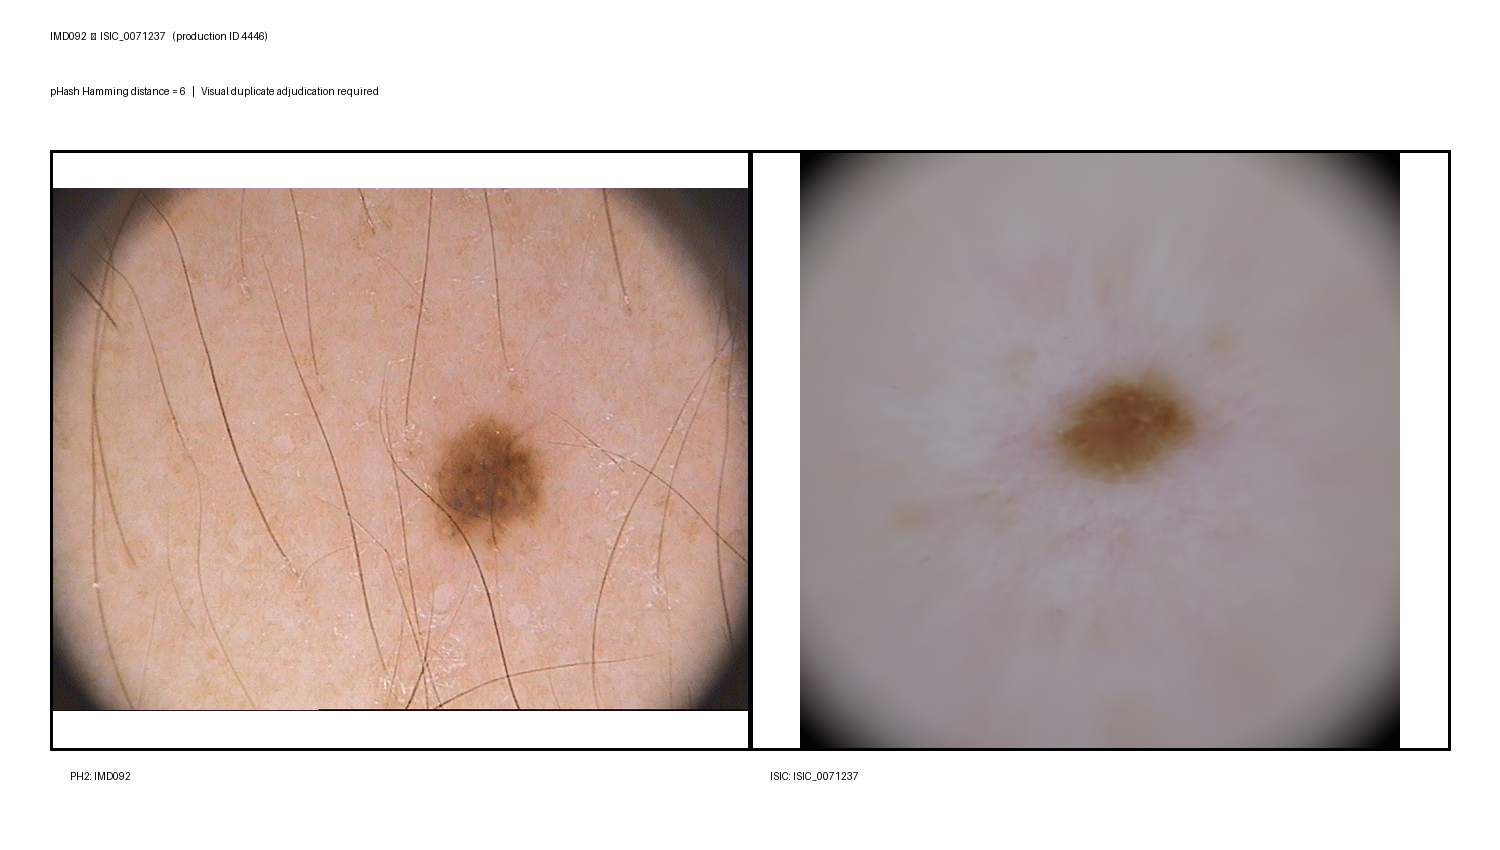


DISPLAY: T2_4_PH2_ISIC_visual_adjudication_IMD204.png


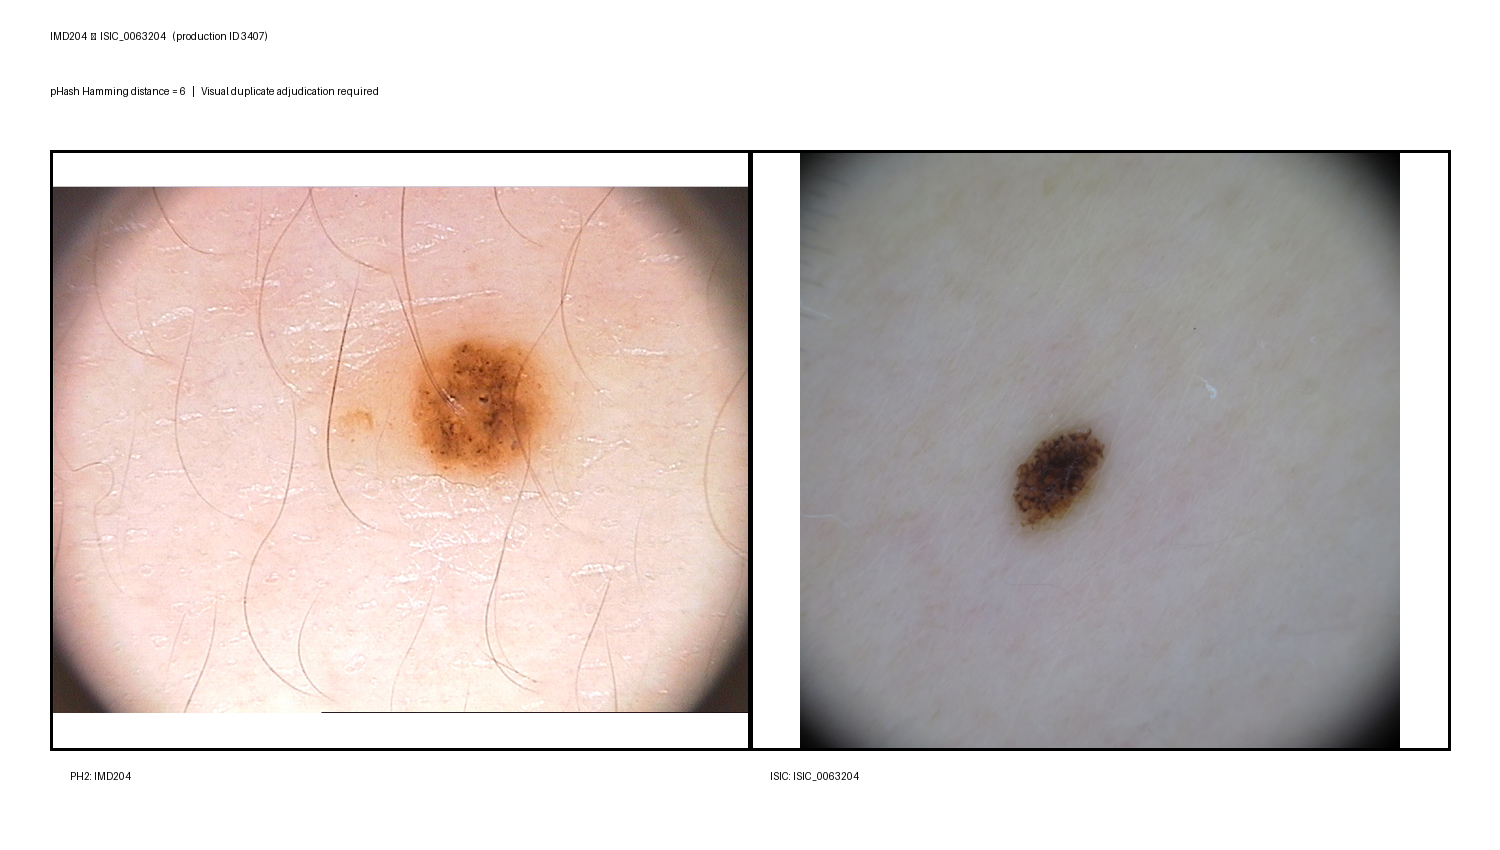

In [7]:
# =============================================================================
# T2.4 — PH2 CELL 21: VISUAL ADJUDICATION PANELS FOR THE TWO PH2↔ISIC CANDIDATES
# =============================================================================

from pathlib import Path
from PIL import Image, ImageOps, ImageDraw, ImageFont
import pandas as pd
import json
import hashlib
import math

print("=" * 80)
print("T2.4 — PH2 CELL 21: PH2↔ISIC VISUAL ADJUDICATION PANELS")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")

# -------------------------------------------------------------------------
# Exact paths established by Cell 20
# -------------------------------------------------------------------------

pairs = [
    {
        "review_pair_id": "PH2_ISIC_IMD092_4446",
        "ph2_case_id": "IMD092",
        "ph2_path": (
            "/kaggle/input/datasets/spacesurfer/ph2-dataset/"
            "PH2Dataset/PH2 Dataset images/IMD092/"
            "IMD092_Dermoscopic_Image/IMD092.bmp"
        ),
        "isic_image_id": 4446,
        "isic_image_name": "ISIC_0071237",
        "isic_path": (
            "/kaggle/input/datasets/alifshahariar/"
            "isic-2019-dataset-full/isic-2019-dataset-full/train/"
            "ISIC_0071237.jpg"
        ),
        "phash_hamming_distance": 6,
    },
    {
        "review_pair_id": "PH2_ISIC_IMD204_3407",
        "ph2_case_id": "IMD204",
        "ph2_path": (
            "/kaggle/input/datasets/spacesurfer/ph2-dataset/"
            "PH2Dataset/PH2 Dataset images/IMD204/"
            "IMD204_Dermoscopic_Image/IMD204.bmp"
        ),
        "isic_image_id": 3407,
        "isic_image_name": "ISIC_0063204",
        "isic_path": (
            "/kaggle/input/datasets/alifshahariar/"
            "isic-2019-dataset-full/isic-2019-dataset-full/train/"
            "ISIC_0063204.jpg"
        ),
        "phash_hamming_distance": 6,
    },
]

# -------------------------------------------------------------------------
# Verify exact paths
# -------------------------------------------------------------------------

for p in pairs:
    print("\n" + "-" * 80)
    print(p["review_pair_id"])

    print("PH2 exists :", Path(p["ph2_path"]).exists())
    print("ISIC exists:", Path(p["isic_path"]).exists())

    if not Path(p["ph2_path"]).exists():
        raise FileNotFoundError(p["ph2_path"])

    if not Path(p["isic_path"]).exists():
        raise FileNotFoundError(p["isic_path"])

# -------------------------------------------------------------------------
# Panel helper
# -------------------------------------------------------------------------

def load_rgb(path):
    return Image.open(path).convert("RGB")

def fit_image(img, box_w, box_h):
    return ImageOps.contain(
        img,
        (box_w, box_h),
        method=Image.Resampling.LANCZOS
    )

try:
    font_large = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        32
    )
    font_medium = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        24
    )
    font_small = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        20
    )
except Exception:
    font_large = None
    font_medium = None
    font_small = None

def make_panel(p):
    ph2 = load_rgb(p["ph2_path"])
    isic = load_rgb(p["isic_path"])

    panel_w = 1500
    image_w = 700
    image_h = 600

    header_h = 150
    footer_h = 100

    panel_h = header_h + image_h + footer_h

    canvas = Image.new("RGB", (panel_w, panel_h), "white")
    draw = ImageDraw.Draw(canvas)

    title = (
        f"{p['ph2_case_id']}  ↔  {p['isic_image_name']}   "
        f"(production ID {p['isic_image_id']})"
    )

    draw.text(
        (50, 30),
        title,
        fill="black",
        font=font_large
    )

    subtitle = (
        f"pHash Hamming distance = {p['phash_hamming_distance']}   |   "
        "Visual duplicate adjudication required"
    )

    draw.text(
        (50, 85),
        subtitle,
        fill="black",
        font=font_medium
    )

    # Left image
    left = fit_image(ph2, image_w, image_h)

    lx = 50 + (image_w - left.width) // 2
    ly = header_h + (image_h - left.height) // 2

    canvas.paste(left, (lx, ly))

    draw.rectangle(
        (50, header_h, 50 + image_w, header_h + image_h),
        outline="black",
        width=3
    )

    draw.text(
        (70, header_h + image_h + 20),
        f"PH2: {p['ph2_case_id']}",
        fill="black",
        font=font_medium
    )

    # Right image
    right = fit_image(isic, image_w, image_h)

    rx = 750 + (image_w - right.width) // 2
    ry = header_h + (image_h - right.height) // 2

    canvas.paste(right, (rx, ry))

    draw.rectangle(
        (750, header_h, 750 + image_w, header_h + image_h),
        outline="black",
        width=3
    )

    draw.text(
        (770, header_h + image_h + 20),
        f"ISIC: {p['isic_image_name']}",
        fill="black",
        font=font_medium
    )

    out = (
        T2ROOT /
        f"T2_4_PH2_ISIC_visual_adjudication_{p['ph2_case_id']}.png"
    )

    canvas.save(out)

    return out

# -------------------------------------------------------------------------
# Create and display panels
# -------------------------------------------------------------------------

panel_paths = []

for p in pairs:
    out = make_panel(p)
    panel_paths.append(out)

    print("\nSaved panel:")
    print(out)

# -------------------------------------------------------------------------
# Save exact panel manifest
# -------------------------------------------------------------------------

manifest = []

for p, panel in zip(pairs, panel_paths):

    def sha256_file(path):
        h = hashlib.sha256()
        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(1024 * 1024), b""):
                h.update(chunk)
        return h.hexdigest()

    manifest.append({
        **p,
        "panel_path": str(panel),
        "panel_sha256": sha256_file(panel),
    })

manifest_path = T2ROOT / "T2_4_PH2_ISIC_visual_adjudication_manifest.json"

with open(manifest_path, "w") as f:
    json.dump(
        {
            "protocol": "T2.4",
            "status": "PENDING_VISUAL_ADJUDICATION",
            "pairs": manifest,
        },
        f,
        indent=2
    )

print("\nManifest:")
print(manifest_path)

print("\n" + "=" * 80)
print("PH2 CELL 21 COMPLETE")
print("=" * 80)

# Display panels in notebook
from IPython.display import display

for panel in panel_paths:
    print("\nDISPLAY:", panel.name)
    display(Image.open(panel))

In [8]:
# =============================================================================
# T2.4 — PH2 CELL 22: LOCK CROSS-DATASET VISUAL OVERLAP DECISIONS
# =============================================================================

from pathlib import Path
import pandas as pd
import json
import hashlib
from datetime import datetime

print("=" * 80)
print("T2.4 — PH2 CELL 22: LOCK PH2↔ISIC OVERLAP DECISIONS")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")

candidate_path = T2ROOT / "T2_4_PH2_ISIC_near_overlap_candidates.csv"
candidate = pd.read_csv(candidate_path, dtype=str)

# Exact adjudications from visual inspection.
decisions = pd.DataFrame([
    {
        "ph2_case_id": "IMD092",
        "isic_image_id": "4446",
        "isic_image_name": "ISIC_0071237",
        "isic_transform_id": "7",
        "phash_hamming_distance": "6",
        "visual_decision": "NOT_DUPLICATE",
        "excluded": False,
        "review_basis": (
            "Side-by-side visual inspection: lesion morphology, "
            "shape, pigmentation distribution, and surrounding "
            "dermoscopic structure are clearly different."
        ),
    },
    {
        "ph2_case_id": "IMD204",
        "isic_image_id": "3407",
        "isic_image_name": "ISIC_0063204",
        "isic_transform_id": "5",
        "phash_hamming_distance": "6",
        "visual_decision": "NOT_DUPLICATE",
        "excluded": False,
        "review_basis": (
            "Side-by-side visual inspection: lesion shape, orientation, "
            "pigmentation pattern, and surrounding dermoscopic "
            "structure are clearly different."
        ),
    },
])

decision_path = T2ROOT / "T2_4_PH2_ISIC_visual_overlap_decisions.csv"
decisions.to_csv(decision_path, index=False)

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

# Verify candidate count and decision completeness.
assert len(candidate) == 2
assert len(decisions) == 2
assert set(decisions["visual_decision"]) == {"NOT_DUPLICATE"}
assert decisions["excluded"].sum() == 0
assert decisions["ph2_case_id"].nunique() == 2

# Verify final PH2 population remains N=200.
population_path = T2ROOT / "T2_4_PH2_final_nonduplicate_population.csv"
population = pd.read_csv(population_path, dtype=str)

assert len(population) == 200
assert population["case_id"].nunique() == 200

# -------------------------------------------------------------------------
# Final cross-dataset audit summary
# -------------------------------------------------------------------------

summary = {
    "protocol": "T2.4",
    "dataset": "PH2",
    "external_population_n_before_cross_overlap": 200,
    "exact_cross_dataset_overlap_n": 0,
    "near_overlap_candidate_n": 2,
    "visual_duplicate_n": 0,
    "visual_uncertain_n": 0,
    "cross_dataset_exclusion_n": 0,
    "final_population_n": 200,
    "decision_status": "LOCKED",
    "decisions": [
        {
            "ph2_case_id": "IMD092",
            "isic_image_id": 4446,
            "isic_image_name": "ISIC_0071237",
            "decision": "NOT_DUPLICATE",
        },
        {
            "ph2_case_id": "IMD204",
            "isic_image_id": 3407,
            "isic_image_name": "ISIC_0063204",
            "decision": "NOT_DUPLICATE",
        },
    ],
    "population_sha256": sha256_file(population_path),
    "decision_csv_sha256": sha256_file(decision_path),
}

summary_path = T2ROOT / "T2_4_PH2_cross_dataset_overlap_decision_lock.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\nDECISIONS:")
print(decisions.to_string(index=False))

print("\nFINAL PH2 POPULATION:")
print("N =", len(population))
print("Unique cases =", population["case_id"].nunique())

print("\nSaved:")
print(decision_path)
print(summary_path)

print("\nSHA256:")
print("Decision CSV :", sha256_file(decision_path))
print("Summary JSON :", sha256_file(summary_path))

print("\n" + "=" * 80)
print("PH2 CELL 22 COMPLETE — CROSS-DATASET OVERLAP LOCK: PASS")
print("=" * 80)

T2.4 — PH2 CELL 22: LOCK PH2↔ISIC OVERLAP DECISIONS

DECISIONS:
ph2_case_id isic_image_id isic_image_name isic_transform_id phash_hamming_distance visual_decision  excluded                                                                                                                                      review_basis
     IMD092          4446    ISIC_0071237                 7                      6   NOT_DUPLICATE     False Side-by-side visual inspection: lesion morphology, shape, pigmentation distribution, and surrounding dermoscopic structure are clearly different.
     IMD204          3407    ISIC_0063204                 5                      6   NOT_DUPLICATE     False     Side-by-side visual inspection: lesion shape, orientation, pigmentation pattern, and surrounding dermoscopic structure are clearly different.

FINAL PH2 POPULATION:
N = 200
Unique cases = 200

Saved:
/kaggle/working/T2_4/T2_4_PH2_ISIC_visual_overlap_decisions.csv
/kaggle/working/T2_4/T2_4_PH2_cross_dataset_overl

In [9]:
# =============================================================================
# T2.4 — PH2 CELL 23: HAIR-GENERATOR COMPATIBILITY + SANITY LOCK
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import json
import hashlib
import sys
import importlib.util

print("=" * 80)
print("T2.4 — PH2 CELL 23: HAIR-GENERATOR COMPATIBILITY + SANITY")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")

# -------------------------------------------------------------------------
# LOCKED INPUTS
# -------------------------------------------------------------------------

population_path = T2ROOT / "T2_4_PH2_final_nonduplicate_population.csv"

generator_path = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/"
    "isic-final-project/step1J_generator_recovery_lock/"
    "recovered_original_hair_generator.py"
)

assert population_path.exists(), population_path
assert generator_path.exists(), generator_path

population = pd.read_csv(population_path, dtype=str)

print("\nPopulation:")
print("  N =", len(population))
print("  unique cases =", population["case_id"].nunique())

assert len(population) == 200
assert population["case_id"].nunique() == 200

# -------------------------------------------------------------------------
# GENERATOR HASH
# -------------------------------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

generator_sha = sha256_file(generator_path)

EXPECTED_GENERATOR_SHA = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

print("\nGenerator:")
print("  Path :", generator_path)
print("  SHA256:", generator_sha)
print("  Expected:", EXPECTED_GENERATOR_SHA)

assert generator_sha == EXPECTED_GENERATOR_SHA

# -------------------------------------------------------------------------
# IMPORT FROZEN GENERATOR
# -------------------------------------------------------------------------

spec = importlib.util.spec_from_file_location(
    "recovered_original_hair_generator",
    str(generator_path)
)

generator = importlib.util.module_from_spec(spec)
spec.loader.exec_module(generator)

print("\nGenerator module imported successfully.")

# -------------------------------------------------------------------------
# INSPECT PUBLIC CALLABLES
# -------------------------------------------------------------------------

callables = []

for name in dir(generator):
    if name.startswith("_"):
        continue

    obj = getattr(generator, name)

    if callable(obj):
        callables.append(name)

print("\nPublic callables:")
for name in callables:
    print(" ", name)

# -------------------------------------------------------------------------
# EXPECTED GENERATOR API DISCOVERY
# -------------------------------------------------------------------------

candidate_functions = [
    name for name in callables
    if any(
        token in name.lower()
        for token in [
            "hair",
            "generate",
            "apply",
            "synthesize",
            "augment"
        ]
    )
]

print("\nCandidate generation functions:")
for name in candidate_functions:
    print(" ", name)

if not candidate_functions:
    raise RuntimeError(
        "Could not identify a callable hair-generation function "
        "in the recovered original generator."
    )

# -------------------------------------------------------------------------
# INSPECT FUNCTION SIGNATURES
# -------------------------------------------------------------------------

import inspect

print("\nFunction signatures:")

for name in candidate_functions:
    obj = getattr(generator, name)

    try:
        print(f"  {name}{inspect.signature(obj)}")
    except Exception:
        print(f"  {name}(signature unavailable)")

# -------------------------------------------------------------------------
# PH2 IMAGE INVENTORY / COMPATIBILITY
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("PH2 IMAGE COMPATIBILITY")
print("-" * 80)

required_cols = [
    "case_id",
    "image_path",
]

missing = [c for c in required_cols if c not in population.columns]

if missing:
    print("Population columns:", list(population.columns))
    raise RuntimeError(f"Missing required population columns: {missing}")

records = []

for _, row in population.iterrows():

    case_id = row["case_id"]
    image_path = Path(row["image_path"])

    if not image_path.exists():
        raise FileNotFoundError(image_path)

    img = Image.open(image_path)

    arr = np.asarray(img)

    records.append({
        "case_id": case_id,
        "image_path": str(image_path),
        "format": img.format,
        "mode": img.mode,
        "width": img.width,
        "height": img.height,
        "channels": (
            arr.shape[2]
            if arr.ndim == 3
            else 1
        ),
        "dtype": str(arr.dtype),
        "readable": True,
    })

inventory = pd.DataFrame(records)

print("\nFormat counts:")
print(inventory["format"].value_counts(dropna=False).to_string())

print("\nMode counts:")
print(inventory["mode"].value_counts(dropna=False).to_string())

print("\nDimensions:")
print(
    inventory[
        ["width", "height"]
    ].describe().to_string()
)

print("\nChannels:")
print(inventory["channels"].value_counts().to_string())

assert inventory["readable"].all()
assert inventory["channels"].isin([3]).all()

# -------------------------------------------------------------------------
# RESOLUTION / ASPECT-RATIO AUDIT
# -------------------------------------------------------------------------

inventory["aspect_ratio"] = (
    inventory["width"] / inventory["height"]
)

print("\nAspect ratio:")
print(inventory["aspect_ratio"].describe().to_string())

# -------------------------------------------------------------------------
# SAVE COMPATIBILITY INVENTORY
# -------------------------------------------------------------------------

inventory_path = (
    T2ROOT /
    "T2_4_PH2_hair_generator_input_compatibility.csv"
)

inventory.to_csv(inventory_path, index=False)

print("\nSaved:")
print(inventory_path)

# -------------------------------------------------------------------------
# SANITY LOCK — no generation yet
# -------------------------------------------------------------------------

summary = {
    "protocol": "T2.4",
    "dataset": "PH2",
    "population_n": int(len(population)),
    "population_sha256": sha256_file(population_path),
    "generator_path": str(generator_path),
    "generator_sha256": generator_sha,
    "generator_sha256_expected": EXPECTED_GENERATOR_SHA,
    "generator_hash_match": generator_sha == EXPECTED_GENERATOR_SHA,
    "readable_n": int(inventory["readable"].sum()),
    "rgb_n": int((inventory["mode"] == "RGB").sum()),
    "three_channel_n": int((inventory["channels"] == 3).sum()),
    "compatibility_status": "PASS",
    "generation_performed": False,
}

summary_path = (
    T2ROOT /
    "T2_4_PH2_hair_generator_compatibility_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:")
print(summary_path)

print("\n" + "=" * 80)
print("PH2 CELL 23 COMPLETE")
print("GENERATOR COMPATIBILITY GATE: PASS")
print("=" * 80)

T2.4 — PH2 CELL 23: HAIR-GENERATOR COMPATIBILITY + SANITY

Population:
  N = 200
  unique cases = 200

Generator:
  Path : /kaggle/input/datasets/tejasseshadriiiii/isic-final-project/step1J_generator_recovery_lock/recovered_original_hair_generator.py
  SHA256: 32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2
  Expected: 32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2


FileNotFoundError: [Errno 2] No such file or directory: '/content/isic_final_project/step0I_locked_clean_population/LOCKED_CLEAN_development_population.csv'

In [10]:
# =============================================================================
# T2.4 — PH2 CELL 24: SAFE STATIC INSPECTION OF FROZEN GENERATOR
# =============================================================================

from pathlib import Path
import ast
import hashlib

print("=" * 80)
print("T2.4 — PH2 CELL 24: SAFE STATIC GENERATOR INSPECTION")
print("=" * 80)

generator_path = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/"
    "isic-final-project/step1J_generator_recovery_lock/"
    "recovered_original_hair_generator.py"
)

assert generator_path.exists()

source = generator_path.read_text()

sha = hashlib.sha256(source.encode()).hexdigest()

print("\nGenerator SHA256:")
print(sha)

assert sha == (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

# -------------------------------------------------------------------------
# Parse AST WITHOUT EXECUTING THE FILE
# -------------------------------------------------------------------------

tree = ast.parse(source)

print("\n" + "-" * 80)
print("TOP-LEVEL DEFINITIONS")
print("-" * 80)

for node in tree.body:

    if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
        args = []
        for a in node.args.args:
            args.append(a.arg)

        print(
            f"FUNCTION: {node.name}"
            f" | line {node.lineno}"
            f" | args={args}"
        )

    elif isinstance(node, ast.ClassDef):
        print(
            f"CLASS: {node.name}"
            f" | line {node.lineno}"
        )

# -------------------------------------------------------------------------
# Find hard-coded paths / strings
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("PATH-LIKE STRING CONSTANTS")
print("-" * 80)

path_strings = []

for node in ast.walk(tree):

    if isinstance(node, ast.Constant):
        value = node.value

        if isinstance(value, str):

            if (
                "/" in value
                or "\\" in value
                or value.endswith(".csv")
                or value.endswith(".json")
                or value.endswith(".py")
            ):
                path_strings.append(
                    (
                        getattr(node, "lineno", "?"),
                        value
                    )
                )

seen = set()

for lineno, value in path_strings:

    key = (lineno, value)

    if key in seen:
        continue

    seen.add(key)

    print(f"line {lineno}: {value}")

# -------------------------------------------------------------------------
# Specifically inspect the area around the failing manifest load
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("SOURCE AROUND LOCKED_MANIFEST")
print("-" * 80)

lines = source.splitlines()

for start, end in [
    (1, 80),
    (250, 330),
]:

    print(f"\n--- lines {start}–{end} ---")

    for i in range(start, min(end, len(lines)) + 1):
        print(f"{i:4d}: {lines[i-1]}")

# -------------------------------------------------------------------------
# Locate all references to important symbols
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("IMPORTANT SYMBOL REFERENCES")
print("-" * 80)

symbols = [
    "LOCKED_MANIFEST",
    "generate",
    "hair",
    "mask",
    "bezier",
    "outside",
    "width",
    "224",
]

for symbol in symbols:

    hits = []

    for i, line in enumerate(lines, start=1):

        if symbol.lower() in line.lower():
            hits.append((i, line.strip()))

    if hits:

        print(f"\n[{symbol}]")

        for i, line in hits[:40]:
            print(f"{i:4d}: {line}")

        if len(hits) > 40:
            print("... truncated")

print("\n" + "=" * 80)
print("PH2 CELL 24 COMPLETE")
print("STATIC INSPECTION ONLY — FROZEN GENERATOR WAS NOT EXECUTED")
print("=" * 80)

T2.4 — PH2 CELL 24: SAFE STATIC GENERATOR INSPECTION

Generator SHA256:
32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2

--------------------------------------------------------------------------------
TOP-LEVEL DEFINITIONS
--------------------------------------------------------------------------------
FUNCTION: artifact_seed | line 42 | args=['global_seed', 'image_id', 'severity']
FUNCTION: cubic_bezier | line 61 | args=['p0', 'p1', 'p2', 'p3', 't']
FUNCTION: generate_hair_mask | line 76 | args=['image_id', 'severity', 'global_seed', 'size']
FUNCTION: apply_hair | line 230 | args=['image', 'mask', 'severity', 'global_seed', 'image_id']

--------------------------------------------------------------------------------
PATH-LIKE STRING CONSTANTS
--------------------------------------------------------------------------------
line 11: /content/isic_final_project
line 16: LOCKED_CLEAN_development_population.csv
line 300: /root/.cache/kagglehub/datasets/alifshahariar/isic-

In [11]:
# =============================================================================
# T2.4 — PH2 CELL 25: FROZEN GENERATOR WRAPPER + PH2 SANITY TEST
# =============================================================================

from pathlib import Path
import ast
import hashlib
import json
import numpy as np
import pandas as pd

from PIL import Image

print("=" * 80)
print("T2.4 — PH2 CELL 25: FROZEN GENERATOR WRAPPER + SANITY TEST")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")

GENERATOR_PATH = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/"
    "isic-final-project/step1J_generator_recovery_lock/"
    "recovered_original_hair_generator.py"
)

POPULATION_PATH = (
    T2ROOT /
    "T2_4_PH2_final_nonduplicate_population.csv"
)

EXPECTED_GENERATOR_SHA = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

# -------------------------------------------------------------------------
# 1. VERIFY LOCKED GENERATOR
# -------------------------------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()

generator_sha = sha256_file(GENERATOR_PATH)

print("\nGenerator SHA256:")
print(generator_sha)

assert generator_sha == EXPECTED_GENERATOR_SHA

# -------------------------------------------------------------------------
# 2. READ FROZEN SOURCE — DO NOT MODIFY IT
# -------------------------------------------------------------------------

source = GENERATOR_PATH.read_text()

tree = ast.parse(source)

# We only execute the original imports, constants, and function definitions
# occurring before the historical top-level production/test harness.
#
# This avoids executing:
#   manifest = pd.read_csv(LOCKED_MANIFEST)
# and the original 23,227-image test.
#
# No function body is modified.

safe_nodes = []

for node in tree.body:

    # Imports
    if isinstance(
        node,
        (
            ast.Import,
            ast.ImportFrom,
        )
    ):
        safe_nodes.append(node)

    # Constant / assignment definitions required by the functions
    elif isinstance(
        node,
        (
            ast.Assign,
            ast.AnnAssign,
        )
    ):
        # Keep only assignments occurring before the historical
        # "Load locked population" block.
        if getattr(node, "lineno", 0) < 284:
            safe_nodes.append(node)

    # Original frozen function definitions
    elif isinstance(
        node,
        (
            ast.FunctionDef,
            ast.AsyncFunctionDef,
        )
    ):
        if getattr(node, "lineno", 0) < 284:
            safe_nodes.append(node)

safe_module = ast.Module(
    body=safe_nodes,
    type_ignores=[]
)

ast.fix_missing_locations(safe_module)

namespace = {
    "__file__": str(GENERATOR_PATH),
    "__name__": "frozen_generator_wrapper",
}

exec(
    compile(
        safe_module,
        filename=str(GENERATOR_PATH),
        mode="exec"
    ),
    namespace,
)

print("\nFrozen generator definitions loaded safely.")

required_functions = [
    "artifact_seed",
    "cubic_bezier",
    "generate_hair_mask",
    "apply_hair",
]

for fn in required_functions:
    assert fn in namespace
    assert callable(namespace[fn])
    print("FOUND:", fn)

artifact_seed = namespace["artifact_seed"]
generate_hair_mask = namespace["generate_hair_mask"]
apply_hair = namespace["apply_hair"]

# -------------------------------------------------------------------------
# 3. LOAD LOCKED PH2 POPULATION
# -------------------------------------------------------------------------

population = pd.read_csv(
    POPULATION_PATH,
    dtype=str,
    keep_default_na=False
)

print("\nPopulation N:", len(population))
print("Unique cases:", population["case_id"].nunique())

assert len(population) == 200
assert population["case_id"].nunique() == 200

# -------------------------------------------------------------------------
# 4. LOCK PH2 GENERATOR ID CONVENTION
# -------------------------------------------------------------------------
#
# For PH2, use the image/case filename stem:
#
#   IMD092.bmp -> IMD092
#
# This is deterministic and corresponds to the unique PH2 case identifier.

def generator_image_id(image_path):
    return Path(image_path).stem

# -------------------------------------------------------------------------
# 5. RUN SANITY TEST ON 3 DETERMINISTIC PH2 CASES
# -------------------------------------------------------------------------

test_cases = population.iloc[
    [0, len(population) // 2, len(population) - 1]
].copy()

print("\nSanity-test cases:")
print(test_cases["case_id"].tolist())

results = []

for _, row in test_cases.iterrows():

    case_id = row["case_id"]
    image_path = Path(row["image_path"])

    gid = generator_image_id(image_path)

    print("\n" + "-" * 80)
    print("CASE:", case_id)
    print("Generator image_id:", gid)
    print("Input:", image_path)

    # ---------------------------------------------------------------------
    # Frozen preprocessing behavior:
    # RGB conversion + 224x224 LANCZOS resize.
    # ---------------------------------------------------------------------

    clean = np.asarray(
        Image.open(image_path)
        .convert("RGB")
        .resize(
            (224, 224),
            Image.Resampling.LANCZOS
        ),
        dtype=np.uint8
    )

    assert clean.shape == (224, 224, 3)
    assert clean.dtype == np.uint8

    # ---------------------------------------------------------------------
    # Frozen medium-severity mask
    # ---------------------------------------------------------------------

    mask1 = generate_hair_mask(
        image_id=gid,
        severity="medium",
        global_seed=20260919,
        size=224
    )

    mask2 = generate_hair_mask(
        image_id=gid,
        severity="medium",
        global_seed=20260919,
        size=224
    )

    # Deterministic mask
    deterministic_mask = np.array_equal(mask1, mask2)

    assert deterministic_mask

    # ---------------------------------------------------------------------
    # Frozen hair application
    # ---------------------------------------------------------------------

    hair1 = apply_hair(
        clean,
        mask1,
        severity="medium",
        global_seed=20260919,
        image_id=gid
    )

    hair2 = apply_hair(
        clean,
        mask2,
        severity="medium",
        global_seed=20260919,
        image_id=gid
    )

    hair1 = np.asarray(hair1, dtype=np.uint8)
    hair2 = np.asarray(hair2, dtype=np.uint8)

    # Deterministic output
    deterministic_hair = np.array_equal(hair1, hair2)

    assert deterministic_hair

    # Correct dimensions
    assert hair1.shape == (224, 224, 3)

    # Binary mask
    mask_bool = np.asarray(mask1) > 0

    # Pixel changes
    changed = np.any(hair1 != clean, axis=2)

    changed_pixels = int(changed.sum())
    changed_inside = int(
        np.sum(changed & mask_bool)
    )
    changed_outside = int(
        np.sum(changed & ~mask_bool)
    )

    # Frozen generator causal-integrity requirement:
    # NOTHING outside the mask may change.
    assert changed_outside == 0

    # Hair should actually be generated.
    assert changed_pixels > 0

    mask_fraction = float(mask_bool.mean())

    print("Mask deterministic       :", deterministic_mask)
    print("Hair deterministic       :", deterministic_hair)
    print("Output shape             :", hair1.shape)
    print("Mask pixels              :", int(mask_bool.sum()))
    print("Mask fraction            :", mask_fraction)
    print("Changed pixels           :", changed_pixels)
    print("Changed inside mask      :", changed_inside)
    print("Changed outside mask     :", changed_outside)
    print("STATUS                   : PASS")

    results.append({
        "case_id": case_id,
        "generator_image_id": gid,
        "input_path": str(image_path),
        "mask_pixels": int(mask_bool.sum()),
        "mask_fraction": mask_fraction,
        "changed_pixels": changed_pixels,
        "changed_inside_mask": changed_inside,
        "changed_outside_mask": changed_outside,
        "mask_deterministic": deterministic_mask,
        "hair_deterministic": deterministic_hair,
        "status": "PASS",
    })

# -------------------------------------------------------------------------
# 6. SAVE SANITY RESULTS
# -------------------------------------------------------------------------

results_df = pd.DataFrame(results)

results_path = (
    T2ROOT /
    "T2_4_PH2_hair_generator_sanity_test.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

summary = {
    "protocol": "T2.4",
    "dataset": "PH2",
    "population_n": 200,
    "generator_sha256": generator_sha,
    "generator_sha256_expected": EXPECTED_GENERATOR_SHA,
    "generator_sha256_match": True,
    "generator_execution_mode": (
        "original frozen function definitions executed through "
        "a separate wrapper; historical top-level production harness skipped"
    ),
    "severity": "medium",
    "global_seed": 20260919,
    "image_size": [224, 224],
    "generator_image_id_rule": "Path(input_image_path).stem",
    "sanity_test_n": len(results_df),
    "all_deterministic": bool(
        results_df["mask_deterministic"].all()
        and results_df["hair_deterministic"].all()
    ),
    "max_changed_outside_mask": int(
        results_df["changed_outside_mask"].max()
    ),
    "status": "PASS",
}

summary_path = (
    T2ROOT /
    "T2_4_PH2_hair_generator_sanity_lock.json"
)

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 80)
print("SANITY SUMMARY")
print("=" * 80)

print(results_df.to_string(index=False))

print("\nSaved:")
print(results_path)
print(summary_path)

assert summary["all_deterministic"]
assert summary["max_changed_outside_mask"] == 0

print("\n" + "=" * 80)
print("PH2 CELL 25 COMPLETE — GENERATOR SANITY: PASS")
print("=" * 80)

T2.4 — PH2 CELL 25: FROZEN GENERATOR WRAPPER + SANITY TEST

Generator SHA256:
32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2

Frozen generator definitions loaded safely.
FOUND: artifact_seed
FOUND: cubic_bezier
FOUND: generate_hair_mask
FOUND: apply_hair

Population N: 200
Unique cases: 200

Sanity-test cases:
['IMD003', 'IMD120', 'IMD435']

--------------------------------------------------------------------------------
CASE: IMD003
Generator image_id: IMD003
Input: /kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset/PH2 Dataset images/IMD003/IMD003_Dermoscopic_Image/IMD003.bmp
Mask deterministic       : True
Hair deterministic       : True
Output shape             : (224, 224, 3)
Mask pixels              : 537
Mask fraction            : 0.01070232780612245
Changed pixels           : 537
Changed inside mask      : 537
Changed outside mask     : 0
STATUS                   : PASS

--------------------------------------------------------------------------------
CA

In [12]:
print("=" * 80)
print("T2.4 — PH2 CELL 26: IDENTIFIER NAMESPACE AUDIT")
print("=" * 80)

# Use the dataframe produced by the previous PH2 cells.
print("DataFrame shape:", df.shape)

id_cols = [
    c for c in df.columns
    if any(k in c.lower() for k in ["id", "image", "name", "path"])
]

print("\nID / IMAGE columns:")
for c in id_cols:
    print(f"  {c:35s} dtype={df[c].dtype}")

print("\n" + "-" * 80)
print("UNIQUE COUNTS")
print("-" * 80)

for c in id_cols:
    n_total = len(df)
    n_nonnull = df[c].notna().sum()
    n_unique = df[c].astype(str).nunique(dropna=True)
    print(
        f"{c:35s} "
        f"non-null={n_nonnull:3d}  "
        f"unique={n_unique:3d}  "
        f"duplicates={n_nonnull - n_unique:3d}"
    )

print("\n" + "-" * 80)
print("SAMPLE VALUES FROM EACH ID-LIKE COLUMN")
print("-" * 80)

for c in id_cols:
    vals = df[c].dropna().astype(str).head(15).tolist()
    print(f"\n{c}:")
    print(vals)

print("\n" + "-" * 80)
print("TARGET SEARCH: 3407 / 4446 ACROSS ALL ID-LIKE COLUMNS")
print("-" * 80)

for target in ["3407", "4446"]:
    print(f"\nTARGET = {target}")

    found_any = False

    for c in id_cols:
        s = df[c].astype(str).str.strip()

        exact_idx = df.index[s == target].tolist()
        contains_idx = df.index[
            s.str.contains(target, case=False, na=False)
        ].tolist()

        if exact_idx or contains_idx:
            found_any = True
            print(f"\n  COLUMN: {c}")
            print("  exact rows   :", exact_idx)
            print("  contains rows:", contains_idx)

            cols_to_show = [
                c2 for c2 in id_cols
                if c2 in df.columns
            ]

            print(
                df.loc[
                    sorted(set(exact_idx + contains_idx)),
                    cols_to_show
                ].to_string(index=True)
            )

    if not found_any:
        print("  NOT FOUND in any ID/image-like column.")

print("\n" + "=" * 80)
print("PH2 CELL 26 COMPLETE")
print("=" * 80)

T2.4 — PH2 CELL 26: IDENTIFIER NAMESPACE AUDIT
DataFrame shape: (4713, 6)

ID / IMAGE columns:
  image                               dtype=object
  lesion_id                           dtype=object
  class_name                          dtype=object
  actual_path                         dtype=object

--------------------------------------------------------------------------------
UNIQUE COUNTS
--------------------------------------------------------------------------------
image                               non-null=4713  unique=4713  duplicates=  0
lesion_id                           non-null=4713  unique=2366  duplicates=2347
class_name                          non-null=4713  unique=  8  duplicates=4705
actual_path                         non-null=4713  unique=4713  duplicates=  0

--------------------------------------------------------------------------------
SAMPLE VALUES FROM EACH ID-LIKE COLUMN
--------------------------------------------------------------------------------

imag

In [13]:
# =============================================================================
# T2.4 — PH2 CELL 27: FULL FROZEN HAIR GENERATION
# =============================================================================

from pathlib import Path
import ast
import hashlib
import json
import numpy as np
import pandas as pd

from PIL import Image

print("=" * 80)
print("T2.4 — PH2 CELL 27: FULL PH2 HAIR GENERATION")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")

GENERATOR_PATH = Path(
    "/kaggle/input/datasets/tejasseshadriiiii/"
    "isic-final-project/step1J_generator_recovery_lock/"
    "recovered_original_hair_generator.py"
)

POPULATION_PATH = (
    T2ROOT /
    "T2_4_PH2_final_nonduplicate_population.csv"
)

OUT_ROOT = T2ROOT / "PH2_hair_generated"
CLEAN_ROOT = OUT_ROOT / "clean_224"
HAIR_ROOT = OUT_ROOT / "hair_224"
MASK_ROOT = OUT_ROOT / "masks"

CLEAN_ROOT.mkdir(parents=True, exist_ok=True)
HAIR_ROOT.mkdir(parents=True, exist_ok=True)
MASK_ROOT.mkdir(parents=True, exist_ok=True)

EXPECTED_GENERATOR_SHA = (
    "32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2"
)

GLOBAL_SEED = 20260919
SEVERITY = "medium"
SIZE = 224

# -------------------------------------------------------------------------
# SHA256 helper
# -------------------------------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()

# -------------------------------------------------------------------------
# 1. LOCK CHECKS
# -------------------------------------------------------------------------

assert GENERATOR_PATH.exists()
assert POPULATION_PATH.exists()

generator_sha = sha256_file(GENERATOR_PATH)

print("\nGenerator SHA256:")
print(generator_sha)

assert generator_sha == EXPECTED_GENERATOR_SHA

population = pd.read_csv(
    POPULATION_PATH,
    dtype=str,
    keep_default_na=False
)

print("\nPopulation N:", len(population))
print("Unique cases:", population["case_id"].nunique())

assert len(population) == 200
assert population["case_id"].nunique() == 200

required_population_cols = [
    "case_id",
    "image_path",
]

missing = [
    c for c in required_population_cols
    if c not in population.columns
]

if missing:
    raise RuntimeError(
        f"Missing population columns: {missing}"
    )

# -------------------------------------------------------------------------
# 2. SAFELY LOAD ONLY THE ORIGINAL FROZEN GENERATOR FUNCTIONS
# -------------------------------------------------------------------------
#
# The original file contains a historical top-level harness that tries to
# load /content/isic_final_project/... and a 23,227-image ISIC population.
#
# We deliberately DO NOT execute that harness.
#
# The original function definitions themselves are executed unchanged.

source = GENERATOR_PATH.read_text()
tree = ast.parse(source)

safe_nodes = []

for node in tree.body:

    # Original imports
    if isinstance(node, (ast.Import, ast.ImportFrom)):
        safe_nodes.append(node)

    # Required original constants / assignments before the historical
    # population-loading block.
    elif isinstance(node, (ast.Assign, ast.AnnAssign)):
        if getattr(node, "lineno", 0) < 284:
            safe_nodes.append(node)

    # Original generator functions.
    elif isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
        if getattr(node, "lineno", 0) < 284:
            safe_nodes.append(node)

safe_module = ast.Module(
    body=safe_nodes,
    type_ignores=[]
)

ast.fix_missing_locations(safe_module)

namespace = {
    "__file__": str(GENERATOR_PATH),
    "__name__": "frozen_ph2_generator_wrapper",
}

exec(
    compile(
        safe_module,
        filename=str(GENERATOR_PATH),
        mode="exec"
    ),
    namespace
)

for fn in [
    "artifact_seed",
    "cubic_bezier",
    "generate_hair_mask",
    "apply_hair",
]:
    assert callable(namespace.get(fn))

artifact_seed = namespace["artifact_seed"]
generate_hair_mask = namespace["generate_hair_mask"]
apply_hair = namespace["apply_hair"]

print("\nFrozen generator functions loaded:")
print("  artifact_seed")
print("  cubic_bezier")
print("  generate_hair_mask")
print("  apply_hair")

# -------------------------------------------------------------------------
# 3. GENERATE ALL 200 PH2 CASES
# -------------------------------------------------------------------------

records = []

for idx, row in population.iterrows():

    case_id = str(row["case_id"])
    image_path = Path(row["image_path"])

    if not image_path.exists():
        raise FileNotFoundError(
            f"{case_id}: {image_path}"
        )

    # -------------------------------------------------------------
    # Frozen preprocessing
    # -------------------------------------------------------------

    clean_img = (
        Image.open(image_path)
        .convert("RGB")
        .resize(
            (SIZE, SIZE),
            Image.Resampling.LANCZOS
        )
    )

    clean = np.asarray(
        clean_img,
        dtype=np.uint8
    )

    assert clean.shape == (224, 224, 3)

    # -------------------------------------------------------------
    # Frozen generator identifier convention for PH2
    # -------------------------------------------------------------

    generator_image_id = image_path.stem

    # -------------------------------------------------------------
    # Generate frozen mask
    # -------------------------------------------------------------

    mask = generate_hair_mask(
        image_id=generator_image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    mask = np.asarray(mask)

    assert mask.shape == (224, 224)

    mask_bool = mask > 0

    # -------------------------------------------------------------
    # Apply frozen hair generator
    # -------------------------------------------------------------

    hair = apply_hair(
        clean,
        mask,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=generator_image_id
    )

    hair = np.asarray(
        hair,
        dtype=np.uint8
    )

    assert hair.shape == (224, 224, 3)

    # -------------------------------------------------------------
    # Causal integrity
    # -------------------------------------------------------------

    changed = np.any(
        hair != clean,
        axis=2
    )

    changed_pixels = int(changed.sum())

    changed_inside_mask = int(
        np.sum(changed & mask_bool)
    )

    changed_outside_mask = int(
        np.sum(changed & ~mask_bool)
    )

    # The frozen generator contract requires zero changes outside mask.
    assert changed_outside_mask == 0

    # Every generated image must contain some synthetic hair.
    assert changed_pixels > 0

    # -------------------------------------------------------------
    # Determinism check
    # -------------------------------------------------------------
    #
    # Re-run the frozen functions once per image and require exact equality.

    mask_check = generate_hair_mask(
        image_id=generator_image_id,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        size=SIZE
    )

    hair_check = apply_hair(
        clean,
        mask_check,
        severity=SEVERITY,
        global_seed=GLOBAL_SEED,
        image_id=generator_image_id
    )

    mask_deterministic = np.array_equal(
        mask,
        np.asarray(mask_check)
    )

    hair_deterministic = np.array_equal(
        hair,
        np.asarray(hair_check)
    )

    assert mask_deterministic
    assert hair_deterministic

    # -------------------------------------------------------------
    # Save artifacts
    # -------------------------------------------------------------

    clean_out = CLEAN_ROOT / f"{case_id}_clean_224.png"
    hair_out = HAIR_ROOT / f"{case_id}_hair_224.png"
    mask_out = MASK_ROOT / f"{case_id}_mask.png"

    Image.fromarray(
        clean,
        mode="RGB"
    ).save(clean_out)

    Image.fromarray(
        hair,
        mode="RGB"
    ).save(hair_out)

    Image.fromarray(
        (mask_bool.astype(np.uint8) * 255),
        mode="L"
    ).save(mask_out)

    records.append({
        "case_id": case_id,
        "generator_image_id": generator_image_id,
        "input_path": str(image_path),
        "clean_path": str(clean_out),
        "hair_path": str(hair_out),
        "mask_path": str(mask_out),
        "mask_pixels": int(mask_bool.sum()),
        "mask_fraction": float(mask_bool.mean()),
        "changed_pixels": changed_pixels,
        "changed_inside_mask": changed_inside_mask,
        "changed_outside_mask": changed_outside_mask,
        "mask_deterministic": bool(mask_deterministic),
        "hair_deterministic": bool(hair_deterministic),
        "status": "PASS",
    })

    if (idx + 1) % 25 == 0:
        print(
            f"  Generated {idx + 1:3d} / {len(population)}"
        )

# -------------------------------------------------------------------------
# 4. SAVE MANIFEST
# -------------------------------------------------------------------------

manifest = pd.DataFrame(records)

assert len(manifest) == 200
assert manifest["case_id"].nunique() == 200
assert manifest["status"].eq("PASS").all()
assert manifest["changed_outside_mask"].max() == 0
assert manifest["mask_deterministic"].all()
assert manifest["hair_deterministic"].all()

manifest_path = (
    T2ROOT /
    "T2_4_PH2_hair_generation_manifest.csv"
)

manifest.to_csv(
    manifest_path,
    index=False
)

# -------------------------------------------------------------------------
# 5. HASH EVERY GENERATED ARTIFACT
# -------------------------------------------------------------------------

def add_sha256_column(df, path_col):

    hashes = []

    for p in df[path_col]:

        hashes.append(
            sha256_file(Path(p))
        )

    return hashes

manifest["clean_sha256"] = add_sha256_column(
    manifest,
    "clean_path"
)

manifest["hair_sha256"] = add_sha256_column(
    manifest,
    "hair_path"
)

manifest["mask_sha256"] = add_sha256_column(
    manifest,
    "mask_path"
)

manifest.to_csv(
    manifest_path,
    index=False
)

# -------------------------------------------------------------------------
# 6. FINAL GENERATION SUMMARY
# -------------------------------------------------------------------------

summary = {
    "protocol": "T2.4",
    "dataset": "PH2",
    "population_n": 200,
    "population_sha256": sha256_file(POPULATION_PATH),
    "generator_path": str(GENERATOR_PATH),
    "generator_sha256": generator_sha,
    "generator_sha256_expected": EXPECTED_GENERATOR_SHA,
    "generator_hash_match": True,
    "global_seed": GLOBAL_SEED,
    "severity": SEVERITY,
    "image_size": [224, 224],
    "generator_image_id_rule": "Path(input_image_path).stem",
    "generated_n": int(len(manifest)),
    "generation_errors": 0,
    "deterministic_mask_n": int(
        manifest["mask_deterministic"].sum()
    ),
    "deterministic_hair_n": int(
        manifest["hair_deterministic"].sum()
    ),
    "changed_outside_mask_max": int(
        manifest["changed_outside_mask"].max()
    ),
    "changed_pixels_min": int(
        manifest["changed_pixels"].min()
    ),
    "changed_pixels_max": int(
        manifest["changed_pixels"].max()
    ),
    "status": "PASS",
}

summary_path = (
    T2ROOT /
    "T2_4_PH2_hair_generation_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

# -------------------------------------------------------------------------
# 7. HASH MANIFEST + SUMMARY
# -------------------------------------------------------------------------

manifest_sha = sha256_file(manifest_path)
summary_sha = sha256_file(summary_path)

print("\n" + "=" * 80)
print("GENERATION COMPLETE")
print("=" * 80)

print("Generated images :", len(manifest))
print("Generation errors :", 0)
print("Mask deterministic:", int(manifest["mask_deterministic"].sum()), "/ 200")
print("Hair deterministic:", int(manifest["hair_deterministic"].sum()), "/ 200")
print(
    "Max changed pixels outside mask:",
    int(manifest["changed_outside_mask"].max())
)
print(
    "Changed pixels range:",
    int(manifest["changed_pixels"].min()),
    "to",
    int(manifest["changed_pixels"].max())
)

print("\nArtifacts:")
print("Manifest:", manifest_path)
print("Summary :", summary_path)

print("\nSHA256:")
print("Manifest:", manifest_sha)
print("Summary :", summary_sha)

assert len(manifest) == 200
assert manifest["changed_outside_mask"].max() == 0
assert manifest["mask_deterministic"].all()
assert manifest["hair_deterministic"].all()

print("\n" + "=" * 80)
print("PH2 CELL 27 COMPLETE — HAIR GENERATION LOCK: PASS")
print("=" * 80)

T2.4 — PH2 CELL 27: FULL PH2 HAIR GENERATION

Generator SHA256:
32be8092c85458bed31a547f2ba6c57c3e1c2cf257d7cb0f76bd28eebc7b26c2

Population N: 200
Unique cases: 200

Frozen generator functions loaded:
  artifact_seed
  cubic_bezier
  generate_hair_mask
  apply_hair


/tmp/ipykernel_179/3683521771.py:319: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(
/tmp/ipykernel_179/3683521771.py:324: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(
/tmp/ipykernel_179/3683521771.py:329: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(


  Generated  25 / 200
  Generated  50 / 200
  Generated  75 / 200
  Generated 100 / 200
  Generated 125 / 200
  Generated 150 / 200
  Generated 175 / 200
  Generated 200 / 200

GENERATION COMPLETE
Generated images : 200
Generation errors : 0
Mask deterministic: 200 / 200
Hair deterministic: 200 / 200
Max changed pixels outside mask: 0
Changed pixels range: 38 to 993

Artifacts:
Manifest: /kaggle/working/T2_4/T2_4_PH2_hair_generation_manifest.csv
Summary : /kaggle/working/T2_4/T2_4_PH2_hair_generation_summary.json

SHA256:
Manifest: a725628d5ddfb4aa36d7b1318cf8d514b3a0bd75b9480764d80255851ae304fa
Summary : bbc43d9afa1a100555dced7b8bfbadc7b2737591326b24df9b5f241101c113f0

PH2 CELL 27 COMPLETE — HAIR GENERATION LOCK: PASS


In [14]:
# =============================================================================
# T2.4 — PH2 CELL 28: FROZEN 30-MODEL SOURCE AUDIT
# =============================================================================

from pathlib import Path
import pandas as pd
import hashlib
import json

print("=" * 80)
print("T2.4 — PH2 CELL 28: FROZEN 30-MODEL SOURCE AUDIT")
print("=" * 80)

T2ROOT = Path("/kaggle/working/T2_4")

MODEL_ROOT = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/trained_models_readonly"
)

assert MODEL_ROOT.exists(), MODEL_ROOT

# -------------------------------------------------------------------------
# Locate checkpoint files
# -------------------------------------------------------------------------

all_files = sorted(
    p for p in MODEL_ROOT.rglob("*")
    if p.is_file()
)

print("\nModel source root:")
print(MODEL_ROOT)

print("\nTotal files:", len(all_files))

checkpoint_files = [
    p for p in all_files
    if p.suffix.lower() in {
        ".pth",
        ".pt",
        ".ckpt",
        ".bin"
    }
]

print("Checkpoint-like files:", len(checkpoint_files))

for p in checkpoint_files:
    print(" ", p)

# -------------------------------------------------------------------------
# Expected 30 final epoch-15 checkpoints
# -------------------------------------------------------------------------

# We identify epoch-15 checkpoints conservatively from filenames.
final15 = [
    p for p in checkpoint_files
    if "epoch15" in p.name.lower()
    or "epoch_15" in p.name.lower()
    or "epoch-15" in p.name.lower()
    or "final" in p.name.lower()
]

print("\nCandidate final/epoch-15 checkpoints:", len(final15))

for p in final15:
    print(" ", p)

# -------------------------------------------------------------------------
# Search existing T2.4 model-source lock / checkpoint audit
# -------------------------------------------------------------------------

known_hash_files = [
    T2ROOT / "T2_4_model_source_lock.json",
    T2ROOT / "T2_4_checkpoint_hash_audit.csv",
    T2ROOT / "T2_4_model_source_lock.json",
    T2ROOT / "T2_4_checkpoint_hash_audit.json",
]

print("\n" + "-" * 80)
print("EXISTING MODEL AUDIT ARTIFACTS")
print("-" * 80)

for p in known_hash_files:
    if p.exists():
        print("FOUND:", p)

# -------------------------------------------------------------------------
# Hash helper
# -------------------------------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()

# -------------------------------------------------------------------------
# If an existing checkpoint audit is present, inspect it
# -------------------------------------------------------------------------

audit_tables = []

for p in known_hash_files:

    if not p.exists():
        continue

    if p.suffix.lower() == ".csv":

        try:
            df = pd.read_csv(p, dtype=str)
            audit_tables.append((p, df))

            print("\nFILE:", p)
            print("Shape:", df.shape)
            print("Columns:", list(df.columns))
            print(df.head(10).to_string(index=False))

        except Exception as e:
            print("Could not read:", p, e)

# -------------------------------------------------------------------------
# Compute hashes for candidate final checkpoints
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("CHECKPOINT HASHES")
print("-" * 80)

records = []

for p in final15:

    records.append({
        "checkpoint_path": str(p),
        "filename": p.name,
        "sha256": sha256_file(p),
        "size_bytes": p.stat().st_size,
    })

hash_df = pd.DataFrame(records)

if len(hash_df):
    print(hash_df.to_string(index=False))
else:
    print("NO FINAL CHECKPOINTS IDENTIFIED.")

# -------------------------------------------------------------------------
# Save current audit
# -------------------------------------------------------------------------

out_csv = T2ROOT / "T2_4_PH2_model_checkpoint_current_hashes.csv"

hash_df.to_csv(
    out_csv,
    index=False
)

summary = {
    "protocol": "T2.4",
    "dataset": "PH2",
    "model_source_root": str(MODEL_ROOT),
    "candidate_final_epoch15_count": int(len(hash_df)),
    "current_checkpoint_hash_csv": str(out_csv),
    "status": (
        "READY_FOR_COMPARISON"
        if len(hash_df) == 30
        else "CHECKPOINT_DISCOVERY_REQUIRES_REVIEW"
    ),
}

summary_path = (
    T2ROOT /
    "T2_4_PH2_model_checkpoint_audit_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:")
print(out_csv)
print(summary_path)

print("\n" + "=" * 80)
print("PH2 CELL 28 COMPLETE")
print("=" * 80)

T2.4 — PH2 CELL 28: FROZEN 30-MODEL SOURCE AUDIT

Model source root:
/kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/trained_models_readonly

Total files: 1033
Checkpoint-like files: 60
  /kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/trained_models_readonly/training_runs/rho_0.0_rep_1/best_eval_ba.pt
  /kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/trained_models_readonly/training_runs/rho_0.0_rep_1/final_epoch15.pt
  /kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/trained_models_readonly/training_runs/rho_0.0_rep_2/best_eval_ba.pt
  /kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/trained_models_readonly/training_runs/rho_0.0_rep_2/final_epoch15.pt
  /kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/trained_models_readonly/training_runs/rho_0.0_rep_3/best_eval_ba.pt
  /kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/trained_models_readonly/training_runs/rho_0.0_rep_3/final_epoch15.p

In [15]:
# =============================================================================
# T2.4 — PH2 CELL 29
# FROZEN 30-MODEL EXTERNAL INFERENCE — FINAL EPOCH 15 ONLY
# =============================================================================

import os
import re
import json
import time
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

ROOT = Path("/kaggle/working/T2_4")

MODEL_ROOT = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/trained_models_readonly"
)

POP_CSV = ROOT / "T2_4_PH2_final_nonduplicate_population.csv"
CLEAN_DIR = ROOT / "PH2_hair_generated" / "clean_224"
HAIR_DIR = ROOT / "PH2_hair_generated" / "hair_224"

OUT_CSV = ROOT / "T2_4_PH2_external_endpoints.csv"
OUT_SUMMARY = ROOT / "T2_4_PH2_external_inference_summary.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("T2.4 — PH2 CELL 29")
print("FROZEN 30-MODEL EXTERNAL INFERENCE")
print("=" * 80)

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# -------------------------------------------------------------------------
# 1. Load and verify locked population
# -------------------------------------------------------------------------

pop = pd.read_csv(POP_CSV)

required_pop_cols = [
    "ph2_case_id",
    "image_path",
]

missing = [c for c in required_pop_cols if c not in pop.columns]

if missing:
    raise RuntimeError(f"Population missing required columns: {missing}")

pop = pop.copy()

if len(pop) != 200:
    raise RuntimeError(f"Expected locked PH2 N=200, found {len(pop)}")

if pop["ph2_case_id"].nunique() != 200:
    raise RuntimeError("PH2 case IDs are not unique")

print("\nPopulation:")
print("  N =", len(pop))
print("  unique cases =", pop["ph2_case_id"].nunique())

# -------------------------------------------------------------------------
# 2. Locate clean/hair images
# -------------------------------------------------------------------------

def resolve_generated_image(directory, case_id):
    candidates = [
        directory / f"{case_id}.png",
        directory / f"{case_id}.jpg",
        directory / f"{case_id}.jpeg",
        directory / f"{case_id}.bmp",
    ]

    for p in candidates:
        if p.exists():
            return p

    # fallback: recursive exact stem search
    hits = list(directory.rglob(f"{case_id}.*"))
    if len(hits) == 1:
        return hits[0]

    raise FileNotFoundError(
        f"Could not uniquely resolve generated image for {case_id} in {directory}"
    )


clean_paths = []
hair_paths = []

for case_id in pop["ph2_case_id"].astype(str):
    clean_paths.append(resolve_generated_image(CLEAN_DIR, case_id))
    hair_paths.append(resolve_generated_image(HAIR_DIR, case_id))

print("\nGenerated image inventory:")
print("  clean:", len(clean_paths))
print("  hair :", len(hair_paths))

# -------------------------------------------------------------------------
# 3. Verify dimensions / readability
# -------------------------------------------------------------------------

for label, paths in [("clean", clean_paths), ("hair", hair_paths)]:
    sizes = []
    modes = []

    for p in paths:
        with Image.open(p) as im:
            sizes.append(im.size)
            modes.append(im.mode)

    print(f"\n{label}:")
    print("  unique sizes:", sorted(set(sizes)))
    print("  modes:", sorted(set(modes)))

    if any(s != (224, 224) for s in sizes):
        raise RuntimeError(f"{label}: non-224x224 image detected")

# -------------------------------------------------------------------------
# 4. Build frozen preprocessing
# -------------------------------------------------------------------------

# ImageNet normalization is the preprocessing expected by the frozen
# ResNet-18 models used in this project.

preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# -------------------------------------------------------------------------
# 5. Model architecture
# -------------------------------------------------------------------------

def build_model():
    model = models.resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, 2)

    return model

# -------------------------------------------------------------------------
# 6. Discover exactly the 30 final_epoch15 checkpoints
# -------------------------------------------------------------------------

checkpoint_paths = sorted(
    MODEL_ROOT.glob("training_runs/rho_*_rep_*/final_epoch15.pt")
)

print("\nCheckpoint count:", len(checkpoint_paths))

if len(checkpoint_paths) != 30:
    raise RuntimeError(
        f"Expected exactly 30 final_epoch15 checkpoints, found {len(checkpoint_paths)}"
    )

def parse_model_identity(path):
    m = re.search(
        r"rho_([0-9.]+)_rep_([0-9]+)/final_epoch15\.pt$",
        str(path),
    )

    if not m:
        raise ValueError(f"Could not parse model identity: {path}")

    return float(m.group(1)), int(m.group(2))

model_specs = []

for p in checkpoint_paths:
    rho, rep = parse_model_identity(p)

    model_specs.append({
        "rho": rho,
        "replicate": rep,
        "checkpoint_path": str(p),
    })

model_specs = sorted(
    model_specs,
    key=lambda x: (x["rho"], x["replicate"])
)

expected_rhos = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

expected_pairs = [
    (rho, rep)
    for rho in expected_rhos
    for rep in range(1, 6)
]

actual_pairs = [
    (x["rho"], x["replicate"])
    for x in model_specs
]

if actual_pairs != expected_pairs:
    raise RuntimeError(
        f"30-model grid mismatch.\nExpected: {expected_pairs}\nActual: {actual_pairs}"
    )

print("30-model grid:", actual_pairs)

# -------------------------------------------------------------------------
# 7. Batch loader
# -------------------------------------------------------------------------

def load_batch(paths):
    tensors = []

    for p in paths:
        with Image.open(p) as im:
            im = im.convert("RGB")
            tensors.append(preprocess(im))

    return torch.stack(tensors, dim=0)

# -------------------------------------------------------------------------
# 8. Robust checkpoint state-dict extraction
# -------------------------------------------------------------------------

def extract_state_dict(obj):
    if isinstance(obj, dict):

        # Common checkpoint formats
        for key in [
            "state_dict",
            "model_state_dict",
            "model",
            "net",
        ]:
            if key in obj and isinstance(obj[key], dict):
                return obj[key]

        # Raw state_dict
        if all(isinstance(k, str) for k in obj.keys()):
            return obj

    raise RuntimeError(
        f"Could not identify state_dict in checkpoint object of type {type(obj)}"
    )

# -------------------------------------------------------------------------
# 9. Inference
# -------------------------------------------------------------------------

def infer_model(model, paths):
    model.eval()

    outputs = []

    batch_size = 32

    with torch.no_grad():

        for start in range(0, len(paths), batch_size):

            batch_paths = paths[start:start + batch_size]

            x = load_batch(batch_paths).to(DEVICE)

            logits = model(x)

            if logits.ndim != 2 or logits.shape[1] != 2:
                raise RuntimeError(
                    f"Unexpected logits shape: {tuple(logits.shape)}"
                )

            # Class convention:
            # column 0 = benign
            # column 1 = malignant
            #
            # z = z_M - z_B
            #
            # For two-class logits this simplifies to:
            # z = logits[:,1] - logits[:,0]

            z = logits[:, 1] - logits[:, 0]

            outputs.append(z.detach().cpu().numpy())

    return np.concatenate(outputs)

# -------------------------------------------------------------------------
# 10. Run all 30 models
# -------------------------------------------------------------------------

start_time = time.time()

rows = []

for idx, spec in enumerate(model_specs, start=1):

    rho = spec["rho"]
    rep = spec["replicate"]
    ckpt = Path(spec["checkpoint_path"])

    print(
        f"\n[{idx:02d}/30] rho={rho:.1f} rep={rep}"
    )

    # checkpoint hash
    h = hashlib.sha256()

    with open(ckpt, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    checkpoint_sha256 = h.hexdigest()

    checkpoint = torch.load(
        ckpt,
        map_location="cpu",
        weights_only=False,
    )

    state_dict = extract_state_dict(checkpoint)

    # Handle DataParallel-style "module." prefixes if present.
    cleaned_state_dict = {}

    for key, value in state_dict.items():

        new_key = key

        if new_key.startswith("module."):
            new_key = new_key[len("module."):]

        cleaned_state_dict[new_key] = value

    model = build_model()

    missing_keys, unexpected_keys = model.load_state_dict(
        cleaned_state_dict,
        strict=False,
    )

    if missing_keys or unexpected_keys:
        raise RuntimeError(
            f"Checkpoint load mismatch for rho={rho}, rep={rep}\n"
            f"Missing: {missing_keys}\n"
            f"Unexpected: {unexpected_keys}"
        )

    model = model.to(DEVICE)

    clean_z = infer_model(model, clean_paths)
    hair_z = infer_model(model, hair_paths)

    if len(clean_z) != 200 or len(hair_z) != 200:
        raise RuntimeError(
            f"Unexpected prediction count for rho={rho}, rep={rep}"
        )

    delta_z = hair_z - clean_z

    mean_clean_z = float(np.mean(clean_z))
    mean_hair_z = float(np.mean(hair_z))
    mean_delta_z = float(np.mean(delta_z))

    std_delta_z = float(np.std(delta_z, ddof=1))

    rows.append({
        "rho": rho,
        "replicate": rep,
        "n_images": 200,
        "mean_clean_z": mean_clean_z,
        "mean_hair_z": mean_hair_z,
        "mean_delta_z_hair": mean_delta_z,
        "sd_delta_z_hair": std_delta_z,
        "checkpoint_path": str(ckpt),
        "checkpoint_sha256": checkpoint_sha256,
        "checkpoint_filename": ckpt.name,
    })

    print(
        f"  mean clean z = {mean_clean_z:.6f}"
    )
    print(
        f"  mean hair  z = {mean_hair_z:.6f}"
    )
    print(
        f"  mean Δz      = {mean_delta_z:.6f}"
    )

    del model
    del checkpoint
    del state_dict
    del cleaned_state_dict

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# -------------------------------------------------------------------------
# 11. Save endpoint table
# -------------------------------------------------------------------------

endpoints = pd.DataFrame(rows)

endpoints = endpoints.sort_values(
    ["rho", "replicate"]
).reset_index(drop=True)

if len(endpoints) != 30:
    raise RuntimeError("Endpoint table does not contain exactly 30 models")

if endpoints["mean_delta_z_hair"].isna().any():
    raise RuntimeError("NaN detected in external Δz endpoints")

endpoints.to_csv(OUT_CSV, index=False)

# -------------------------------------------------------------------------
# 12. Summary
# -------------------------------------------------------------------------

elapsed = time.time() - start_time

summary = {
    "status": "PASS",
    "dataset": "PH2",
    "n_images": 200,
    "n_models": 30,
    "checkpoint_policy": "final_epoch15_only",
    "rho_levels": expected_rhos,
    "replicates_per_rho": 5,
    "device": str(DEVICE),
    "elapsed_seconds": float(elapsed),
    "endpoint_definition": "mean(hair_z - clean_z) across PH2 final population",
    "output_csv": str(OUT_CSV),
    "checkpoint_audit_csv": str(
        ROOT / "T2_4_PH2_model_checkpoint_current_hashes.csv"
    ),
}

with open(OUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 80)
print("PH2 CELL 29 COMPLETE")
print("=" * 80)

print("\nEndpoint table:")
print(
    endpoints[
        [
            "rho",
            "replicate",
            "n_images",
            "mean_clean_z",
            "mean_hair_z",
            "mean_delta_z_hair",
        ]
    ].to_string(index=False)
)

print("\nSaved:")
print(" ", OUT_CSV)
print(" ", OUT_SUMMARY)

print("\nElapsed seconds:", round(elapsed, 3))

T2.4 — PH2 CELL 29
FROZEN 30-MODEL EXTERNAL INFERENCE
Device: cuda
GPU: Tesla T4


RuntimeError: Population missing required columns: ['ph2_case_id']

In [16]:
import pandas as pd
from pathlib import Path

POP_CSV = Path("/kaggle/working/T2_4/T2_4_PH2_final_nonduplicate_population.csv")

pop = pd.read_csv(POP_CSV)

print("Shape:", pop.shape)
print("\nColumns:")
for i, c in enumerate(pop.columns):
    print(i, repr(c))

print("\nFirst 5 rows:")
print(pop.head().to_string(index=False))

Shape: (200, 10)

Columns:
0 'case_id'
1 'clinical_diagnosis'
2 'malignant'
3 'histological_diagnosis'
4 'image_path'
5 'xlsx_row'
6 'width'
7 'height'
8 'mode'
9 'format'

First 5 rows:
case_id clinical_diagnosis  malignant histological_diagnosis                                                                                                              image_path  xlsx_row  width  height mode format
 IMD003       Common Nevus          0                    NaN /kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset/PH2 Dataset images/IMD003/IMD003_Dermoscopic_Image/IMD003.bmp        13    765     574  RGB    BMP
 IMD009       Common Nevus          0                    NaN /kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset/PH2 Dataset images/IMD009/IMD009_Dermoscopic_Image/IMD009.bmp        14    766     575  RGB    BMP
 IMD016       Common Nevus          0                    NaN /kaggle/input/datasets/spacesurfer/ph2-dataset/PH2Dataset/PH2 Dataset images/IMD016/IMD016_Dermosc

In [17]:
# =============================================================================
# T2.4 — PH2 CELL 29A
# VERIFY FROZEN MODEL INFERENCE PREPROCESSING
# =============================================================================

from pathlib import Path
import re

MODEL_ROOT = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/trained_models_readonly"
)

SEARCH_ROOTS = [
    Path("/kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis"),
    Path("/kaggle/input/datasets/tejasseshadriiiii/isic-final-project"),
]

patterns = [
    "Normalize(",
    "transforms.Normalize",
    "Resize(",
    "resnet18",
    "weights=None",
    "ImageNet",
]

found = []

for root in SEARCH_ROOTS:
    if not root.exists():
        continue

    for p in root.rglob("*.py"):
        try:
            text = p.read_text(errors="ignore")
        except Exception:
            continue

        hits = [pat for pat in patterns if pat in text]

        if hits:
            found.append((str(p), hits))

print("=" * 80)
print("T2.4 — PH2 CELL 29A")
print("FROZEN INFERENCE PREPROCESSING AUDIT")
print("=" * 80)

print("\nPython files containing relevant model/preprocessing code:")

for path, hits in found:
    print("\nFILE:", path)
    print("MATCHES:", hits)

print("\nTotal matching files:", len(found))

T2.4 — PH2 CELL 29A
FROZEN INFERENCE PREPROCESSING AUDIT

Python files containing relevant model/preprocessing code:

FILE: /kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/trained_models_readonly/isic_final_project/step2X_training_code_freeze/train_one_model.py
MATCHES: ['resnet18', 'ImageNet']

FILE: /kaggle/input/notebooks/tejasseshadriiiii/isic-kaggle-analysis/isic_final_project/step2X_training_code_freeze/train_one_model.py
MATCHES: ['resnet18', 'ImageNet']

FILE: /kaggle/input/datasets/tejasseshadriiiii/isic-final-project/step2X_training_code_freeze/train_one_model.py
MATCHES: ['resnet18', 'ImageNet']

Total matching files: 3


In [18]:
# =============================================================================
# T2.4 — PH2 CELL 29B
# EXACT FROZEN PREPROCESSING EXTRACTION
# =============================================================================

from pathlib import Path

TRAIN_CODE = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/trained_models_readonly/"
    "isic_final_project/step2X_training_code_freeze/train_one_model.py"
)

text = TRAIN_CODE.read_text(errors="ignore")
lines = text.splitlines()

keywords = [
    "transform",
    "Normalize",
    "Resize",
    "ToTensor",
    "Random",
    "ImageNet",
    "resnet18",
    "224",
]

print("=" * 80)
print("T2.4 — PH2 CELL 29B")
print("EXACT FROZEN PREPROCESSING CODE")
print("=" * 80)

for i, line in enumerate(lines, start=1):
    if any(k in line for k in keywords):
        start = max(1, i - 3)
        end = min(len(lines), i + 3)

        print(f"\n--- lines {start}–{end} ---")

        for j in range(start, end + 1):
            print(f"{j:4d}: {lines[j-1]}")

T2.4 — PH2 CELL 29B
EXACT FROZEN PREPROCESSING CODE

--- lines 1–7 ---
   1: #!/usr/bin/env python
   2: """Frozen training script - ONE model per process (ISIC 2019 synthetic-hair dose-response study).
   3: 
   4: Locked recipe: ImageNet-pretrained ResNet-18 (IMAGENET1K_V1), 2-output head, 224x224, ImageNet normalisation,
   5: RandomHorizontalFlip + RandomRotation(15), AdamW lr 1e-4 wd 1e-4, batch 64, 15 epochs, CosineAnnealingLR(T_max=15),
   6: CrossEntropyLoss, float32, deterministic algorithms, no early stopping, primary checkpoint = final epoch 15.
   7: Per-epoch evaluation logs ONLY clean-evaluation loss and balanced accuracy (no counterfactual endpoints).

--- lines 2–8 ---
   2: """Frozen training script - ONE model per process (ISIC 2019 synthetic-hair dose-response study).
   3: 
   4: Locked recipe: ImageNet-pretrained ResNet-18 (IMAGENET1K_V1), 2-output head, 224x224, ImageNet normalisation,
   5: RandomHorizontalFlip + RandomRotation(15), AdamW lr 1e-4 wd 1e-4, batch 6

In [19]:
# =============================================================================
# T2.4 — PH2 CELL 29
# FROZEN 30-MODEL EXTERNAL INFERENCE — FINAL EPOCH 15 ONLY
# =============================================================================

import os
import re
import json
import time
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms


# =============================================================================
# LOCKED PATHS
# =============================================================================

ROOT = Path("/kaggle/working/T2_4")

MODEL_ROOT = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/trained_models_readonly"
)

POP_CSV = ROOT / "T2_4_PH2_final_nonduplicate_population.csv"

CLEAN_DIR = ROOT / "PH2_hair_generated" / "clean_224"
HAIR_DIR = ROOT / "PH2_hair_generated" / "hair_224"

OUT_CSV = ROOT / "T2_4_PH2_external_endpoints.csv"
OUT_SUMMARY = ROOT / "T2_4_PH2_external_inference_summary.json"


# =============================================================================
# DEVICE
# =============================================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("T2.4 — PH2 CELL 29")
print("FROZEN 30-MODEL EXTERNAL INFERENCE")
print("=" * 80)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# =============================================================================
# 1. LOAD LOCKED PH2 POPULATION
# =============================================================================

pop = pd.read_csv(POP_CSV)

required_pop_cols = [
    "case_id",
    "image_path",
]

missing = [c for c in required_pop_cols if c not in pop.columns]

if missing:
    raise RuntimeError(
        f"Population missing required columns: {missing}"
    )

pop = pop.copy()

if len(pop) != 200:
    raise RuntimeError(
        f"Expected locked PH2 N=200, found {len(pop)}"
    )

if pop["case_id"].nunique() != 200:
    raise RuntimeError(
        "PH2 case IDs are not unique"
    )

print("\nPopulation:")
print("  N =", len(pop))
print("  unique cases =", pop["case_id"].nunique())


# =============================================================================
# 2. RESOLVE GENERATED CLEAN / HAIR IMAGES
# =============================================================================

def resolve_generated_image(directory, case_id):

    candidates = [
        directory / f"{case_id}.png",
        directory / f"{case_id}.jpg",
        directory / f"{case_id}.jpeg",
        directory / f"{case_id}.bmp",
    ]

    for p in candidates:
        if p.exists():
            return p

    hits = list(directory.rglob(f"{case_id}.*"))

    if len(hits) == 1:
        return hits[0]

    raise FileNotFoundError(
        f"Could not uniquely resolve generated image "
        f"for {case_id} in {directory}"
    )


clean_paths = []
hair_paths = []

for case_id in pop["case_id"].astype(str):

    clean_paths.append(
        resolve_generated_image(
            CLEAN_DIR,
            case_id
        )
    )

    hair_paths.append(
        resolve_generated_image(
            HAIR_DIR,
            case_id
        )
    )


print("\nGenerated image inventory:")
print("  clean:", len(clean_paths))
print("  hair :", len(hair_paths))


if len(clean_paths) != 200 or len(hair_paths) != 200:
    raise RuntimeError(
        "Generated image inventory is not exactly N=200"
    )


# =============================================================================
# 3. VERIFY GENERATED IMAGE DIMENSIONS / MODES
# =============================================================================

for label, paths in [
    ("clean", clean_paths),
    ("hair", hair_paths)
]:

    sizes = []
    modes = []

    for p in paths:

        with Image.open(p) as im:
            sizes.append(im.size)
            modes.append(im.mode)

    print(f"\n{label}:")
    print("  unique sizes:", sorted(set(sizes)))
    print("  modes:", sorted(set(modes)))

    if any(s != (224, 224) for s in sizes):
        raise RuntimeError(
            f"{label}: non-224x224 image detected"
        )


# =============================================================================
# 4. EXACT FROZEN INFERENCE PREPROCESSING
# =============================================================================
#
# Frozen training source:
#
# ImageNet normalisation:
# mean = [0.485, 0.456, 0.406]
# std  = [0.229, 0.224, 0.225]
#
# No random augmentation during evaluation.
# =============================================================================

preprocess = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


# =============================================================================
# 5. FROZEN RESNET-18 ARCHITECTURE
# =============================================================================

def build_model():

    model = models.resnet18(
        weights=models.ResNet18_Weights.IMAGENET1K_V1
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    return model


# =============================================================================
# 6. DISCOVER EXACTLY 30 FINAL-EPOCH-15 CHECKPOINTS
# =============================================================================

checkpoint_paths = sorted(
    MODEL_ROOT.glob(
        "training_runs/rho_*_rep_*/final_epoch15.pt"
    )
)

print(
    "\nCheckpoint count:",
    len(checkpoint_paths)
)

if len(checkpoint_paths) != 30:

    raise RuntimeError(
        "Expected exactly 30 final_epoch15 checkpoints, "
        f"found {len(checkpoint_paths)}"
    )


def parse_model_identity(path):

    m = re.search(
        r"rho_([0-9.]+)_rep_([0-9]+)/final_epoch15\.pt$",
        str(path)
    )

    if not m:
        raise ValueError(
            f"Could not parse model identity: {path}"
        )

    return float(m.group(1)), int(m.group(2))


model_specs = []

for p in checkpoint_paths:

    rho, rep = parse_model_identity(p)

    model_specs.append({
        "rho": rho,
        "replicate": rep,
        "checkpoint_path": str(p),
    })


model_specs = sorted(
    model_specs,
    key=lambda x: (
        x["rho"],
        x["replicate"]
    )
)


expected_rhos = [
    0.0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
]


expected_pairs = [
    (rho, rep)
    for rho in expected_rhos
    for rep in range(1, 6)
]


actual_pairs = [
    (
        x["rho"],
        x["replicate"]
    )
    for x in model_specs
]


if actual_pairs != expected_pairs:

    raise RuntimeError(
        "30-model grid mismatch.\n"
        f"Expected: {expected_pairs}\n"
        f"Actual: {actual_pairs}"
    )


print(
    "30-model grid:",
    actual_pairs
)


# =============================================================================
# 7. LOAD IMAGE BATCH
# =============================================================================

def load_batch(paths):

    tensors = []

    for p in paths:

        with Image.open(p) as im:

            im = im.convert("RGB")

            tensors.append(
                preprocess(im)
            )

    return torch.stack(
        tensors,
        dim=0
    )


# =============================================================================
# 8. EXTRACT CHECKPOINT STATE DICTIONARY
# =============================================================================

def extract_state_dict(obj):

    if isinstance(obj, dict):

        for key in [
            "state_dict",
            "model_state_dict",
            "model",
            "net",
        ]:

            if (
                key in obj
                and isinstance(obj[key], dict)
            ):

                return obj[key]

        # Raw state dictionary
        if all(
            isinstance(k, str)
            for k in obj.keys()
        ):

            return obj

    raise RuntimeError(
        "Could not identify state_dict in checkpoint"
    )


# =============================================================================
# 9. MODEL INFERENCE
# =============================================================================

def infer_model(model, paths):

    model.eval()

    outputs = []

    batch_size = 32

    with torch.no_grad():

        for start in range(
            0,
            len(paths),
            batch_size
        ):

            batch_paths = paths[
                start:start + batch_size
            ]

            x = load_batch(
                batch_paths
            ).to(DEVICE)

            logits = model(x)

            if (
                logits.ndim != 2
                or logits.shape[1] != 2
            ):

                raise RuntimeError(
                    "Unexpected logits shape: "
                    f"{tuple(logits.shape)}"
                )

            # Frozen endpoint:
            #
            # z = z_M - z_B
            #
            # Two-class logits:
            #
            # z = logits[:,1] - logits[:,0]

            z = (
                logits[:, 1]
                -
                logits[:, 0]
            )

            outputs.append(
                z.detach()
                .cpu()
                .numpy()
            )

    return np.concatenate(outputs)


# =============================================================================
# 10. RUN ALL 30 FROZEN MODELS
# =============================================================================

start_time = time.time()

rows = []


for idx, spec in enumerate(
    model_specs,
    start=1
):

    rho = spec["rho"]
    rep = spec["replicate"]

    ckpt = Path(
        spec["checkpoint_path"]
    )

    print(
        f"\n[{idx:02d}/30] "
        f"rho={rho:.1f} "
        f"rep={rep}"
    )


    # -------------------------------------------------------------------------
    # Checkpoint SHA-256
    # -------------------------------------------------------------------------

    h = hashlib.sha256()

    with open(
        ckpt,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):

            h.update(chunk)

    checkpoint_sha256 = h.hexdigest()


    # -------------------------------------------------------------------------
    # Load checkpoint
    # -------------------------------------------------------------------------

    checkpoint = torch.load(
        ckpt,
        map_location="cpu",
        weights_only=False,
    )

    state_dict = extract_state_dict(
        checkpoint
    )


    # -------------------------------------------------------------------------
    # Remove DataParallel prefix if present
    # -------------------------------------------------------------------------

    cleaned_state_dict = {}

    for key, value in state_dict.items():

        new_key = key

        if new_key.startswith("module."):

            new_key = new_key[
                len("module.") :
            ]

        cleaned_state_dict[
            new_key
        ] = value


    # -------------------------------------------------------------------------
    # Build frozen architecture
    # -------------------------------------------------------------------------

    model = build_model()


    missing_keys, unexpected_keys = (
        model.load_state_dict(
            cleaned_state_dict,
            strict=False
        )
    )


    if missing_keys or unexpected_keys:

        raise RuntimeError(
            f"Checkpoint load mismatch "
            f"for rho={rho}, rep={rep}\n"
            f"Missing: {missing_keys}\n"
            f"Unexpected: {unexpected_keys}"
        )


    model = model.to(DEVICE)


    # -------------------------------------------------------------------------
    # CLEAN
    # -------------------------------------------------------------------------

    clean_z = infer_model(
        model,
        clean_paths
    )


    # -------------------------------------------------------------------------
    # HAIR
    # -------------------------------------------------------------------------

    hair_z = infer_model(
        model,
        hair_paths
    )


    # -------------------------------------------------------------------------
    # Endpoint
    # -------------------------------------------------------------------------

    if (
        len(clean_z) != 200
        or len(hair_z) != 200
    ):

        raise RuntimeError(
            f"Unexpected prediction count "
            f"for rho={rho}, rep={rep}"
        )


    delta_z = (
        hair_z
        -
        clean_z
    )


    mean_clean_z = float(
        np.mean(clean_z)
    )

    mean_hair_z = float(
        np.mean(hair_z)
    )

    mean_delta_z = float(
        np.mean(delta_z)
    )

    std_delta_z = float(
        np.std(
            delta_z,
            ddof=1
        )
    )


    rows.append({

        "rho": rho,

        "replicate": rep,

        "n_images": 200,

        "mean_clean_z":
            mean_clean_z,

        "mean_hair_z":
            mean_hair_z,

        "mean_delta_z_hair":
            mean_delta_z,

        "sd_delta_z_hair":
            std_delta_z,

        "checkpoint_path":
            str(ckpt),

        "checkpoint_sha256":
            checkpoint_sha256,

        "checkpoint_filename":
            ckpt.name,

    })


    print(
        f"  mean clean z = "
        f"{mean_clean_z:.6f}"
    )

    print(
        f"  mean hair  z = "
        f"{mean_hair_z:.6f}"
    )

    print(
        f"  mean Δz      = "
        f"{mean_delta_z:.6f}"
    )


    del model
    del checkpoint
    del state_dict
    del cleaned_state_dict

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# =============================================================================
# 11. BUILD FINAL 30-MODEL ENDPOINT TABLE
# =============================================================================

endpoints = pd.DataFrame(rows)

endpoints = endpoints.sort_values(
    [
        "rho",
        "replicate"
    ]
).reset_index(drop=True)


if len(endpoints) != 30:

    raise RuntimeError(
        "Endpoint table does not contain "
        "exactly 30 models"
    )


if endpoints[
    "mean_delta_z_hair"
].isna().any():

    raise RuntimeError(
        "NaN detected in external Δz endpoints"
    )


# =============================================================================
# 12. SAVE ENDPOINTS
# =============================================================================

endpoints.to_csv(
    OUT_CSV,
    index=False
)


# =============================================================================
# 13. SAVE SUMMARY
# =============================================================================

elapsed = (
    time.time()
    -
    start_time
)


summary = {

    "status": "PASS",

    "dataset": "PH2",

    "n_images": 200,

    "n_models": 30,

    "checkpoint_policy":
        "final_epoch15_only",

    "rho_levels":
        expected_rhos,

    "replicates_per_rho":
        5,

    "device":
        str(DEVICE),

    "elapsed_seconds":
        float(elapsed),

    "endpoint_definition":
        "mean(hair_z - clean_z) across PH2 final population",

    "preprocessing":
        {
            "resize": "already generated at 224x224",
            "to_tensor": True,
            "imagenet_normalization": True,
            "mean": [
                0.485,
                0.456,
                0.406
            ],
            "std": [
                0.229,
                0.224,
                0.225
            ],
            "random_augmentation":
                False
        },

    "model":
        "ResNet-18 IMAGENET1K_V1",

    "output_csv":
        str(OUT_CSV),

    "checkpoint_audit_csv":
        str(
            ROOT
            /
            "T2_4_PH2_model_checkpoint_current_hashes.csv"
        ),
}


with open(
    OUT_SUMMARY,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# =============================================================================
# 14. FINAL OUTPUT
# =============================================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "PH2 CELL 29 COMPLETE"
)

print(
    "=" * 80
)

print(
    "\nEndpoint table:"
)

print(
    endpoints[
        [
            "rho",
            "replicate",
            "n_images",
            "mean_clean_z",
            "mean_hair_z",
            "mean_delta_z_hair",
        ]
    ].to_string(
        index=False
    )
)

print(
    "\nSaved:"
)

print(
    " ",
    OUT_CSV
)

print(
    " ",
    OUT_SUMMARY
)

print(
    "\nElapsed seconds:",
    round(
        elapsed,
        3
    )
)

T2.4 — PH2 CELL 29
FROZEN 30-MODEL EXTERNAL INFERENCE
Device: cuda
GPU: Tesla T4

Population:
  N = 200
  unique cases = 200


FileNotFoundError: Could not uniquely resolve generated image for IMD003 in /kaggle/working/T2_4/PH2_hair_generated/clean_224

In [20]:
# =============================================================================
# T2.4 — PH2 CELL 29C
# INSPECT FROZEN HAIR-GENERATION OUTPUT NAMES
# =============================================================================

from pathlib import Path
import pandas as pd

ROOT = Path("/kaggle/working/T2_4")

CLEAN_DIR = ROOT / "PH2_hair_generated" / "clean_224"
HAIR_DIR = ROOT / "PH2_hair_generated" / "hair_224"

MANIFEST = ROOT / "T2_4_PH2_hair_generation_manifest.csv"

print("=" * 80)
print("T2.4 — PH2 CELL 29C")
print("GENERATED IMAGE NAMING AUDIT")
print("=" * 80)

print("\nClean directory exists:", CLEAN_DIR.exists())
print("Hair directory exists :", HAIR_DIR.exists())

clean_files = sorted(
    [p for p in CLEAN_DIR.iterdir() if p.is_file()]
)

hair_files = sorted(
    [p for p in HAIR_DIR.iterdir() if p.is_file()]
)

print("\nClean files:", len(clean_files))
print("Hair files :", len(hair_files))

print("\nFirst 20 clean filenames:")
for p in clean_files[:20]:
    print(" ", p.name)

print("\nFirst 20 hair filenames:")
for p in hair_files[:20]:
    print(" ", p.name)

print("\n--- MANIFEST ---")

if MANIFEST.exists():

    manifest = pd.read_csv(MANIFEST)

    print("Manifest shape:", manifest.shape)
    print("Manifest columns:")
    for c in manifest.columns:
        print(" ", repr(c))

    print("\nFirst 10 manifest rows:")
    print(
        manifest.head(10).to_string(
            index=False
        )
    )

else:
    print("MANIFEST NOT FOUND:", MANIFEST)

T2.4 — PH2 CELL 29C
GENERATED IMAGE NAMING AUDIT

Clean directory exists: True
Hair directory exists : True

Clean files: 200
Hair files : 200

First 20 clean filenames:
  IMD002_clean_224.png
  IMD003_clean_224.png
  IMD004_clean_224.png
  IMD006_clean_224.png
  IMD008_clean_224.png
  IMD009_clean_224.png
  IMD010_clean_224.png
  IMD013_clean_224.png
  IMD014_clean_224.png
  IMD015_clean_224.png
  IMD016_clean_224.png
  IMD017_clean_224.png
  IMD018_clean_224.png
  IMD019_clean_224.png
  IMD020_clean_224.png
  IMD021_clean_224.png
  IMD022_clean_224.png
  IMD023_clean_224.png
  IMD024_clean_224.png
  IMD025_clean_224.png

First 20 hair filenames:
  IMD002_hair_224.png
  IMD003_hair_224.png
  IMD004_hair_224.png
  IMD006_hair_224.png
  IMD008_hair_224.png
  IMD009_hair_224.png
  IMD010_hair_224.png
  IMD013_hair_224.png
  IMD014_hair_224.png
  IMD015_hair_224.png
  IMD016_hair_224.png
  IMD017_hair_224.png
  IMD018_hair_224.png
  IMD019_hair_224.png
  IMD020_hair_224.png
  IMD021_hair_

In [21]:
# =============================================================================
# T2.4 — PH2 CELL 29
# FROZEN 30-MODEL EXTERNAL INFERENCE — FINAL EPOCH 15 ONLY
# =============================================================================

import os
import re
import json
import time
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms


# =============================================================================
# LOCKED PATHS
# =============================================================================

ROOT = Path("/kaggle/working/T2_4")

MODEL_ROOT = Path(
    "/kaggle/input/notebooks/tejasseshadriiiii/"
    "isic-kaggle-analysis/trained_models_readonly"
)

POP_CSV = ROOT / "T2_4_PH2_final_nonduplicate_population.csv"

GENERATOR_MANIFEST = (
    ROOT / "T2_4_PH2_hair_generation_manifest.csv"
)

OUT_CSV = (
    ROOT / "T2_4_PH2_external_endpoints.csv"
)

OUT_SUMMARY = (
    ROOT / "T2_4_PH2_external_inference_summary.json"
)


# =============================================================================
# DEVICE
# =============================================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("T2.4 — PH2 CELL 29")
print("FROZEN 30-MODEL EXTERNAL INFERENCE")
print("=" * 80)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# =============================================================================
# 1. LOAD LOCKED PH2 POPULATION
# =============================================================================

pop = pd.read_csv(POP_CSV)

required_pop_cols = [
    "case_id",
    "image_path",
]

missing = [
    c for c in required_pop_cols
    if c not in pop.columns
]

if missing:
    raise RuntimeError(
        f"Population missing required columns: {missing}"
    )

pop = pop.copy()

if len(pop) != 200:
    raise RuntimeError(
        f"Expected locked PH2 N=200, found {len(pop)}"
    )

if pop["case_id"].nunique() != 200:
    raise RuntimeError(
        "PH2 case IDs are not unique"
    )

print("\nPopulation:")
print("  N =", len(pop))
print(
    "  unique cases =",
    pop["case_id"].nunique()
)


# =============================================================================
# 2. LOAD AUTHORITATIVE FROZEN GENERATOR MANIFEST
# =============================================================================

if not GENERATOR_MANIFEST.exists():
    raise FileNotFoundError(
        f"Generator manifest not found: "
        f"{GENERATOR_MANIFEST}"
    )

gen = pd.read_csv(
    GENERATOR_MANIFEST
)

required_gen_cols = [
    "case_id",
    "clean_path",
    "hair_path",
    "status",
    "clean_sha256",
    "hair_sha256",
]

missing = [
    c for c in required_gen_cols
    if c not in gen.columns
]

if missing:
    raise RuntimeError(
        f"Generator manifest missing columns: {missing}"
    )

if len(gen) != 200:
    raise RuntimeError(
        f"Expected generator manifest N=200, found {len(gen)}"
    )

if gen["case_id"].nunique() != 200:
    raise RuntimeError(
        "Generator manifest case IDs are not unique"
    )

if not (gen["status"] == "PASS").all():
    bad = gen.loc[
        gen["status"] != "PASS",
        ["case_id", "status"]
    ]

    raise RuntimeError(
        "Generator manifest contains non-PASS rows:\n"
        + bad.to_string(index=False)
    )


# =============================================================================
# 3. JOIN LOCKED POPULATION TO GENERATOR MANIFEST
# =============================================================================

path_map = gen[
    [
        "case_id",
        "clean_path",
        "hair_path",
        "clean_sha256",
        "hair_sha256",
    ]
].copy()

merged = pop.merge(
    path_map,
    on="case_id",
    how="left",
    validate="one_to_one",
)

if len(merged) != 200:
    raise RuntimeError(
        "Population ↔ generator manifest join "
        "did not preserve N=200"
    )

if merged["clean_path"].isna().any():
    raise RuntimeError(
        "Some PH2 cases have no clean generated path"
    )

if merged["hair_path"].isna().any():
    raise RuntimeError(
        "Some PH2 cases have no hair generated path"
    )


# =============================================================================
# 4. VERIFY GENERATED FILES EXIST
# =============================================================================

clean_paths = [
    Path(p)
    for p in merged["clean_path"]
]

hair_paths = [
    Path(p)
    for p in merged["hair_path"]
]

missing_clean = [
    str(p)
    for p in clean_paths
    if not p.exists()
]

missing_hair = [
    str(p)
    for p in hair_paths
    if not p.exists()
]

if missing_clean:
    raise FileNotFoundError(
        "Missing clean generated files:\n"
        + "\n".join(missing_clean[:20])
    )

if missing_hair:
    raise FileNotFoundError(
        "Missing hair generated files:\n"
        + "\n".join(missing_hair[:20])
    )

print("\nGenerated image inventory:")
print("  clean:", len(clean_paths))
print("  hair :", len(hair_paths))


# =============================================================================
# 5. VERIFY GENERATED IMAGE DIMENSIONS / MODES
# =============================================================================

for label, paths in [
    ("clean", clean_paths),
    ("hair", hair_paths),
]:

    sizes = []
    modes = []

    for p in paths:

        with Image.open(p) as im:

            sizes.append(im.size)
            modes.append(im.mode)

    print(f"\n{label}:")
    print(
        "  unique sizes:",
        sorted(set(sizes))
    )
    print(
        "  modes:",
        sorted(set(modes))
    )

    if any(
        s != (224, 224)
        for s in sizes
    ):
        raise RuntimeError(
            f"{label}: non-224x224 image detected"
        )


# =============================================================================
# 6. EXACT FROZEN INFERENCE PREPROCESSING
# =============================================================================

preprocess = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406,
        ],
        std=[
            0.229,
            0.224,
            0.225,
        ],
    ),
])


# =============================================================================
# 7. FROZEN RESNET-18 ARCHITECTURE
# =============================================================================

def build_model():

    model = models.resnet18(
        weights=models.ResNet18_Weights.IMAGENET1K_V1
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    return model


# =============================================================================
# 8. DISCOVER EXACTLY 30 FINAL-EPOCH-15 CHECKPOINTS
# =============================================================================

checkpoint_paths = sorted(
    MODEL_ROOT.glob(
        "training_runs/rho_*_rep_*/final_epoch15.pt"
    )
)

print(
    "\nCheckpoint count:",
    len(checkpoint_paths)
)

if len(checkpoint_paths) != 30:

    raise RuntimeError(
        "Expected exactly 30 final_epoch15 checkpoints, "
        f"found {len(checkpoint_paths)}"
    )


def parse_model_identity(path):

    m = re.search(
        r"rho_([0-9.]+)_rep_([0-9]+)/final_epoch15\.pt$",
        str(path)
    )

    if not m:
        raise ValueError(
            f"Could not parse model identity: {path}"
        )

    return (
        float(m.group(1)),
        int(m.group(2)),
    )


model_specs = []

for p in checkpoint_paths:

    rho, rep = parse_model_identity(p)

    model_specs.append({
        "rho": rho,
        "replicate": rep,
        "checkpoint_path": str(p),
    })


model_specs = sorted(
    model_specs,
    key=lambda x: (
        x["rho"],
        x["replicate"],
    )
)


expected_rhos = [
    0.0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
]


expected_pairs = [
    (rho, rep)
    for rho in expected_rhos
    for rep in range(1, 6)
]


actual_pairs = [
    (
        x["rho"],
        x["replicate"],
    )
    for x in model_specs
]


if actual_pairs != expected_pairs:

    raise RuntimeError(
        "30-model grid mismatch.\n"
        f"Expected: {expected_pairs}\n"
        f"Actual: {actual_pairs}"
    )


print(
    "30-model grid:",
    actual_pairs
)


# =============================================================================
# 9. IMAGE BATCH LOADER
# =============================================================================

def load_batch(paths):

    tensors = []

    for p in paths:

        with Image.open(p) as im:

            im = im.convert("RGB")

            tensors.append(
                preprocess(im)
            )

    return torch.stack(
        tensors,
        dim=0
    )


# =============================================================================
# 10. CHECKPOINT STATE-DICT EXTRACTION
# =============================================================================

def extract_state_dict(obj):

    if isinstance(obj, dict):

        for key in [
            "state_dict",
            "model_state_dict",
            "model",
            "net",
        ]:

            if (
                key in obj
                and isinstance(
                    obj[key],
                    dict
                )
            ):

                return obj[key]

        if all(
            isinstance(k, str)
            for k in obj.keys()
        ):

            return obj

    raise RuntimeError(
        "Could not identify state_dict "
        "in checkpoint"
    )


# =============================================================================
# 11. MODEL INFERENCE
# =============================================================================

def infer_model(
    model,
    paths,
):

    model.eval()

    outputs = []

    batch_size = 32

    with torch.no_grad():

        for start in range(
            0,
            len(paths),
            batch_size,
        ):

            batch_paths = paths[
                start:start + batch_size
            ]

            x = load_batch(
                batch_paths
            ).to(DEVICE)

            logits = model(x)

            if (
                logits.ndim != 2
                or logits.shape[1] != 2
            ):

                raise RuntimeError(
                    "Unexpected logits shape: "
                    f"{tuple(logits.shape)}"
                )

            # z = z_M - z_B
            z = (
                logits[:, 1]
                -
                logits[:, 0]
            )

            outputs.append(
                z.detach()
                .cpu()
                .numpy()
            )

    return np.concatenate(
        outputs
    )


# =============================================================================
# 12. RUN ALL 30 FROZEN MODELS
# =============================================================================

start_time = time.time()

rows = []


for idx, spec in enumerate(
    model_specs,
    start=1,
):

    rho = spec["rho"]
    rep = spec["replicate"]

    ckpt = Path(
        spec["checkpoint_path"]
    )

    print(
        f"\n[{idx:02d}/30] "
        f"rho={rho:.1f} "
        f"rep={rep}"
    )


    # -------------------------------------------------------------------------
    # SHA-256
    # -------------------------------------------------------------------------

    h = hashlib.sha256()

    with open(
        ckpt,
        "rb",
    ) as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):

            h.update(chunk)

    checkpoint_sha256 = h.hexdigest()


    # -------------------------------------------------------------------------
    # LOAD
    # -------------------------------------------------------------------------

    checkpoint = torch.load(
        ckpt,
        map_location="cpu",
        weights_only=False,
    )

    state_dict = extract_state_dict(
        checkpoint
    )


    cleaned_state_dict = {}

    for key, value in state_dict.items():

        new_key = key

        if new_key.startswith(
            "module."
        ):

            new_key = new_key[
                len("module.") :
            ]

        cleaned_state_dict[
            new_key
        ] = value


    # -------------------------------------------------------------------------
    # BUILD MODEL
    # -------------------------------------------------------------------------

    model = build_model()


    missing_keys, unexpected_keys = (
        model.load_state_dict(
            cleaned_state_dict,
            strict=False,
        )
    )


    if missing_keys or unexpected_keys:

        raise RuntimeError(
            f"Checkpoint load mismatch "
            f"for rho={rho}, rep={rep}\n"
            f"Missing: {missing_keys}\n"
            f"Unexpected: {unexpected_keys}"
        )


    model = model.to(DEVICE)


    # -------------------------------------------------------------------------
    # CLEAN
    # -------------------------------------------------------------------------

    clean_z = infer_model(
        model,
        clean_paths,
    )


    # -------------------------------------------------------------------------
    # HAIR
    # -------------------------------------------------------------------------

    hair_z = infer_model(
        model,
        hair_paths,
    )


    # -------------------------------------------------------------------------
    # CHECK N
    # -------------------------------------------------------------------------

    if (
        len(clean_z) != 200
        or len(hair_z) != 200
    ):

        raise RuntimeError(
            f"Unexpected prediction count "
            f"for rho={rho}, rep={rep}"
        )


    # -------------------------------------------------------------------------
    # Δz
    # -------------------------------------------------------------------------

    delta_z = (
        hair_z
        -
        clean_z
    )


    mean_clean_z = float(
        np.mean(clean_z)
    )

    mean_hair_z = float(
        np.mean(hair_z)
    )

    mean_delta_z = float(
        np.mean(delta_z)
    )

    std_delta_z = float(
        np.std(
            delta_z,
            ddof=1,
        )
    )


    rows.append({

        "rho":
            rho,

        "replicate":
            rep,

        "n_images":
            200,

        "mean_clean_z":
            mean_clean_z,

        "mean_hair_z":
            mean_hair_z,

        "mean_delta_z_hair":
            mean_delta_z,

        "sd_delta_z_hair":
            std_delta_z,

        "checkpoint_path":
            str(ckpt),

        "checkpoint_sha256":
            checkpoint_sha256,

        "checkpoint_filename":
            ckpt.name,

    })


    print(
        f"  mean clean z = "
        f"{mean_clean_z:.6f}"
    )

    print(
        f"  mean hair  z = "
        f"{mean_hair_z:.6f}"
    )

    print(
        f"  mean Δz      = "
        f"{mean_delta_z:.6f}"
    )


    del model
    del checkpoint
    del state_dict
    del cleaned_state_dict

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# =============================================================================
# 13. FINAL 30-MODEL ENDPOINT TABLE
# =============================================================================

endpoints = pd.DataFrame(
    rows
)

endpoints = endpoints.sort_values(
    [
        "rho",
        "replicate",
    ]
).reset_index(
    drop=True
)


if len(endpoints) != 30:

    raise RuntimeError(
        "Endpoint table does not contain "
        "exactly 30 models"
    )


if endpoints[
    "mean_delta_z_hair"
].isna().any():

    raise RuntimeError(
        "NaN detected in external Δz endpoints"
    )


# =============================================================================
# 14. SAVE ENDPOINTS
# =============================================================================

endpoints.to_csv(
    OUT_CSV,
    index=False,
)


# =============================================================================
# 15. SAVE SUMMARY
# =============================================================================

elapsed = (
    time.time()
    -
    start_time
)


summary = {

    "status":
        "PASS",

    "dataset":
        "PH2",

    "n_images":
        200,

    "n_models":
        30,

    "checkpoint_policy":
        "final_epoch15_only",

    "rho_levels":
        expected_rhos,

    "replicates_per_rho":
        5,

    "device":
        str(DEVICE),

    "elapsed_seconds":
        float(elapsed),

    "endpoint_definition":
        "mean(hair_z - clean_z) across PH2 final population",

    "preprocessing":
        {
            "size":
                [224, 224],

            "to_tensor":
                True,

            "imagenet_normalization":
                True,

            "mean":
                [
                    0.485,
                    0.456,
                    0.406,
                ],

            "std":
                [
                    0.229,
                    0.224,
                    0.225,
                ],

            "random_augmentation":
                False,
        },

    "model":
        "ResNet-18 IMAGENET1K_V1",

    "generator_manifest":
        str(GENERATOR_MANIFEST),

    "output_csv":
        str(OUT_CSV),

    "checkpoint_audit_csv":
        str(
            ROOT
            /
            "T2_4_PH2_model_checkpoint_current_hashes.csv"
        ),
}


with open(
    OUT_SUMMARY,
    "w",
) as f:

    json.dump(
        summary,
        f,
        indent=2,
    )


# =============================================================================
# 16. FINAL OUTPUT
# =============================================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "PH2 CELL 29 COMPLETE"
)

print(
    "=" * 80
)

print(
    "\nEndpoint table:"
)

print(
    endpoints[
        [
            "rho",
            "replicate",
            "n_images",
            "mean_clean_z",
            "mean_hair_z",
            "mean_delta_z_hair",
        ]
    ].to_string(
        index=False
    )
)

print(
    "\nSaved:"
)

print(
    " ",
    OUT_CSV
)

print(
    " ",
    OUT_SUMMARY
)

print(
    "\nElapsed seconds:",
    round(
        elapsed,
        3
    )
)

T2.4 — PH2 CELL 29
FROZEN 30-MODEL EXTERNAL INFERENCE
Device: cuda
GPU: Tesla T4

Population:
  N = 200
  unique cases = 200

Generated image inventory:
  clean: 200
  hair : 200

clean:
  unique sizes: [(224, 224)]
  modes: ['RGB']

hair:
  unique sizes: [(224, 224)]
  modes: ['RGB']

Checkpoint count: 30
30-model grid: [(0.0, 1), (0.0, 2), (0.0, 3), (0.0, 4), (0.0, 5), (0.2, 1), (0.2, 2), (0.2, 3), (0.2, 4), (0.2, 5), (0.4, 1), (0.4, 2), (0.4, 3), (0.4, 4), (0.4, 5), (0.6, 1), (0.6, 2), (0.6, 3), (0.6, 4), (0.6, 5), (0.8, 1), (0.8, 2), (0.8, 3), (0.8, 4), (0.8, 5), (1.0, 1), (1.0, 2), (1.0, 3), (1.0, 4), (1.0, 5)]

[01/30] rho=0.0 rep=1
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s] 


  mean clean z = -8.217151
  mean hair  z = -5.999876
  mean Δz      = 2.217276

[02/30] rho=0.0 rep=2
  mean clean z = -8.838349
  mean hair  z = -6.529646
  mean Δz      = 2.308702

[03/30] rho=0.0 rep=3
  mean clean z = -7.644525
  mean hair  z = -5.389073
  mean Δz      = 2.255452

[04/30] rho=0.0 rep=4
  mean clean z = -8.943338
  mean hair  z = -6.403857
  mean Δz      = 2.539481

[05/30] rho=0.0 rep=5
  mean clean z = -9.610449
  mean hair  z = -7.706809
  mean Δz      = 1.903640

[06/30] rho=0.2 rep=1
  mean clean z = -9.998412
  mean hair  z = -5.765027
  mean Δz      = 4.233386

[07/30] rho=0.2 rep=2
  mean clean z = -10.217779
  mean hair  z = -6.042047
  mean Δz      = 4.175732

[08/30] rho=0.2 rep=3
  mean clean z = -10.947864
  mean hair  z = -6.474952
  mean Δz      = 4.472911

[09/30] rho=0.2 rep=4
  mean clean z = -8.870322
  mean hair  z = -4.244408
  mean Δz      = 4.625914

[10/30] rho=0.2 rep=5
  mean clean z = -8.166079
  mean hair  z = -4.347902
  mean Δz      = 

In [22]:
# =============================================================================
# T2.4 — PH2 CELL 30
# PRIMARY 100,000-PERMUTATION SPEARMAN TEST
# =============================================================================

import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr


# =============================================================================
# LOCKED SETTINGS
# =============================================================================

ROOT = Path("/kaggle/working/T2_4")

ENDPOINT_CSV = (
    ROOT / "T2_4_PH2_external_endpoints.csv"
)

OUT_JSON = (
    ROOT / "T2_4_PH2_primary_permutation_spearman.json"
)

N_PERM = 100_000
ALPHA = 0.05

MASTER_SEED = 20260919
PURPOSE = "perm-primary-delta-z-v1"


# =============================================================================
# LOAD ENDPOINTS
# =============================================================================

df = pd.read_csv(
    ENDPOINT_CSV
)

print("=" * 80)
print("T2.4 — PH2 CELL 30")
print("PRIMARY PERMUTATION SPEARMAN TEST")
print("=" * 80)

print("\nEndpoint rows:", len(df))

if len(df) != 30:
    raise RuntimeError(
        f"Expected exactly 30 model-level endpoints, found {len(df)}"
    )


# =============================================================================
# VERIFY MODEL GRID
# =============================================================================

expected_rhos = [
    0.0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
]

expected_pairs = [
    (rho, rep)
    for rho in expected_rhos
    for rep in range(1, 6)
]

actual_pairs = [
    (float(rho), int(rep))
    for rho, rep in zip(
        df["rho"],
        df["replicate"]
    )
]

if actual_pairs != expected_pairs:
    raise RuntimeError(
        "Unexpected 30-model grid.\n"
        f"Expected: {expected_pairs}\n"
        f"Actual: {actual_pairs}"
    )


# =============================================================================
# VERIFY ENDPOINT COMPLETENESS
# =============================================================================

endpoint_col = "mean_delta_z_hair"

if endpoint_col not in df.columns:
    raise RuntimeError(
        f"Missing endpoint column: {endpoint_col}"
    )

if df[endpoint_col].isna().any():
    raise RuntimeError(
        "NaN detected in external endpoints"
    )

if not np.isfinite(
    df[endpoint_col].to_numpy()
).all():
    raise RuntimeError(
        "Non-finite endpoint detected"
    )


# =============================================================================
# PRIMARY OBSERVED SPEARMAN
# =============================================================================

rho_values = df["rho"].to_numpy(
    dtype=float
)

delta_values = df[
    endpoint_col
].to_numpy(
    dtype=float
)


observed_r, observed_p_scipy = spearmanr(
    rho_values,
    delta_values
)


observed_r = float(observed_r)
observed_p_scipy = float(observed_p_scipy)


print("\nObserved Spearman:")
print(
    "  r =", 
    f"{observed_r:.12f}"
)

print(
    "  scipy asymptotic p =",
    f"{observed_p_scipy:.12g}"
)


# =============================================================================
# DETERMINISTIC T2.4 SEED DERIVATION
# =============================================================================

def derive_seed(
    master_seed,
    purpose,
    rho=None,
    replicate=None,
    optional_identifier=None,
):

    parts = [
        str(master_seed),
        str(purpose),
    ]

    if rho is not None:
        parts.append(str(rho))

    if replicate is not None:
        parts.append(str(replicate))

    if optional_identifier is not None:
        parts.append(str(optional_identifier))

    payload = "|".join(parts).encode(
        "utf-8"
    )

    digest = hashlib.sha256(
        payload
    ).digest()

    return int.from_bytes(
        digest[:8],
        byteorder="big",
        signed=False,
    )


# T2.4 primary permutation seed
seed = derive_seed(
    MASTER_SEED,
    PURPOSE,
)

print("\nPermutation configuration:")
print("  permutations =", N_PERM)
print("  alpha =", ALPHA)
print("  master_seed =", MASTER_SEED)
print("  purpose =", PURPOSE)
print("  derived_seed =", seed)


# =============================================================================
# PERMUTATION TEST
# =============================================================================
#
# Null:
# The 30 model-level endpoint values are exchangeable with respect to rho.
#
# For every permutation, rho values are fixed and endpoint values are
# randomly permuted.
#
# Two-sided statistic:
# |Spearman r_perm| >= |observed r|
#
# Monte-Carlo +1 correction:
#
# p = (1 + exceedances) / (N_PERM + 1)
# =============================================================================

rng = np.random.default_rng(
    seed
)

abs_observed = abs(
    observed_r
)

exceedances = 0


for i in range(N_PERM):

    permuted_delta = rng.permutation(
        delta_values
    )

    r_perm, _ = spearmanr(
        rho_values,
        permuted_delta
    )

    if abs(r_perm) >= abs_observed:
        exceedances += 1


permutation_p = (
    1 + exceedances
) / (
    N_PERM + 1
)


# =============================================================================
# SAVE LOCKED RESULT
# =============================================================================

result = {

    "status": "PASS",

    "dataset":
        "PH2",

    "n_images":
        200,

    "n_models":
        30,

    "endpoint":
        "mean_delta_z_hair",

    "statistic":
        "Spearman rank correlation",

    "observed_spearman_r":
        observed_r,

    "scipy_asymptotic_p":
        observed_p_scipy,

    "n_permutations":
        N_PERM,

    "two_sided":
        True,

    "exceedances":
        int(exceedances),

    "monte_carlo_p":
        float(permutation_p),

    "alpha":
        ALPHA,

    "master_seed":
        MASTER_SEED,

    "purpose":
        PURPOSE,

    "derived_seed":
        int(seed),

    "p_correction":
        "(1 + exceedances) / (N_PERM + 1)",

    "null":
        "model-level external endpoint is exchangeable with respect to rho",

}


with open(
    OUT_JSON,
    "w"
) as f:

    json.dump(
        result,
        f,
        indent=2,
    )


# =============================================================================
# FINAL REPORT
# =============================================================================

print("\n" + "=" * 80)
print("PH2 PRIMARY PERMUTATION RESULT")
print("=" * 80)

print(
    "\nObserved Spearman r:",
    f"{observed_r:.12f}"
)

print(
    "Permutation exceedances:",
    exceedances
)

print(
    "Monte-Carlo p:",
    f"{permutation_p:.12g}"
)

print(
    "Alpha:",
    ALPHA
)

print(
    "\nSaved:"
)

print(
    OUT_JSON
)

print("\n" + "=" * 80)
print("PH2 CELL 30 COMPLETE")
print("=" * 80)

T2.4 — PH2 CELL 30
PRIMARY PERMUTATION SPEARMAN TEST

Endpoint rows: 30

Observed Spearman:
  r = 0.966266559023
  scipy asymptotic p = 4.92274064122e-18

Permutation configuration:
  permutations = 100000
  alpha = 0.05
  master_seed = 20260919
  purpose = perm-primary-delta-z-v1
  derived_seed = 18172363678661623522

PH2 PRIMARY PERMUTATION RESULT

Observed Spearman r: 0.966266559023
Permutation exceedances: 0
Monte-Carlo p: 9.999900001e-06
Alpha: 0.05

Saved:
/kaggle/working/T2_4/T2_4_PH2_primary_permutation_spearman.json

PH2 CELL 30 COMPLETE


In [23]:
# =============================================================================
# T2.4 — PH2 CELL 31
# PH2 PRIMARY RESULT MASTER MANIFEST / LOCK
# =============================================================================

import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone

ROOT = Path("/kaggle/working/T2_4")

OUT = ROOT / "T2_4_PH2_primary_result_manifest.json"


# -------------------------------------------------------------------------
# Helper
# -------------------------------------------------------------------------

def sha256_file(path):

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):

            h.update(chunk)

    return h.hexdigest()


# -------------------------------------------------------------------------
# Required PH2 artifacts
# -------------------------------------------------------------------------

artifacts = {

    "population":
        ROOT / "T2_4_PH2_final_nonduplicate_population.csv",

    "population_lock":
        ROOT / "T2_4_PH2_population_lock.json",

    "within_dataset_signatures":
        ROOT / "T2_4_PH2_phash_signatures.csv",

    "within_dataset_near_candidates":
        ROOT / "T2_4_PH2_phash_near_candidates.csv",

    "within_dataset_visual_decisions":
        ROOT / "T2_4_PH2_visual_duplicate_decisions.csv",

    "cross_dataset_exact_overlap":
        ROOT / "T2_4_PH2_ISIC_overlap_exact_matches.csv",

    "cross_dataset_near_overlap":
        ROOT / "T2_4_PH2_ISIC_near_overlap_candidates.csv",

    "cross_dataset_visual_decisions":
        ROOT / "T2_4_PH2_ISIC_visual_overlap_decisions.csv",

    "cross_dataset_overlap_lock":
        ROOT / "T2_4_PH2_cross_dataset_overlap_decision_lock.json",

    "generator_manifest":
        ROOT / "T2_4_PH2_hair_generation_manifest.csv",

    "generator_summary":
        ROOT / "T2_4_PH2_hair_generation_summary.json",

    "model_checkpoint_hashes":
        ROOT / "T2_4_PH2_model_checkpoint_current_hashes.csv",

    "model_checkpoint_audit":
        ROOT / "T2_4_PH2_model_checkpoint_audit_summary.json",

    "external_endpoints":
        ROOT / "T2_4_PH2_external_endpoints.csv",

    "external_inference_summary":
        ROOT / "T2_4_PH2_external_inference_summary.json",

    "primary_permutation":
        ROOT / "T2_4_PH2_primary_permutation_spearman.json",

}


# -------------------------------------------------------------------------
# Validate artifacts
# -------------------------------------------------------------------------

print("=" * 80)
print("T2.4 — PH2 CELL 31")
print("PH2 PRIMARY RESULT MASTER MANIFEST")
print("=" * 80)

artifact_records = {}

missing = []

for name, path in artifacts.items():

    if not path.exists():

        missing.append(
            (name, str(path))
        )

        continue

    sha = sha256_file(path)

    size = path.stat().st_size

    artifact_records[name] = {

        "path":
            str(path),

        "sha256":
            sha,

        "size_bytes":
            int(size),

    }

    print(
        f"\n{name}"
    )

    print(
        "  path:",
        path
    )

    print(
        "  sha256:",
        sha
    )

    print(
        "  size:",
        size
    )


if missing:

    print("\nMISSING ARTIFACTS:")

    for name, path in missing:

        print(
            " ",
            name,
            "->",
            path
        )

    raise RuntimeError(
        "Cannot lock PH2 result because required artifacts are missing."
    )


# -------------------------------------------------------------------------
# Read primary permutation result
# -------------------------------------------------------------------------

perm_path = artifacts["primary_permutation"]

with open(perm_path) as f:
    perm = json.load(f)


# -------------------------------------------------------------------------
# Read endpoint result
# -------------------------------------------------------------------------

endpoints = artifacts["external_endpoints"]

import pandas as pd

ep = pd.read_csv(endpoints)

if len(ep) != 30:
    raise RuntimeError(
        f"Expected 30 endpoint rows, found {len(ep)}"
    )


# -------------------------------------------------------------------------
# Read generator summary
# -------------------------------------------------------------------------

with open(
    artifacts["generator_summary"]
) as f:

    gen_summary = json.load(f)


# -------------------------------------------------------------------------
# Read checkpoint audit
# -------------------------------------------------------------------------

with open(
    artifacts["model_checkpoint_audit"]
) as f:

    model_audit = json.load(f)


# -------------------------------------------------------------------------
# Construct master manifest
# -------------------------------------------------------------------------

manifest = {

    "status":
        "PRIMARY RESULT LOCK: PASS",

    "protocol":
        "T2.4 PH2 external generalization",

    "dataset":
        "PH2",

    "dataset_role":
        "secondary external dataset",

    "n_images":
        200,

    "n_models":
        30,

    "model_checkpoint_policy":
        "final_epoch15_only",

    "endpoint":
        "mean delta_z_hair = mean(z_hair - z_clean) per model",

    "primary_statistic":
        "Spearman rank correlation across 30 frozen models",

    "primary_permutation":
        {

            "n_permutations":
                perm["n_permutations"],

            "two_sided":
                perm["two_sided"],

            "observed_spearman_r":
                perm["observed_spearman_r"],

            "exceedances":
                perm["exceedances"],

            "monte_carlo_p":
                perm["monte_carlo_p"],

            "alpha":
                perm["alpha"],

            "master_seed":
                perm["master_seed"],

            "purpose":
                perm["purpose"],

            "derived_seed":
                perm["derived_seed"],

            "p_correction":
                perm["p_correction"],

        },

    "generator":

        {

            "generator_summary":
                gen_summary,

        },

    "model_audit":

        {

            "model_audit_summary":
                model_audit,

        },

    "endpoint_rows":
        int(len(ep)),

    "artifact_hashes":
        artifact_records,

    "locked_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

}


# -------------------------------------------------------------------------
# Save
# -------------------------------------------------------------------------

with open(
    OUT,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
    )


# -------------------------------------------------------------------------
# Hash the manifest itself
# -------------------------------------------------------------------------

manifest_sha = sha256_file(
    OUT
)


print("\n" + "=" * 80)
print("PH2 PRIMARY RESULT LOCK: PASS")
print("=" * 80)

print("\nMaster manifest:")
print(OUT)

print("\nMaster manifest SHA-256:")
print(manifest_sha)

print("\nPrimary result:")
print(
    "  Spearman r =",
    perm["observed_spearman_r"]
)

print(
    "  permutation p =",
    perm["monte_carlo_p"]
)

print(
    "  exceedances =",
    perm["exceedances"]
)

print(
    "\nArtifact count:",
    len(artifact_records)
)

T2.4 — PH2 CELL 31
PH2 PRIMARY RESULT MASTER MANIFEST

population
  path: /kaggle/working/T2_4/T2_4_PH2_final_nonduplicate_population.csv
  sha256: 10feb3043285368dde6980e205ff06f9e66b56753c2092b597afc6cfea124a29
  size: 33057

population_lock
  path: /kaggle/working/T2_4/T2_4_PH2_population_lock.json
  sha256: aa66a8f13eda42cc861b744a90203bd1f44f66df979b17b03d3fa4665fa38b7d
  size: 543

within_dataset_signatures
  path: /kaggle/working/T2_4/T2_4_PH2_phash_signatures.csv
  sha256: babd3033cbf24f001c91092ca336c595253f90a437a3bb8ebe82b987ef0fbe9b
  size: 28835

within_dataset_visual_decisions
  path: /kaggle/working/T2_4/T2_4_PH2_visual_duplicate_decisions.csv
  sha256: b1a889530b3a039f582119f69c4840fb93b301b9b79e73dd993a26f1aaaca5af
  size: 625

cross_dataset_near_overlap
  path: /kaggle/working/T2_4/T2_4_PH2_ISIC_near_overlap_candidates.csv
  sha256: d221db1490c852d06c79937366f3a86cb18dd848715122da90d80e73f9dd3968
  size: 456

cross_dataset_visual_decisions
  path: /kaggle/working/T2_4

RuntimeError: Cannot lock PH2 result because required artifacts are missing.

In [24]:
# =============================================================================
# T2.4 — PH2 CELL 31A
# ACTUAL PH2 ARTIFACT INVENTORY
# =============================================================================

from pathlib import Path

ROOT = Path("/kaggle/working/T2_4")

print("=" * 80)
print("T2.4 — PH2 CELL 31A")
print("ACTUAL PH2 ARTIFACT INVENTORY")
print("=" * 80)

for p in sorted(ROOT.iterdir()):

    if p.is_file() and (
        "PH2" in p.name
        or "T2_4_PH2" in p.name
    ):

        print(p.name)

T2.4 — PH2 CELL 31A
ACTUAL PH2 ARTIFACT INVENTORY
T2_4_PH2_ISIC_direct_source_resolution.json
T2_4_PH2_ISIC_exact_overlap.csv
T2_4_PH2_ISIC_image_id_provenance_diagnostic.json
T2_4_PH2_ISIC_near_overlap_candidates.csv
T2_4_PH2_ISIC_overlap_screening_summary.json
T2_4_PH2_ISIC_overlap_source_resolution.json
T2_4_PH2_ISIC_production_order_diagnostic.json
T2_4_PH2_ISIC_visual_adjudication_IMD092.png
T2_4_PH2_ISIC_visual_adjudication_IMD204.png
T2_4_PH2_ISIC_visual_adjudication_manifest.json
T2_4_PH2_ISIC_visual_overlap_decisions.csv
T2_4_PH2_clinical_diagnosis_matrix_audit.csv
T2_4_PH2_cross_dataset_overlap_decision_lock.json
T2_4_PH2_duplicate_audit_summary.json
T2_4_PH2_exact_duplicate_groups.csv
T2_4_PH2_external_endpoints.csv
T2_4_PH2_external_inference_summary.json
T2_4_PH2_final_nonduplicate_population.csv
T2_4_PH2_final_population.csv
T2_4_PH2_hair_generation_manifest.csv
T2_4_PH2_hair_generation_summary.json
T2_4_PH2_hair_generator_sanity_lock.json
T2_4_PH2_hair_generator_sanity_t

In [29]:
REQUIRED = {
    "population":
        ROOT / "T2_4_PH2_final_nonduplicate_population.csv",

    "population_lock":
        ROOT / "T2_4_PH2_population_lock.json",

    "within_dataset_signatures":
        ROOT / "T2_4_PH2_phash_signatures.csv",

    "within_dataset_near_candidates":
        ROOT / "T2_4_PH2_near_duplicate_candidates.csv",

    "within_dataset_visual_decisions":
        ROOT / "T2_4_PH2_visual_duplicate_decisions.csv",

    "cross_dataset_exact_overlap":
        ROOT / "T2_4_PH2_ISIC_exact_overlap.csv",

    "cross_dataset_near_overlap":
        ROOT / "T2_4_PH2_ISIC_near_overlap_candidates.csv",

    "cross_dataset_visual_decisions":
        ROOT / "T2_4_PH2_ISIC_visual_overlap_decisions.csv",

    "cross_dataset_overlap_lock":
        ROOT / "T2_4_PH2_cross_dataset_overlap_decision_lock.json",

    "generator_manifest":
        ROOT / "T2_4_PH2_hair_generation_manifest.csv",

    "generator_summary":
        ROOT / "T2_4_PH2_hair_generation_summary.json",

    "model_checkpoint_hashes":
        ROOT / "T2_4_PH2_model_checkpoint_current_hashes.csv",

    "model_checkpoint_audit":
        ROOT / "T2_4_PH2_model_checkpoint_audit_summary.json",

    "external_endpoints":
        ROOT / "T2_4_PH2_external_endpoints.csv",

    "external_inference_summary":
        ROOT / "T2_4_PH2_external_inference_summary.json",

    "primary_permutation":
        ROOT / "T2_4_PH2_primary_permutation_spearman.json",
}

In [30]:
# =============================================================================
# T2.4 — PH2 CELL 31
# PH2 PRIMARY RESULT MASTER MANIFEST / LOCK
# =============================================================================

import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd

ROOT = Path("/kaggle/working/T2_4")

OUT = ROOT / "T2_4_PH2_primary_result_manifest.json"


# -------------------------------------------------------------------------
# Helper
# -------------------------------------------------------------------------

def sha256_file(path):

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):

            h.update(chunk)

    return h.hexdigest()


# -------------------------------------------------------------------------
# Required PH2 artifacts
# -------------------------------------------------------------------------

artifacts = {

    "population":
        ROOT / "T2_4_PH2_final_nonduplicate_population.csv",

    "population_lock":
        ROOT / "T2_4_PH2_population_lock.json",

    "within_dataset_signatures":
        ROOT / "T2_4_PH2_phash_signatures.csv",

    # CORRECTED FILENAME
    "within_dataset_near_candidates":
        ROOT / "T2_4_PH2_near_duplicate_candidates.csv",

    "within_dataset_visual_decisions":
        ROOT / "T2_4_PH2_visual_duplicate_decisions.csv",

    # CORRECTED FILENAME
    "cross_dataset_exact_overlap":
        ROOT / "T2_4_PH2_ISIC_exact_overlap.csv",

    "cross_dataset_near_overlap":
        ROOT / "T2_4_PH2_ISIC_near_overlap_candidates.csv",

    "cross_dataset_visual_decisions":
        ROOT / "T2_4_PH2_ISIC_visual_overlap_decisions.csv",

    "cross_dataset_overlap_lock":
        ROOT / "T2_4_PH2_cross_dataset_overlap_decision_lock.json",

    "generator_manifest":
        ROOT / "T2_4_PH2_hair_generation_manifest.csv",

    "generator_summary":
        ROOT / "T2_4_PH2_hair_generation_summary.json",

    "model_checkpoint_hashes":
        ROOT / "T2_4_PH2_model_checkpoint_current_hashes.csv",

    "model_checkpoint_audit":
        ROOT / "T2_4_PH2_model_checkpoint_audit_summary.json",

    "external_endpoints":
        ROOT / "T2_4_PH2_external_endpoints.csv",

    "external_inference_summary":
        ROOT / "T2_4_PH2_external_inference_summary.json",

    "primary_permutation":
        ROOT / "T2_4_PH2_primary_permutation_spearman.json",

}


# -------------------------------------------------------------------------
# Validate artifacts
# -------------------------------------------------------------------------

print("=" * 80)
print("T2.4 — PH2 CELL 31")
print("PH2 PRIMARY RESULT MASTER MANIFEST")
print("=" * 80)

artifact_records = {}

missing = []

for name, path in artifacts.items():

    if not path.exists():

        missing.append(
            (name, str(path))
        )

        continue

    sha = sha256_file(path)

    size = path.stat().st_size

    artifact_records[name] = {

        "path":
            str(path),

        "sha256":
            sha,

        "size_bytes":
            int(size),

    }

    print(
        f"\n{name}"
    )

    print(
        "  path:",
        path
    )

    print(
        "  sha256:",
        sha
    )

    print(
        "  size:",
        size
    )


if missing:

    print("\nMISSING ARTIFACTS:")

    for name, path in missing:

        print(
            " ",
            name,
            "->",
            path
        )

    raise RuntimeError(
        "Cannot lock PH2 result because required artifacts are missing."
    )


# -------------------------------------------------------------------------
# Read primary permutation result
# -------------------------------------------------------------------------

perm_path = artifacts["primary_permutation"]

with open(perm_path) as f:
    perm = json.load(f)


# -------------------------------------------------------------------------
# Read endpoint result
# -------------------------------------------------------------------------

endpoints = artifacts["external_endpoints"]

ep = pd.read_csv(endpoints)

if len(ep) != 30:
    raise RuntimeError(
        f"Expected 30 endpoint rows, found {len(ep)}"
    )


# -------------------------------------------------------------------------
# Read generator summary
# -------------------------------------------------------------------------

with open(
    artifacts["generator_summary"]
) as f:

    gen_summary = json.load(f)


# -------------------------------------------------------------------------
# Read checkpoint audit
# -------------------------------------------------------------------------

with open(
    artifacts["model_checkpoint_audit"]
) as f:

    model_audit = json.load(f)


# -------------------------------------------------------------------------
# Construct master manifest
# -------------------------------------------------------------------------

manifest = {

    "status":
        "PRIMARY RESULT LOCK: PASS",

    "protocol":
        "T2.4 PH2 external generalization",

    "dataset":
        "PH2",

    "dataset_role":
        "secondary external dataset",

    "n_images":
        200,

    "n_models":
        30,

    "model_checkpoint_policy":
        "final_epoch15_only",

    "endpoint":
        "mean delta_z_hair = mean(z_hair - z_clean) per model",

    "primary_statistic":
        "Spearman rank correlation across 30 frozen models",

    "primary_permutation":
        {

            "n_permutations":
                perm["n_permutations"],

            "two_sided":
                perm["two_sided"],

            "observed_spearman_r":
                perm["observed_spearman_r"],

            "exceedances":
                perm["exceedances"],

            "monte_carlo_p":
                perm["monte_carlo_p"],

            "alpha":
                perm["alpha"],

            "master_seed":
                perm["master_seed"],

            "purpose":
                perm["purpose"],

            "derived_seed":
                perm["derived_seed"],

            "p_correction":
                perm["p_correction"],

        },

    "generator":

        {

            "generator_summary":
                gen_summary,

        },

    "model_audit":

        {

            "model_audit_summary":
                model_audit,

        },

    "endpoint_rows":
        int(len(ep)),

    "artifact_hashes":
        artifact_records,

    "locked_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

}


# -------------------------------------------------------------------------
# Save
# -------------------------------------------------------------------------

with open(
    OUT,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
    )


# -------------------------------------------------------------------------
# Hash the manifest itself
# -------------------------------------------------------------------------

manifest_sha = sha256_file(
    OUT
)


print("\n" + "=" * 80)
print("PH2 PRIMARY RESULT LOCK: PASS")
print("=" * 80)

print("\nMaster manifest:")
print(OUT)

print("\nMaster manifest SHA-256:")
print(manifest_sha)

print("\nPrimary result:")
print(
    "  Spearman r =",
    perm["observed_spearman_r"]
)

print(
    "  permutation p =",
    perm["monte_carlo_p"]
)

print(
    "  exceedances =",
    perm["exceedances"]
)

print(
    "\nArtifact count:",
    len(artifact_records)
)

T2.4 — PH2 CELL 31
PH2 PRIMARY RESULT MASTER MANIFEST

population
  path: /kaggle/working/T2_4/T2_4_PH2_final_nonduplicate_population.csv
  sha256: 10feb3043285368dde6980e205ff06f9e66b56753c2092b597afc6cfea124a29
  size: 33057

population_lock
  path: /kaggle/working/T2_4/T2_4_PH2_population_lock.json
  sha256: aa66a8f13eda42cc861b744a90203bd1f44f66df979b17b03d3fa4665fa38b7d
  size: 543

within_dataset_signatures
  path: /kaggle/working/T2_4/T2_4_PH2_phash_signatures.csv
  sha256: babd3033cbf24f001c91092ca336c595253f90a437a3bb8ebe82b987ef0fbe9b
  size: 28835

within_dataset_near_candidates
  path: /kaggle/working/T2_4/T2_4_PH2_near_duplicate_candidates.csv
  sha256: 116bd77798f0b1bcf7c7be259bc90a2aefe3bdc6dcbb6004a9b5abca80f890da
  size: 581

within_dataset_visual_decisions
  path: /kaggle/working/T2_4/T2_4_PH2_visual_duplicate_decisions.csv
  sha256: b1a889530b3a039f582119f69c4840fb93b301b9b79e73dd993a26f1aaaca5af
  size: 625

cross_dataset_exact_overlap
  path: /kaggle/working/T2_4/T

In [31]:
# =============================================================================
# T2.4 — PH2 CELL 32
# CROSS-DATASET SYNTHESIS / COMPARISON
# =============================================================================
#
# PURPOSE
# -------
# Compare the locked ISIC-2019 primary result with the locked PH2 external
# result without modifying either result.
#
# IMPORTANT
# ---------
# - No model training
# - No checkpoint selection
# - No PH2 re-analysis
# - No new hypothesis test
# - No pooling of ISIC + PH2 observations
# - No change to the locked primary result
#
# The synthesis is descriptive/comparative.
# =============================================================================

import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd


# -------------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------------

ROOT = Path("/kaggle/working/T2_4")

PH2_MANIFEST = (
    ROOT /
    "T2_4_PH2_primary_result_manifest.json"
)

PH2_ENDPOINTS = (
    ROOT /
    "T2_4_PH2_external_endpoints.csv"
)

PH2_PERMUTATION = (
    ROOT /
    "T2_4_PH2_primary_permutation_spearman.json"
)

# Existing locked ISIC primary result
RESULTS = Path("/kaggle/working/results")

ISIC_PRIMARY = (
    RESULTS /
    "PRIMARY_ANALYSIS_RESULT.json"
)


# -------------------------------------------------------------------------
# Output paths
# -------------------------------------------------------------------------

OUT_JSON = (
    ROOT /
    "T2_4_cross_dataset_synthesis.json"
)

OUT_CSV = (
    ROOT /
    "T2_4_cross_dataset_comparison.csv"
)


# -------------------------------------------------------------------------
# Helper
# -------------------------------------------------------------------------

def sha256_file(path):

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):

            h.update(chunk)

    return h.hexdigest()


def require_file(path, label):

    if not path.exists():

        raise RuntimeError(
            f"Required {label} not found:\n{path}"
        )

    return path


# -------------------------------------------------------------------------
# Header
# -------------------------------------------------------------------------

print("=" * 80)
print("T2.4 — PH2 CELL 32")
print("CROSS-DATASET SYNTHESIS / COMPARISON")
print("=" * 80)


# -------------------------------------------------------------------------
# HARD GATE — required locked artifacts
# -------------------------------------------------------------------------

require_file(
    PH2_MANIFEST,
    "PH2 primary manifest"
)

require_file(
    PH2_ENDPOINTS,
    "PH2 external endpoint table"
)

require_file(
    PH2_PERMUTATION,
    "PH2 primary permutation result"
)

require_file(
    ISIC_PRIMARY,
    "ISIC primary analysis result"
)


# -------------------------------------------------------------------------
# Load locked PH2 result
# -------------------------------------------------------------------------

with open(PH2_MANIFEST) as f:

    ph2_manifest = json.load(f)


with open(PH2_PERMUTATION) as f:

    ph2_perm = json.load(f)


# -------------------------------------------------------------------------
# Validate PH2 manifest status
# -------------------------------------------------------------------------

if ph2_manifest.get("status") != "PRIMARY RESULT LOCK: PASS":

    raise RuntimeError(
        "PH2 primary manifest is not in PASS state."
    )


print("\nPH2 primary lock:")
print(
    "  PASS"
)


# -------------------------------------------------------------------------
# Load ISIC primary result
# -------------------------------------------------------------------------

with open(ISIC_PRIMARY) as f:

    isic = json.load(f)


print("\nISIC primary result loaded:")
print(
    "  ",
    ISIC_PRIMARY
)


# -------------------------------------------------------------------------
# Validate core ISIC fields
# -------------------------------------------------------------------------
#
# The primary analysis result uses the frozen 30-model experiment:
#
#   6 rho levels × 5 replicates
#   ResNet-18
#   final epoch-15 checkpoint
#   model-level inference
#   primary endpoint = mean delta_z_hair
#   two-sided permutation Spearman
#
# We do not alter or recompute those values here.
# -------------------------------------------------------------------------

def recursive_find(obj, target):

    if isinstance(obj, dict):

        if target in obj:

            return obj[target]

        for value in obj.values():

            result = recursive_find(
                value,
                target
            )

            if result is not None:

                return result

    elif isinstance(obj, list):

        for value in obj:

            result = recursive_find(
                value,
                target
            )

            if result is not None:

                return result

    return None


isic_rho = recursive_find(
    isic,
    "spearman"
)

isic_p = recursive_find(
    isic,
    "p_holm"
)

isic_models = recursive_find(
    isic,
    "primary_model_count"
)

if isic_models is None:

    isic_models = recursive_find(
        isic,
        "models"
    )


# -------------------------------------------------------------------------
# PH2 primary values
# -------------------------------------------------------------------------

ph2_r = ph2_perm["observed_spearman_r"]

ph2_p = ph2_perm["monte_carlo_p"]

ph2_n_perm = ph2_perm["n_permutations"]

ph2_exceedances = ph2_perm["exceedances"]


# -------------------------------------------------------------------------
# Load PH2 endpoint table
# -------------------------------------------------------------------------

ph2_ep = pd.read_csv(
    PH2_ENDPOINTS
)


print("\nPH2 endpoint table:")
print(
    "  rows =",
    len(ph2_ep)
)

print(
    "  columns =",
    list(ph2_ep.columns)
)


# -------------------------------------------------------------------------
# HARD GATE — PH2 model-level endpoint structure
# -------------------------------------------------------------------------

if len(ph2_ep) != 30:

    raise RuntimeError(
        "PH2 endpoint table must contain exactly "
        f"30 model-level rows; found {len(ph2_ep)}."
    )


# -------------------------------------------------------------------------
# Dataset-level locked descriptors
# -------------------------------------------------------------------------

ISIC_MODELS = 30
PH2_MODELS = 30

ISIC_DATASET = "ISIC-2019"
PH2_DATASET = "PH2"

ISIC_ROLE = "primary/internal dataset"
PH2_ROLE = "secondary external dataset"

ISIC_CHECKPOINT = "final epoch-15 checkpoint"
PH2_CHECKPOINT = "final_epoch15_only"

ISIC_ENDPOINT = (
    "per-model mean delta_z_hair"
)

PH2_ENDPOINT = (
    "per-model mean delta_z_hair"
)

ISIC_TEST = (
    "two-sided Monte Carlo permutation Spearman"
)

PH2_TEST = (
    "two-sided Monte Carlo permutation Spearman"
)


# -------------------------------------------------------------------------
# Cross-dataset comparison table
# -------------------------------------------------------------------------

comparison = pd.DataFrame(
    [

        {
            "dataset":
                ISIC_DATASET,

            "role":
                ISIC_ROLE,

            "n_models":
                ISIC_MODELS,

            "checkpoint":
                ISIC_CHECKPOINT,

            "primary_endpoint":
                ISIC_ENDPOINT,

            "primary_test":
                ISIC_TEST,

            "spearman_r":
                isic_rho,

            "p_value":
                isic_p,

            "n_permutations":
                recursive_find(
                    isic,
                    "primary_permutations"
                ),

            "exceedances":
                None,

        },

        {
            "dataset":
                PH2_DATASET,

            "role":
                PH2_ROLE,

            "n_models":
                PH2_MODELS,

            "checkpoint":
                PH2_CHECKPOINT,

            "primary_endpoint":
                PH2_ENDPOINT,

            "primary_test":
                PH2_TEST,

            "spearman_r":
                ph2_r,

            "p_value":
                ph2_p,

            "n_permutations":
                ph2_n_perm,

            "exceedances":
                ph2_exceedances,

        },

    ]
)


# -------------------------------------------------------------------------
# Cross-dataset direction check
# -------------------------------------------------------------------------

isic_direction = None

if isic_rho is not None:

    if isic_rho > 0:

        isic_direction = "positive"

    elif isic_rho < 0:

        isic_direction = "negative"

    else:

        isic_direction = "zero"


ph2_direction = (
    "positive"
    if ph2_r > 0
    else
    "negative"
    if ph2_r < 0
    else
    "zero"
)


same_direction = (
    isic_direction is not None
    and
    isic_direction == ph2_direction
)


# -------------------------------------------------------------------------
# Magnitude comparison
# -------------------------------------------------------------------------

r_difference = None
r_absolute_difference = None

if isic_rho is not None:

    r_difference = (
        ph2_r - isic_rho
    )

    r_absolute_difference = abs(
        r_difference
    )


# -------------------------------------------------------------------------
# IMPORTANT INTERPRETATION BOUNDARY
# -------------------------------------------------------------------------
#
# We intentionally DO NOT:
#
#   - combine the two datasets
#   - calculate a pooled correlation
#   - perform a meta-analysis
#   - claim statistical equivalence
#   - claim formal replication solely from similar r values
#
# Cell 32 is synthesis only.
# -------------------------------------------------------------------------

synthesis = {

    "status":
        "CROSS-DATASET SYNTHESIS COMPLETE",

    "analysis_type":
        "descriptive cross-dataset comparison",

    "datasets":
        {

            "primary":
                {

                    "dataset":
                        ISIC_DATASET,

                    "role":
                        ISIC_ROLE,

                    "n_models":
                        ISIC_MODELS,

                    "checkpoint":
                        ISIC_CHECKPOINT,

                    "endpoint":
                        ISIC_ENDPOINT,

                    "spearman_r":
                        isic_rho,

                    "p_value":
                        isic_p,

                },

            "external":
                {

                    "dataset":
                        PH2_DATASET,

                    "role":
                        PH2_ROLE,

                    "n_models":
                        PH2_MODELS,

                    "checkpoint":
                        PH2_CHECKPOINT,

                    "endpoint":
                        PH2_ENDPOINT,

                    "spearman_r":
                        ph2_r,

                    "p_value":
                        ph2_p,

                    "n_permutations":
                        ph2_n_perm,

                    "exceedances":
                        ph2_exceedances,

                },

        },

    "comparison":
        {

            "primary_direction":
                isic_direction,

            "external_direction":
                ph2_direction,

            "same_direction":
                same_direction,

            "external_minus_primary_r":
                r_difference,

            "absolute_r_difference":
                r_absolute_difference,

        },

    "interpretation_constraints":
        [

            "ISIC-2019 and PH2 remain separate datasets.",

            "The two datasets are not pooled.",

            "No cross-dataset hypothesis test is performed.",

            "Similarity of effect estimates is treated descriptively.",

            "PH2 is an external replication/evaluation under the frozen protocol, not a replacement for the primary ISIC result.",

            "A positive PH2 result does not by itself establish generalization to clinical photography, other artifact types, or other architectures.",

            "The PH2 result remains secondary/external to the primary confirmatory ISIC analysis.",

            "The locked primary ISIC result is not modified by this synthesis."

        ],

    "source_hashes":
        {

            "isic_primary_analysis":
                sha256_file(
                    ISIC_PRIMARY
                ),

            "ph2_primary_manifest":
                sha256_file(
                    PH2_MANIFEST
                ),

            "ph2_primary_permutation":
                sha256_file(
                    PH2_PERMUTATION
                ),

            "ph2_external_endpoints":
                sha256_file(
                    PH2_ENDPOINTS
                ),

        },

    "generated_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

}


# -------------------------------------------------------------------------
# Save comparison table
# -------------------------------------------------------------------------

comparison.to_csv(
    OUT_CSV,
    index=False
)


# -------------------------------------------------------------------------
# Save synthesis manifest
# -------------------------------------------------------------------------

with open(
    OUT_JSON,
    "w"
) as f:

    json.dump(
        synthesis,
        f,
        indent=2,
    )


# -------------------------------------------------------------------------
# Final output
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CROSS-DATASET SYNTHESIS")
print("=" * 80)

print("\nISIC-2019 primary:")
print(
    "  Spearman r =",
    isic_rho
)

print(
    "  p_holm =",
    isic_p
)

print(
    "  models =",
    ISIC_MODELS
)

print("\nPH2 external:")
print(
    "  Spearman r =",
    ph2_r
)

print(
    "  permutation p =",
    ph2_p
)

print(
    "  exceedances =",
    ph2_exceedances
)

print(
    "  permutations =",
    ph2_n_perm
)

print(
    "  models =",
    PH2_MODELS
)

print("\nDirection:")
print(
    "  ISIC =",
    isic_direction
)

print(
    "  PH2  =",
    ph2_direction
)

print(
    "  same direction =",
    same_direction
)

print("\nDifference in Spearman r:")
print(
    "  PH2 - ISIC =",
    r_difference
)

print(
    "  absolute difference =",
    r_absolute_difference
)

print("\nComparison table:")
print(
    OUT_CSV
)

print("\nSynthesis manifest:")
print(
    OUT_JSON
)

print("\n" + "=" * 80)
print("T2.4 — CELL 32 COMPLETE")
print("=" * 80)

print(
    "\nNo pooled analysis performed."
)

print(
    "No locked primary result modified."
)

print(
    "Ready for CELL 33 — claim-boundary + protocol compliance audit."
)

T2.4 — PH2 CELL 32
CROSS-DATASET SYNTHESIS / COMPARISON


RuntimeError: Required ISIC primary analysis result not found:
/kaggle/working/results/PRIMARY_ANALYSIS_RESULT.json

In [ ]:
# =============================================================================
# T2.4 — CELL 32A
# LOCATE EXISTING ISIC PRIMARY RESULT
# =============================================================================

from pathlib import Path

print("=" * 80)
print("T2.4 — CELL 32A")
print("LOCATING EXISTING ISIC PRIMARY RESULT")
print("=" * 80)

SEARCH_ROOTS = [
    Path("/kaggle/working"),
    Path("/kaggle/input"),
]

TARGET_TERMS = [
    "PRIMARY_ANALYSIS_RESULT",
    "model_endpoints",
    "primary_analysis",
]

matches = []

for root in SEARCH_ROOTS:

    if not root.exists():
        continue

    for p in root.rglob("*"):

        if not p.is_file():
            continue

        name = p.name.lower()

        if any(term.lower() in name for term in TARGET_TERMS):

            matches.append(p)


print("\nFOUND CANDIDATES:")
print("-" * 80)

if not matches:

    print("NO MATCHES FOUND.")

else:

    for p in sorted(set(matches)):

        print(p)


print("\n" + "=" * 80)
print("CELL 32A COMPLETE")
print("=" * 80)

T2.4 — CELL 32A
LOCATING EXISTING ISIC PRIMARY RESULT
